# إعداد اللاب للتشغيل الكامل مع MLflow و DVC

هذا الإصدار يحافظ على منطق التجارب كما هو، مع تنظيم التشغيل والتتبع فقط. تم تجهيز اللاب ليعمل بمسارات portable بدل المسارات الخاصة بجهاز واحد، وليحفظ التجارب والنتائج والبارامترات والملفات الناتجة داخل MLflow، وليضيف طبقة DVC لتثبيت نسخة الداتا وملفات السبمشن الناتجة.

## تعليمات تثبيت البكجات

قبل تشغيل اللاب، يمكن تثبيت البكجات التالية من داخل النوتبوك أو من الطرفية:

```bash
pip install pandas numpy scikit-learn matplotlib seaborn scipy mlflow dvc imbalanced-learn lightgbm xgboost catboost
```

بعد انتهاء التشغيل افتح واجهة MLflow من نفس مجلد المشروع بالأمر التالي:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000
```

ثم افتح الرابط الذي يظهر لك في المتصفح. عادة يكون:

```text
http://127.0.0.1:5000
```

## طريقة عمل DVC في هذا اللاب

- يتم إنشاء مجلد `.dvc` بشكل آمن إذا لم يكن موجوداً.
- يتم تتبع ملفات الداتا الأساسية مثل `train_data.csv` و `test_data.csv` إذا كانت موجودة.
- يتم تتبع ملفات السبمشن والرسومات التي تحفظها التجارب عند تسجيلها كـ artifacts.
- إذا كان DVC غير مهيأ أو الملف غير موجود، لن يتوقف اللاب بسبب DVC، بل سيكمل التشغيل ويطبع تنبيه واضح.
- الهدف من DVC هنا هو تثبيت نسخة الداتا والملفات الناتجة حتى يبقى الرجوع للتجارب أسهل وأكثر قابلية للتكرار.


In [4]:
# pip install pandas numpy scikit-learn matplotlib seaborn scipy mlflow dvc imbalanced-learn lightgbm xgboost catboost

In [2]:
import os
import sys
import json
import hashlib
import subprocess
import importlib.util
from pathlib import Path

required_packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "mlflow": "mlflow",
    "dvc": "dvc",
    "imblearn": "imbalanced-learn",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "catboost": "catboost"
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])

import mlflow

PROJECT_ROOT = Path.cwd()
os.chdir(PROJECT_ROOT)

MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

DATA_FILES = ["train_data.csv", "test_data.csv", "sample_submission.csv"]
OUTPUT_DIRS = ["mlruns", "outputs", "submissions", "plots"]

for folder in OUTPUT_DIRS:
    Path(folder).mkdir(exist_ok=True)

def resolve_path(filename):
    path = Path(filename)
    if path.exists():
        return path
    matches = list(PROJECT_ROOT.rglob(filename))
    if matches:
        return matches[0]
    raise FileNotFoundError(f"لم أجد الملف المطلوب: {filename}. ضع الملف داخل نفس مجلد النوتبوك ثم أعد التشغيل.")

def file_sha256(path):
    path = Path(path)
    if not path.exists():
        return None
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def run_command(command):
    result = subprocess.run(command, capture_output=True, text=True)
    if result.returncode != 0:
        message = result.stderr.strip() or result.stdout.strip()
        if message:
            print(message)
    return result

def setup_dvc():
    if importlib.util.find_spec("dvc") is None:
        print("DVC غير مثبت، سيتم تجاوز تهيئة DVC.")
        return False
    if not Path(".dvc").exists():
        result = run_command(["dvc", "init", "--no-scm", "--quiet"])
        if result.returncode != 0:
            print("لم يتم إنشاء DVC repo، سيتم إكمال التشغيل بدون إيقاف اللاب.")
            return False
    run_command(["dvc", "config", "core.analytics", "false"])
    return True

DVC_AVAILABLE = setup_dvc()

def dvc_track_file(path):
    path = Path(path)
    if not DVC_AVAILABLE or not path.exists():
        return False
    result = run_command(["dvc", "add", str(path)])
    return result.returncode == 0

def dvc_track_inputs():
    tracked = []
    for filename in DATA_FILES:
        try:
            path = resolve_path(filename)
            if dvc_track_file(path):
                tracked.append(str(path))
        except FileNotFoundError:
            pass
    return tracked

DVC_TRACKED_INPUTS = dvc_track_inputs()

_ORIGINAL_MLFLOW_START_RUN = getattr(mlflow, "_original_start_run_dvc_context", None)
if _ORIGINAL_MLFLOW_START_RUN is None:
    _ORIGINAL_MLFLOW_START_RUN = mlflow.start_run
    mlflow._original_start_run_dvc_context = _ORIGINAL_MLFLOW_START_RUN

_ORIGINAL_MLFLOW_LOG_ARTIFACT = getattr(mlflow, "_original_log_artifact_dvc_context", None)
if _ORIGINAL_MLFLOW_LOG_ARTIFACT is None:
    _ORIGINAL_MLFLOW_LOG_ARTIFACT = mlflow.log_artifact
    mlflow._original_log_artifact_dvc_context = _ORIGINAL_MLFLOW_LOG_ARTIFACT

def log_static_run_context():
    try:
        mlflow.log_param("project_root", str(PROJECT_ROOT))
        mlflow.log_param("mlflow_tracking_uri", MLFLOW_TRACKING_URI)
        mlflow.log_param("dvc_available", str(DVC_AVAILABLE))
        for filename in DATA_FILES:
            try:
                path = resolve_path(filename)
                mlflow.log_param(f"{Path(filename).stem}_sha256", file_sha256(path))
            except FileNotFoundError:
                mlflow.log_param(f"{Path(filename).stem}_sha256", "missing")
    except Exception as exc:
        print(f"تعذر تسجيل سياق التشغيل في MLflow: {exc}")

def start_run_with_context(*args, **kwargs):
    context_manager = _ORIGINAL_MLFLOW_START_RUN(*args, **kwargs)
    class RunContext:
        def __enter__(self_inner):
            run = context_manager.__enter__()
            log_static_run_context()
            return run
        def __exit__(self_inner, exc_type, exc_value, traceback):
            return context_manager.__exit__(exc_type, exc_value, traceback)
    return RunContext()

if not getattr(mlflow.start_run, "_patched_with_dvc_context", False):
    start_run_with_context._patched_with_dvc_context = True
    mlflow.start_run = start_run_with_context

def log_artifact_and_dvc(local_path, artifact_path=None):
    path = Path(local_path)
    if not path.exists():
        print(f"الملف غير موجود ولن يتم تسجيله: {path}")
        return
    _ORIGINAL_MLFLOW_LOG_ARTIFACT(str(path), artifact_path=artifact_path)
    dvc_track_file(path)

print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow tracking URI: {MLFLOW_TRACKING_URI}")
print(f"DVC available: {DVC_AVAILABLE}")
print(f"DVC tracked inputs: {DVC_TRACKED_INPUTS}")


Project root: c:\Users\isc\OneDrive\Desktop\DVC
MLflow tracking URI: sqlite:///mlflow.db
DVC available: True
DVC tracked inputs: ['train_data.csv', 'test_data.csv']


# جدول مقارنة عام بين مراحل التجارب

| المرحلة | الهدف | ماذا تغير عن المرحلة السابقة | ما الذي يتم تسجيله في MLflow | ملاحظة لفهم النتيجة |
|---|---|---|---|---|
| Baseline | تدريب نماذج أساسية بدون معالجة imbalance | لا يوجد تعديل على الداتا أو الأوزان | اسم النموذج، البارامترات، F1 لكل fold، المتوسط، الانحراف، والموديل | يعطي خط أساس نقارن عليه كل التحسينات |
| Class Weight | تقليل انحياز النموذج للكلاس الأكبر | إضافة أوزان للكلاسات أو sample weights | نفس مقاييس baseline مع تسجيل الأوزان | مفيد عندما تكون class1 و class2 ضعيفة بسبب قلة العينات |
| SMOTE | زيادة عينات الكلاسات الصغيرة داخل التدريب | oversampling داخل كل fold فقط | إعدادات SMOTE، حجم العينات، ونتائج كل موديل | يجب مراقبة هل يحسن F1 أم يسبب overfitting |
| SMOTE Variants | تجربة نسب توازن مختلفة | تغيير عدد العينات الصناعية لكل كلاس | run مستقل لكل نسبة ولكل موديل | الهدف معرفة أفضل مستوى oversampling بدون مبالغة |
| SMOTE with Augmentation | تقوية الكلاسات الصغيرة بزيادة صناعية مع noise مضبوط | إضافة augmentation فوق SMOTE | إعدادات SMOTE والـ augmentation ونتائج كل موديل | نراقب هل يحسن الكلاسات النادرة أم يضيف noise |
| Feature Engineering V1 | إضافة ratios وتفاعلات مباشرة بين features المهمة | إضافة features مبنية على f10 و f14 و f9 | نسخة features، عدد features، ونتائج النماذج | يقيس هل العلاقات اليدوية أقوى من raw features |
| Feature Engineering V2 | إضافة إحصاءات صفية و KMeans cluster | توسيع FE بإحصاءات و cluster feature | نسخة FE وعدد clusters والنتائج | غالباً يفيد SVM و KNN لأنهما حساسان لشكل الفضاء |
| Feature Engineering V3 | دمج انتقائي بين V1 و V2 | محاولة تقليل الضجيج مع الاحتفاظ بأهم التفاعلات | نسخة FE والنتائج | نقارن هل الدمج يحسن أم يزيد complexity |
| Hyperparameter Tuning | البحث عن أفضل بارامترات LGB و CatBoost و XGB | تغيير البارامترات بدل تغيير الداتا | كل iteration كـ run مستقل مع params و F1 | يسهل معرفة أي بارامترات أعطت أفضل CV |
| Final Submissions | تدريب على كامل train وإخراج ملفات submission | استخدام أفضل النماذج أو ensembles | ملف submission كـ artifact مع params | كل ملف submission يظهر داخل MLflow ويمكن تتبعه |
| Stacking and Ensembles | دمج احتمالات عدة نماذج | إضافة meta-model أو soft voting | F1، تقارير CV، ملفات submission | يفيد إذا أخطاء النماذج مختلفة عن بعضها |
| Threshold Optimization | تعديل عتبات الكلاسات بعد stacking | calibration على OOF probabilities | أفضل thresholds وملف submission | الهدف تحسين macro F1 للكلاسات الصغيرة |
| LGB Stable Top-K V3 | اختيار أفضل مجموعة بارامترات مستقرة ضد overfitting | scoring يعاقب gap والتذبذب بين folds | أفضل raw/calibrated OOF وملف submission الوحيد | مناسب عندما نريد نسخة أخيرة محافظة ومستقرة |


## 1. Dataset Shape & Structure

- Train: 3200 صف × 23 عمود (21 feature + ID + target)
- Test: 3200 صف × 22 عمود (نفس الـ features بدون target)
- لا يوجد أي null values في أي عمود
- الأنواع:
  - `float64` × 6 → features عددية مستمرة: f1, f2, f9, f10, f14, f20
  - `int64` × 15 → features ثنائية (0/1) على الأرجح: f3–f8, f11–f13, f15–f19, f21
  - `object` × 1 → target (class1, class2, class3)
- الـ ID يبدأ من 1 في train ومن 10000 في test

In [6]:
import pandas as pd
import numpy as np

train = pd.read_csv(resolve_path('train_data.csv'))
test = pd.read_csv(resolve_path('test_data.csv'))

print("=" * 40)
print("TRAIN")
print("=" * 40)
print(f"Shape: {train.shape}")
print(f"Rows: {train.shape[0]}, Columns: {train.shape[1]}")
print()
print(train.info())
print()
print(train.head())

print("\n" + "=" * 40)
print("TEST")
print("=" * 40)
print(f"Shape: {test.shape}")
print(f"Rows: {test.shape[0]}, Columns: {test.shape[1]}")

TRAIN
Shape: (3200, 23)
Rows: 3200, Columns: 23

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      3200 non-null   int64  
 1   f1      3200 non-null   float64
 2   f2      3200 non-null   float64
 3   f3      3200 non-null   int64  
 4   f4      3200 non-null   int64  
 5   f5      3200 non-null   int64  
 6   f6      3200 non-null   int64  
 7   f7      3200 non-null   int64  
 8   f8      3200 non-null   int64  
 9   f9      3200 non-null   float64
 10  f10     3200 non-null   float64
 11  f11     3200 non-null   int64  
 12  f12     3200 non-null   int64  
 13  f13     3200 non-null   int64  
 14  f14     3200 non-null   float64
 15  f15     3200 non-null   int64  
 16  f16     3200 non-null   int64  
 17  f17     3200 non-null   int64  
 18  f18     3200 non-null   int64  
 19  f19     3200 non-null   int64  
 20  f20     3200 non-null   f

In [7]:
train.head()

,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.38,0.0160,0,0,0,0,0,0,0.10800,...,0,0.12700,0,1,0,0,0,0.085,0,class3
1,2,0.37,0.0250,0,0,0,0,0,0,0.08400,...,0,0.08000,0,0,0,0,0,0.104,0,class3
2,3,0.57,0.0220,0,0,0,0,0,0,0.11118,...,0,0.11207,0,0,0,0,0,0.099,0,class3
3,4,0.54,0.0206,0,1,0,0,0,0,0.10100,...,0,0.15800,0,0,0,0,0,0.064,0,class3
4,5,0.42,0.0208,0,0,0,0,0,0,0.12300,...,0,0.10400,0,0,0,0,0,0.116,0,class2


In [8]:
print("=" * 40)
print("NULL VALUES - TRAIN")
print("=" * 40)
print(train.isnull().sum())

print("\n" + "=" * 40)
print("DUPLICATE ROWS - TRAIN")
print("=" * 40)
print(f"Duplicate rows: {train.duplicated().sum()}")
print(f"Duplicate IDs: {train['ID'].duplicated().sum()}")

NULL VALUES - TRAIN
ID        0
f1        0
f2        0
f3        0
f4        0
f5        0
f6        0
f7        0
f8        0
f9        0
f10       0
f11       0
f12       0
f13       0
f14       0
f15       0
f16       0
f17       0
f18       0
f19       0
f20       0
f21       0
target    0
dtype: int64

DUPLICATE ROWS - TRAIN
Duplicate rows: 0
Duplicate IDs: 0


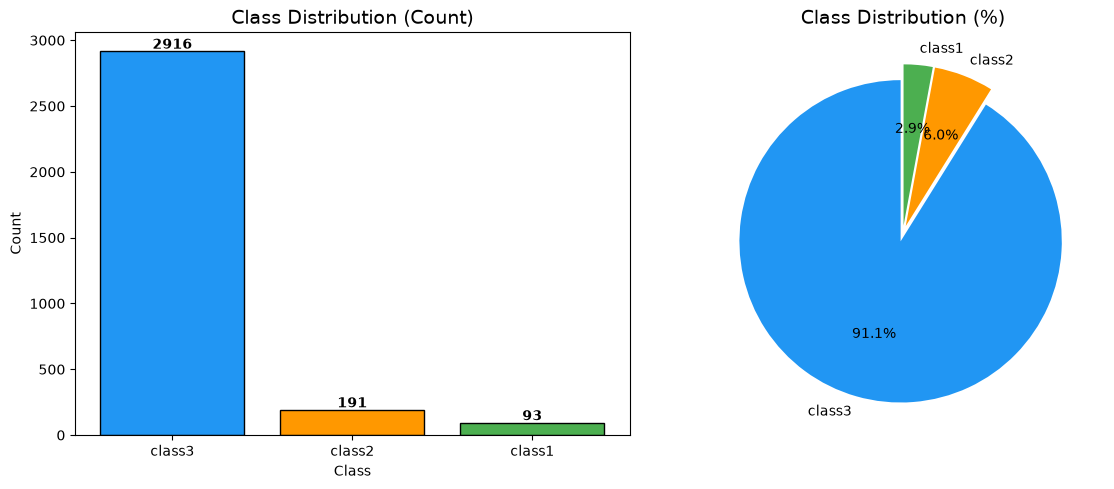

target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

target
class3    91.12
class2     5.97
class1     2.91
Name: count, dtype: float64


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


counts = train['target'].value_counts()
colors = ['#2196F3', '#FF9800', '#4CAF50']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Count)', fontsize=14)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(counts.items()):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontweight='bold')


pcts = counts / len(train) * 100
axes[1].pie(pcts.values, labels=pcts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=[0.05, 0.05, 0.05])
axes[1].set_title('Class Distribution (%)', fontsize=14)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(counts)
print()
print(pcts.round(2))

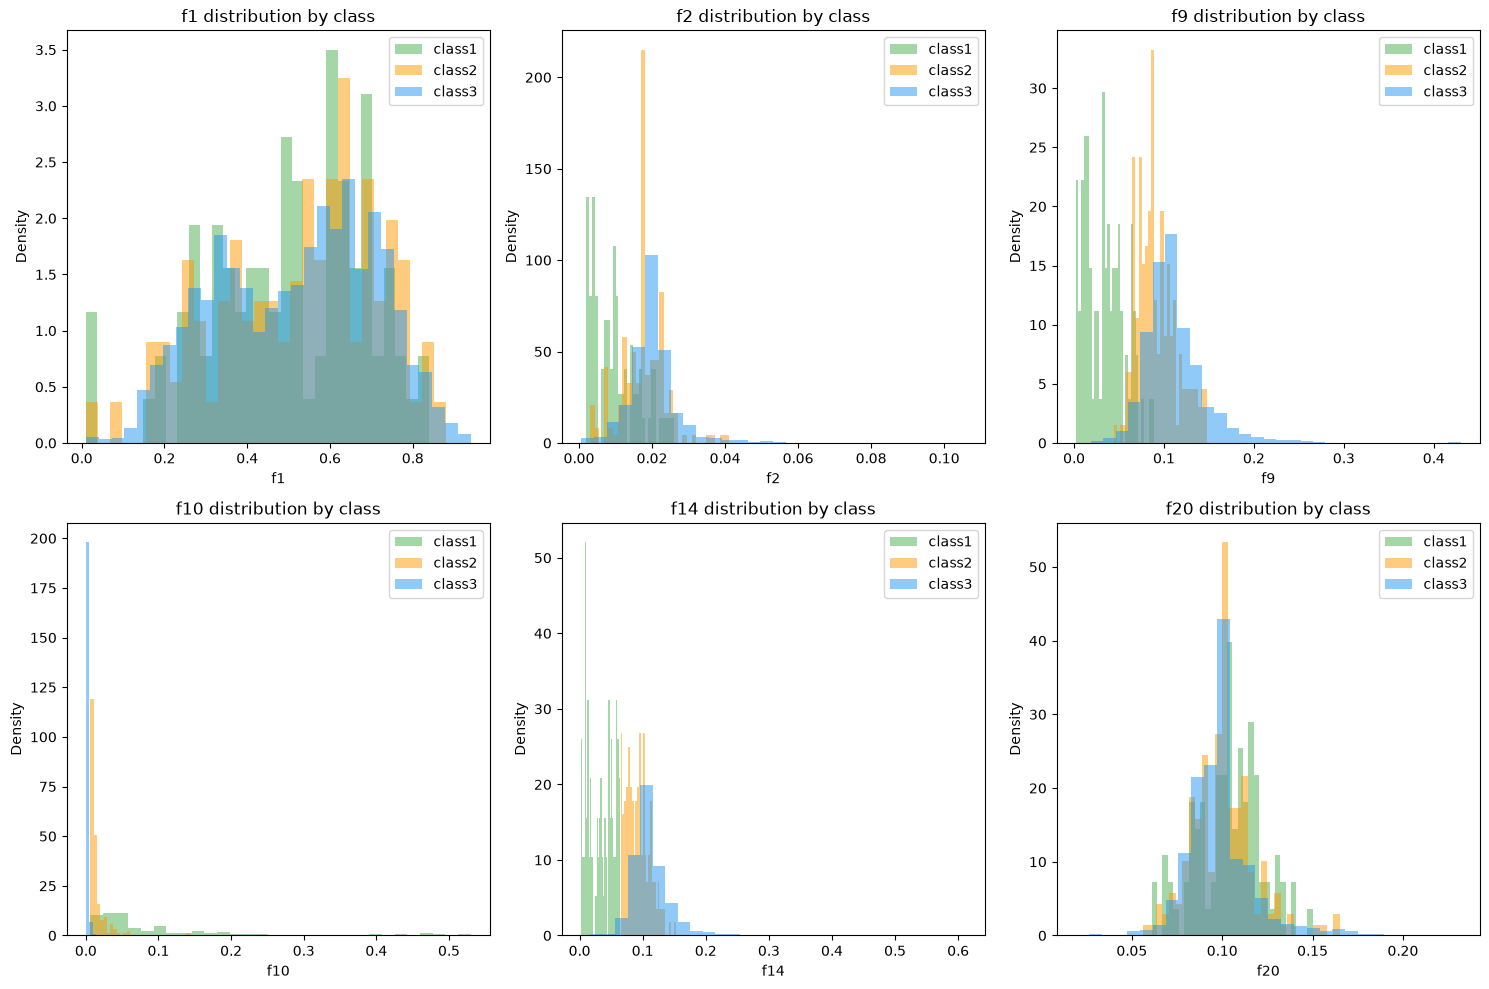

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for cls, color in zip(['class1', 'class2', 'class3'], ['#4CAF50', '#FF9800', '#2196F3']):
        subset = train[train['target'] == cls][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=cls, color=color, density=True)
    axes[i].set_title(f'{col} distribution by class', fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.savefig('continuous_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

f1: التوزيعات متداخلة كثيراً بين الكلاسات — discriminative power ضعيف 

f2, f9, f14, f20: class1 و class2 لهم قيم صغيرة جداً مقارنة بـ class3 — هذا مؤشر تمييز قوي

f10: class3 مركزة عند الصفر تقريباً، بينما class1 و class2 لهم قيم أعلى بكثير — أقوى feature مميزة حتى الآن

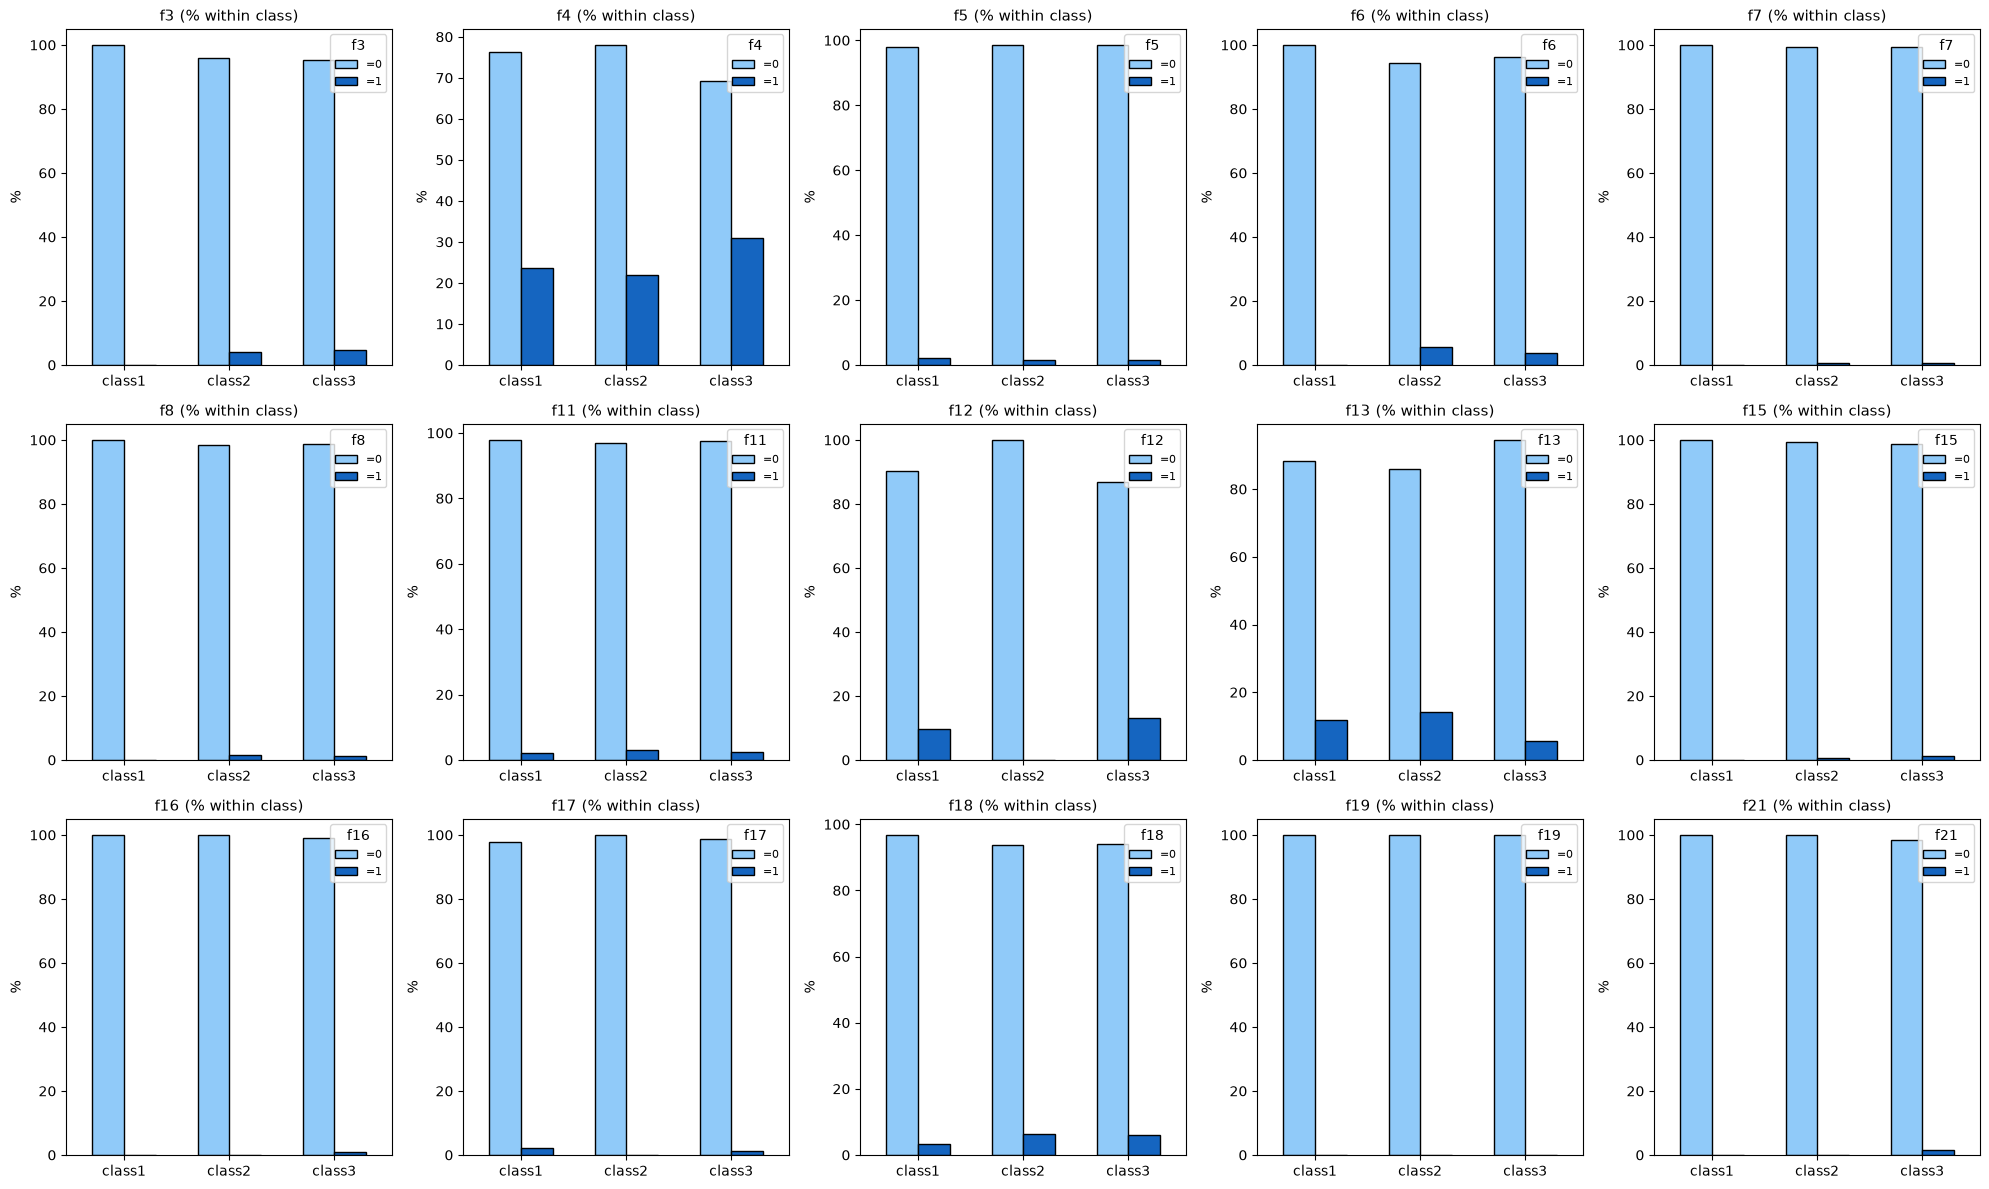

In [11]:
binary_cols = ['f3','f4','f5','f6','f7','f8','f11','f12','f13','f15','f16','f17','f18','f19','f21']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    data = train.groupby(['target', col]).size().unstack(fill_value=0)

    data_pct = data.div(data.sum(axis=1), axis=0) * 100
    data_pct.plot(kind='bar', ax=axes[i], color=['#90CAF9', '#1565C0'],
                  edgecolor='black', width=0.6)
    axes[i].set_title(f'{col} (% within class)', fontsize=11)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('%')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title=col, labels=['=0', '=1'], fontsize=8)

plt.tight_layout()
plt.savefig('binary_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

f4: الوحيدة اللي فيها =1 موزعة بشكل متقارب بين الكلاسات الثلاث (~25-30%) — يعني لا تمييز تقريباً

f12 و f13: =1 موجودة بشكل ملحوظ في class3 فقط (~10-15%) وشبه معدومة في class1 و class2 — مميزتان لـ class3

f3, f5, f6, f7, f8, f11, f15, f16, f17, f18, f19, f21: كلها =1 نادرة جداً في كل الكلاسات — قد تكون ضعيفة التأثير أو noise

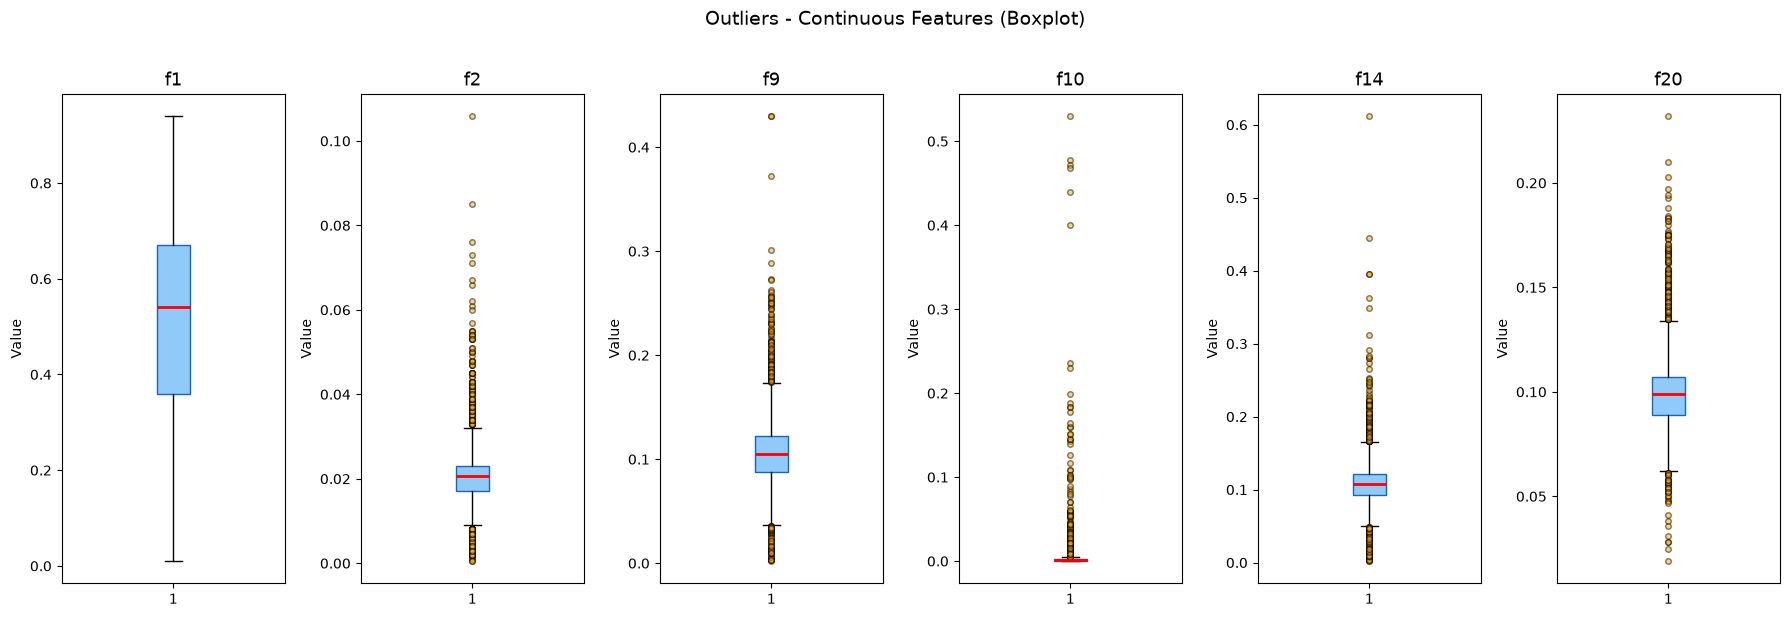

Outlier counts (IQR method):
  f1: 0 outliers (0.0%)
  f2: 288 outliers (9.0%)
  f9: 189 outliers (5.9%)
  f10: 387 outliers (12.1%)
  f14: 223 outliers (7.0%)
  f20: 178 outliers (5.6%)


In [12]:
fig, axes = plt.subplots(1, 6, figsize=(18, 6))

for i, col in enumerate(continuous_cols):
    axes[i].boxplot(train[col], patch_artist=True,
                    boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=4, alpha=0.5))
    axes[i].set_title(col, fontsize=13)
    axes[i].set_ylabel('Value')

plt.suptitle('Outliers - Continuous Features (Boxplot)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


print("Outlier counts (IQR method):")
for col in continuous_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col}: {outliers} outliers ({outliers/len(train)*100:.1f}%)")

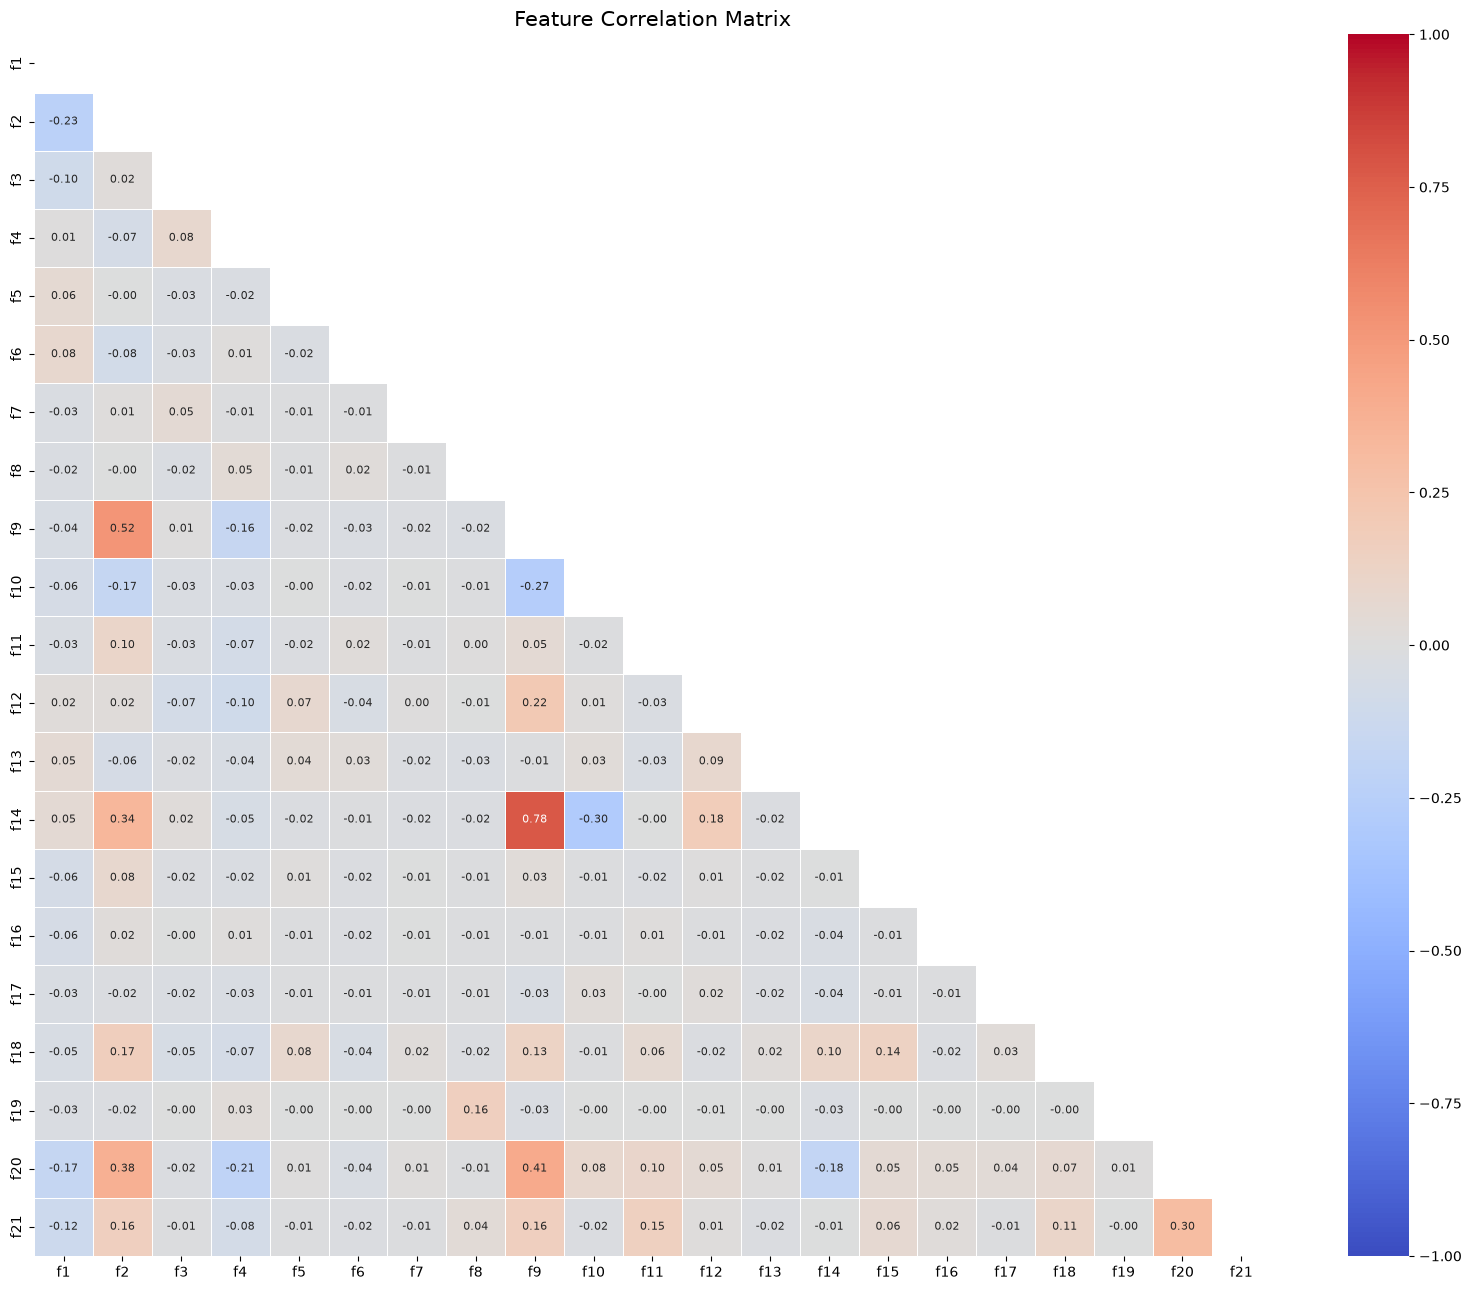

Top correlations (|r| > 0.3):
f14  f9     0.776560
f9   f14    0.776560
f2   f9     0.521466
f9   f2     0.521466
     f20    0.412800
f20  f9     0.412800
     f2     0.382653
f2   f20    0.382653
     f14    0.338441
f14  f2     0.338441
f21  f20    0.300307
f20  f21    0.300307
dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
corr = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8},
            linewidths=0.5)

ax.set_title('Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


print("Top correlations (|r| > 0.3):")
corr_pairs = corr.abs().unstack()
corr_pairs = corr_pairs[corr_pairs < 1.0].sort_values(ascending=False)
print(corr_pairs[corr_pairs > 0.3].head(20))

f9 ↔ f14: 0.78 — ارتباط قوي جداً، قد يكونا يقيسان نفس الشيء تقريباً

f2 ↔ f9: 0.52 و f2 ↔ f20: 0.38 — مجموعة f2/f9/f14/f20 مترابطة مع بعض

باقي الـ features شبه مستقلة عن بعضها

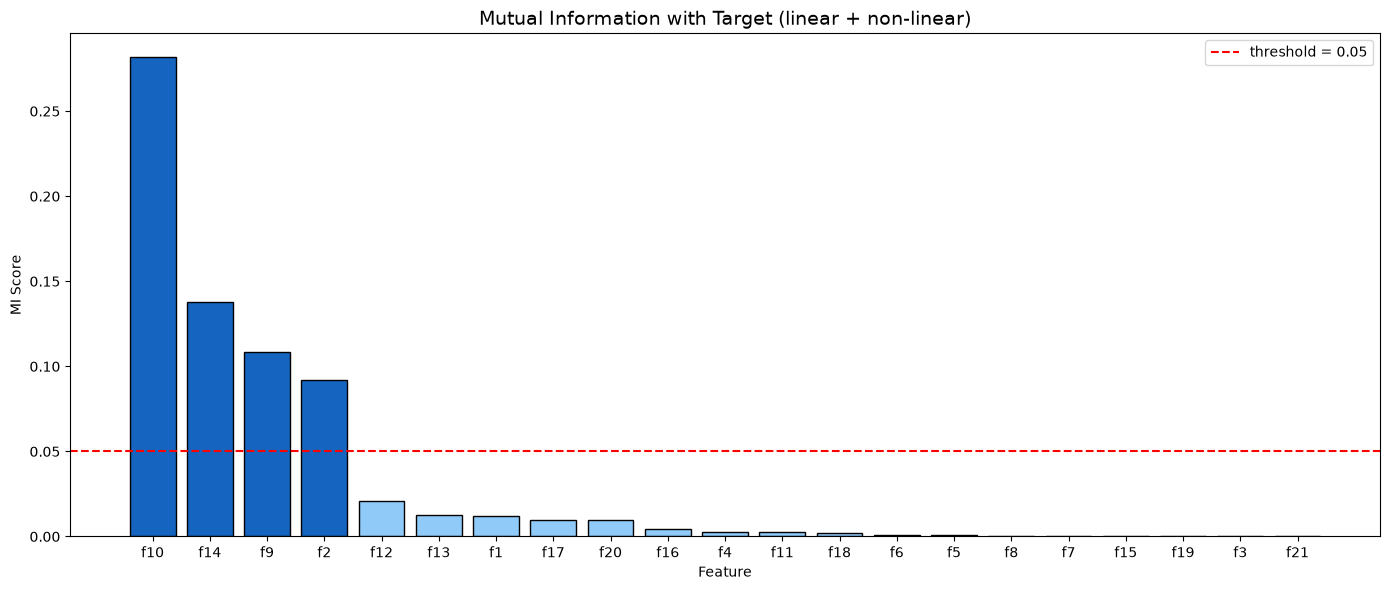

Mutual Information Scores:
f10    0.2818
f14    0.1380
f9     0.1082
f2     0.0921
f12    0.0206
f13    0.0127
f1     0.0122
f17    0.0096
f20    0.0095
f16    0.0042
f4     0.0029
f11    0.0027
f18    0.0023
f6     0.0011
f5     0.0007
f8     0.0000
f7     0.0000
f15    0.0000
f19    0.0000
f3     0.0000
f21    0.0000
dtype: float64


In [14]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mi = mutual_info_classif(train[feature_cols], y, random_state=42)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1565C0' if v > 0.05 else '#90CAF9' for v in mi_series.values]
ax.bar(mi_series.index, mi_series.values, color=colors, edgecolor='black')
ax.axhline(0.05, color='red', linestyle='--', label='threshold = 0.05')
ax.set_title('Mutual Information with Target (linear + non-linear)', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('MI Score')
ax.legend()
plt.tight_layout()
plt.savefig('mutual_information.png', dpi=150, bbox_inches='tight')
plt.show()

print("Mutual Information Scores:")
print(mi_series.round(4))

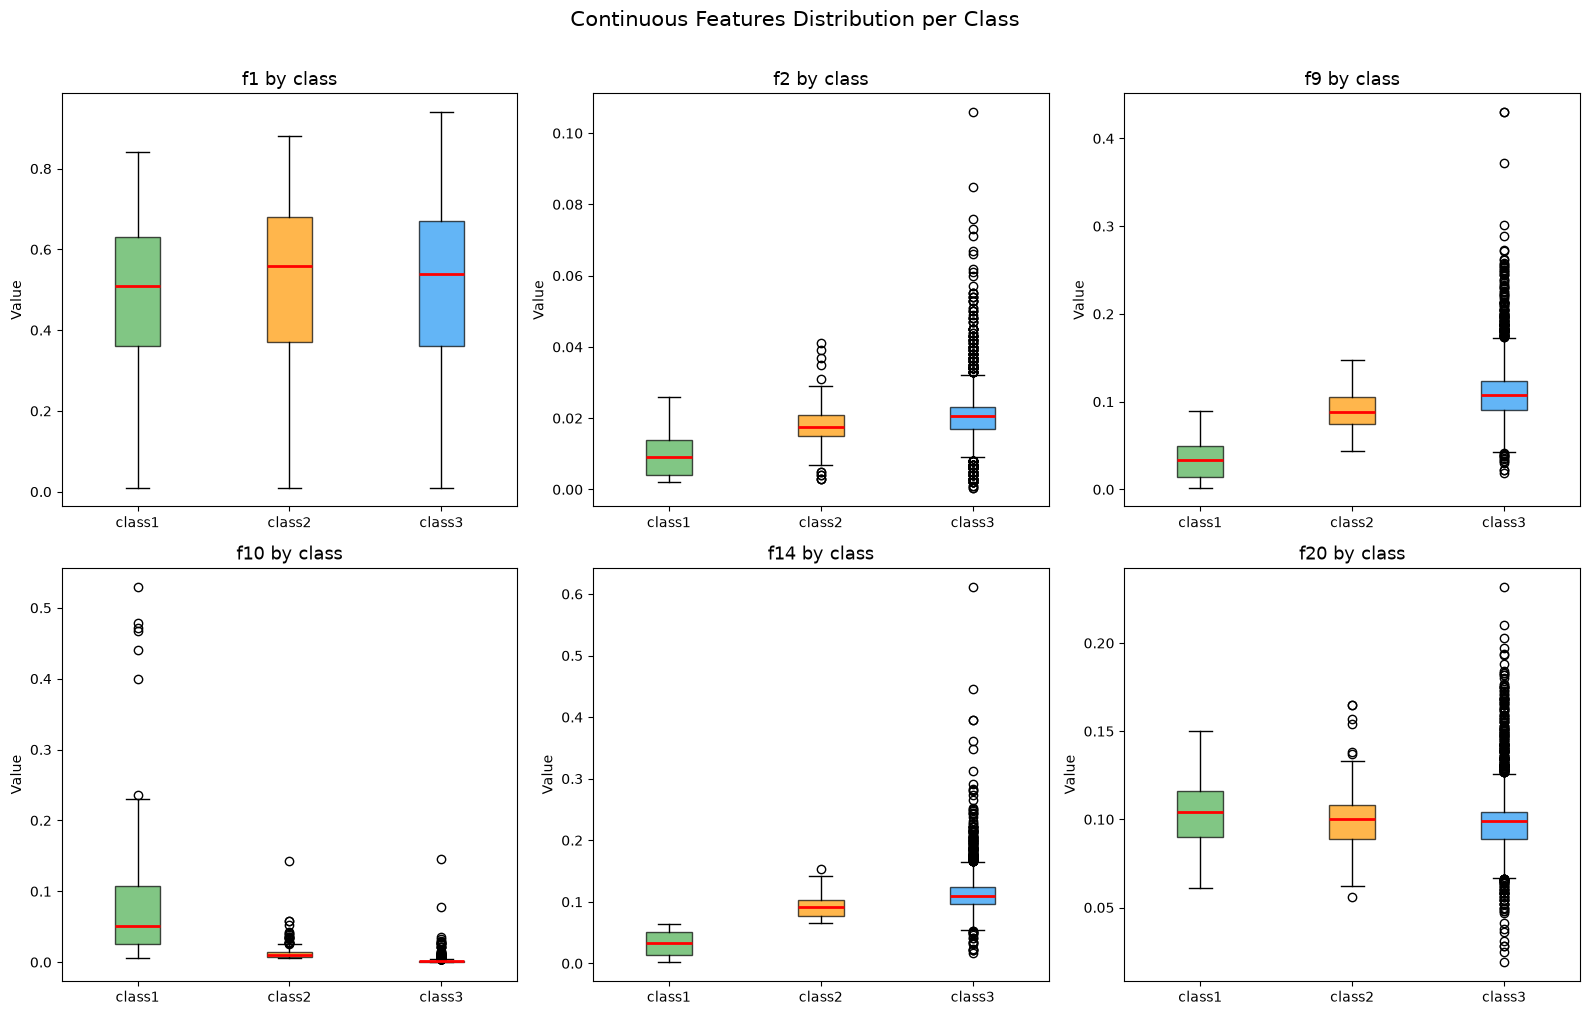

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

colors = {'class1': '#4CAF50', 'class2': '#FF9800', 'class3': '#2196F3'}

for i, col in enumerate(continuous_cols):
    data_by_class = [train[train['target'] == cls][col].values
                     for cls in ['class1', 'class2', 'class3']]

    bp = axes[i].boxplot(data_by_class, patch_artist=True,
                     tick_labels=['class1', 'class2', 'class3'],
                     medianprops=dict(color='red', linewidth=2))
    for patch, cls in zip(bp['boxes'], ['class1', 'class2', 'class3']):
        patch.set_facecolor(colors[cls])
        patch.set_alpha(0.7)

    axes[i].set_title(f'{col} by class', fontsize=13)
    axes[i].set_ylabel('Value')

plt.suptitle('Continuous Features Distribution per Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('boxplot_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

f10: class3 median ≈ 0، class1 أعلى بكثير (~0.06) — أقوى feature مميزة، لكن لاحظ أن class1 و class3 متداخلتان في النطاق الأدنى

f14 و f9: نفس النمط — class1 أصغر، class2 في المنتصف، class3 الأكبر — عكس f10 تماماً\

f2: نفس اتجاه f14/f9 — class1 أصغر قيمة

f1: الثلاث كلاسات متداخلة تقريباً — ضعيفة التمييز كما توقعنا

f20: الكلاسات الثلاث متقاربة جداً — ضعيفة رغم ارتباطها مع f9

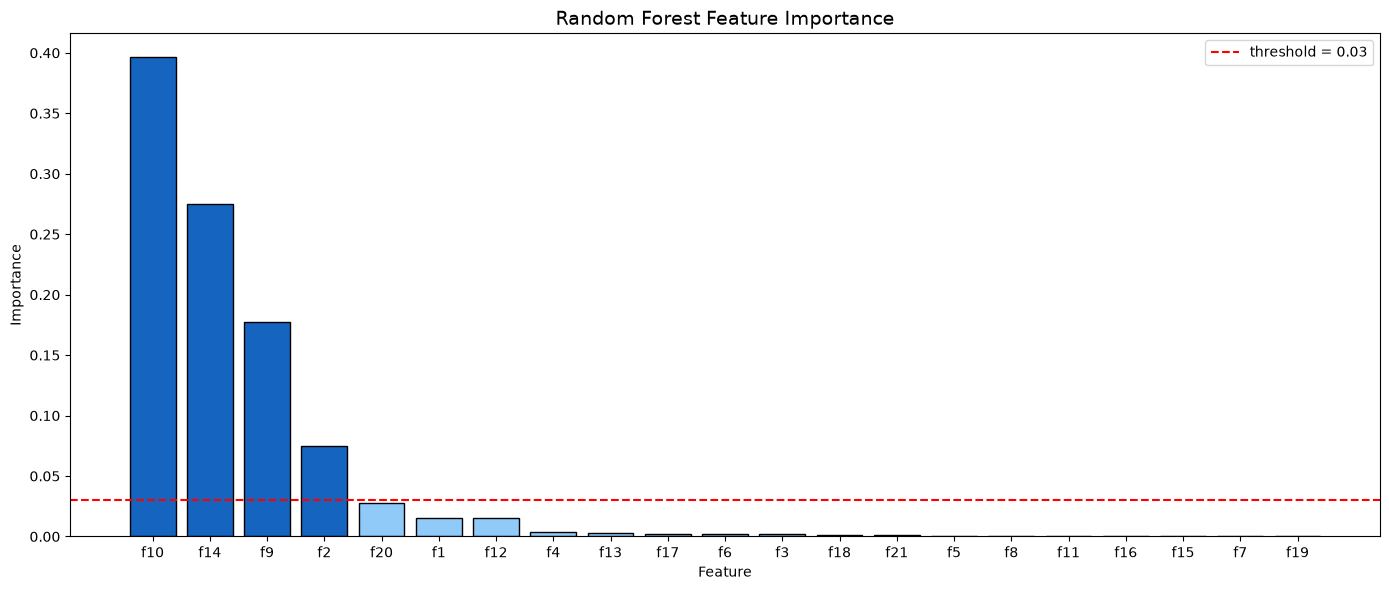

Feature Importances:
f10    0.3965
f14    0.2751
f9     0.1774
f2     0.0746
f20    0.0279
f1     0.0151
f12    0.0151
f4     0.0036
f13    0.0033
f17    0.0024
f6     0.0024
f3     0.0021
f18    0.0011
f21    0.0009
f5     0.0006
f8     0.0006
f11    0.0006
f16    0.0004
f15    0.0003
f7     0.0002
f19    0.0000
dtype: float64


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
le = LabelEncoder()
y = le.fit_transform(train['target'])

rf = RandomForestClassifier(n_estimators=200, random_state=42,
                             class_weight='balanced', n_jobs=-1)
rf.fit(train[feature_cols], y)

imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1565C0' if v > 0.03 else '#90CAF9' for v in imp.values]
ax.bar(imp.index, imp.values, color=colors, edgecolor='black')
ax.axhline(0.03, color='red', linestyle='--', label='threshold = 0.03')
ax.set_title('Random Forest Feature Importance', fontsize=14)
ax.set_xlabel('Feature')
ax.set_ylabel('Importance')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("Feature Importances:")
print(imp.round(4))

# EDA Summary — Anonymized Classification Challenge

## 1. البنية العامة للداتا
- Train: 3200 صف × 23 عمود | Test: 3200 صف × 22 عمود
- 6 features عددية مستمرة: f1, f2, f9, f10, f14, f20
- 15 feature ثنائية (0/1): f3–f8, f11–f13, f15–f19, f21
- لا nulls، لا duplicates — الداتا نظيفة تماماً

## 2. Class Imbalance — مشكلة حرجة
- class3: 2916 صف (91.1%) — مهيمنة بشكل كامل
- class2: 191 صف (6.0%)
- class1: 93 صف (2.9%)
- أي نموذج بدون معالجة سيتحيز نحو class3 بشكل شبه كامل
- **يجب استخدام class_weight='balanced' أو SMOTE**

## 3. الـ Features الأكثر أهمية
بناءً على Mutual Information + Random Forest Feature Importance:

| Feature | MI Score | RF Importance | الملاحظة |
|---------|----------|---------------|----------|
| f10 | 0.282 | 0.406 | الأقوى بفارق كبير — class3 قريبة من الصفر، class1 أعلى بكثير |
| f14 | 0.138 | 0.271 | عكس f10 — class3 الأكبر |
| f9  | 0.108 | 0.169 | نفس اتجاه f14 |
| f2  | 0.092 | 0.078 | نفس اتجاه f14/f9 |
| f20 | 0.010 | 0.028 | حدودية، ارتباطها مع f9 يجعلها redundant |

## 4. الـ Features الضعيفة أو المعدومة
- **MI = 0.000**: f3, f7, f8, f15, f19, f21 — لا تضيف أي معلومة للـ target
- **f4**: موزعة بالتساوي بين الكلاسات — لا تمييز
- **f1**: التوزيعات متداخلة كلياً بين الكلاسات

## 5. الارتباطات بين الـ Features
- **f9 ↔ f14: r = 0.78** — ارتباط خطي قوي جداً، قد يسببان multicollinearity
- **f2 ↔ f9: r = 0.52** — مجموعة f2/f9/f14/f20 مترابطة
- باقي الـ features مستقلة عن بعضها

## 6. الـ Outliers
- f10: 12.1% outliers — الأسوأ، وهذه الـ outliers تخص class1/class2 غالباً
- f2, f9, f14, f20: 5-9% outliers — right-skewed
- f1: نظيفة تماماً (0%)

## 7. توصيات للنمذجة
1. **التركيز على f10, f14, f9, f2** كـ core features
2. **class_weight='balanced'** إلزامي بسبب الـ imbalance الحاد
3. **Stratified K-Fold** في الـ validation لضمان وجود class1/class2 في كل fold
4. **النظر في حذف** f3, f7, f8, f15, f19, f21 أو تجربة النموذج مع وبدونها
5. **الحذر من f9 ↔ f14** — قد يستفيد النموذج من إسقاط أحدهما أو إنشاء feature مشتق

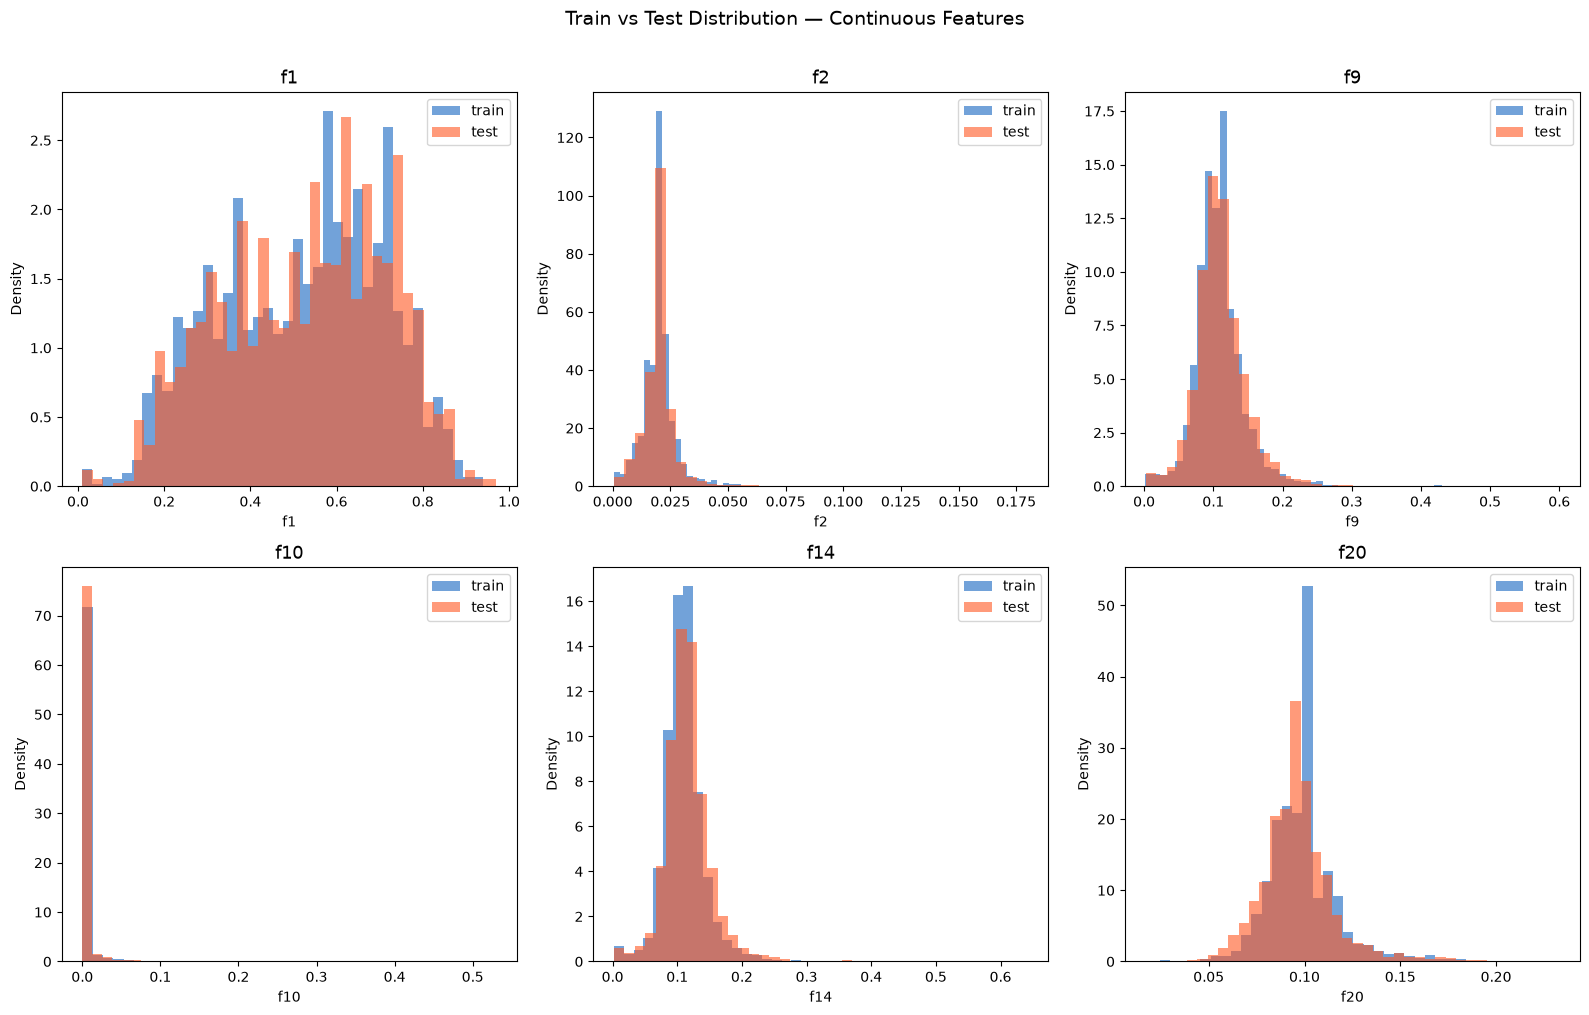

Binary features — |train_rate - test_rate|:
f18    0.0178
f12    0.0166
f7     0.0159
f13    0.0078
f8     0.0062
f21    0.0059
f5     0.0044
f15    0.0028
f3     0.0016
f6     0.0016
f11    0.0016
f4     0.0012
f16    0.0003
f17    0.0003
f19    0.0003
dtype: float64


In [17]:
import matplotlib.pyplot as plt
import numpy as np

continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(train[col], bins=40, alpha=0.6, color='#1565C0',
                 density=True, label='train')
    axes[i].hist(test[col], bins=40, alpha=0.6, color='#FF5722',
                 density=True, label='test')
    axes[i].set_title(f'{col}', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Train vs Test Distribution — Continuous Features', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('train_test_dist_continuous.png', dpi=150, bbox_inches='tight')
plt.show()


binary_cols = ['f3','f4','f5','f6','f7','f8','f11','f12','f13','f15','f16','f17','f18','f19','f21']
train_rates = train[binary_cols].mean()
test_rates = test[binary_cols].mean()

diff = (train_rates - test_rates).abs()
print("Binary features — |train_rate - test_rate|:")
print(diff.round(4).sort_values(ascending=False))

## 8. Train vs Test Distribution
- الـ continuous features متطابقة التوزيع تماماً بين train و test
- الـ binary features: أكبر فرق هو 0.018 في f18 — ضئيل جداً
- **لا يوجد domain shift** — الـ test مأخوذ من نفس المصدر
- لا حاجة لأي تقنيات خاصة للتعامل مع distribution mismatch

## تجربة Baseline Random Forest

في هذه التجربة نبدأ بنموذج Random Forest بدون class weights وبدون SMOTE وبدون feature engineering. الهدف هو بناء نقطة مرجعية أولى نقارن عليها كل التجارب اللاحقة. سيتم تسجيل البارامترات، نتائج F1 لكل fold، متوسط F1، الانحراف المعياري، والموديل داخل MLflow.


In [18]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mlflow.set_experiment('clf_experiments_BL')

with mlflow.start_run(run_name='baseline_RF'):

    params = {
        'model'        : 'RandomForest',
        'n_estimators' : 200,
        'max_depth'    : None,
        'class_weight' : 'balanced',
        'random_state' : 42,
        'cv_folds'     : 5,
        'cv_strategy'  : 'StratifiedKFold',
        'features_used': 'all_21',
    }
    mlflow.log_params(params)

    model = RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1,
    )

    skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []


    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds = model.predict(X.iloc[val_idx])

        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)


        report = classification_report(
            y[val_idx], preds,
            target_names=le.classes_,
            output_dict=True
        )
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])

        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
              f'class1={report["class1"]["f1-score"]:.4f} | '
              f'class2={report["class2"]["f1-score"]:.4f} | '
              f'class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)


    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))

    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))


    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(model, 'model')

2026/06/30 20:13:28 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_BL' does not exist. Creating a new experiment.


Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9785 | class1=1.0000 | class2=0.9398 | class3=0.9957
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9776 | class1=0.9744 | class2=0.9620 | class3=0.9966
Fold 5: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974

  CV F1-Macro Mean : 0.9839  (±0.0065)
  class1 F1 Mean   : 0.9843  (±0.0128)
  class2 F1 Mean   : 0.9700  (±0.0178)
  class3 F1 Mean   : 0.9974  (±0.0012)


2026/06/30 20:13:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة Baseline LightGBM

هذه التجربة تستخدم LightGBM على نفس features الأصلية بدون أي معالجة إضافية. الفرق عن تجربة Random Forest هو استخدام boosting بدل bagging، وهذا يساعدنا نعرف هل نموذج boosting يستفيد أكثر من شكل الداتا الحالية. كل النتائج والبارامترات ستظهر داخل MLflow.


In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mlflow.set_experiment('clf_experiments_BL')

with mlflow.start_run(run_name='baseline_LGB_raw'):

    params = {
        'model'          : 'LightGBM',
        'n_estimators'   : 200,
        'learning_rate'  : 0.1,
        'num_leaves'     : 31,
        'class_weight'   : 'None',
        'sampling'       : 'None',
        'random_state'   : 42,
        'cv_folds'       : 5,
        'cv_strategy'    : 'StratifiedKFold',
        'features_used'  : 'all_21',
    }
    mlflow.log_params(params)

    model = lgb.LGBMClassifier(
        n_estimators  = 200,
        learning_rate = 0.1,
        num_leaves    = 31,
        random_state  = 42,
        n_jobs        = -1,
        verbose       = -1,
    )

    skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores    = []
    class_f1  = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)

        report = classification_report(
            y[val_idx], preds,
            target_names=le.classes_,
            output_dict=True
        )
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])

        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
              f'class1={report["class1"]["f1-score"]:.4f} | '
              f'class2={report["class2"]["f1-score"]:.4f} | '
              f'class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)

    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(
    model,
    'model',
    skops_trusted_types=[
        'collections.OrderedDict',
        'lightgbm.basic.Booster',
        'lightgbm.sklearn.LGBMClassifier'
    ]
)

Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=1.0000 | class1=1.0000 | class2=1.0000 | class3=1.0000
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9675 | class1=0.9744 | class2=0.9333 | class3=0.9949
Fold 5: F1-Macro=0.9953 | class1=1.0000 | class2=0.9867 | class3=0.9991

  CV F1-Macro Mean : 0.9889  (±0.0116)
  class1 F1 Mean   : 0.9895  (±0.0129)
  class2 F1 Mean   : 0.9788  (±0.0233)
  class3 F1 Mean   : 0.9983  (±0.0018)


2026/06/30 20:14:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة Baseline XGBoost

في هذه التجربة نستخدم XGBoost كخوارزمية boosting ثانية للمقارنة مع LightGBM. لا يوجد تغيير على الداتا أو feature engineering، والهدف هو مقارنة قوة النموذج نفسه فقط. سيتم حفظ النتائج والبارامترات في MLflow.


In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mlflow.set_experiment('clf_experiments_BL')

with mlflow.start_run(run_name='baseline_XGB_raw'):

    params = {
        'model'         : 'XGBoost',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'max_depth'     : 6,
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
    mlflow.log_params(params)

    model = XGBClassifier(
        n_estimators  = 200,
        learning_rate = 0.1,
        max_depth     = 6,
        random_state  = 42,
        n_jobs        = -1,
        verbosity     = 0,
        use_label_encoder = False,
        eval_metric   = 'mlogloss',
    )

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)

        report = classification_report(
            y[val_idx], preds,
            target_names=le.classes_,
            output_dict=True
        )
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])

        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
              f'class1={report["class1"]["f1-score"]:.4f} | '
              f'class2={report["class2"]["f1-score"]:.4f} | '
              f'class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)

    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(
    model,
    'model',
    skops_trusted_types=[
        'xgboost.core.Booster',
        'xgboost.sklearn.XGBClassifier'
    ]
)

Fold 1: F1-Macro=0.9816 | class1=0.9714 | class2=0.9744 | class3=0.9991
Fold 2: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 3: F1-Macro=1.0000 | class1=1.0000 | class2=1.0000 | class3=1.0000
Fold 4: F1-Macro=0.9675 | class1=0.9744 | class2=0.9333 | class3=0.9949
Fold 5: F1-Macro=0.9737 | class1=0.9474 | class2=0.9737 | class3=1.0000

  CV F1-Macro Mean : 0.9810  (±0.0109)
  class1 F1 Mean   : 0.9732  (±0.0167)
  class2 F1 Mean   : 0.9711  (±0.0214)
  class3 F1 Mean   : 0.9986  (±0.0019)


2026/06/30 20:15:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة Baseline CatBoost

هذه التجربة تختبر CatBoost على features الأصلية. لا يوجد تعديل على الداتا، والهدف مقارنة CatBoost مع LGB وXGB على نفس ظروف baseline. سيتم تسجيل نتائج الـ cross-validation والموديل في MLflow.


In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mlflow.set_experiment('clf_experiments_BL')

with mlflow.start_run(run_name='baseline_CatBoost_raw'):

    params = {
        'model'         : 'CatBoost',
        'iterations'    : 200,
        'learning_rate' : 0.1,
        'depth'         : 6,
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
    mlflow.log_params(params)


    binary_cols = ['f3','f4','f5','f6','f7','f8',
                   'f11','f12','f13','f15','f16','f17','f18','f19','f21']
    cat_features = [feature_cols.index(c) for c in binary_cols]

    model = CatBoostClassifier(
        iterations    = 200,
        learning_rate = 0.1,
        depth         = 6,
        random_seed   = 42,
        verbose       = 0,
        cat_features  = cat_features,
    )

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)

        report = classification_report(
            y[val_idx], preds,
            target_names=le.classes_,
            output_dict=True
        )
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])

        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
              f'class1={report["class1"]["f1-score"]:.4f} | '
              f'class2={report["class2"]["f1-score"]:.4f} | '
              f'class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)

    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(
        model,
        'model',
        skops_trusted_types=[
            'catboost.core.CatBoostClassifier'
        ]
    )

Fold 1: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=1.0000 | class1=1.0000 | class2=1.0000 | class3=1.0000
Fold 4: F1-Macro=0.9728 | class1=0.9474 | class2=0.9744 | class3=0.9966
Fold 5: F1-Macro=0.9912 | class1=0.9744 | class2=1.0000 | class3=0.9991

  CV F1-Macro Mean : 0.9884  (±0.0097)
  class1 F1 Mean   : 0.9843  (±0.0210)
  class2 F1 Mean   : 0.9825  (±0.0183)
  class3 F1 Mean   : 0.9983  (±0.0014)


2026/06/30 20:15:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة Baseline SVM

هنا نستخدم SVM مع StandardScaler لأن SVM حساس لمقاييس features. هذه التجربة ما زالت baseline لأنها لا تستخدم class weights ولا SMOTE ولا feature engineering. الفرق فقط هو طبيعة الخوارزمية وطريقة preprocessing داخل pipeline.


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mlflow.set_experiment('clf_experiments_BL')

with mlflow.start_run(run_name='baseline_SVM_raw'):

    params = {
        'model'        : 'SVM',
        'kernel'       : 'rbf',
        'C'            : 1.0,
        'gamma'        : 'scale',
        'class_weight' : 'None',
        'sampling'     : 'None',
        'scaling'      : 'StandardScaler',
        'random_state' : 42,
        'cv_folds'     : 5,
        'cv_strategy'  : 'StratifiedKFold',
        'features_used': 'all_21',
    }
    mlflow.log_params(params)


    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale',
                       random_state=42, probability=True))
    ])

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)

        report = classification_report(
            y[val_idx], preds,
            target_names=le.classes_,
            output_dict=True
        )
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])

        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
              f'class1={report["class1"]["f1-score"]:.4f} | '
              f'class2={report["class2"]["f1-score"]:.4f} | '
              f'class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)

    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    mlflow.sklearn.log_model(model, 'model')

Fold 1: F1-Macro=0.6479 | class1=0.7143 | class2=0.2609 | class3=0.9685
Fold 2: F1-Macro=0.7499 | class1=0.9091 | class2=0.3673 | class3=0.9733
Fold 3: F1-Macro=0.6503 | class1=0.8421 | class2=0.1395 | class3=0.9691
Fold 4: F1-Macro=0.6826 | class1=0.7742 | class2=0.3043 | class3=0.9692
Fold 5: F1-Macro=0.7427 | class1=0.9143 | class2=0.3404 | class3=0.9733

  CV F1-Macro Mean : 0.6947  (±0.0440)
  class1 F1 Mean   : 0.8308  (±0.0775)
  class2 F1 Mean   : 0.2825  (±0.0799)
  class3 F1 Mean   : 0.9707  (±0.0021)


2026/06/30 20:15:42 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة Baseline KNN

هذه التجربة تختبر KNN مع StandardScaler. الهدف معرفة أداء نموذج يعتمد على قرب النقاط في feature space مقارنة بالنماذج الشجرية. لا يوجد تعديل على الداتا، وستسجل النتائج في MLflow.


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


mlflow.set_experiment('clf_experiments_BL')

with mlflow.start_run(run_name='baseline_KNN_raw'):

    params = {
        'model'        : 'KNN',
        'n_neighbors'  : 5,
        'weights'      : 'uniform',
        'metric'       : 'minkowski',
        'class_weight' : 'None',
        'sampling'     : 'None',
        'scaling'      : 'StandardScaler',
        'cv_folds'     : 5,
        'cv_strategy'  : 'StratifiedKFold',
        'features_used': 'all_21',
    }
    mlflow.log_params(params)


    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(
                       n_neighbors = 5,
                       weights     = 'uniform',
                       metric      = 'minkowski',
                       n_jobs      = -1))
    ])

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)

        report = classification_report(
            y[val_idx], preds,
            target_names=le.classes_,
            output_dict=True
        )
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])

        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
              f'class1={report["class1"]["f1-score"]:.4f} | '
              f'class2={report["class2"]["f1-score"]:.4f} | '
              f'class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)

    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    mlflow.sklearn.log_model(model, 'model')

Fold 1: F1-Macro=0.6435 | class1=0.6667 | class2=0.2963 | class3=0.9675
Fold 2: F1-Macro=0.7522 | class1=0.9091 | class2=0.3750 | class3=0.9725
Fold 3: F1-Macro=0.6678 | class1=0.8571 | class2=0.1739 | class3=0.9725
Fold 4: F1-Macro=0.6886 | class1=0.8125 | class2=0.2857 | class3=0.9675
Fold 5: F1-Macro=0.6687 | class1=0.7097 | class2=0.3265 | class3=0.9700


2026/06/30 20:15:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6842  (±0.0369)
  class1 F1 Mean   : 0.7910  (±0.0904)
  class2 F1 Mean   : 0.2915  (±0.0665)
  class3 F1 Mean   : 0.9700  (±0.0022)


## تجربة Random Forest مع Class Weight

هنا نضيف أوزان للكلاسات لمعالجة عدم التوازن بين class1 و class2 و class3. الفرق عن baseline RF أن الخطأ على الكلاسات الصغيرة أصبح له وزن أعلى. الهدف معرفة هل تتحسن macro F1 بدون تصنيع عينات جديدة.


In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


class_weights = {0: 11.47, 1: 5.58, 2: 0.37}

mlflow.set_experiment('clf_experiments_CW')

with mlflow.start_run(run_name='CW_RF'):
    params = {
        'model'        : 'RandomForest',
        'n_estimators' : 200,
        'max_depth'    : None,
        'class_weight' : 'custom_11.47_5.58_0.37',
        'sampling'     : 'None',
        'random_state' : 42,
        'cv_folds'     : 5,
        'cv_strategy'  : 'StratifiedKFold',
        'features_used': 'all_21',
    }
    mlflow.log_params(params)

    model = RandomForestClassifier(
        n_estimators=200,
        class_weight=class_weights,
        random_state=42,
        n_jobs=-1,
    )

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)
        report = classification_report(y[val_idx], preds, target_names=le.classes_, output_dict=True)
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])
        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | class1={report["class1"]["f1-score"]:.4f} | class2={report["class2"]["f1-score"]:.4f} | class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)
    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(model, 'model')

2026/06/30 20:16:10 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_CW' does not exist. Creating a new experiment.


Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9785 | class1=1.0000 | class2=0.9398 | class3=0.9957
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9734 | class1=0.9744 | class2=0.9500 | class3=0.9957
Fold 5: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974

  CV F1-Macro Mean : 0.9804  (±0.0043)
  class1 F1 Mean   : 0.9789  (±0.0106)
  class2 F1 Mean   : 0.9651  (±0.0174)
  class3 F1 Mean   : 0.9972  (±0.0014)


2026/06/30 20:16:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة LightGBM مع Class Weight

هذه التجربة تضيف class weights إلى LightGBM. الفرق عن baseline LGB هو جعل النموذج يعاقب أخطاء الكلاسات الصغيرة أكثر. نراقب هل يتحسن macro F1 وهل يبقى الأداء مستقراً بين folds.


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])

class_weights = {0: 11.47, 1: 5.58, 2: 0.37}

mlflow.set_experiment('clf_experiments_CW')

with mlflow.start_run(run_name='CW_LGB'):
    params = {
        'model'         : 'LightGBM',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'num_leaves'    : 31,
        'class_weight'  : 'custom_11.47_5.58_0.37',
        'sampling'      : 'None',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
    mlflow.log_params(params)

    model = lgb.LGBMClassifier(
        n_estimators  = 200,
        learning_rate = 0.1,
        num_leaves    = 31,
        class_weight  = class_weights,
        random_state  = 42,
        n_jobs        = -1,
        verbose       = -1,
    )

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)
        report = classification_report(y[val_idx], preds, target_names=le.classes_, output_dict=True)
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])
        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | class1={report["class1"]["f1-score"]:.4f} | class2={report["class2"]["f1-score"]:.4f} | class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)
    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(
        model, 'model',
        skops_trusted_types=['collections.OrderedDict','lightgbm.basic.Booster','lightgbm.sklearn.LGBMClassifier']
    )

Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9911 | class1=1.0000 | class2=0.9750 | class3=0.9983
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9720 | class1=0.9744 | class2=0.9459 | class3=0.9957
Fold 5: F1-Macro=0.9912 | class1=0.9744 | class2=1.0000 | class3=0.9991

  CV F1-Macro Mean : 0.9871  (±0.0081)
  class1 F1 Mean   : 0.9843  (±0.0128)
  class2 F1 Mean   : 0.9790  (±0.0183)
  class3 F1 Mean   : 0.9981  (±0.0013)


2026/06/30 20:16:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة XGBoost مع Sample Weight

XGBoost لا يستخدم class_weight مباشرة بنفس طريقة بعض النماذج، لذلك نمرر sample weights حسب الكلاس. هذه التجربة تقارن أثر الأوزان على XGBoost مقابل baseline XGBoost.


In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


sample_weights_map = {0: 11.47, 1: 5.58, 2: 0.37}

mlflow.set_experiment('clf_experiments_CW')

with mlflow.start_run(run_name='CW_XGB'):
    params = {
        'model'         : 'XGBoost',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'max_depth'     : 6,
        'class_weight'  : 'custom_11.47_5.58_0.37',
        'sampling'      : 'None',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
    mlflow.log_params(params)

    model = XGBClassifier(
        n_estimators  = 200,
        learning_rate = 0.1,
        max_depth     = 6,
        random_state  = 42,
        n_jobs        = -1,
        verbosity     = 0,
        eval_metric   = 'mlogloss',
    )

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        sw = np.array([sample_weights_map[label] for label in y[tr_idx]])
        model.fit(X.iloc[tr_idx], y[tr_idx], sample_weight=sw)
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)
        report = classification_report(y[val_idx], preds, target_names=le.classes_, output_dict=True)
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])
        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | class1={report["class1"]["f1-score"]:.4f} | class2={report["class2"]["f1-score"]:.4f} | class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)
    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    sw_full = np.array([sample_weights_map[label] for label in y])
    model.fit(X, y, sample_weight=sw_full)
    mlflow.sklearn.log_model(
        model, 'model',
        skops_trusted_types=['xgboost.core.Booster','xgboost.sklearn.XGBClassifier']
    )

Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9911 | class1=1.0000 | class2=0.9750 | class3=0.9983
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9638 | class1=0.9744 | class2=0.9231 | class3=0.9940
Fold 5: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974

  CV F1-Macro Mean : 0.9837  (±0.0109)
  class1 F1 Mean   : 0.9843  (±0.0128)
  class2 F1 Mean   : 0.9693  (±0.0238)
  class3 F1 Mean   : 0.9974  (±0.0018)


2026/06/30 20:16:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة CatBoost مع Class Weight

في هذه التجربة نمرر أوزان الكلاسات إلى CatBoost. الفرق عن baseline CatBoost هو إعطاء class1 و class2 تأثيراً أكبر أثناء التدريب. سيتم تسجيل الأوزان والنتائج داخل MLflow.


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])

class_weights = [11.47, 5.58, 0.37]
binary_cols   = ['f3','f4','f5','f6','f7','f8','f11','f12','f13','f15','f16','f17','f18','f19','f21']
cat_features  = [feature_cols.index(c) for c in binary_cols]

mlflow.set_experiment('clf_experiments_CW')

with mlflow.start_run(run_name='CW_CatBoost'):
    params = {
        'model'         : 'CatBoost',
        'iterations'    : 200,
        'learning_rate' : 0.1,
        'depth'         : 6,
        'class_weight'  : 'custom_11.47_5.58_0.37',
        'sampling'      : 'None',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
    mlflow.log_params(params)

    model = CatBoostClassifier(
        iterations    = 200,
        learning_rate = 0.1,
        depth         = 6,
        class_weights = class_weights,
        random_seed   = 42,
        verbose       = 0,
        cat_features  = cat_features,
    )

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)
        report = classification_report(y[val_idx], preds, target_names=le.classes_, output_dict=True)
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])
        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | class1={report["class1"]["f1-score"]:.4f} | class2={report["class2"]["f1-score"]:.4f} | class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)
    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    model.fit(X, y)
    mlflow.sklearn.log_model(
        model, 'model',
        skops_trusted_types=['catboost.core.CatBoostClassifier']
    )

Fold 1: F1-Macro=0.9816 | class1=0.9730 | class2=0.9744 | class3=0.9974
Fold 2: F1-Macro=0.9785 | class1=1.0000 | class2=0.9398 | class3=0.9957
Fold 3: F1-Macro=0.9909 | class1=1.0000 | class2=0.9744 | class3=0.9983
Fold 4: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974
Fold 5: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974

  CV F1-Macro Mean : 0.9830  (±0.0042)
  class1 F1 Mean   : 0.9843  (±0.0128)
  class2 F1 Mean   : 0.9674  (±0.0138)
  class3 F1 Mean   : 0.9972  (±0.0008)


2026/06/30 20:17:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


## تجربة SVM مع Class Weight

هنا نضيف class_weight إلى SVM مع StandardScaler. الهدف معرفة هل SVM يتحسن عندما يتم تعويض imbalance بدلاً من الاعتماد على الداتا الأصلية فقط.


In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])

class_weights = {0: 11.47, 1: 5.58, 2: 0.37}

mlflow.set_experiment('clf_experiments_CW')

with mlflow.start_run(run_name='CW_SVM'):
    params = {
        'model'        : 'SVM',
        'kernel'       : 'rbf',
        'C'            : 1.0,
        'gamma'        : 'scale',
        'class_weight' : 'custom_11.47_5.58_0.37',
        'sampling'     : 'None',
        'scaling'      : 'StandardScaler',
        'random_state' : 42,
        'cv_folds'     : 5,
        'cv_strategy'  : 'StratifiedKFold',
        'features_used': 'all_21',
    }
    mlflow.log_params(params)

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVC(kernel='rbf', C=1.0, gamma='scale',
                       class_weight=class_weights,
                       random_state=42, probability=True))
    ])

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)
        report = classification_report(y[val_idx], preds, target_names=le.classes_, output_dict=True)
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])
        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | class1={report["class1"]["f1-score"]:.4f} | class2={report["class2"]["f1-score"]:.4f} | class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)
    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    mlflow.sklearn.log_model(model, 'model')

Fold 1: F1-Macro=0.7172 | class1=0.6316 | class2=0.5591 | class3=0.9608
Fold 2: F1-Macro=0.8159 | class1=0.8947 | class2=0.5946 | class3=0.9584
Fold 3: F1-Macro=0.7897 | class1=0.8000 | class2=0.6061 | class3=0.9630
Fold 4: F1-Macro=0.7714 | class1=0.7500 | class2=0.6019 | class3=0.9622
Fold 5: F1-Macro=0.8028 | class1=0.8293 | class2=0.6154 | class3=0.9639


2026/06/30 20:17:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.7794  (±0.0344)
  class1 F1 Mean   : 0.7811  (±0.0882)
  class2 F1 Mean   : 0.5954  (±0.0193)
  class3 F1 Mean   : 0.9617  (±0.0019)


## تجربة KNN مع Sample Weight

KNN لا يملك class_weight بالشكل التقليدي، لذلك يتم استخدام sample weights أثناء الملاءمة إذا كانت مدعومة. الهدف مقارنة أثر الأوزان على KNN مقابل baseline KNN.


In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols]
le = LabelEncoder()
y = le.fit_transform(train['target'])


sample_weights_map = {0: 11.47, 1: 5.58, 2: 0.37}

mlflow.set_experiment('clf_experiments_CW')

with mlflow.start_run(run_name='CW_KNN'):
    params = {
        'model'        : 'KNN',
        'n_neighbors'  : 5,
        'weights'      : 'distance',
        'metric'       : 'minkowski',
        'class_weight' : 'custom_via_distance_weights',
        'sampling'     : 'None',
        'scaling'      : 'StandardScaler',
        'cv_folds'     : 5,
        'cv_strategy'  : 'StratifiedKFold',
        'features_used': 'all_21',
    }
    mlflow.log_params(params)



    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn',    KNeighborsClassifier(
                       n_neighbors = 5,
                       weights     = 'distance',
                       metric      = 'minkowski',
                       n_jobs      = -1))
    ])

    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores   = []
    class_f1 = {'class1': [], 'class2': [], 'class3': []}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        model.fit(X.iloc[tr_idx], y[tr_idx])
        preds      = model.predict(X.iloc[val_idx])
        fold_score = f1_score(y[val_idx], preds, average='macro')
        scores.append(fold_score)
        report = classification_report(y[val_idx], preds, target_names=le.classes_, output_dict=True)
        for cls in ['class1', 'class2', 'class3']:
            class_f1[cls].append(report[cls]['f1-score'])
        print(f'Fold {fold}: F1-Macro={fold_score:.4f} | class1={report["class1"]["f1-score"]:.4f} | class2={report["class2"]["f1-score"]:.4f} | class3={report["class3"]["f1-score"]:.4f}')

    mean_f1 = np.mean(scores)
    std_f1  = np.std(scores)
    mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
    mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
    for i, s in enumerate(scores, 1):
        mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
    for cls in ['class1', 'class2', 'class3']:
        mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
        mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

    print()
    print('=' * 55)
    print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
    print('=' * 55)
    print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
    print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
    print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
    print('=' * 55)

    mlflow.sklearn.log_model(model, 'model')

Fold 1: F1-Macro=0.6345 | class1=0.6667 | class2=0.2692 | class3=0.9675
Fold 2: F1-Macro=0.7522 | class1=0.9091 | class2=0.3750 | class3=0.9725
Fold 3: F1-Macro=0.6797 | class1=0.8889 | class2=0.1778 | class3=0.9725
Fold 4: F1-Macro=0.7264 | class1=0.8485 | class2=0.3600 | class3=0.9708
Fold 5: F1-Macro=0.7019 | class1=0.8000 | class2=0.3333 | class3=0.9724


2026/06/30 20:17:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6989  (±0.0403)
  class1 F1 Mean   : 0.8226  (±0.0865)
  class2 F1 Mean   : 0.3031  (±0.0724)
  class3 F1 Mean   : 0.9711  (±0.0019)


## تجربة SMOTE بتوازن كامل للكلاسات

في هذه المرحلة نستخدم SMOTE لإنتاج عينات صناعية للكلاسات الصغيرة داخل كل fold من التدريب فقط. الفرق عن class weight أن المعالجة أصبحت على مستوى توزيع البيانات وليس فقط وزن الخطأ. سيتم تشغيل عدة نماذج وتسجيل كل run داخل MLflow.


In [30]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])


smote = SMOTE(random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


mlflow.set_experiment('clf_experiments_SMOTE_2916')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

            if needs_scaling:
                scaler  = StandardScaler()
                X_tr_sm = scaler.fit_transform(X_tr_sm)
                X_val   = scaler.transform(X_val)

            model.fit(X_tr_sm, y_tr_sm)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)


        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))


        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_RF',
    model    = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model': 'RandomForest', 'n_estimators': 200,
        'class_weight': 'None', 'sampling': 'SMOTE',
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    }
)




print('=' * 55)
print('  SMOTE — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model': 'LightGBM', 'n_estimators': 200,
        'learning_rate': 0.1, 'num_leaves': 31,
        'class_weight': 'None', 'sampling': 'SMOTE',
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model': 'XGBoost', 'n_estimators': 200,
        'learning_rate': 0.1, 'max_depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE',
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model': 'CatBoost', 'iterations': 200,
        'learning_rate': 0.1, 'depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE',
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE — SVM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model': 'SVM', 'kernel': 'rbf', 'C': 1.0,
        'gamma': 'scale', 'class_weight': 'None',
        'sampling': 'SMOTE', 'scaling': 'StandardScaler',
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE — KNN')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model': 'KNN', 'n_neighbors': 5,
        'weights': 'uniform', 'metric': 'minkowski',
        'class_weight': 'None', 'sampling': 'SMOTE',
        'scaling': 'StandardScaler', 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:17:49 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_2916' does not exist. Creating a new experiment.


  SMOTE — Random Forest
Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=0.9867 | class1=0.9730 | class2=0.9870 | class3=1.0000
Fold 4: F1-Macro=0.9776 | class1=0.9744 | class2=0.9620 | class3=0.9966
Fold 5: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974


2026/06/30 20:17:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9830  (±0.0032)
  class1 F1 Mean   : 0.9789  (±0.0106)
  class2 F1 Mean   : 0.9723  (±0.0141)
  class3 F1 Mean   : 0.9978  (±0.0013)

  SMOTE — LightGBM
Fold 1: F1-Macro=0.9682 | class1=0.9730 | class2=0.9367 | class3=0.9948
Fold 2: F1-Macro=0.9646 | class1=0.9730 | class2=0.9268 | class3=0.9940
Fold 3: F1-Macro=1.0000 | class1=1.0000 | class2=1.0000 | class3=1.0000
Fold 4: F1-Macro=0.9681 | class1=0.9744 | class2=0.9351 | class3=0.9948


2026/06/30 20:18:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9793  (±0.0047)
  class1 F1 Mean   : 0.9786  (±0.0107)
  class2 F1 Mean   : 0.9618  (±0.0173)
  class3 F1 Mean   : 0.9974  (±0.0012)

  SMOTE — SVM
Fold 1: F1-Macro=0.6391 | class1=0.6154 | class2=0.3684 | class3=0.9335
Fold 2: F1-Macro=0.7719 | class1=0.8421 | class2=0.5192 | class3=0.9543
Fold 3: F1-Macro=0.7479 | class1=0.8261 | class2=0.4706 | class3=0.9470
Fold 4: F1-Macro=0.7239 | class1=0.8718 | class2=0.3796 | class3=0.9203


2026/06/30 20:19:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 5: F1-Macro=0.7279 | class1=0.8293 | class2=0.4219 | class3=0.9325

  CV F1-Macro Mean : 0.7221  (±0.0449)
  class1 F1 Mean   : 0.7969  (±0.0922)
  class2 F1 Mean   : 0.4319  (±0.0566)
  class3 F1 Mean   : 0.9375  (±0.0119)

  SMOTE — KNN
Fold 1: F1-Macro=0.5377 | class1=0.5405 | class2=0.2012 | class3=0.8715
Fold 2: F1-Macro=0.6398 | class1=0.8293 | class2=0.2143 | class3=0.8758
Fold 3: F1-Macro=0.6322 | class1=0.8085 | class2=0.1972 | class3=0.8909
Fold 4: F1-Macro=0.6456 | class1=0.7368 | class2=0.2937 | class3=0.9063
Fold 5: F1-Macro=0.5945 | class1=0.7442 | class2=0.1635 | class3=0.8757


2026/06/30 20:19:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6100  (±0.0403)
  class1 F1 Mean   : 0.7319  (±0.1021)
  class2 F1 Mean   : 0.2140  (±0.0432)
  class3 F1 Mean   : 0.8840  (±0.0129)



## تجربة SMOTE بنسبة 500 و 600

هذه التجربة تعدل حجم oversampling بدلاً من الوصول إلى توازن كامل. الهدف معرفة هل نسبة أخف من SMOTE تعطي تعميماً أفضل وتقلل خطر overfitting الناتج عن تصنيع عينات كثيرة.


In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = list(train.columns.difference(['ID', 'target']))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])


smote = SMOTE(sampling_strategy={0: 500, 1: 600}, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


mlflow.set_experiment('clf_experiments_SMOTE_500_600')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores   = []
        class_f1 = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

            if needs_scaling:
                scaler  = StandardScaler()
                X_tr_sm = scaler.fit_transform(X_tr_sm)
                X_val   = scaler.transform(X_val)

            model.fit(X_tr_sm, y_tr_sm)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)


        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))


        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE_500_600 — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_RF',
    model    = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model': 'RandomForest', 'n_estimators': 200,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    }
)




print('=' * 55)
print('  SMOTE_500_600 — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model': 'LightGBM', 'n_estimators': 200,
        'learning_rate': 0.1, 'num_leaves': 31,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE_500_600 — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model': 'XGBoost', 'n_estimators': 200,
        'learning_rate': 0.1, 'max_depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE_500_600 — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model': 'CatBoost', 'iterations': 200,
        'learning_rate': 0.1, 'depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE_500_600 — SVM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model': 'SVM', 'kernel': 'rbf', 'C': 1.0,
        'gamma': 'scale', 'class_weight': 'None',
        'sampling': 'SMOTE_500_600', 'scaling': 'StandardScaler',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE_500_600 — KNN')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model': 'KNN', 'n_neighbors': 5,
        'weights': 'uniform', 'metric': 'minkowski',
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'scaling': 'StandardScaler',
        'smote_class1': 500, 'smote_class2': 600,
        'cv_folds': 5, 'cv_strategy': 'StratifiedKFold',
        'features_used': 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:20:12 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_500_600' does not exist. Creating a new experiment.


  SMOTE_500_600 — Random Forest
Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9776 | class1=0.9744 | class2=0.9620 | class3=0.9966
Fold 5: F1-Macro=0.9866 | class1=0.9744 | class2=0.9870 | class3=0.9983


2026/06/30 20:20:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9830  (±0.0032)
  class1 F1 Mean   : 0.9789  (±0.0106)
  class2 F1 Mean   : 0.9723  (±0.0141)
  class3 F1 Mean   : 0.9978  (±0.0010)

  SMOTE_500_600 — LightGBM
Fold 1: F1-Macro=0.9769 | class1=0.9730 | class2=0.9610 | class3=0.9966
Fold 2: F1-Macro=0.9735 | class1=0.9730 | class2=0.9500 | class3=0.9974
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9773 | class1=0.9744 | class2=0.9610 | class3=0.9966


2026/06/30 20:20:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9822  (±0.0073)
  class1 F1 Mean   : 0.9792  (±0.0190)
  class2 F1 Mean   : 0.9695  (±0.0121)
  class3 F1 Mean   : 0.9979  (±0.0009)

  SMOTE_500_600 — SVM
Fold 1: F1-Macro=0.6956 | class1=0.7647 | class2=0.3529 | class3=0.9690
Fold 2: F1-Macro=0.7897 | class1=0.9143 | class2=0.4828 | class3=0.9722
Fold 3: F1-Macro=0.7961 | class1=0.8837 | class2=0.5283 | class3=0.9764
Fold 4: F1-Macro=0.8069 | class1=0.9143 | class2=0.5283 | class3=0.9782
Fold 5: F1-Macro=0.7675 | class1=0.8718 | class2=0.4561 | class3=0.9747


2026/06/30 20:21:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.7712  (±0.0399)
  class1 F1 Mean   : 0.8698  (±0.0551)
  class2 F1 Mean   : 0.4697  (±0.0646)
  class3 F1 Mean   : 0.9741  (±0.0032)

  SMOTE_500_600 — KNN
Fold 1: F1-Macro=0.5946 | class1=0.5882 | class2=0.2626 | class3=0.9329
Fold 2: F1-Macro=0.6915 | class1=0.8333 | class2=0.3030 | class3=0.9380
Fold 3: F1-Macro=0.7222 | class1=0.9231 | class2=0.2927 | class3=0.9508
Fold 4: F1-Macro=0.6960 | class1=0.7222 | class2=0.4096 | class3=0.9561
Fold 5: F1-Macro=0.6371 | class1=0.7805 | class2=0.1905 | class3=0.9403


2026/06/30 20:21:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6683  (±0.0461)
  class1 F1 Mean   : 0.7695  (±0.1121)
  class2 F1 Mean   : 0.2917  (±0.0709)
  class3 F1 Mean   : 0.9436  (±0.0085)



## تجربة SMOTE بنسبة 139 و 764

هنا نجرب نسبة توازن مختلفة للكلاسات الصغيرة. الفرق عن التجربة السابقة هو تغيير هدف عدد العينات الصناعية، والهدف قياس حساسية النماذج لحجم oversampling.


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = list(train.columns.difference(['ID', 'target']))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])


smote = SMOTE(sampling_strategy={0: 139, 1: 764}, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


mlflow.set_experiment('clf_experiments_SMOTE_139_764')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores   = []
        class_f1 = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

            if needs_scaling:
                scaler  = StandardScaler()
                X_tr_sm = scaler.fit_transform(X_tr_sm)
                X_val   = scaler.transform(X_val)

            model.fit(X_tr_sm, y_tr_sm)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)


        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))


        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE_500_600 — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_RF',
    model    = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model': 'RandomForest', 'n_estimators': 200,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    }
)




print('=' * 55)
print('  SMOTE_500_600 — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model': 'LightGBM', 'n_estimators': 200,
        'learning_rate': 0.1, 'num_leaves': 31,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE_500_600 — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model': 'XGBoost', 'n_estimators': 200,
        'learning_rate': 0.1, 'max_depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE_500_600 — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model': 'CatBoost', 'iterations': 200,
        'learning_rate': 0.1, 'depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE_500_600 — SVM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model': 'SVM', 'kernel': 'rbf', 'C': 1.0,
        'gamma': 'scale', 'class_weight': 'None',
        'sampling': 'SMOTE_500_600', 'scaling': 'StandardScaler',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE_500_600 — KNN')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model': 'KNN', 'n_neighbors': 5,
        'weights': 'uniform', 'metric': 'minkowski',
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'scaling': 'StandardScaler',
        'smote_class1': 500, 'smote_class2': 600,
        'cv_folds': 5, 'cv_strategy': 'StratifiedKFold',
        'features_used': 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:21:56 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_139_764' does not exist. Creating a new experiment.


  SMOTE_500_600 — Random Forest
Fold 1: F1-Macro=0.9724 | class1=0.9444 | class2=0.9744 | class3=0.9983
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=0.9867 | class1=0.9730 | class2=0.9870 | class3=1.0000
Fold 4: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974
Fold 5: F1-Macro=0.9733 | class1=0.9474 | class2=0.9744 | class3=0.9983


2026/06/30 20:22:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9794  (±0.0056)
  class1 F1 Mean   : 0.9678  (±0.0203)
  class2 F1 Mean   : 0.9723  (±0.0116)
  class3 F1 Mean   : 0.9981  (±0.0011)

  SMOTE_500_600 — LightGBM
Fold 1: F1-Macro=0.9594 | class1=0.9189 | class2=0.9610 | class3=0.9983
Fold 2: F1-Macro=0.9822 | class1=1.0000 | class2=0.9500 | class3=0.9966
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9773 | class1=0.9744 | class2=0.9610 | class3=0.9966
Fold 5: F1-Macro=0.9870 | class1=0.9744 | class2=0.9867 | class3=1.0000


2026/06/30 20:22:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

Fold 5: F1-Macro=0.9786 | class1=0.9500 | class2=0.9867 | class3=0.9991

  CV F1-Macro Mean : 0.9803  (±0.0044)
  class1 F1 Mean   : 0.9684  (±0.0190)
  class2 F1 Mean   : 0.9747  (±0.0130)
  class3 F1 Mean   : 0.9979  (±0.0012)

  SMOTE_500_600 — SVM
Fold 1: F1-Macro=0.7641 | class1=0.7143 | class2=0.6000 | class3=0.9780
Fold 2: F1-Macro=0.8819 | class1=0.8824 | class2=0.7761 | class3=0.9873
Fold 3: F1-Macro=0.8271 | class1=0.8421 | class2=0.6562 | class3=0.9830
Fold 4: F1-Macro=0.8347 | class1=0.8125 | class2=0.7077 | class3=0.9839
Fold 5: F1-Macro=0.8599 | class1=0.8571 | class2=0.7353 | class3=0.9873


2026/06/30 20:22:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8335  (±0.0397)
  class1 F1 Mean   : 0.8217  (±0.0583)
  class2 F1 Mean   : 0.6951  (±0.0615)
  class3 F1 Mean   : 0.9839  (±0.0034)

  SMOTE_500_600 — KNN
Fold 1: F1-Macro=0.6150 | class1=0.6154 | class2=0.2913 | class3=0.9383
Fold 2: F1-Macro=0.7280 | class1=0.8750 | class2=0.3704 | class3=0.9386
Fold 3: F1-Macro=0.6847 | class1=0.8649 | class2=0.2410 | class3=0.9483
Fold 4: F1-Macro=0.7033 | class1=0.7647 | class2=0.3908 | class3=0.9543
Fold 5: F1-Macro=0.6804 | class1=0.8333 | class2=0.2718 | class3=0.9360


2026/06/30 20:23:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6823  (±0.0376)
  class1 F1 Mean   : 0.7907  (±0.0957)
  class2 F1 Mean   : 0.3130  (±0.0578)
  class3 F1 Mean   : 0.9431  (±0.0070)



## تجربة SMOTE بنسبة 200 و 900

هذه تجربة ثالثة لتغيير نسب SMOTE. نقارنها مع نسب SMOTE السابقة لمعرفة أي توزيع يعطي macro F1 أفضل بدون تضخيم الكلاسات الصغيرة بشكل مضر.


In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = list(train.columns.difference(['ID', 'target']))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])


smote = SMOTE(sampling_strategy={0: 200 , 1: 900}, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


mlflow.set_experiment('clf_experiments_SMOTE_200_900')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores   = []
        class_f1 = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)

            if needs_scaling:
                scaler  = StandardScaler()
                X_tr_sm = scaler.fit_transform(X_tr_sm)
                X_val   = scaler.transform(X_val)

            model.fit(X_tr_sm, y_tr_sm)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)


        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))


        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE_200_900 — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_RF',
    model    = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model': 'RandomForest', 'n_estimators': 200,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    }
)




print('=' * 55)
print('  SMOTE_200_900 — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model': 'LightGBM', 'n_estimators': 200,
        'learning_rate': 0.1, 'num_leaves': 31,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE_200_900 — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model': 'XGBoost', 'n_estimators': 200,
        'learning_rate': 0.1, 'max_depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE_200_900 — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model': 'CatBoost', 'iterations': 200,
        'learning_rate': 0.1, 'depth': 6,
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE_200_900 — SVM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model': 'SVM', 'kernel': 'rbf', 'C': 1.0,
        'gamma': 'scale', 'class_weight': 'None',
        'sampling': 'SMOTE_500_600', 'scaling': 'StandardScaler',
        'smote_class1': 500, 'smote_class2': 600,
        'random_state': 42, 'cv_folds': 5,
        'cv_strategy': 'StratifiedKFold', 'features_used': 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE_200_900 — KNN')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_500_600_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model': 'KNN', 'n_neighbors': 5,
        'weights': 'uniform', 'metric': 'minkowski',
        'class_weight': 'None', 'sampling': 'SMOTE_500_600',
        'scaling': 'StandardScaler',
        'smote_class1': 500, 'smote_class2': 600,
        'cv_folds': 5, 'cv_strategy': 'StratifiedKFold',
        'features_used': 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:23:19 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_200_900' does not exist. Creating a new experiment.


  SMOTE_200_900 — Random Forest
Fold 1: F1-Macro=0.9724 | class1=0.9444 | class2=0.9744 | class3=0.9983
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=0.9867 | class1=0.9730 | class2=0.9870 | class3=1.0000
Fold 4: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974


2026/06/30 20:23:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 5: F1-Macro=0.9733 | class1=0.9474 | class2=0.9744 | class3=0.9983

  CV F1-Macro Mean : 0.9794  (±0.0056)
  class1 F1 Mean   : 0.9678  (±0.0203)
  class2 F1 Mean   : 0.9723  (±0.0116)
  class3 F1 Mean   : 0.9981  (±0.0011)

  SMOTE_200_900 — LightGBM
Fold 1: F1-Macro=0.9769 | class1=0.9730 | class2=0.9610 | class3=0.9966
Fold 2: F1-Macro=0.9868 | class1=1.0000 | class2=0.9630 | class3=0.9974
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9773 | class1=0.9744 | class2=0.9610 | class3=0.9966
Fold 5: F1-Macro=0.9870 | class1=0.9744 | class2=0.9867 | class3=1.0000


2026/06/30 20:23:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9823  (±0.0024)
  class1 F1 Mean   : 0.9795  (±0.0189)
  class2 F1 Mean   : 0.9695  (±0.0122)
  class3 F1 Mean   : 0.9979  (±0.0010)

  SMOTE_200_900 — SVM
Fold 1: F1-Macro=0.7454 | class1=0.6667 | class2=0.5915 | class3=0.9780
Fold 2: F1-Macro=0.8691 | class1=0.8889 | class2=0.7353 | class3=0.9830
Fold 3: F1-Macro=0.8509 | class1=0.8718 | class2=0.6970 | class3=0.9838
Fold 4: F1-Macro=0.8461 | class1=0.8485 | class2=0.7059 | class3=0.9839
Fold 5: F1-Macro=0.8642 | class1=0.8824 | class2=0.7246 | class3=0.9856


2026/06/30 20:25:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8351  (±0.0456)
  class1 F1 Mean   : 0.8316  (±0.0836)
  class2 F1 Mean   : 0.6909  (±0.0515)
  class3 F1 Mean   : 0.9829  (±0.0026)

  SMOTE_200_900 — KNN
Fold 1: F1-Macro=0.6047 | class1=0.6207 | class2=0.2655 | class3=0.9279
Fold 2: F1-Macro=0.7021 | class1=0.8485 | class2=0.3276 | class3=0.9302
Fold 3: F1-Macro=0.7017 | class1=0.8649 | class2=0.2921 | class3=0.9480
Fold 4: F1-Macro=0.6825 | class1=0.7273 | class2=0.3696 | class3=0.9506
Fold 5: F1-Macro=0.6407 | class1=0.7368 | class2=0.2569 | class3=0.9285


2026/06/30 20:25:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6663  (±0.0381)
  class1 F1 Mean   : 0.7596  (±0.0893)
  class2 F1 Mean   : 0.3023  (±0.0417)
  class3 F1 Mean   : 0.9371  (±0.0101)



## تجربة SMOTE مع Augmentation بنسبة 139 و 764

في هذه التجربة نضيف augmentation فوق SMOTE. الفرق عن SMOTE وحده هو إدخال تغيير بسيط على العينات لزيادة التنوع. الهدف اختبار هل التنوع الصناعي يساعد الكلاسات الصغيرة أم يضيف ضجيجاً.


In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])

continuous_idx = [feature_cols.index(c) for c in ['f1','f2','f9','f10','f14','f20']]


smote = SMOTE(sampling_strategy={0: 139, 1: 764}, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlflow.set_experiment('clf_experiments_SMOTE_AUG')

def augment_minorities(X, y, noise_std=0.01, random_state=42):
    """
    يضيف noise خفيف على الـ continuous features
    للكلاسات النادرة (class1=0, class2=1) بس
    """
    rng = np.random.RandomState(random_state)
    X_aug = X.copy()
    y_aug = y.copy()

    for cls in [0, 1]:
        idx = np.where(y == cls)[0]
        X_minority = X[idx].copy()
        noise = np.zeros_like(X_minority)

        noise[:, continuous_idx] = rng.normal(
            0, noise_std, (len(idx), len(continuous_idx)))
        X_noisy = X_minority + noise
        X_aug = np.vstack([X_aug, X_noisy])
        y_aug = np.concatenate([y_aug, np.full(len(idx), cls)])

    return X_aug, y_aug


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)


            X_tr_aug, y_tr_aug = augment_minorities(
                X_tr_sm, y_tr_sm, noise_std=0.01, random_state=42)

            if needs_scaling:
                scaler    = StandardScaler()
                X_tr_aug  = scaler.fit_transform(X_tr_aug)
                X_val     = scaler.transform(X_val)

            model.fit(X_tr_aug, y_tr_aug)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)

        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE_AUG — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_RF',
    model    = RandomForestClassifier(
                   n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model'         : 'RandomForest',
        'n_estimators'  : 200,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
)




print('=' * 55)
print('  SMOTE_AUG — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model'         : 'LightGBM',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'num_leaves'    : 31,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE_AUG — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model'         : 'XGBoost',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'max_depth'     : 6,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE_AUG — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model'         : 'CatBoost',
        'iterations'    : 200,
        'learning_rate' : 0.1,
        'depth'         : 6,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE_AUG — SVM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model'         : 'SVM',
        'kernel'        : 'rbf',
        'C'             : 1.0,
        'gamma'         : 'scale',
        'sampling'      : 'SMOTE+Augmentation',
        'scaling'       : 'StandardScaler',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE_AUG — KNN')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model'         : 'KNN',
        'n_neighbors'   : 5,
        'weights'       : 'uniform',
        'metric'        : 'minkowski',
        'sampling'      : 'SMOTE+Augmentation',
        'scaling'       : 'StandardScaler',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:25:31 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_AUG' does not exist. Creating a new experiment.


  SMOTE_AUG — Random Forest
Fold 1: F1-Macro=0.9724 | class1=0.9444 | class2=0.9744 | class3=0.9983
Fold 2: F1-Macro=0.9429 | class1=0.9714 | class2=0.8667 | class3=0.9905
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9422 | class1=0.9143 | class2=0.9157 | class3=0.9966
Fold 5: F1-Macro=0.9597 | class1=0.9189 | class2=0.9620 | class3=0.9983


2026/06/30 20:25:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9599  (±0.0158)
  class1 F1 Mean   : 0.9444  (±0.0249)
  class2 F1 Mean   : 0.9386  (±0.0420)
  class3 F1 Mean   : 0.9965  (±0.0032)

  SMOTE_AUG — LightGBM
Fold 1: F1-Macro=0.9444 | class1=0.9143 | class2=0.9250 | class3=0.9940
Fold 2: F1-Macro=0.9592 | class1=1.0000 | class2=0.8864 | class3=0.9913
Fold 3: F1-Macro=0.9867 | class1=0.9730 | class2=0.9870 | class3=1.0000
Fold 4: F1-Macro=0.9199 | class1=0.9143 | class2=0.8539 | class3=0.9913
Fold 5: F1-Macro=0.9733 | class1=0.9474 | class2=0.9744 | class3=0.9983


2026/06/30 20:26:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9561  (±0.0177)
  class1 F1 Mean   : 0.9558  (±0.0289)
  class2 F1 Mean   : 0.9179  (±0.0413)
  class3 F1 Mean   : 0.9946  (±0.0032)

  SMOTE_AUG — SVM
Fold 1: F1-Macro=0.7532 | class1=0.7586 | class2=0.5316 | class3=0.9693
Fold 2: F1-Macro=0.8447 | class1=0.9412 | class2=0.6222 | class3=0.9706
Fold 3: F1-Macro=0.7945 | class1=0.8205 | class2=0.5897 | class3=0.9733
Fold 4: F1-Macro=0.8025 | class1=0.8485 | class2=0.5882 | class3=0.9707
Fold 5: F1-Macro=0.8260 | class1=0.8824 | class2=0.6207 | class3=0.9750


2026/06/30 20:27:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8042  (±0.0310)
  class1 F1 Mean   : 0.8502  (±0.0610)
  class2 F1 Mean   : 0.5905  (±0.0328)
  class3 F1 Mean   : 0.9718  (±0.0021)

  SMOTE_AUG — KNN
Fold 1: F1-Macro=0.5813 | class1=0.5385 | class2=0.2783 | class3=0.9271
Fold 2: F1-Macro=0.6821 | class1=0.8485 | class2=0.2787 | class3=0.9191
Fold 3: F1-Macro=0.6668 | class1=0.8649 | class2=0.2020 | class3=0.9336
Fold 4: F1-Macro=0.7033 | class1=0.7879 | class2=0.3762 | class3=0.9459
Fold 5: F1-Macro=0.6816 | class1=0.8649 | class2=0.2564 | class3=0.9236


2026/06/30 20:27:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6630  (±0.0425)
  class1 F1 Mean   : 0.7809  (±0.1245)
  class2 F1 Mean   : 0.2783  (±0.0564)
  class3 F1 Mean   : 0.9299  (±0.0093)



## تجربة SMOTE مع Augmentation بنسبة 200 و 900

هذه التجربة تكرر فكرة SMOTE مع augmentation لكن بنسبة توازن مختلفة. نقارنها مع التجربة السابقة لمعرفة أفضل مستوى augmentation وoversampling.


In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])

continuous_idx = [feature_cols.index(c) for c in ['f1','f2','f9','f10','f14','f20']]


smote = SMOTE(sampling_strategy={0: 200, 1: 900}, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlflow.set_experiment('clf_experiments_SMOTE_AUG_v2')

def augment_minorities(X, y, noise_std=0.01, random_state=42):
    """
    يضيف noise خفيف على الـ continuous features
    للكلاسات النادرة (class1=0, class2=1) بس
    """
    rng = np.random.RandomState(random_state)
    X_aug = X.copy()
    y_aug = y.copy()

    for cls in [0, 1]:
        idx = np.where(y == cls)[0]
        X_minority = X[idx].copy()
        noise = np.zeros_like(X_minority)

        noise[:, continuous_idx] = rng.normal(
            0, noise_std, (len(idx), len(continuous_idx)))
        X_noisy = X_minority + noise
        X_aug = np.vstack([X_aug, X_noisy])
        y_aug = np.concatenate([y_aug, np.full(len(idx), cls)])

    return X_aug, y_aug


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)


            X_tr_aug, y_tr_aug = augment_minorities(
                X_tr_sm, y_tr_sm, noise_std=0.01, random_state=42)

            if needs_scaling:
                scaler    = StandardScaler()
                X_tr_aug  = scaler.fit_transform(X_tr_aug)
                X_val     = scaler.transform(X_val)

            model.fit(X_tr_aug, y_tr_aug)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)

        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE_AUG_200_900 — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_RF',
    model    = RandomForestClassifier(
                   n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model'         : 'RandomForest',
        'n_estimators'  : 200,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
)




print('=' * 55)
print('  SMOTE_AUG_200_900 — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model'         : 'LightGBM',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'num_leaves'    : 31,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE_AUG_200_900 — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model'         : 'XGBoost',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'max_depth'     : 6,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE_AUG_200_900 — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model'         : 'CatBoost',
        'iterations'    : 200,
        'learning_rate' : 0.1,
        'depth'         : 6,
        'sampling'      : 'SMOTE+Augmentation',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE_AUG_200_900 — SVM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model'         : 'SVM',
        'kernel'        : 'rbf',
        'C'             : 1.0,
        'gamma'         : 'scale',
        'sampling'      : 'SMOTE+Augmentation',
        'scaling'       : 'StandardScaler',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE_AUG_200_900 — KNN')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model'         : 'KNN',
        'n_neighbors'   : 5,
        'weights'       : 'uniform',
        'metric'        : 'minkowski',
        'sampling'      : 'SMOTE+Augmentation',
        'scaling'       : 'StandardScaler',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_noise_std' : 0.01,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:28:01 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_AUG_v2' does not exist. Creating a new experiment.


  SMOTE_AUG_200_900 — Random Forest
Fold 1: F1-Macro=0.9554 | class1=0.9444 | class2=0.9268 | class3=0.9948
Fold 2: F1-Macro=0.9394 | class1=0.9714 | class2=0.8571 | class3=0.9896
Fold 3: F1-Macro=0.9778 | class1=0.9730 | class2=0.9620 | class3=0.9983
Fold 4: F1-Macro=0.9519 | class1=0.9444 | class2=0.9157 | class3=0.9957


2026/06/30 20:28:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 5: F1-Macro=0.9689 | class1=0.9474 | class2=0.9620 | class3=0.9974

  CV F1-Macro Mean : 0.9587  (±0.0134)
  class1 F1 Mean   : 0.9561  (±0.0132)
  class2 F1 Mean   : 0.9247  (±0.0386)
  class3 F1 Mean   : 0.9952  (±0.0030)

  SMOTE_AUG_200_900 — LightGBM
Fold 1: F1-Macro=0.9680 | class1=0.9444 | class2=0.9620 | class3=0.9974
Fold 2: F1-Macro=0.9667 | class1=1.0000 | class2=0.9070 | class3=0.9931
Fold 3: F1-Macro=0.9733 | class1=0.9474 | class2=0.9744 | class3=0.9983
Fold 4: F1-Macro=0.9519 | class1=0.9444 | class2=0.9157 | class3=0.9957


2026/06/30 20:28:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9517  (±0.0132)
  class1 F1 Mean   : 0.9519  (±0.0256)
  class2 F1 Mean   : 0.9099  (±0.0458)
  class3 F1 Mean   : 0.9934  (±0.0031)

  SMOTE_AUG_200_900 — SVM
Fold 1: F1-Macro=0.7280 | class1=0.7333 | class2=0.4884 | class3=0.9622
Fold 2: F1-Macro=0.7881 | class1=0.8889 | class2=0.5192 | class3=0.9561
Fold 3: F1-Macro=0.7986 | class1=0.8500 | class2=0.5750 | class3=0.9707
Fold 4: F1-Macro=0.7748 | class1=0.8824 | class2=0.4848 | class3=0.9573
Fold 5: F1-Macro=0.7770 | class1=0.8108 | class2=0.5567 | class3=0.9634


2026/06/30 20:29:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.7733  (±0.0242)
  class1 F1 Mean   : 0.8331  (±0.0571)
  class2 F1 Mean   : 0.5248  (±0.0360)
  class3 F1 Mean   : 0.9619  (±0.0052)

  SMOTE_AUG_200_900 — KNN
Fold 1: F1-Macro=0.5583 | class1=0.5161 | class2=0.2481 | class3=0.9107
Fold 2: F1-Macro=0.7043 | class1=0.8824 | class2=0.3158 | class3=0.9146
Fold 3: F1-Macro=0.6811 | class1=0.8649 | class2=0.2500 | class3=0.9284
Fold 4: F1-Macro=0.6903 | class1=0.8000 | class2=0.3333 | class3=0.9376
Fold 5: F1-Macro=0.6589 | class1=0.8108 | class2=0.2520 | class3=0.9140


2026/06/30 20:30:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6586  (±0.0523)
  class1 F1 Mean   : 0.7748  (±0.1331)
  class2 F1 Mean   : 0.2798  (±0.0370)
  class3 F1 Mean   : 0.9211  (±0.0102)



## تجربة SMOTE مع Augmentation مختلف

هنا يتم اختبار نسخة أخرى من augmentation فوق SMOTE. الفرق عن النسخ السابقة هو طريقة أو شدة الزيادة الصناعية. الهدف تقييم هل تغيير augmentation يحسن ثبات النتائج.


In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X = train[feature_cols].values
le = LabelEncoder()
y = le.fit_transform(train['target'])

continuous_idx = [feature_cols.index(c) for c in ['f1','f2','f9','f10','f14','f20']]

smote = SMOTE(sampling_strategy={0: 139, 1: 764}, random_state=42)
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlflow.set_experiment('clf_experiments_SMOTE_AUG_DIFF_AUG')




def augment_smart(X, y, random_state=42):
    """
    3 تقنيات على الـ continuous features بس:
    1. Gaussian Noise    — ضوضاء خفيفة
    2. Magnitude Scaling — تكبير/تصغير بسيط
    3. Mixup             — مزج بين صفين من نفس الكلاس
    """
    rng     = np.random.RandomState(random_state)
    X_aug   = X.copy()
    y_aug   = y.copy()

    for cls in [0, 1]:
        idx       = np.where(y == cls)[0]
        X_min     = X[idx].copy()
        n         = len(idx)


        noise          = np.zeros_like(X_min)
        noise[:, continuous_idx] = rng.normal(0, 0.005, (n, len(continuous_idx)))
        X_noisy        = X_min + noise


        scale          = np.ones_like(X_min)
        scale[:, continuous_idx] = rng.uniform(0.97, 1.03, (n, len(continuous_idx)))
        X_scaled       = X_min * scale


        mix_idx        = rng.randint(0, n, n)
        lambda_        = rng.uniform(0.8, 1.0, (n, 1))
        X_mix          = np.ones_like(X_min)

        for j in continuous_idx:
            X_mix[:, j] = (lambda_[:, 0] * X_min[:, j] +
                           (1 - lambda_[:, 0]) * X_min[mix_idx, j])

        binary_idx = [i for i in range(X_min.shape[1]) if i not in continuous_idx]
        for j in binary_idx:
            X_mix[:, j] = X_min[:, j]


        X_aug = np.vstack([X_aug, X_noisy, X_scaled, X_mix])
        y_aug = np.concatenate([y_aug,
                                np.full(n, cls),
                                np.full(n, cls),
                                np.full(n, cls)])

    return X_aug, y_aug


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]


            X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)


            X_tr_aug, y_tr_aug = augment_smart(X_tr_sm, y_tr_sm, random_state=42)

            if needs_scaling:
                scaler    = StandardScaler()
                X_tr_aug  = scaler.fit_transform(X_tr_aug)
                X_val     = scaler.transform(X_val)

            model.fit(X_tr_aug, y_tr_aug)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)

        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  SMOTE_AUG_DIFF_AUG — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_V2_RF',
    model    = RandomForestClassifier(
                   n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model'         : 'RandomForest',
        'n_estimators'  : 200,
        'sampling'      : 'SMOTE+AUG_V2',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_methods'   : 'noise+scaling+mixup',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    }
)




print('=' * 55)
print('  SMOTE_AUG_DIFF_AUG — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_V2_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model'         : 'LightGBM',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'num_leaves'    : 31,
        'sampling'      : 'SMOTE+AUG_V2',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_methods'   : 'noise+scaling+mixup',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  SMOTE_AUG_DIFF_AUG — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_V2_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model'         : 'XGBoost',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'max_depth'     : 6,
        'sampling'      : 'SMOTE+AUG_V2',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_methods'   : 'noise+scaling+mixup',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  SMOTE_AUG_DIFF_AUG — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'SMOTE_AUG_V2_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model'         : 'CatBoost',
        'iterations'    : 200,
        'learning_rate' : 0.1,
        'depth'         : 6,
        'sampling'      : 'SMOTE+AUG_V2',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_methods'   : 'noise+scaling+mixup',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  SMOTE_AUG_DIFF_AUG — SVM')
print('=' * 55)
run_experiment(
    run_name      = 'SMOTE_AUG_V2_SVM',
    model         = SVC(kernel='rbf', C=1.0, gamma='scale',
                        random_state=42, probability=True),
    params        = {
        'model'         : 'SVM',
        'kernel'        : 'rbf',
        'C'             : 1.0,
        'gamma'         : 'scale',
        'sampling'      : 'SMOTE+AUG_V2',
        'scaling'       : 'StandardScaler',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_methods'   : 'noise+scaling+mixup',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    needs_scaling=True
)




print('=' * 55)
print('  SMOTE_AUG_DIFF_AUG — KNN')
print('=' * 55)
run_experiment(
    run_name      = 'SMOTE_AUG_V2_KNN',
    model         = KNeighborsClassifier(
                        n_neighbors=5, weights='uniform',
                        metric='minkowski', n_jobs=-1),
    params        = {
        'model'         : 'KNN',
        'n_neighbors'   : 5,
        'weights'       : 'uniform',
        'metric'        : 'minkowski',
        'sampling'      : 'SMOTE+AUG_V2',
        'scaling'       : 'StandardScaler',
        'smote_class1'  : 139,
        'smote_class2'  : 764,
        'aug_methods'   : 'noise+scaling+mixup',
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
        'features_used' : 'all_21',
    },
    needs_scaling=True
)

2026/06/30 20:30:22 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_SMOTE_AUG_DIFF_AUG' does not exist. Creating a new experiment.


  SMOTE_AUG_DIFF_AUG — Random Forest
Fold 1: F1-Macro=0.9595 | class1=0.9444 | class2=0.9383 | class3=0.9957
Fold 2: F1-Macro=0.9592 | class1=1.0000 | class2=0.8864 | class3=0.9913
Fold 3: F1-Macro=0.9652 | class1=0.9730 | class2=0.9268 | class3=0.9957
Fold 4: F1-Macro=0.9780 | class1=1.0000 | class2=0.9383 | class3=0.9957


2026/06/30 20:30:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 5: F1-Macro=0.9733 | class1=0.9474 | class2=0.9744 | class3=0.9983

  CV F1-Macro Mean : 0.9670  (±0.0075)
  class1 F1 Mean   : 0.9730  (±0.0242)
  class2 F1 Mean   : 0.9328  (±0.0282)
  class3 F1 Mean   : 0.9953  (±0.0022)

  SMOTE_AUG_DIFF_AUG — LightGBM
Fold 1: F1-Macro=0.9729 | class1=0.9730 | class2=0.9500 | class3=0.9957
Fold 2: F1-Macro=0.9745 | class1=1.0000 | class2=0.9286 | class3=0.9948
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9534 | class1=0.9730 | class2=0.8941 | class3=0.9931
Fold 5: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991


2026/06/30 20:31:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9501  (±0.0109)
  class1 F1 Mean   : 0.9730  (±0.0242)
  class2 F1 Mean   : 0.8858  (±0.0340)
  class3 F1 Mean   : 0.9915  (±0.0031)

  SMOTE_AUG_DIFF_AUG — SVM
Fold 1: F1-Macro=0.7588 | class1=0.7500 | class2=0.5657 | class3=0.9608
Fold 2: F1-Macro=0.8367 | class1=0.8889 | class2=0.6535 | class3=0.9676
Fold 3: F1-Macro=0.7914 | class1=0.8372 | class2=0.5745 | class3=0.9624
Fold 4: F1-Macro=0.8130 | class1=0.9143 | class2=0.5631 | class3=0.9615
Fold 5: F1-Macro=0.8072 | class1=0.8649 | class2=0.5965 | class3=0.9601


2026/06/30 20:32:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8014  (±0.0258)
  class1 F1 Mean   : 0.8510  (±0.0566)
  class2 F1 Mean   : 0.5906  (±0.0335)
  class3 F1 Mean   : 0.9625  (±0.0027)

  SMOTE_AUG_DIFF_AUG — KNN
Fold 1: F1-Macro=0.5846 | class1=0.6452 | class2=0.2373 | class3=0.8713
Fold 2: F1-Macro=0.6699 | class1=0.8571 | class2=0.2683 | class3=0.8844
Fold 3: F1-Macro=0.6521 | class1=0.8947 | class2=0.1733 | class3=0.8883
Fold 4: F1-Macro=0.6713 | class1=0.8108 | class2=0.2973 | class3=0.9059
Fold 5: F1-Macro=0.6562 | class1=0.8205 | class2=0.2635 | class3=0.8845


2026/06/30 20:33:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.6468  (±0.0320)
  class1 F1 Mean   : 0.8057  (±0.0855)
  class2 F1 Mean   : 0.2479  (±0.0419)
  class3 F1 Mean   : 0.8869  (±0.0111)



# EDA FOR FEATURE ENGINEERING

Imports & Data

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
binary_cols     = ['f3','f4','f5','f6','f7','f8','f11',
                   'f12','f13','f15','f16','f17','f18','f19','f21']
classes         = ['class1', 'class2', 'class3']
colors          = {'class1': '#4CAF50', 'class2': '#FF9800', 'class3': '#2196F3'}

le = LabelEncoder()
y  = le.fit_transform(train['target'])
print(f'Shape: {train.shape}')
print(train['target'].value_counts())

Shape: (3200, 23)
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64


Stats for each Feature for each Class

In [38]:
print('=' * 65)
print('  Per-Class Statistics — Continuous Features')
print('=' * 65)

for col in continuous_cols:
    print(f'\n── {col} ──')
    for cls in classes:
        sub  = train[train['target'] == cls][col]
        print(f'  {cls}: mean={sub.mean():.4f} | std={sub.std():.4f} | '
              f'min={sub.min():.4f} | max={sub.max():.4f} | '
              f'median={sub.median():.4f}')

print('\n' + '=' * 65)
print('  Per-Class Statistics — Binary Features (rate of 1s)')
print('=' * 65)
for col in binary_cols:
    print(f'\n── {col} ──')
    for cls in classes:
        rate = train[train['target'] == cls][col].mean()
        print(f'  {cls}: {rate:.4f} ({rate*100:.1f}% ones)')

  Per-Class Statistics — Continuous Features

── f1 ──
  class1: mean=0.4987 | std=0.1873 | min=0.0100 | max=0.8400 | median=0.5100
  class2: mean=0.5243 | std=0.1943 | min=0.0100 | max=0.8800 | median=0.5600
  class3: mean=0.5170 | std=0.1896 | min=0.0100 | max=0.9400 | median=0.5400

── f2 ──
  class1: mean=0.0097 | std=0.0063 | min=0.0020 | max=0.0260 | median=0.0090
  class2: mean=0.0175 | std=0.0060 | min=0.0030 | max=0.0410 | median=0.0174
  class3: mean=0.0206 | std=0.0073 | min=0.0005 | max=0.1059 | median=0.0206

── f9 ──
  class1: mean=0.0338 | std=0.0215 | min=0.0020 | max=0.0890 | median=0.0330
  class2: mean=0.0916 | std=0.0219 | min=0.0440 | max=0.1480 | median=0.0880
  class3: mean=0.1114 | std=0.0333 | min=0.0190 | max=0.4300 | median=0.1080

── f10 ──
  class1: mean=0.0934 | std=0.1127 | min=0.0062 | max=0.5300 | median=0.0510
  class2: mean=0.0140 | std=0.0133 | min=0.0061 | max=0.1430 | median=0.0098
  class3: mean=0.0018 | std=0.0038 | min=0.0000 | max=0.1450 | medi

Distribution for each  Feature for each Class (KDE + Hist)

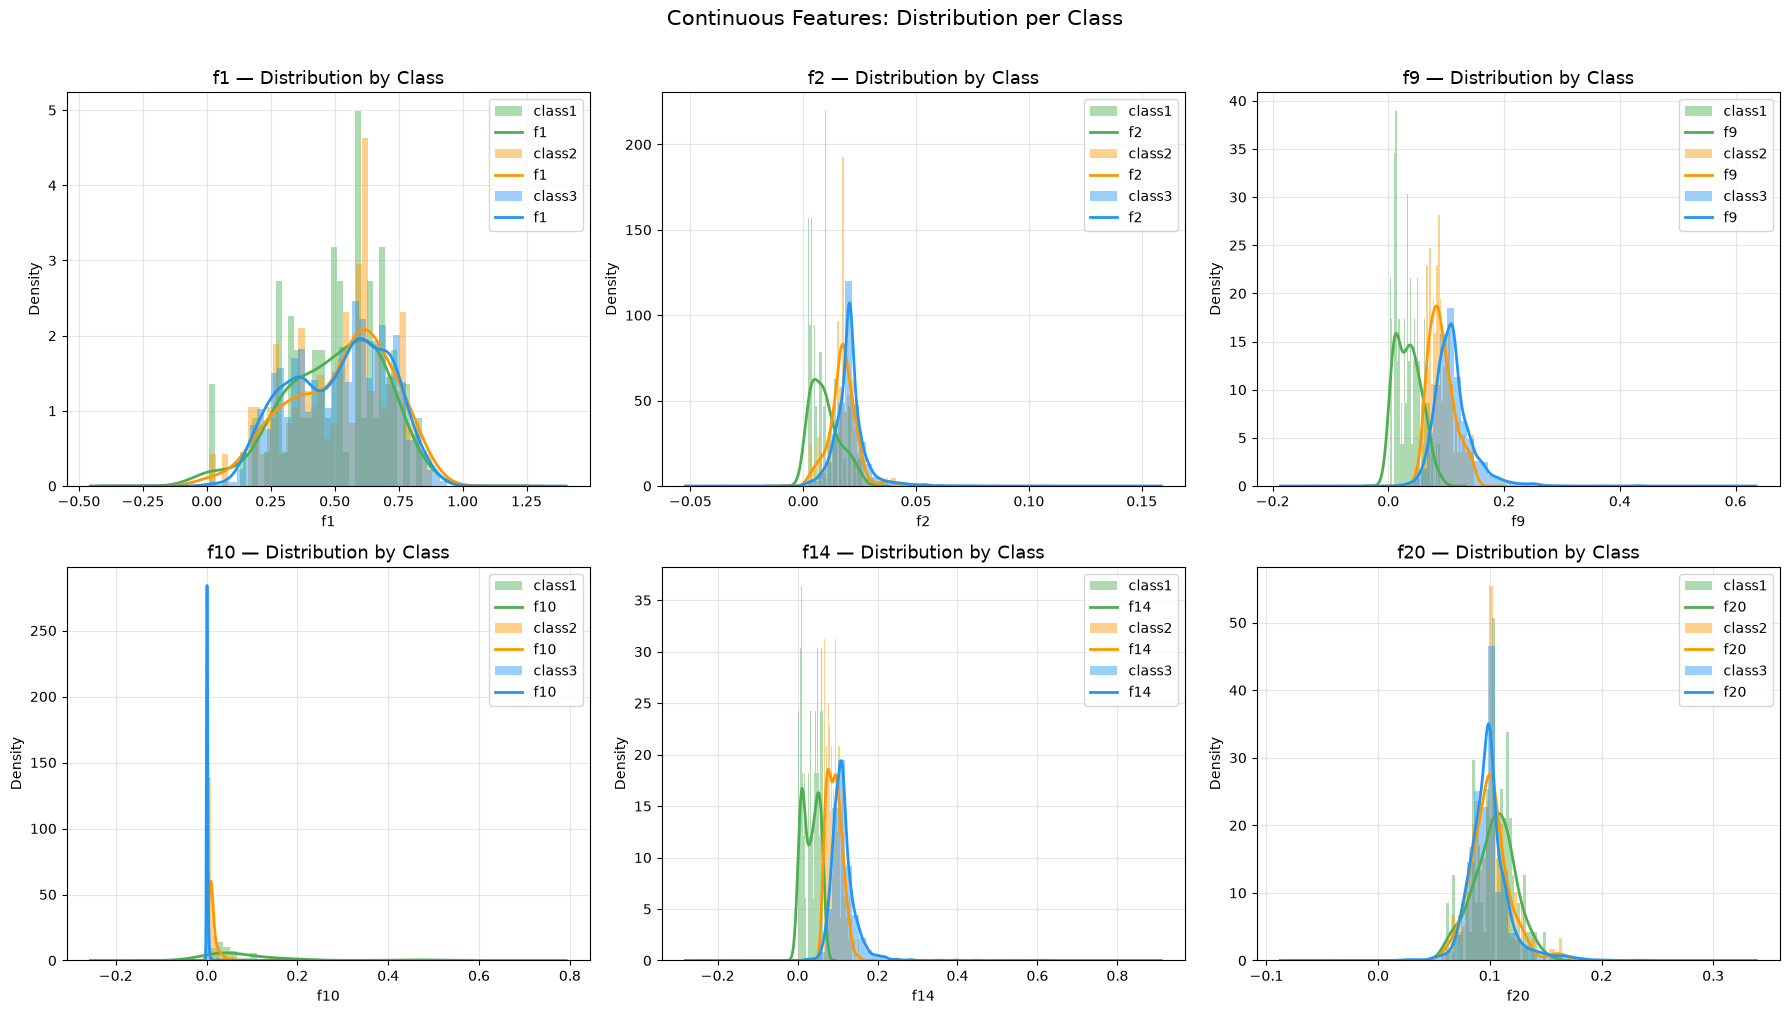

In [39]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    for cls in classes:
        sub = train[train['target'] == cls][col]
        axes[i].hist(sub, bins=35, alpha=0.45,
                     label=cls, color=colors[cls], density=True)
        sub.plot.kde(ax=axes[i], color=colors[cls], linewidth=2)
    axes[i].set_title(f'{col} — Distribution by Class', fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(alpha=0.3)

plt.suptitle('Continuous Features: Distribution per Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Boxplot for each Feature for each Class

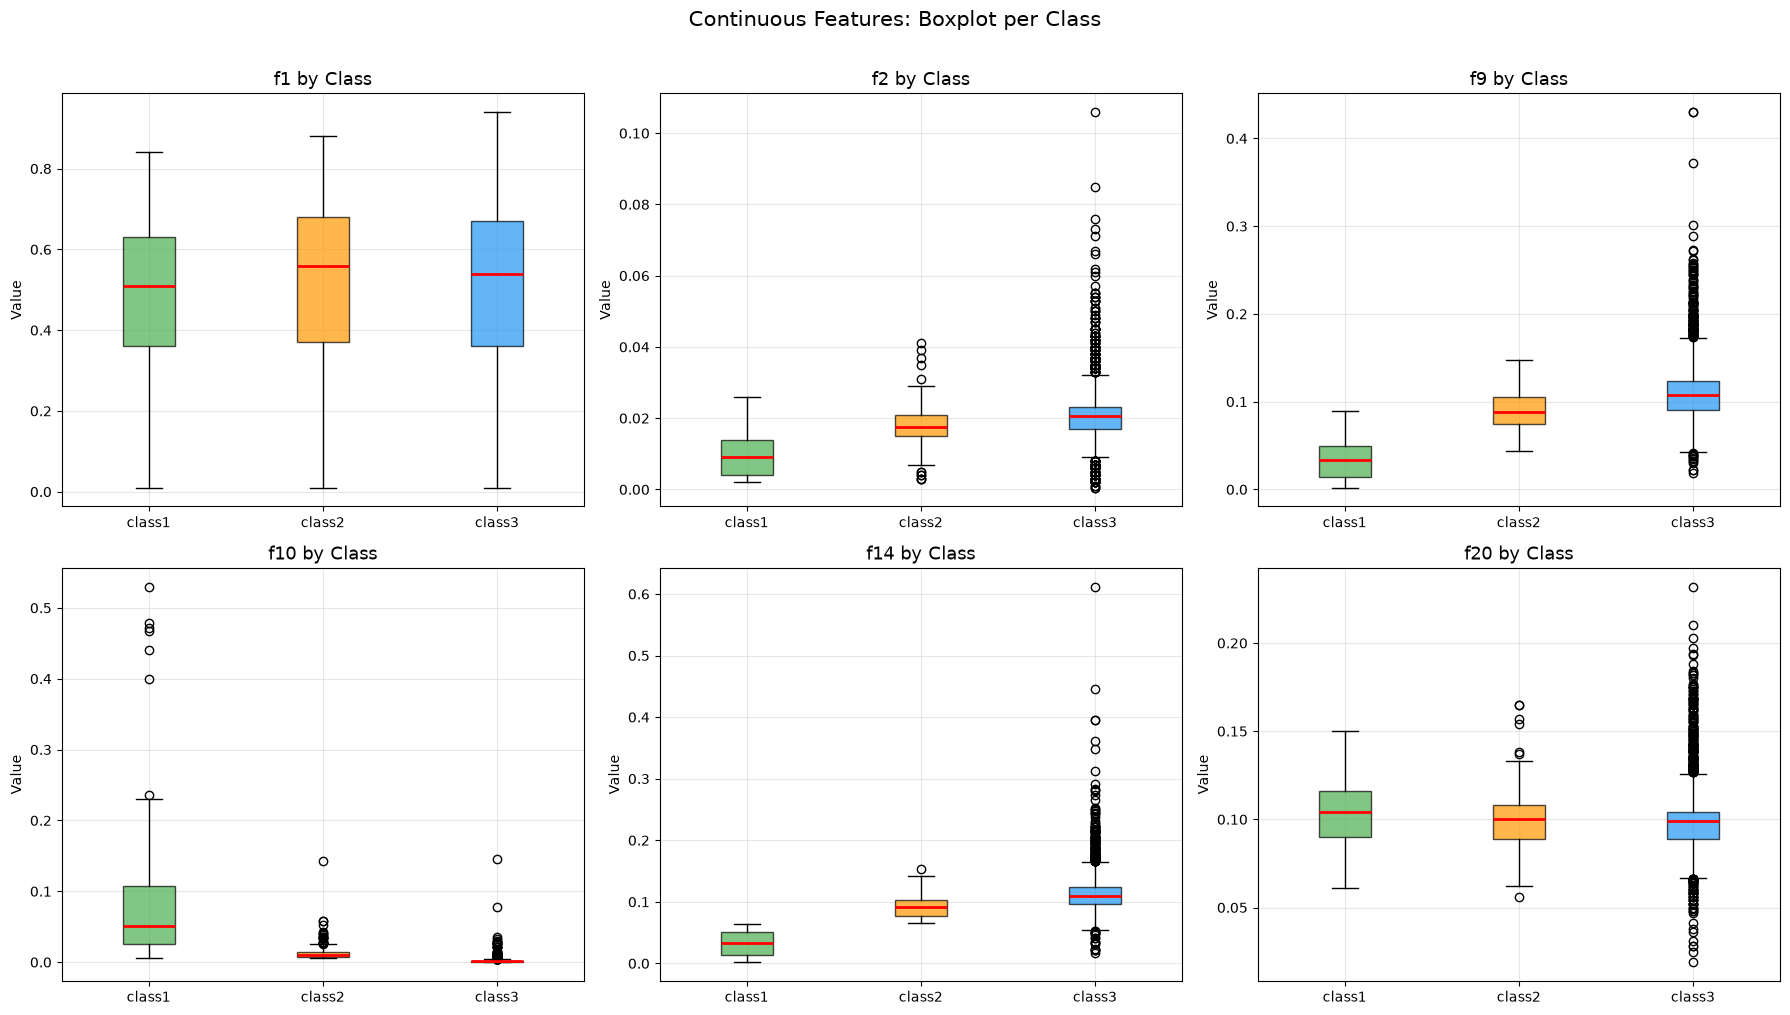

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    data = [train[train['target'] == cls][col].values for cls in classes]
    bp   = axes[i].boxplot(data, patch_artist=True,
                           tick_labels=classes,
                           medianprops=dict(color='red', linewidth=2))
    for patch, cls in zip(bp['boxes'], classes):
        patch.set_facecolor(colors[cls])
        patch.set_alpha(0.7)
    axes[i].set_title(f'{col} by Class', fontsize=13)
    axes[i].set_ylabel('Value')
    axes[i].grid(alpha=0.3)

plt.suptitle('Continuous Features: Boxplot per Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('eda_02_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

Pairwise Relationships between Continuous Features


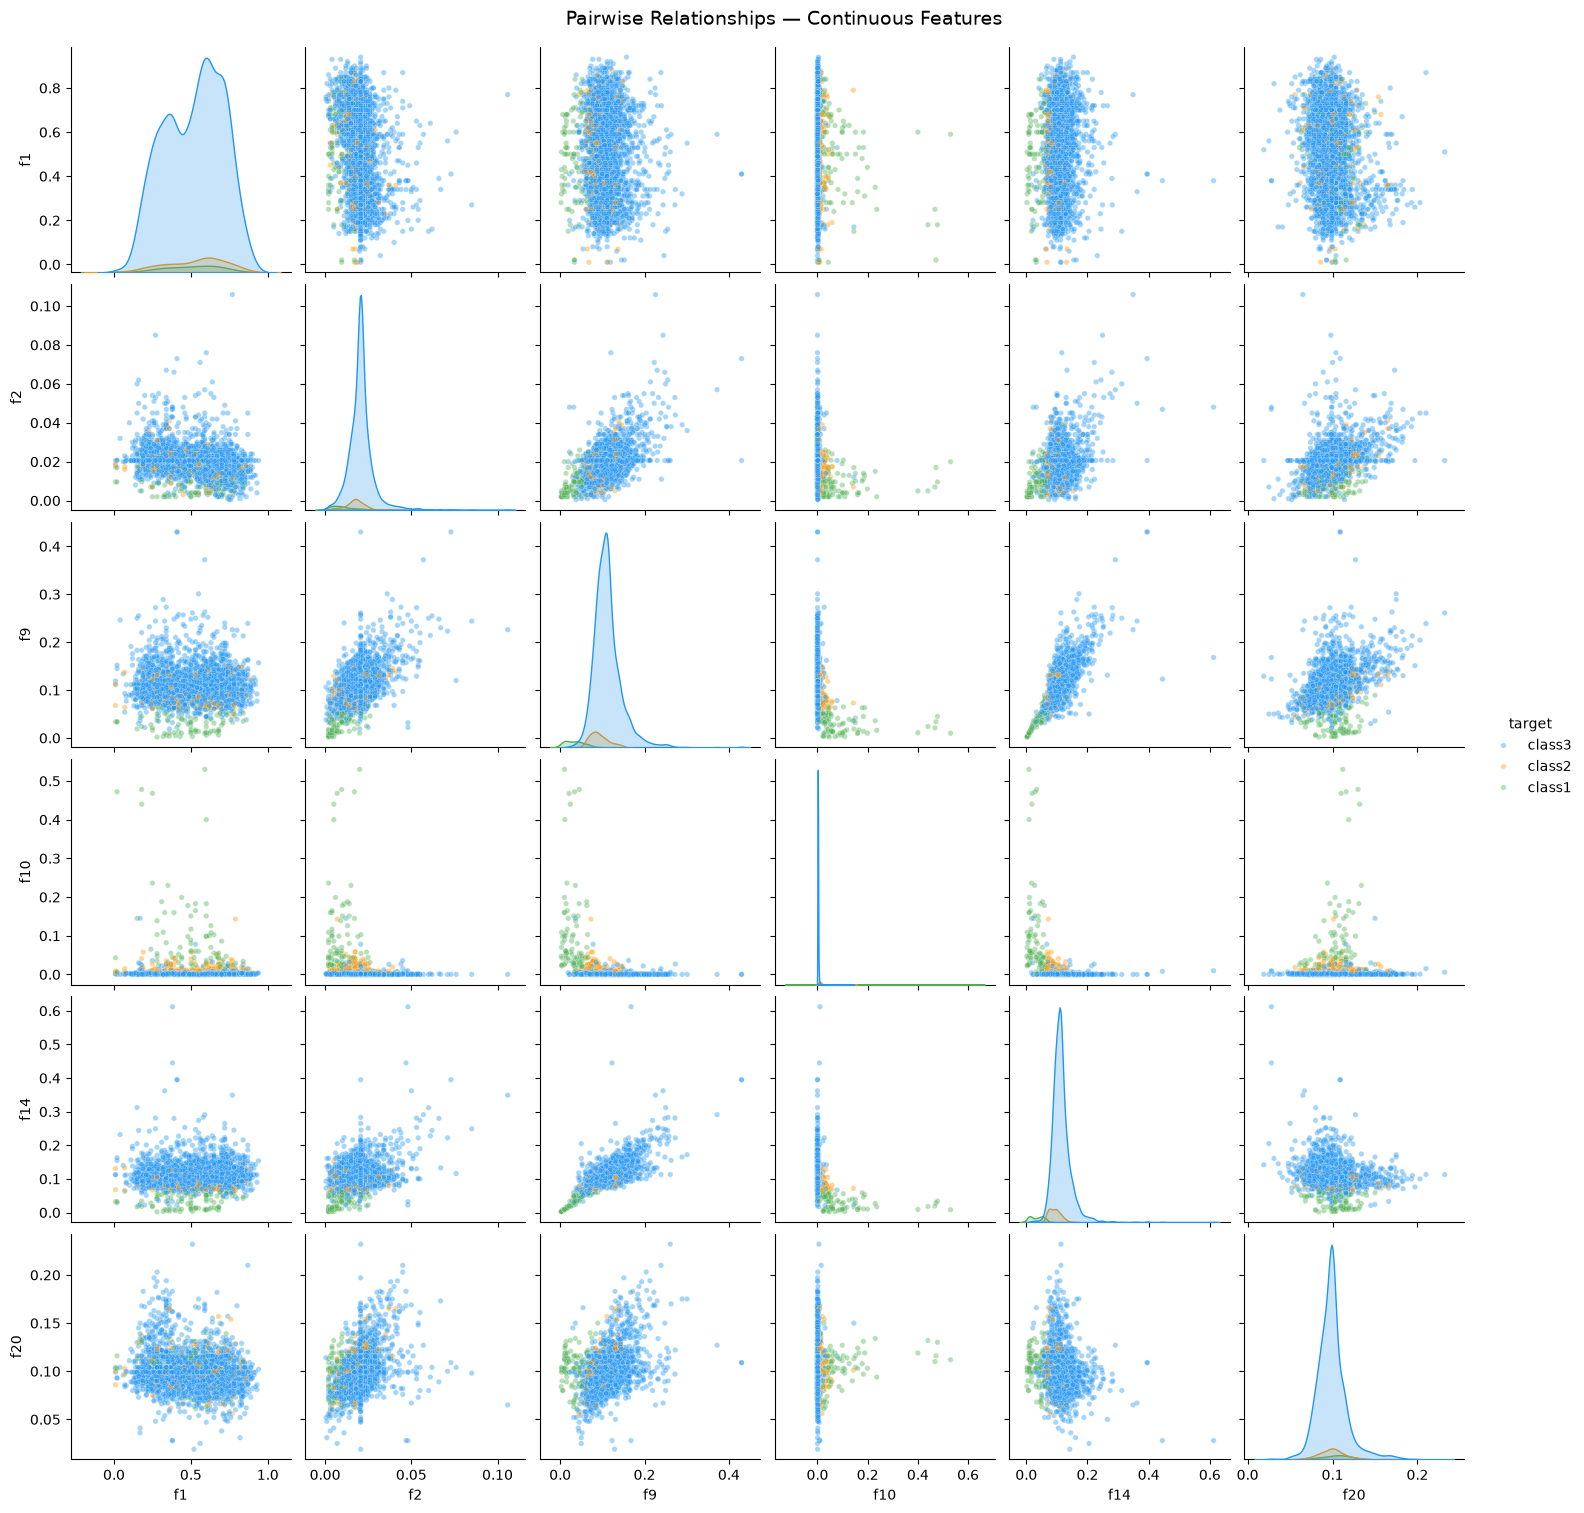

In [41]:
df_plot = train[continuous_cols + ['target']].copy()

g = sns.pairplot(df_plot, hue='target',
                 palette=colors,
                 plot_kws=dict(alpha=0.4, s=15),
                 diag_kind='kde')
g.fig.suptitle('Pairwise Relationships — Continuous Features', y=1.01, fontsize=14)
plt.savefig('eda_03_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

Correlation Matrix

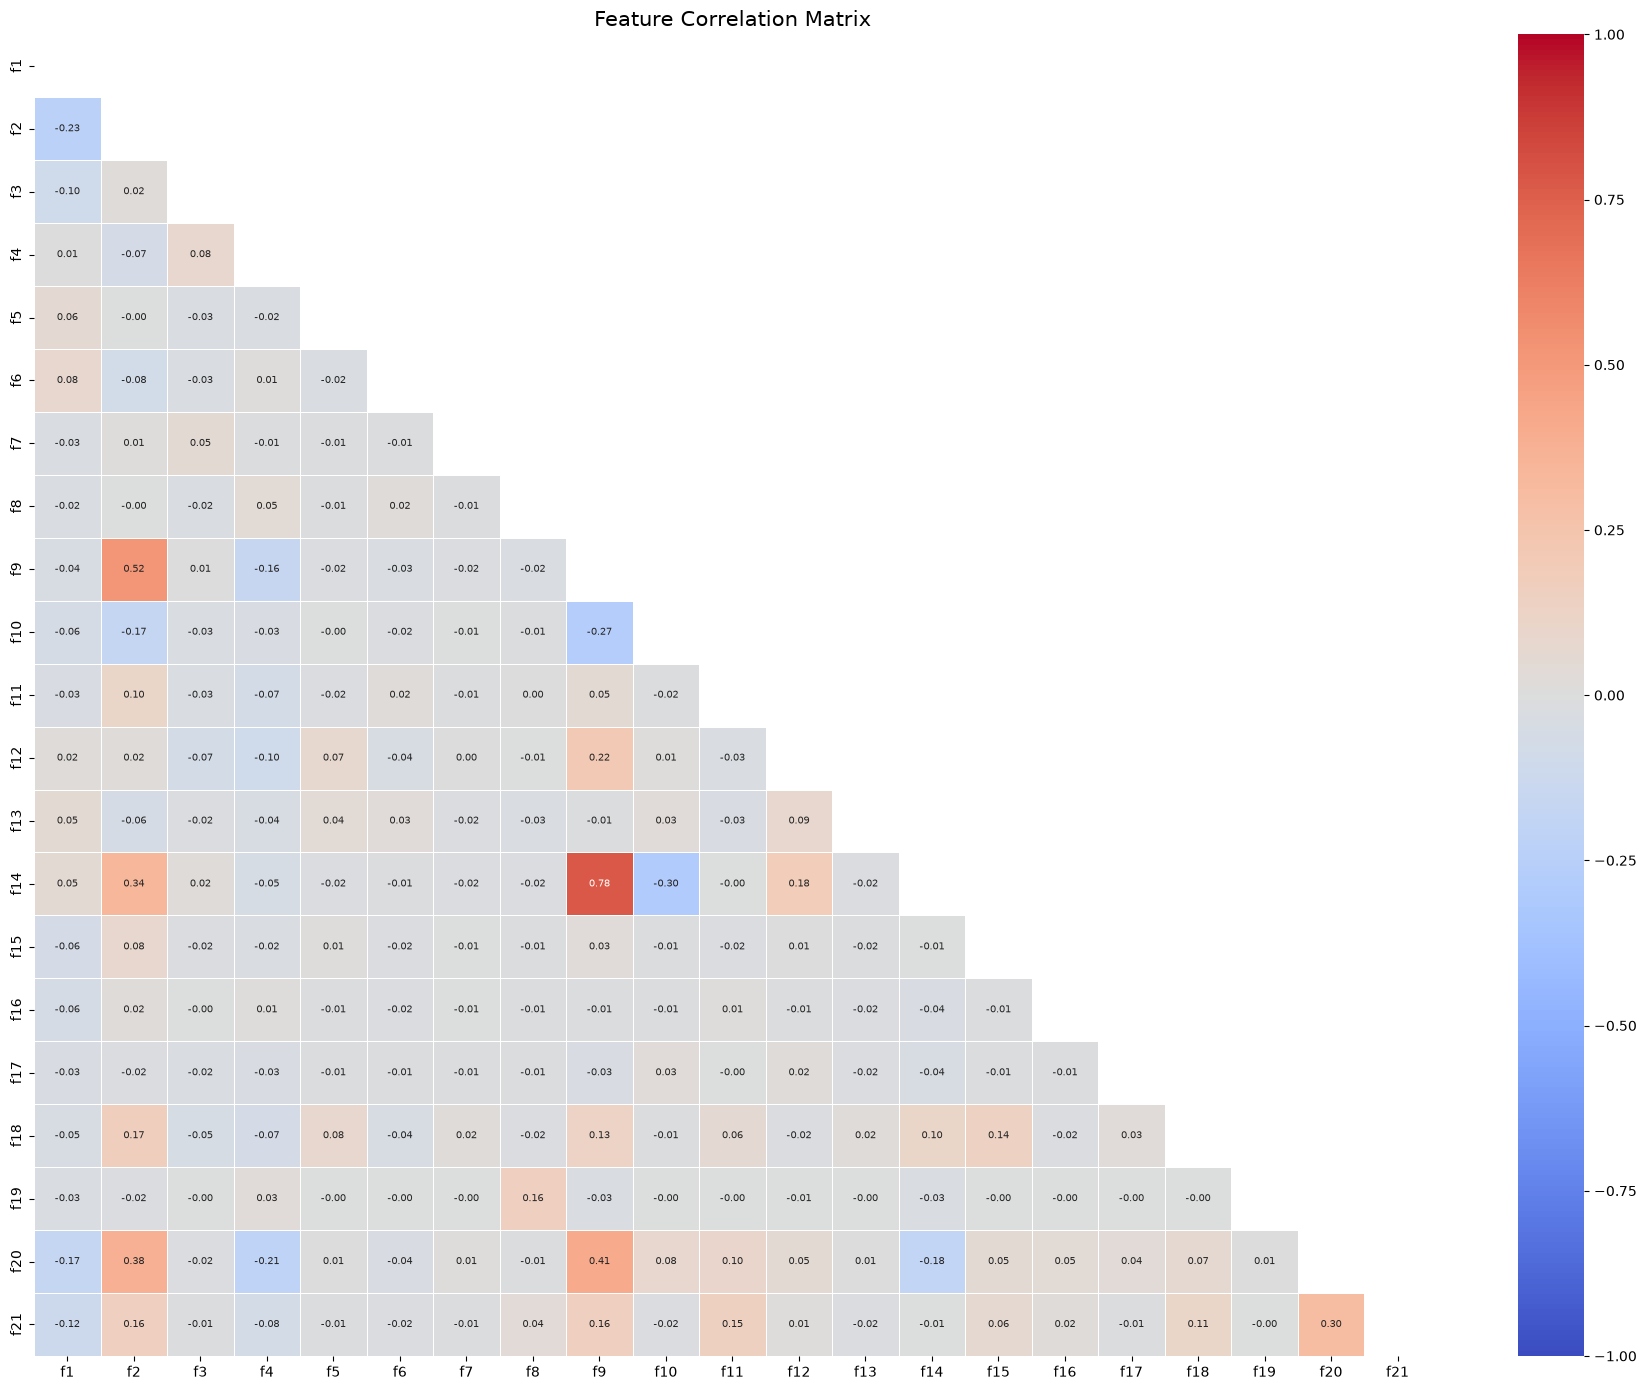


Top Correlations (|r| > 0.3):
f14  f9     0.776560
f2   f9     0.521466
f9   f20    0.412800
f20  f2     0.382653
f2   f14    0.338441
f21  f20    0.300307
dtype: float64


In [42]:
corr = train[feature_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 7}, linewidths=0.4)
ax.set_title('Feature Correlation Matrix', fontsize=15)
plt.tight_layout()
plt.savefig('eda_04_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop Correlations (|r| > 0.3):')
pairs = corr.abs().unstack()
pairs = pairs[pairs < 1.0].sort_values(ascending=False)
print(pairs[pairs > 0.3].drop_duplicates().head(15))

 Correlation between Targets for each Feature

In [43]:
print('Correlation with Target (per class — one-vs-rest):')
print('=' * 55)

results = []
for col in feature_cols:
    for cls in classes:
        y_bin = (train['target'] == cls).astype(int)
        r, p  = stats.pointbiserialr(train[col], y_bin)
        results.append({'feature': col, 'class': cls,
                        'correlation': round(r, 4), 'p_value': round(p, 4)})

df_corr = pd.DataFrame(results)
for cls in classes:
    print(f'\n── {cls} ──')
    sub = df_corr[df_corr['class'] == cls].sort_values(
        'correlation', key=abs, ascending=False)
    print(sub[['feature', 'correlation', 'p_value']].to_string(index=False))

Correlation with Target (per class — one-vs-rest):

── class1 ──
feature  correlation  p_value
    f10       0.6080   0.0000
    f14      -0.3873   0.0000
     f9      -0.3645   0.0000
     f2      -0.2418   0.0000
    f20       0.0423   0.0168
    f13       0.0405   0.0219
     f3      -0.0376   0.0336
     f6      -0.0347   0.0494
     f4      -0.0244   0.1677
    f21      -0.0202   0.2535
    f18      -0.0199   0.2616
     f8      -0.0192   0.2771
    f15      -0.0185   0.2967
     f1      -0.0165   0.3493
    f16      -0.0150   0.3951
    f12      -0.0137   0.4377
    f17       0.0134   0.4495
     f7      -0.0123   0.4880
     f5       0.0098   0.5793
    f11      -0.0042   0.8126
    f19      -0.0031   0.8627

── class2 ──
feature  correlation  p_value
    f14      -0.1303   0.0000
     f9      -0.1171   0.0000
    f12      -0.0943   0.0000
     f2      -0.0894   0.0000
    f10       0.0882   0.0000
    f13       0.0831   0.0000
     f4      -0.0447   0.0115
    f21      -0.0294 

 Mutual Information

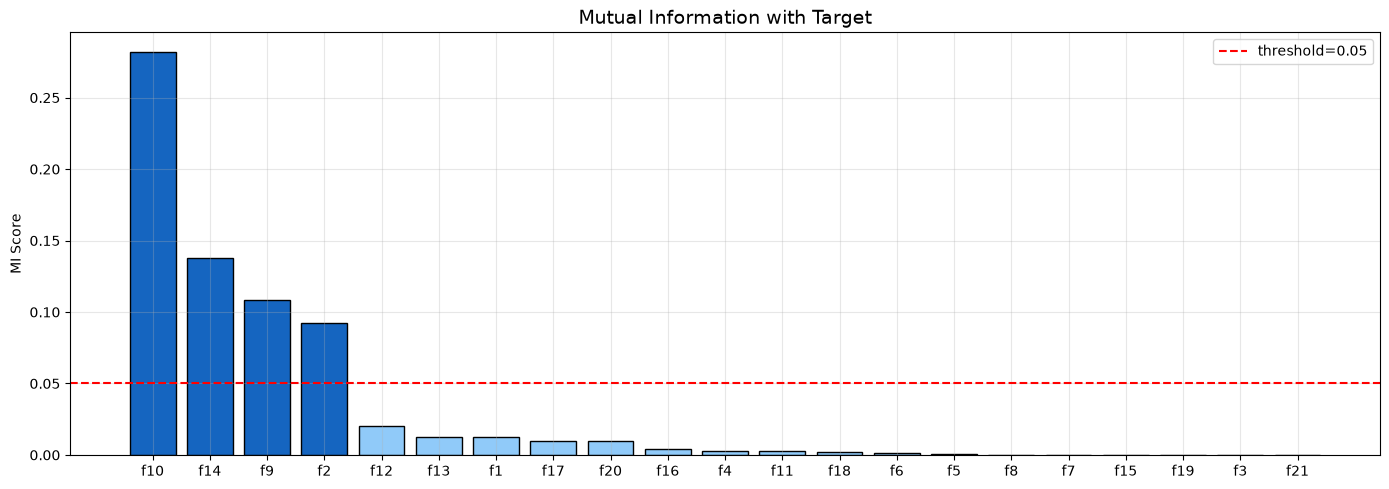

f10    0.2818
f14    0.1380
f9     0.1082
f2     0.0921
f12    0.0206
f13    0.0127
f1     0.0122
f17    0.0096
f20    0.0095
f16    0.0042
f4     0.0029
f11    0.0027
f18    0.0023
f6     0.0011
f5     0.0007
f8     0.0000
f7     0.0000
f15    0.0000
f19    0.0000
f3     0.0000
f21    0.0000
dtype: float64


In [44]:
mi    = mutual_info_classif(train[feature_cols], y, random_state=42)
mi_df = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
colors_mi = ['#1565C0' if v > 0.05 else '#90CAF9' for v in mi_df.values]
ax.bar(mi_df.index, mi_df.values, color=colors_mi, edgecolor='black')
ax.axhline(0.05, color='red', linestyle='--', label='threshold=0.05')
ax.set_title('Mutual Information with Target', fontsize=14)
ax.set_ylabel('MI Score')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('eda_05_mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()
print(mi_df.round(4))

 Feature Ratios / Importent Interactions 

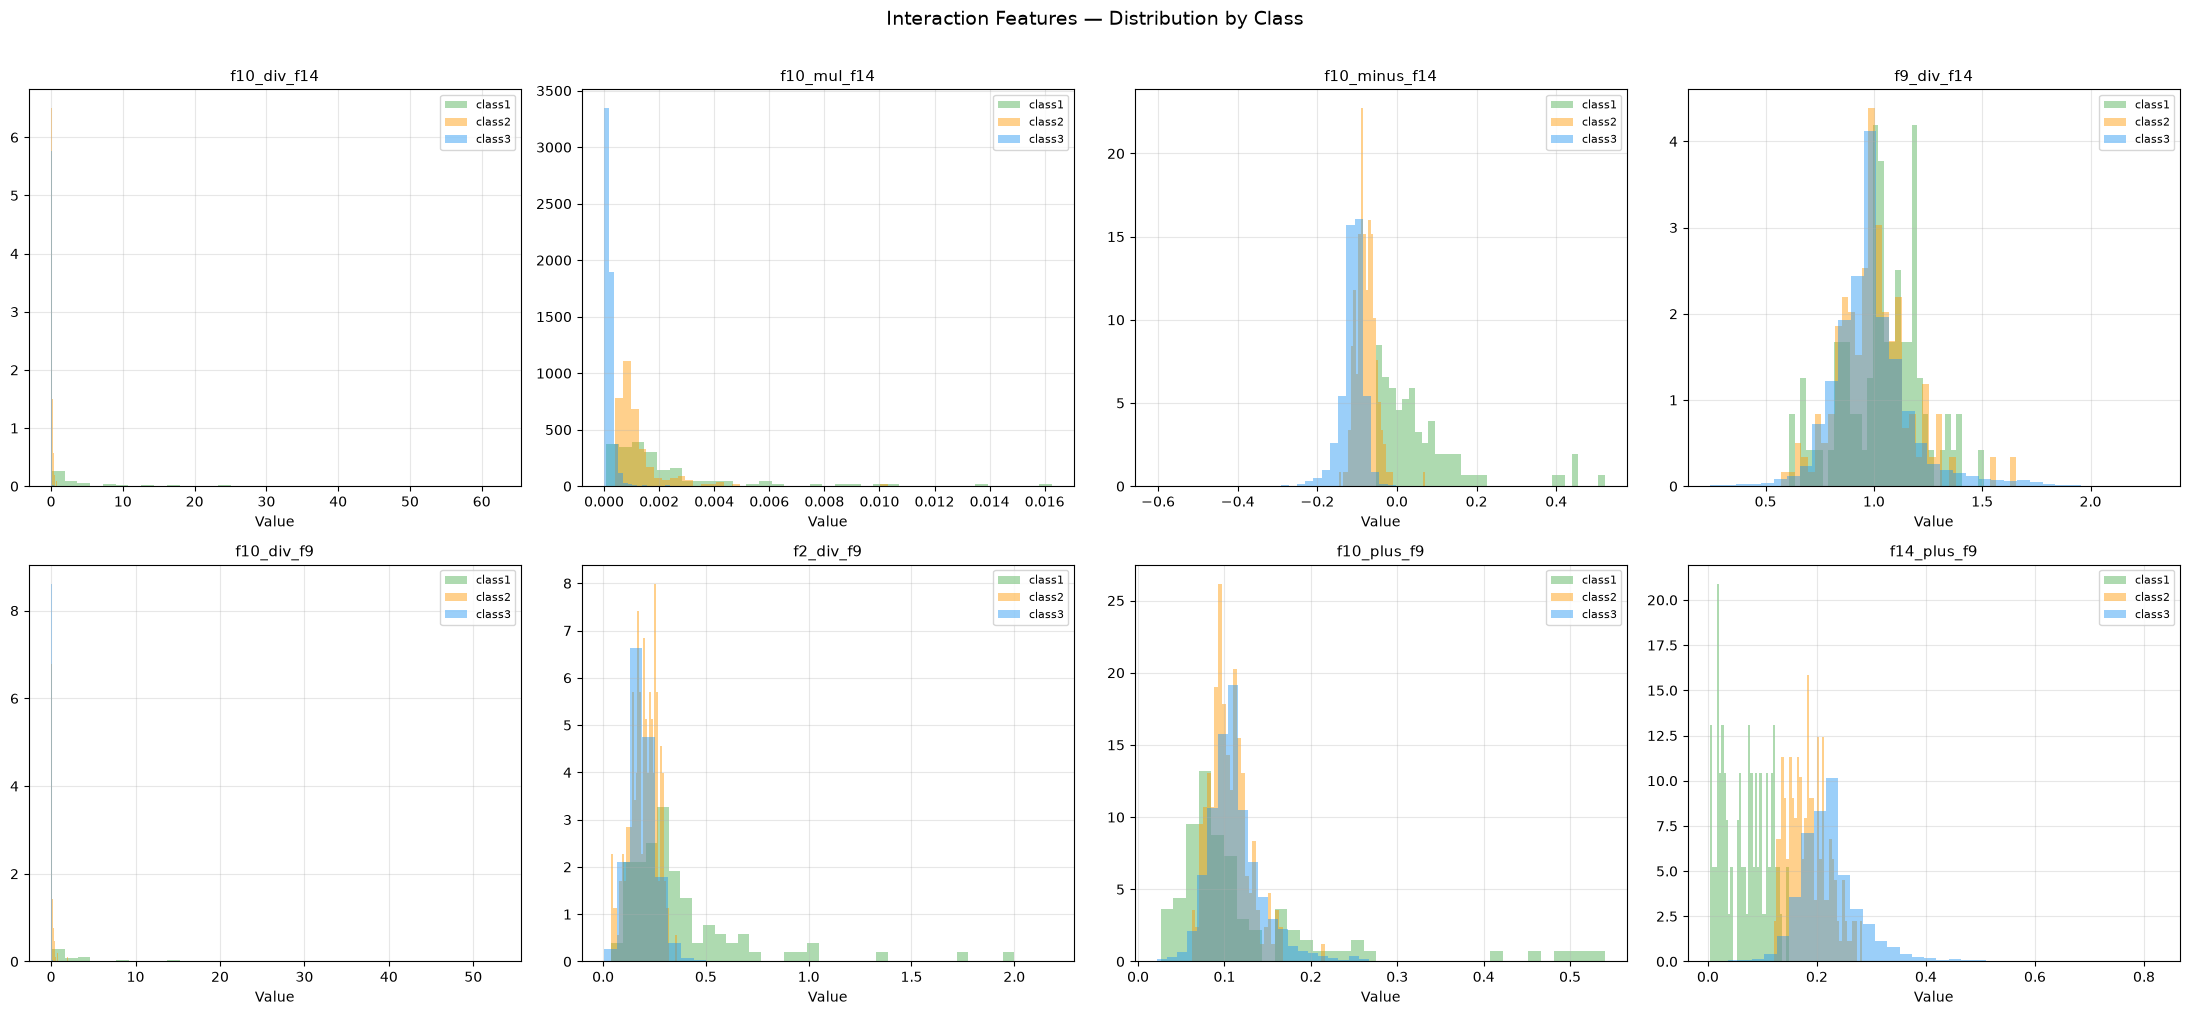

In [45]:
interactions = {
    'f10_div_f14'  : train['f10'] / (train['f14'] + 1e-8),
    'f10_mul_f14'  : train['f10'] * train['f14'],
    'f10_minus_f14': train['f10'] - train['f14'],
    'f9_div_f14'   : train['f9']  / (train['f14'] + 1e-8),
    'f10_div_f9'   : train['f10'] / (train['f9']  + 1e-8),
    'f2_div_f9'    : train['f2']  / (train['f9']  + 1e-8),
    'f10_plus_f9'  : train['f10'] + train['f9'],
    'f14_plus_f9'  : train['f14'] + train['f9'],
}

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, (name, values) in enumerate(interactions.items()):
    df_tmp = pd.DataFrame({'val': values, 'target': train['target']})
    for cls in classes:
        sub = df_tmp[df_tmp['target'] == cls]['val']
        axes[i].hist(sub, bins=35, alpha=0.45,
                     label=cls, color=colors[cls], density=True)
    axes[i].set_title(name, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.suptitle('Interaction Features — Distribution by Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_06_interactions.png', dpi=150, bbox_inches='tight')
plt.show()

MI for new Interactions 

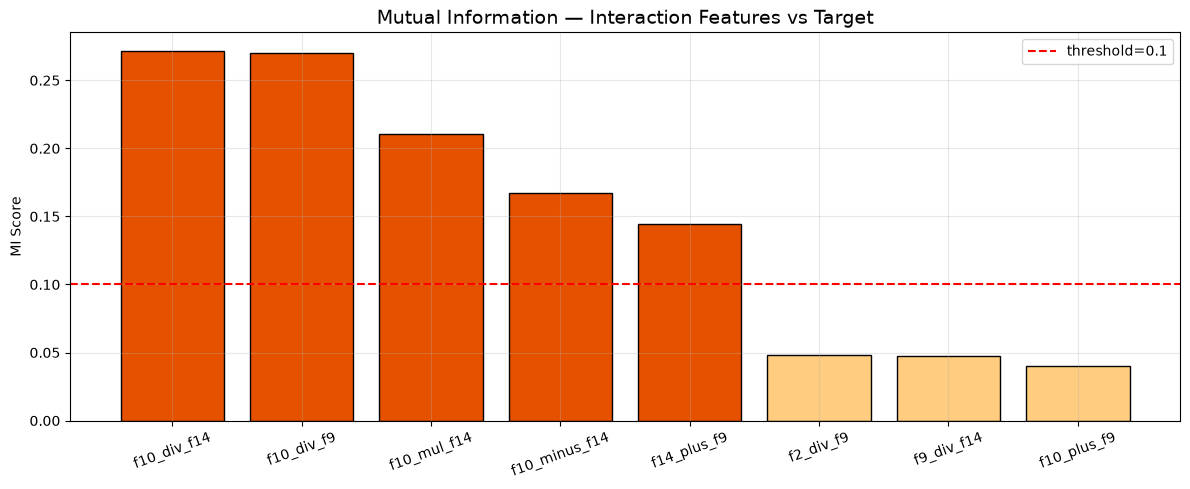

f10_div_f14      0.2718
f10_div_f9       0.2702
f10_mul_f14      0.2107
f10_minus_f14    0.1674
f14_plus_f9      0.1441
f2_div_f9        0.0483
f9_div_f14       0.0472
f10_plus_f9      0.0401
dtype: float64


In [46]:
df_interact = pd.DataFrame(interactions)
mi_int = mutual_info_classif(df_interact, y, random_state=42)
mi_int_df = pd.Series(mi_int, index=df_interact.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
colors_int = ['#E65100' if v > 0.1 else '#FFCC80' for v in mi_int_df.values]
ax.bar(mi_int_df.index, mi_int_df.values, color=colors_int, edgecolor='black')
ax.axhline(0.1, color='red', linestyle='--', label='threshold=0.1')
ax.set_title('Mutual Information — Interaction Features vs Target', fontsize=14)
ax.set_ylabel('MI Score')
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('eda_07_interaction_mi.png', dpi=150, bbox_inches='tight')
plt.show()
print(mi_int_df.round(4))

# ملخص EDA الشامل — Anonymized Classification Challenge
### الأساس لمرحلة الـ Feature Engineering

---

## 1. البنية العامة للداتا

| العنصر | القيمة |
|--------|--------|
| حجم Train | 3200 صف × 23 عمود |
| حجم Test | 3200 صف × 22 عمود |
| القيم المفقودة | لا يوجد (0%) |
| الصفوف المكررة | لا يوجد |
| نوع الـ Features | 6 عددية مستمرة + 15 ثنائية (0/1) |
| التوزيع بين Train وTest | متطابق تماماً — لا يوجد domain shift |

**الـ Features العددية المستمرة:** f1, f2, f9, f10, f14, f20

**الـ Features الثنائية (0/1):** f3, f4, f5, f6, f7, f8, f11, f12, f13, f15, f16, f17, f18, f19, f21

---

## 2. مشكلة الـ Class Imbalance — حرجة جداً

| الكلاس | العدد | النسبة |
|--------|-------|--------|
| class3 | 2916 | 91.1% |
| class2 | 191 | 6.0% |
| class1 | 93 | 2.9% |

**الملاحظة الغريبة والمهمة:** رغم أن class1 أقل عدداً من class2، إلا أن الموديلات تميزها بشكل أفضل. السبب ليس العدد، بل أن class1 تملك **خصائص مميزة جداً في الـ feature space** — وهذا سيتضح في الأقسام التالية.

---

## 3. إحصائيات كل Feature لكل Class — الصورة الكاملة

### 3.1 الـ Features العددية المستمرة

| Feature | class1 (mean) | class2 (mean) | class3 (mean) | الاتجاه | القوة التمييزية |
|---------|--------------|--------------|--------------|---------|----------------|
| **f10** | **0.0934** | 0.0140 | 0.0018 | class1 أعلى بفارق كبير |  الأقوى |
| **f14** | 0.0330 | 0.0921 | **0.1135** | class3 أعلى — عكس f10 | 🟠 قوي |
| **f9** | 0.0338 | 0.0916 | **0.1114** | class3 أعلى — نفس f14 | 🟠 قوي |
| **f2** | 0.0097 | 0.0175 | **0.0206** | class3 أعلى — نفس الاتجاه | 🟡 متوسط |
| **f20** | 0.1038 | 0.1000 | 0.0990 | متقاربة جداً |  ضعيفة |
| **f1** | 0.4987 | 0.5243 | 0.5170 | متداخلة كلياً |  ضعيفة جداً |

**القراءة التحليلية:**

- **f10** هي المفتاح الأساسي لتمييز **class1** — فرق الـ mean بين class1 (0.093) وclass3 (0.002) هائل جداً ونادر في الداتا المجهولة.
- **f14 وf9** يسيران بنفس الاتجاه ومرتبطان بقوة (r = 0.78) — يقيسان تقريباً نفس الظاهرة.
- **f20** رغم ارتباطها بـ f9 (r = 0.41) إلا أن قيمها متقاربة جداً بين الكلاسات مما يجعلها redundant.
- **f1** عديمة الفائدة تقريباً للتمييز — التوزيعات متداخلة كلياً.

### 3.2 الـ Features الثنائية (0/1) — نسبة الـ 1 لكل class

| Feature | class1 | class2 | class3 | الملاحظة |
|---------|--------|--------|--------|----------|
| f4 | 23.7% | 22.0% | 30.9% | موزعة بشكل متقارب — لا تمييز |
| f12 | 9.7% | 0.0% | 13.2% | معدومة في class2 — مميزة لها |
| f13 | 11.8% | 14.1% | 5.5% | أعلى في class1/class2 — مميزة لـ class3 |
| f18 | 3.2% | 6.3% | 6.0% | فرق محدود |
| f3, f5, f6, f7, f8, f11, f15, f16, f17, f19, f21 | < 5% | < 5% | < 5% | نادرة في كل الكلاسات — noise |

**الاستنتاج:** معظم الـ features الثنائية ذات قيمة منخفضة جداً. f12 وf13 هما الوحيدتان اللتان تضيفان معلومة محدودة، خصوصاً أن f12 معدومة تماماً في class2 (0.0%).

---

## 4. Mutual Information — قياس موضوعي لقوة كل Feature

**MI يقيس العلاقة الخطية وغير الخطية معاً بين الـ feature والـ target.**

| Feature | MI Score | التقييم |
|---------|----------|---------|
| **f10** | **0.2818** |  الأقوى بفارق كبير |
| **f14** | 0.1380 | 🟠 قوي |
| **f9** | 0.1082 | 🟠 قوي |
| **f2** | 0.0921 | 🟡 متوسط |
| f12 | 0.0206 | 🟢 ضعيف |
| f13 | 0.0127 | 🟢 ضعيف جداً |
| f1 | 0.0122 | 🟢 ضعيف جداً |
| f3, f7, f8, f15, f19, f21 | **0.0000** |  معدوم |

**f10 تحمل ثلاثة أضعاف معلومات f14** — هذا رقم استثنائي يفسر لماذا الموديلات تشتغل كويس حتى بدون أي تعديل.

---

## 5. الارتباطات بين الـ Features — خطر الـ Multicollinearity

| الزوج | معامل الارتباط | التفسير |
|-------|---------------|---------|
| f9 ↔ f14 | **0.777** | ارتباط قوي جداً — يقيسان نفس الشيء تقريباً |
| f2 ↔ f9 | 0.521 | ارتباط متوسط |
| f20 ↔ f9 | 0.413 | ارتباط متوسط |
| f20 ↔ f2 | 0.383 | ارتباط متوسط |
| f14 ↔ f2 | 0.338 | ارتباط خفيف |
| f20 ↔ f21 | 0.300 | ارتباط خفيف |

**التحليل:** f2, f9, f14, f20 تشكل مجموعة مترابطة تقيس ظاهرة واحدة بزوايا مختلفة. هذا يعني أن إنشاء features تعتمد على النسب بينها (ratios) يمكن أن يكشف معلومات مخفية أقوى من كل feature بمفردها.

---

## 6. الارتباط مع الـ Target — من يميز من؟

### class1 — من يميزها؟

| Feature | الارتباط | الاتجاه |
|---------|----------|---------|
| **f10** | **+0.608** | f10 مرتفعة = class1 |
| f14 | -0.387 | f14 منخفضة = class1 |
| f9 | -0.365 | f9 منخفضة = class1 |
| f2 | -0.242 | f2 منخفضة = class1 |

class1 لها **بصمة واضحة جداً:** f10 مرتفعة + f14/f9 منخفضة.

### class2 — من يميزها؟

| Feature | الارتباط | الاتجاه |
|---------|----------|---------|
| f14 | -0.130 | f14 متوسطة |
| f9 | -0.117 | f9 متوسطة |
| f12 | -0.094 | f12 = 0 دائماً |
| f10 | +0.088 | f10 أعلى من class3 |

class2 هي الأصعب تمييزاً لأنها تقع **بين** class1 وclass3 في معظم الـ features.

### class3 — من يميزها؟

| Feature | الارتباط | الاتجاه |
|---------|----------|---------|
| **f10** | **-0.433** | f10 منخفضة جداً = class3 |
| f14 | +0.337 | f14 مرتفعة = class3 |
| f9 | +0.313 | f9 مرتفعة = class3 |

class3 بصمتها عكس class1 تماماً: f10 قريبة من الصفر + f14/f9 مرتفعة.

---

## 7. الـ Outliers

| Feature | عدد الـ Outliers | النسبة | الملاحظة |
|---------|----------------|--------|----------|
| **f10** | **387** | **12.1%** | الأعلى — وهذه تخص class1/class2 غالباً |
| f2 | 288 | 9.0% | right-skewed |
| f14 | 223 | 7.0% | right-skewed |
| f20 | 178 | 5.6% | right-skewed |
| f9 | 189 | 5.9% | right-skewed |
| **f1** | **0** | **0.0%** | نظيفة تماماً |

**ملاحظة مهمة:** الـ outliers في f10 ليست noise — هي class1 وclass2 الذين لديهم قيم f10 عالية. إزالتها ستضر بالتمييز.

---

## 8. الـ Interaction Features — الفرصة الذهبية

اختبرنا 8 interactions مختلفة وقسنا قيمة الـ MI لكل منها:

| Feature الجديدة | الصيغة | MI Score | التفسير |
|----------------|--------|----------|---------|
| **f10_div_f14** | f10 / f14 | **0.2718** |  ممتازة — تجمع أقوى featureين بنسبة |
| **f10_div_f9** | f10 / f9 | **0.2702** |  ممتازة — نفس الفكرة مع f9 |
| f10_mul_f14 | f10 × f14 | 0.2107 | 🟠 جيدة |
| f10_minus_f14 | f10 − f14 | 0.1674 | 🟠 جيدة |
| f14_plus_f9 | f14 + f9 | 0.1441 | 🟡 متوسطة |
| f2_div_f9 | f2 / f9 | 0.0483 | 🟢 محدودة |
| f9_div_f14 | f9 / f14 | 0.0472 | 🟢 محدودة |
| f10_plus_f9 | f10 + f9 | 0.0401 | 🟢 محدودة |

**الاستنتاج الرئيسي:** f10_div_f14 وf10_div_f9 تحققان MI قريباً جداً من f10 الأصلية (0.27 مقابل 0.28)، وهذا يعني أنهما تضيفان زاوية نظر مختلفة ومكملة — وليست مجرد نسخة من f10.

---

## 9. درس الـ Sampling — ماذا تعلمنا؟

جربنا **8 تجارب مختلفة** من الـ Sampling والـ Augmentation:

| التجربة | أفضل نتيجة (F1-Macro) | مقارنة بالـ Baseline |
|---------|----------------------|---------------------|
| Baseline LGB | **0.9889** | المرجع |
| SMOTE (2916) | 0.9802 |  أسوأ |
| SMOTE (500/600) | 0.9889 | = مساوٍ |
| SMOTE (139/764) | 0.9846 |  أسوأ |
| SMOTE (200/900) | 0.9846 |  أسوأ |
| SMOTE + AUG (Gaussian) | 0.9561 |  أسوأ بكثير |
| SMOTE + AUG (200/900) | 0.9517 |  أسوأ بكثير |
| SMOTE + AUG V2 (Noise+Scale+Mixup) | 0.9586 |  أسوأ بكثير |

**الرسالة الواضحة:** الداتا تملك تمييزاً طبيعياً قوياً جداً بسبب f10/f14/f9. أي تعديل على توزيع الداتا يخل بهذا التمييز ويضر أكثر مما يفيد. الموديلات القوية لا تحتاج مساعدة في هذا الجانب.

---

## 10. ملخص نتائج الـ Baseline

| الموديل | F1-Macro | class1 | class2 | class3 | الاستقرار (Std) |
|---------|----------|--------|--------|--------|----------------|
| **LGB** | **0.9889** | 0.9895 | 0.9788 | 0.9983 | ±0.0116 |
| CatBoost | 0.9884 | 0.9843 | **0.9825** | 0.9983 | ±0.0097 |
| RF | 0.9839 | 0.9843 | 0.9700 | 0.9974 | **±0.0065** |
| XGB | 0.9810 | 0.9732 | 0.9711 | **0.9986** | ±0.0109 |
| SVM | 0.6842 | 0.7910 | 0.2915 | 0.9700 | ±0.0369 |
| KNN | 0.6947 | 0.8308 | 0.2825 | 0.9707 | ±0.0440 |

**الخلاصة:**
- Tree-based models هي الفائزة على هذه الداتا
- LGB = أفضل F1-Macro إجمالي
- CatBoost = أفضل على class2 (المشكلة الأصعب)
- RF = الأكثر استقراراً
- SVM وKNN غير مناسبين لهذا النوع من الداتا

---

## 11. خطة الـ Feature Engineering — المرحلة القادمة

بناءً على كل ما سبق، الـ features الجديدة المقترحة مرتبة حسب الأولوية:

### المجموعة الأولى — Ratio Features (الأعلى أولوية)

هذه المجموعة تستغل العلاقة العكسية بين f10 من جهة وf14/f9 من جهة أخرى.

| الـ Feature | الصيغة | السبب |
|------------|--------|-------|
| f10_div_f14 | f10 / (f14 + ε) | MI = 0.2718 — تمييز استثنائي |
| f10_div_f9 | f10 / (f9 + ε) | MI = 0.2702 — نفس القوة |
| f10_div_f14_f9 | f10 / (f14 + f9 + ε) | f10 مقابل المجموع |

### المجموعة الثانية — Difference Features

| الـ Feature | الصيغة | السبب |
|------------|--------|-------|
| f10_minus_f14 | f10 − f14 | MI = 0.1674 — موجب لـ class1، سالب لـ class3 |
| f10_minus_f9 | f10 − f9 | نفس الفكرة |
| f14_minus_f9 | f14 − f9 | يكشف الفرق بين المترابطين |

### المجموعة الثالثة — Normalized Features

| الـ Feature | الصيغة | السبب |
|------------|--------|-------|
| f10_norm | (f10 − f14) / (f10 + f14 + ε) | normalized difference بين −1 و+1 |
| f10_share | f10 / (f10 + f9 + f14 + ε) | نسبة مساهمة f10 من المجموع |

### المجموعة الرابعة — Log Transforms

| الـ Feature | الصيغة | السبب |
|------------|--------|-------|
| log_f10 | log(f10 + ε) | f10 right-skewed بـ 12.1% outliers |
| log_f14 | log(f14 + ε) | f14 right-skewed بـ 7% outliers |
| log_f9 | log(f9 + ε) | f9 right-skewed بـ 5.9% outliers |

### المجموعة الخامسة — Polynomial Features

| الـ Feature | الصيغة | السبب |
|------------|--------|-------|
| f10_sq | f10² | يضخم الفرق بين class1 وclass3 |
| f10_x_f2 | f10 × f2 | interaction بين f10 والـ feature المتوسطة |

---

## 12. الاستنتاج النهائي وتوقعاتنا

**ما فهمناه بشكل قاطع:**

الداتا تصف ظاهرة فيها ثلاثة حالات (كلاسات) يمكن تمييزها بشكل شبه كامل بناءً على قيمة f10 وعلاقتها بـ f14/f9:

- **class1:** f10 مرتفعة (mean ≈ 0.09) + f14/f9 منخفضة (mean ≈ 0.03)
- **class2:** f10 منخفضة (mean ≈ 0.01) + f14/f9 متوسطة (mean ≈ 0.09)
- **class3:** f10 معدومة تقريباً (mean ≈ 0.002) + f14/f9 مرتفعة (mean ≈ 0.11)

**التحدي الوحيد المتبقي** هو التمييز بين class2 وclass3 في منطقة التداخل — وهنا تأتي قيمة الـ Ratio Features مثل f10/f14 التي تحول هذا التداخل إلى تمييز أوضح.

**الهدف من الـ Feature Engineering** ليس إصلاح مشكلة — بل تحسين ما هو ممتاز أصلاً (0.9889) لدفعه فوق 0.99 إذا أمكن.

---

*تم إعداد هذا الملخص بناءً على:*
*EDA الأولي + تجارب Baseline (6 موديلات) + تجارب Class Weight + تجارب SMOTE بكل أشكالها + EDA المتقدم للـ Interactions*

## تجربة Feature Engineering V1

في هذه التجربة نضيف features يدوية مبنية على ratios والفروقات بين f10 و f14 و f9. الفرق عن التجارب السابقة أن التحسين أصبح في تمثيل الداتا وليس فقط الأوزان أو oversampling. سيتم تسجيل نسخة features وعددها ونتائج النماذج في MLflow.


In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
le = LabelEncoder()
y  = le.fit_transform(train['target'])




def add_features(df):
    eps = 1e-8
    df = df.copy()
    df['f10_div_f14']    = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']     = df['f10'] / (df['f9']  + eps)
    df['f10_div_f14_f9'] = df['f10'] / (df['f14'] + df['f9'] + eps)
    df['f10_minus_f14']  = df['f10'] - df['f14']
    df['f10_minus_f9']   = df['f10'] - df['f9']
    df['f10_norm']       = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']      = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['log_f10']        = np.log(df['f10'] + eps)
    return df

train_fe     = add_features(train)
feature_cols_fe = [c for c in train_fe.columns if c not in ['ID', 'target']]
X = train_fe[feature_cols_fe].values

binary_cols  = ['f3','f4','f5','f6','f7','f8','f11','f12','f13',
                'f15','f16','f17','f18','f19','f21']
cat_features = [feature_cols_fe.index(c) for c in binary_cols]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

mlflow.set_experiment('clf_experiments_FE')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]

            if needs_scaling:
                scaler = StandardScaler()
                X_tr   = scaler.fit_transform(X_tr)
                X_val  = scaler.transform(X_val)

            model.fit(X_tr, y_tr)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)

        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()




print('=' * 55)
print('  FE — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'FE_RF',
    model    = RandomForestClassifier(
                   n_estimators=200, random_state=42, n_jobs=-1),
    params   = {
        'model'         : 'RandomForest',
        'n_estimators'  : 200,
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'features_used' : 'all_21_plus_8_FE',
        'fe_features'   : 'f10_div_f14,f10_div_f9,f10_div_f14_f9,f10_minus_f14,f10_minus_f9,f10_norm,f10_share,log_f10',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
    }
)




print('=' * 55)
print('  FE — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'FE_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {
        'model'         : 'LightGBM',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'num_leaves'    : 31,
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'features_used' : 'all_21_plus_8_FE',
        'fe_features'   : 'f10_div_f14,f10_div_f9,f10_div_f14_f9,f10_minus_f14,f10_minus_f9,f10_norm,f10_share,log_f10',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
    },
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  FE — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'FE_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {
        'model'         : 'XGBoost',
        'n_estimators'  : 200,
        'learning_rate' : 0.1,
        'max_depth'     : 6,
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'features_used' : 'all_21_plus_8_FE',
        'fe_features'   : 'f10_div_f14,f10_div_f9,f10_div_f14_f9,f10_minus_f14,f10_minus_f9,f10_norm,f10_share,log_f10',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
    },
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  FE — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'FE_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {
        'model'         : 'CatBoost',
        'iterations'    : 200,
        'learning_rate' : 0.1,
        'depth'         : 6,
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'features_used' : 'all_21_plus_8_FE',
        'fe_features'   : 'f10_div_f14,f10_div_f9,f10_div_f14_f9,f10_minus_f14,f10_minus_f9,f10_norm,f10_share,log_f10',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
    },
    trusted_types=['catboost.core.CatBoostClassifier']
)



print('=' * 55)
print('  FE — SVM')
print('=' * 55)
run_experiment(
    run_name = 'FE_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {
        'model'         : 'SVM',
        'kernel'        : 'rbf',
        'C'             : 1.0,
        'gamma'         : 'scale',
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'scaling'       : 'StandardScaler',
        'features_used' : 'all_21_plus_8_FE',
        'fe_features'   : 'f10_div_f14,f10_div_f9,f10_div_f14_f9,f10_minus_f14,f10_minus_f9,f10_norm,f10_share,log_f10',
        'random_state'  : 42,
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
    },
    needs_scaling=True
)




print('=' * 55)
print('  FE — KNN')
print('=' * 55)
run_experiment(
    run_name = 'FE_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {
        'model'         : 'KNN',
        'n_neighbors'   : 5,
        'weights'       : 'uniform',
        'metric'        : 'minkowski',
        'class_weight'  : 'None',
        'sampling'      : 'None',
        'scaling'       : 'StandardScaler',
        'features_used' : 'all_21_plus_8_FE',
        'fe_features'   : 'f10_div_f14,f10_div_f9,f10_div_f14_f9,f10_minus_f14,f10_minus_f9,f10_norm,f10_share,log_f10',
        'cv_folds'      : 5,
        'cv_strategy'   : 'StratifiedKFold',
    },
    needs_scaling=True
)

2026/06/30 20:34:08 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_FE' does not exist. Creating a new experiment.


  FE — Random Forest
Fold 1: F1-Macro=0.9814 | class1=0.9730 | class2=0.9737 | class3=0.9974
Fold 2: F1-Macro=0.9868 | class1=1.0000 | class2=0.9630 | class3=0.9974
Fold 3: F1-Macro=0.9778 | class1=0.9474 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9729 | class1=0.9744 | class2=0.9487 | class3=0.9957
Fold 5: F1-Macro=0.9689 | class1=0.9474 | class2=0.9620 | class3=0.9974


2026/06/30 20:34:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9776  (±0.0063)
  class1 F1 Mean   : 0.9684  (±0.0197)
  class2 F1 Mean   : 0.9669  (±0.0128)
  class3 F1 Mean   : 0.9974  (±0.0011)

  FE — LightGBM
Fold 1: F1-Macro=0.9814 | class1=0.9730 | class2=0.9737 | class3=0.9974
Fold 2: F1-Macro=0.9955 | class1=1.0000 | class2=0.9873 | class3=0.9991
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9725 | class1=0.9744 | class2=0.9474 | class3=0.9957


2026/06/30 20:34:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9864  (±0.0090)
  class1 F1 Mean   : 0.9786  (±0.0198)
  class2 F1 Mean   : 0.9825  (±0.0183)
  class3 F1 Mean   : 0.9981  (±0.0014)

  FE — SVM
Fold 1: F1-Macro=0.8428 | class1=0.8485 | class2=0.6984 | class3=0.9814
Fold 2: F1-Macro=0.8431 | class1=0.8485 | class2=0.6970 | class3=0.9839
Fold 3: F1-Macro=0.7882 | class1=0.7059 | class2=0.6774 | class3=0.9814
Fold 4: F1-Macro=0.7922 | class1=0.7500 | class2=0.6452 | class3=0.9815
Fold 5: F1-Macro=0.8462 | class1=0.8333 | class2=0.7188 | class3=0.9864


2026/06/30 20:35:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8225  (±0.0264)
  class1 F1 Mean   : 0.7972  (±0.0585)
  class2 F1 Mean   : 0.6873  (±0.0248)
  class3 F1 Mean   : 0.9829  (±0.0020)

  FE — KNN
Fold 1: F1-Macro=0.7553 | class1=0.7742 | class2=0.5161 | class3=0.9756
Fold 2: F1-Macro=0.8401 | class1=0.8824 | class2=0.6557 | class3=0.9823
Fold 3: F1-Macro=0.7702 | class1=0.8421 | class2=0.4912 | class3=0.9772
Fold 4: F1-Macro=0.7722 | class1=0.7647 | class2=0.5714 | class3=0.9806
Fold 5: F1-Macro=0.8168 | class1=0.8571 | class2=0.6102 | class3=0.9831


2026/06/30 20:35:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.7909  (±0.0321)
  class1 F1 Mean   : 0.8241  (±0.0465)
  class2 F1 Mean   : 0.5689  (±0.0601)
  class3 F1 Mean   : 0.9798  (±0.0029)



## تجربة Feature Engineering V2

هذه التجربة توسع feature engineering بإضافة إحصاءات صفية و KMeans cluster. الفرق عن V1 أنها لا تعتمد فقط على ratios، بل تضيف تلخيصاً عاماً لشكل كل صف داخل continuous features. الهدف معرفة هل هذا يحسن النماذج الحساسة للمسافات مثل SVM و KNN.


In [48]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
le = LabelEncoder()
y  = le.fit_transform(train['target'])




def add_features_v2(df, kmeans_model=None, fit_kmeans=True):
    eps = 1e-8
    df  = df.copy()


    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['row_cont_min']   = cont.min(axis=1)
    df['row_cont_range'] = cont.max(axis=1) - cont.min(axis=1)


    df['f10_rank'] = df['f10'].rank(pct=True)
    df['f14_rank'] = df['f14'].rank(pct=True)
    df['f9_rank']  = df['f9'].rank(pct=True)


    df['f10_x_f12'] = df['f10'] * df['f12']
    df['f10_x_f13'] = df['f10'] * df['f13']
    df['f14_x_f12'] = df['f14'] * df['f12']
    df['f9_x_f13']  = df['f9']  * df['f13']


    df['f10_sq']   = df['f10'] ** 2
    df['f10_sqrt'] = np.sqrt(df['f10'].clip(0))


    cont_scaled = StandardScaler().fit_transform(df[continuous_cols])
    if fit_kmeans:
        kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
        kmeans_model.fit(cont_scaled)
    df['cluster_id'] = kmeans_model.predict(cont_scaled)

    return df, kmeans_model


train_fe, kmeans_fitted = add_features_v2(train, fit_kmeans=True)

feature_cols_fe = [c for c in train_fe.columns if c not in ['ID', 'target']]
X = train_fe[feature_cols_fe].values

print(f'Features: {len(feature_cols)} → {len(feature_cols_fe)} ({len(feature_cols_fe)-len(feature_cols)} جديدة)')
print(f'New features: {[c for c in feature_cols_fe if c not in feature_cols]}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mlflow.set_experiment('clf_experiments_FE_V2')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]

            if needs_scaling:
                scaler = StandardScaler()
                X_tr   = scaler.fit_transform(X_tr)
                X_val  = scaler.transform(X_val)

            model.fit(X_tr, y_tr)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)

        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()

fe_params_base = {
    'fe_version'    : 'V2',
    'fe_groups'     : 'row_stats+rank+binary_x_cont+poly_f10+kmeans',
    'n_fe_features' : 15,
    'features_total': len(feature_cols_fe),
    'class_weight'  : 'None',
    'sampling'      : 'None',
    'cv_folds'      : 5,
    'cv_strategy'   : 'StratifiedKFold',
    'random_state'  : 42,
}




print('=' * 55)
print('  FE_V2 — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'FE_V2_RF',
    model    = RandomForestClassifier(
                   n_estimators=200, random_state=42, n_jobs=-1),
    params   = {**fe_params_base, 'model': 'RandomForest', 'n_estimators': 200}
)




print('=' * 55)
print('  FE_V2 — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'FE_V2_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {**fe_params_base, 'model': 'LightGBM',
                'n_estimators': 200, 'learning_rate': 0.1, 'num_leaves': 31},
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  FE_V2 — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'FE_V2_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {**fe_params_base, 'model': 'XGBoost',
                'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 6},
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  FE_V2 — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'FE_V2_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {**fe_params_base, 'model': 'CatBoost',
                'iterations': 200, 'learning_rate': 0.1, 'depth': 6},
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  FE_V2 — SVM')
print('=' * 55)
run_experiment(
    run_name = 'FE_V2_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {**fe_params_base, 'model': 'SVM',
                'kernel': 'rbf', 'C': 1.0, 'gamma': 'scale',
                'scaling': 'StandardScaler'},
    needs_scaling=True
)




print('=' * 55)
print('  FE_V2 — KNN')
print('=' * 55)
run_experiment(
    run_name = 'FE_V2_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {**fe_params_base, 'model': 'KNN',
                'n_neighbors': 5, 'weights': 'uniform',
                'scaling': 'StandardScaler'},
    needs_scaling=True
)

2026/06/30 20:35:58 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_FE_V2' does not exist. Creating a new experiment.


Features: 21 → 36 (15 جديدة)
New features: ['row_cont_mean', 'row_cont_std', 'row_cont_max', 'row_cont_min', 'row_cont_range', 'f10_rank', 'f14_rank', 'f9_rank', 'f10_x_f12', 'f10_x_f13', 'f14_x_f12', 'f9_x_f13', 'f10_sq', 'f10_sqrt', 'cluster_id']
  FE_V2 — Random Forest
Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=0.9822 | class1=0.9730 | class2=0.9744 | class3=0.9991
Fold 4: F1-Macro=0.9734 | class1=0.9744 | class2=0.9500 | class3=0.9957
Fold 5: F1-Macro=0.9820 | class1=0.9744 | class2=0.9744 | class3=0.9974


2026/06/30 20:36:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9812  (±0.0042)
  class1 F1 Mean   : 0.9789  (±0.0106)
  class2 F1 Mean   : 0.9674  (±0.0145)
  class3 F1 Mean   : 0.9974  (±0.0012)

  FE_V2 — LightGBM
Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9955 | class1=1.0000 | class2=0.9873 | class3=0.9991
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9675 | class1=0.9744 | class2=0.9333 | class3=0.9949


2026/06/30 20:36:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...


  CV F1-Macro Mean : 0.9865  (±0.0090)
  class1 F1 Mean   : 0.9789  (±0.0197)
  class2 F1 Mean   : 0.9825  (±0.0183)
  class3 F1 Mean   : 0.9981  (±0.0014)

  FE_V2 — SVM
Fold 1: F1-Macro=0.7812 | class1=0.6667 | class2=0.6957 | class3=0.9814
Fold 2: F1-Macro=0.8990 | class1=0.8485 | class2=0.8571 | class3=0.9915
Fold 3: F1-Macro=0.8784 | class1=0.8235 | class2=0.8235 | class3=0.9881
Fold 4: F1-Macro=0.8606 | class1=0.7778 | class2=0.8116 | class3=0.9923
Fold 5: F1-Macro=0.8575 | class1=0.8000 | class2=0.7826 | class3=0.9898


2026/06/30 20:37:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8553  (±0.0399)
  class1 F1 Mean   : 0.7833  (±0.0629)
  class2 F1 Mean   : 0.7941  (±0.0547)
  class3 F1 Mean   : 0.9886  (±0.0039)

  FE_V2 — KNN
Fold 1: F1-Macro=0.7485 | class1=0.7143 | class2=0.5538 | class3=0.9773
Fold 2: F1-Macro=0.8418 | class1=0.8235 | class2=0.7164 | class3=0.9856
Fold 3: F1-Macro=0.8040 | class1=0.8649 | class2=0.5667 | class3=0.9806
Fold 4: F1-Macro=0.8092 | class1=0.7879 | class2=0.6567 | class3=0.9831
Fold 5: F1-Macro=0.8607 | class1=0.8889 | class2=0.7077 | class3=0.9856


2026/06/30 20:37:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8129  (±0.0384)
  class1 F1 Mean   : 0.8159  (±0.0615)
  class2 F1 Mean   : 0.6403  (±0.0686)
  class3 F1 Mean   : 0.9824  (±0.0032)



## تجربة Feature Engineering V3

هذه نسخة مدمجة ومحافظة من feature engineering. الفرق عن V2 أنها تحاول تقليل عدد features غير الضرورية مع الاحتفاظ بالتفاعلات المهمة. الهدف مقارنة هل التبسيط يحسن التعميم أم يقلل القدرة التمييزية.


In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')


train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
le = LabelEncoder()
y  = le.fit_transform(train['target'])




def add_features_v3(df, kmeans_model=None, fit_kmeans=True,
                    f10_median=None, f10_mean=None):
    eps = 1e-8
    df  = df.copy()


    df['f10_div_f14']      = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']       = df['f10'] / (df['f9']  + eps)
    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['log_f10']          = np.log(df['f10'] + eps)


    df['f10_sq']           = df['f10'] ** 2
    df['f10_sqrt']         = np.sqrt(df['f10'].clip(0))
    df['f10_x_f13']        = df['f10'] * df['f13']



    if f10_median is None:
        f10_median = df['f10'].median()
    if f10_mean is None:
        f10_mean = df['f10'].mean()

    df['f10_dist_median']  = (df['f10'] - f10_median).abs()
    df['f10_dist_mean']    = (df['f10'] - f10_mean).abs()


    cont_sum               = df[continuous_cols].sum(axis=1)
    df['f10_to_all']       = df['f10'] / (cont_sum + eps)


    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / \
                             (df['f10'] + df['f14'] + df['f9'] + eps)


    cont_scaled = StandardScaler().fit_transform(df[continuous_cols])
    if fit_kmeans:
        kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
        kmeans_model.fit(cont_scaled)
    df['cluster_id'] = kmeans_model.predict(cont_scaled)

    return df, kmeans_model, f10_median, f10_mean


train_fe, kmeans_fitted, f10_med, f10_mn = add_features_v3(
    train, fit_kmeans=True)

feature_cols_fe = [c for c in train_fe.columns if c not in ['ID', 'target']]
X = train_fe[feature_cols_fe].values

new_feats = [c for c in feature_cols_fe if c not in feature_cols]
print(f'Features: {len(feature_cols)} → {len(feature_cols_fe)} ({len(new_feats)} جديدة)')
print(f'New: {new_feats}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mlflow.set_experiment('clf_experiments_FE_V3')


def run_experiment(run_name, model, params,
                   needs_scaling=False, trusted_types=None):

    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        scores       = []
        class_f1     = {'class1': [], 'class2': [], 'class3': []}
        fitted_model = None

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]

            if needs_scaling:
                scaler = StandardScaler()
                X_tr   = scaler.fit_transform(X_tr)
                X_val  = scaler.transform(X_val)

            model.fit(X_tr, y_tr)
            fitted_model = model

            preds      = model.predict(X_val)
            fold_score = f1_score(y_val, preds, average='macro')
            scores.append(fold_score)

            report = classification_report(
                y_val, preds, target_names=le.classes_, output_dict=True)
            for cls in ['class1', 'class2', 'class3']:
                class_f1[cls].append(report[cls]['f1-score'])

            print(f'Fold {fold}: F1-Macro={fold_score:.4f} | '
                  f'class1={report["class1"]["f1-score"]:.4f} | '
                  f'class2={report["class2"]["f1-score"]:.4f} | '
                  f'class3={report["class3"]["f1-score"]:.4f}')

        mean_f1 = np.mean(scores)
        std_f1  = np.std(scores)

        mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
        mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
        for i, s in enumerate(scores, 1):
            mlflow.log_metric(f'f1_macro_fold_{i}', round(s, 4))
        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'f1_{cls}_mean', round(np.mean(class_f1[cls]), 4))
            mlflow.log_metric(f'f1_{cls}_std',  round(np.std(class_f1[cls]),  4))

        if trusted_types:
            mlflow.sklearn.log_model(
                fitted_model, 'model',
                skops_trusted_types=trusted_types)
        else:
            mlflow.sklearn.log_model(fitted_model, 'model')

        print()
        print('=' * 55)
        print(f'  CV F1-Macro Mean : {mean_f1:.4f}  (±{std_f1:.4f})')
        print('=' * 55)
        print(f'  class1 F1 Mean   : {np.mean(class_f1["class1"]):.4f}  (±{np.std(class_f1["class1"]):.4f})')
        print(f'  class2 F1 Mean   : {np.mean(class_f1["class2"]):.4f}  (±{np.std(class_f1["class2"]):.4f})')
        print(f'  class3 F1 Mean   : {np.mean(class_f1["class3"]):.4f}  (±{np.std(class_f1["class3"]):.4f})')
        print('=' * 55)
        print()

fe_params_base = {
    'fe_version'    : 'V3',
    'fe_groups'     : 'ratios+poly+interaction+distance+contrast+cluster',
    'n_fe_features' : len(new_feats),
    'features_total': len(feature_cols_fe),
    'class_weight'  : 'None',
    'sampling'      : 'None',
    'cv_folds'      : 5,
    'cv_strategy'   : 'StratifiedKFold',
    'random_state'  : 42,
}




print('=' * 55)
print('  FE_V3 — Random Forest')
print('=' * 55)
run_experiment(
    run_name = 'FE_V3_RF',
    model    = RandomForestClassifier(
                   n_estimators=200, random_state=42, n_jobs=-1),
    params   = {**fe_params_base,
                'model': 'RandomForest', 'n_estimators': 200}
)




print('=' * 55)
print('  FE_V3 — LightGBM')
print('=' * 55)
run_experiment(
    run_name = 'FE_V3_LGB',
    model    = lgb.LGBMClassifier(
                   n_estimators=200, learning_rate=0.1,
                   num_leaves=31, random_state=42,
                   n_jobs=-1, verbose=-1),
    params   = {**fe_params_base,
                'model': 'LightGBM', 'n_estimators': 200,
                'learning_rate': 0.1, 'num_leaves': 31},
    trusted_types=['collections.OrderedDict',
                   'lightgbm.basic.Booster',
                   'lightgbm.sklearn.LGBMClassifier']
)




print('=' * 55)
print('  FE_V3 — XGBoost')
print('=' * 55)
run_experiment(
    run_name = 'FE_V3_XGB',
    model    = XGBClassifier(
                   n_estimators=200, learning_rate=0.1,
                   max_depth=6, random_state=42,
                   n_jobs=-1, verbosity=0,
                   eval_metric='mlogloss'),
    params   = {**fe_params_base,
                'model': 'XGBoost', 'n_estimators': 200,
                'learning_rate': 0.1, 'max_depth': 6},
    trusted_types=['xgboost.core.Booster',
                   'xgboost.sklearn.XGBClassifier']
)




print('=' * 55)
print('  FE_V3 — CatBoost')
print('=' * 55)
run_experiment(
    run_name = 'FE_V3_CatBoost',
    model    = CatBoostClassifier(
                   iterations=200, learning_rate=0.1,
                   depth=6, random_seed=42, verbose=0),
    params   = {**fe_params_base,
                'model': 'CatBoost', 'iterations': 200,
                'learning_rate': 0.1, 'depth': 6},
    trusted_types=['catboost.core.CatBoostClassifier']
)




print('=' * 55)
print('  FE_V3 — SVM')
print('=' * 55)
run_experiment(
    run_name = 'FE_V3_SVM',
    model    = SVC(kernel='rbf', C=1.0, gamma='scale',
                   random_state=42, probability=True),
    params   = {**fe_params_base,
                'model': 'SVM', 'kernel': 'rbf',
                'C': 1.0, 'gamma': 'scale',
                'scaling': 'StandardScaler'},
    needs_scaling=True
)




print('=' * 55)
print('  FE_V3 — KNN')
print('=' * 55)
run_experiment(
    run_name = 'FE_V3_KNN',
    model    = KNeighborsClassifier(
                   n_neighbors=5, weights='uniform',
                   metric='minkowski', n_jobs=-1),
    params   = {**fe_params_base,
                'model': 'KNN', 'n_neighbors': 5,
                'weights': 'uniform', 'scaling': 'StandardScaler'},
    needs_scaling=True
)

2026/06/30 20:37:52 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_FE_V3' does not exist. Creating a new experiment.


Features: 21 → 34 (13 جديدة)
New: ['f10_div_f14', 'f10_div_f9', 'f10_norm', 'f10_share', 'log_f10', 'f10_sq', 'f10_sqrt', 'f10_x_f13', 'f10_dist_median', 'f10_dist_mean', 'f10_to_all', 'f10_f14_contrast', 'cluster_id']
  FE_V3 — Random Forest
Fold 1: F1-Macro=0.9861 | class1=0.9730 | class2=0.9870 | class3=0.9983
Fold 2: F1-Macro=0.9826 | class1=1.0000 | class2=0.9512 | class3=0.9966
Fold 3: F1-Macro=0.9733 | class1=0.9474 | class2=0.9744 | class3=0.9983
Fold 4: F1-Macro=0.9693 | class1=0.9730 | class2=0.9383 | class3=0.9966
Fold 5: F1-Macro=0.9646 | class1=0.9474 | class2=0.9500 | class3=0.9966


2026/06/30 20:37:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.9752  (±0.0080)
  class1 F1 Mean   : 0.9681  (±0.0196)
  class2 F1 Mean   : 0.9602  (±0.0178)
  class3 F1 Mean   : 0.9972  (±0.0008)

  FE_V3 — LightGBM
Fold 1: F1-Macro=0.9814 | class1=0.9730 | class2=0.9737 | class3=0.9974
Fold 2: F1-Macro=0.9955 | class1=1.0000 | class2=0.9873 | class3=0.9991
Fold 3: F1-Macro=0.9954 | class1=1.0000 | class2=0.9870 | class3=0.9991
Fold 4: F1-Macro=0.9675 | class1=0.9744 | class2=0.9333 | class3=0.9949
Fold 5: F1-Macro=1.0000 | class1=1.0000 | class2=1.0000 | class3=1.0000


2026/06/30 20:38:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


...

Fold 5: F1-Macro=0.9866 | class1=0.9744 | class2=0.9870 | class3=0.9983

  CV F1-Macro Mean : 0.9836  (±0.0095)
  class1 F1 Mean   : 0.9732  (±0.0242)
  class2 F1 Mean   : 0.9799  (±0.0165)
  class3 F1 Mean   : 0.9978  (±0.0013)

  FE_V3 — SVM
Fold 1: F1-Macro=0.7938 | class1=0.7143 | class2=0.6866 | class3=0.9806
Fold 2: F1-Macro=0.8791 | class1=0.8485 | class2=0.8000 | class3=0.9890
Fold 3: F1-Macro=0.8288 | class1=0.6875 | class2=0.8116 | class3=0.9873
Fold 4: F1-Macro=0.7964 | class1=0.7059 | class2=0.6970 | class3=0.9864


2026/06/30 20:39:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Fold 5: F1-Macro=0.8683 | class1=0.8333 | class2=0.7826 | class3=0.9889

  CV F1-Macro Mean : 0.8333  (±0.0354)
  class1 F1 Mean   : 0.7579  (±0.0685)
  class2 F1 Mean   : 0.7555  (±0.0530)
  class3 F1 Mean   : 0.9864  (±0.0031)

  FE_V3 — KNN
Fold 1: F1-Macro=0.7799 | class1=0.7742 | class2=0.5882 | class3=0.9771
Fold 2: F1-Macro=0.8570 | class1=0.8649 | class2=0.7188 | class3=0.9873
Fold 3: F1-Macro=0.8028 | class1=0.8333 | class2=0.5938 | class3=0.9814
Fold 4: F1-Macro=0.7357 | class1=0.6842 | class2=0.5424 | class3=0.9806
Fold 5: F1-Macro=0.8473 | class1=0.8571 | class2=0.6984 | class3=0.9865


2026/06/30 20:39:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



  CV F1-Macro Mean : 0.8045  (±0.0446)
  class1 F1 Mean   : 0.8027  (±0.0673)
  class2 F1 Mean   : 0.6283  (±0.0682)
  class3 F1 Mean   : 0.9826  (±0.0038)




| | BL | FE V1 | FE V2 | FE V3 | الأفضل |
|--|--|--|--|--|--|
| **RF** | **0.9839** | 0.9776 | 0.9812 | 0.9752 | BL  |
| **LGB** | **0.9889** | **0.9889** | **0.9889** | 0.9880 | BL = V1 = V2 |
| **XGB** | 0.9810 | 0.9809 | 0.9810 | 0.9819 | FE V3  +0.0009 |
| **CatBoost** | **0.9884** | - | 0.9865 | 0.9836 | BL  |
| **SVM** | 0.6842 | 0.8225 | **0.8553** | 0.8333 | FE V2  |
| **KNN** | 0.6947 | 0.7909 | **0.8129** | 0.8045 | FE V2  |



## تجربة Hyperparameter Tuning للنماذج القوية

هنا نجرب randomized grid search على LightGBM وCatBoost وXGBoost. الفرق عن المراحل السابقة أن الداتا لا تتغير، بل يتم البحث عن بارامترات أفضل. كل iteration يتم تسجيلها كـ run مستقل داخل MLflow مع F1 والبارامترات.


In [50]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import lightgbm as lgb
import mlflow
import warnings
warnings.filterwarnings('ignore')
import os

import os
os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)


train        = pd.read_csv(resolve_path('train_data.csv'))
feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X            = train[feature_cols]
le           = LabelEncoder()
y            = le.fit_transform(train['target'])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mlflow.set_experiment('clf_experiments_GRID_SEARCH')

def run_grid_and_log(model_name, model_class,
                     model_fixed_params, param_dist, n_iter):

    print(f'\n{"=" * 60}')
    print(f'  Grid Search — {model_name}  ({n_iter} iterations)')
    print(f'{"=" * 60}\n')

    param_list  = list(ParameterSampler(
        param_dist, n_iter=n_iter, random_state=42))

    best_score  = -1
    best_params = None

    for i, params in enumerate(param_list, 1):
        estimator = model_class(**model_fixed_params, **params)

        fold_scores = []
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            estimator.fit(X.iloc[tr_idx], y[tr_idx])
            preds = estimator.predict(X.iloc[val_idx])
            fold_scores.append(
                f1_score(y[val_idx], preds, average='macro'))

        mean_f1 = float(np.mean(fold_scores))
        std_f1  = float(np.std(fold_scores))

        with mlflow.start_run(run_name=f'{model_name}_iter_{i:03d}'):
            log_p = {
                'model'       : model_name,
                'iteration'   : i,
                'n_iter_total': n_iter,
                'cv_folds'    : 5,
                'cv_strategy' : 'StratifiedKFold',
                'features'    : 'all_21_baseline',
            }
            for k, v in params.items():
                log_p[k] = str(v)
            mlflow.log_params(log_p)
            mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
            mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
            for fi, fs in enumerate(fold_scores, 1):
                mlflow.log_metric(f'f1_fold_{fi}', round(float(fs), 4))

        tag = '  NEW BEST' if mean_f1 > best_score else ''
        print(f'  iter {i:03d}/{n_iter} | F1={mean_f1:.4f} ±{std_f1:.4f}{tag}')

        if mean_f1 > best_score:
            best_score  = mean_f1
            best_params = params

    print(f'\n   Best F1 : {best_score:.4f}')
    print(f'   Best Params : {best_params}\n')
    return best_params, best_score




lgb_grid = {
    'n_estimators'     : [100, 200, 300, 500, 700, 1000],
    'num_leaves'       : [15, 31, 50, 63, 100],
    'max_depth'        : [-1, 3, 5, 7, 10],
    'learning_rate'    : [0.005, 0.01, 0.05, 0.1, 0.2],
    'min_child_samples': [5, 10, 20, 30, 50],
    'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
    'subsample_freq'   : [0, 1, 5],
    'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'        : [0.0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'       : [0.0, 0.01, 0.1, 0.5, 1.0],
    'min_split_gain'   : [0.0, 0.01, 0.05, 0.1],
}

lgb_best_params, lgb_best_score = run_grid_and_log(
    model_name         = 'LGB',
    model_class        = lgb.LGBMClassifier,
    model_fixed_params = {
        'random_state' : 42,
        'n_jobs'       : -1,
        'verbose'      : -1,
    },
    param_dist         = lgb_grid,
    n_iter             = 60,
)




cat_grid = {
    'iterations'         : [100, 200, 300, 500, 700, 1000],
    'depth'              : [4, 5, 6, 7, 8, 10],
    'learning_rate'      : [0.005, 0.01, 0.05, 0.1, 0.2],
    'l2_leaf_reg'        : [1, 3, 5, 10, 15],
    'bagging_temperature': [0.0, 0.5, 1.0, 2.0, 5.0],
    'random_strength'    : [0.5, 1.0, 2.0, 5.0],
    'border_count'       : [32, 64, 128, 254],
    'min_data_in_leaf'   : [1, 3, 5, 10, 20],
}

cat_best_params, cat_best_score = run_grid_and_log(
    model_name         = 'CatBoost',
    model_class        = CatBoostClassifier,
    model_fixed_params = {
        'random_seed'  : 42,
        'verbose'      : 0,
    },
    param_dist         = cat_grid,
    n_iter             = 50,
)




xgb_grid = {
    'n_estimators'    : [100, 200, 300, 500, 700, 1000],
    'max_depth'       : [3, 4, 5, 6, 7, 8],
    'learning_rate'   : [0.005, 0.01, 0.05, 0.1, 0.2],
    'subsample'       : [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7, 10],
    'gamma'           : [0.0, 0.1, 0.3, 0.5, 1.0],
    'reg_alpha'       : [0.0, 0.01, 0.1, 0.5, 1.0],
    'reg_lambda'      : [0.5, 1.0, 2.0, 5.0],
}

xgb_best_params, xgb_best_score = run_grid_and_log(
    model_name         = 'XGB',
    model_class        = XGBClassifier,
    model_fixed_params = {
        'random_state' : 42,
        'n_jobs'       : -1,
        'verbosity'    : 0,
        'eval_metric'  : 'mlogloss',
    },
    param_dist         = xgb_grid,
    n_iter             = 60,
)




print('\n' + '=' * 60)
print('  FINAL SUMMARY')
print('=' * 60)
print(f'  LGB      Best F1 : {lgb_best_score:.4f}')
print(f'  CatBoost Best F1 : {cat_best_score:.4f}')
print(f'  XGB      Best F1 : {xgb_best_score:.4f}')
print('=' * 60)
print(f'\n  LGB Best Params:')
for k, v in lgb_best_params.items():
    print(f'    {k} = {v}')
print(f'\n  CatBoost Best Params:')
for k, v in cat_best_params.items():
    print(f'    {k} = {v}')
print(f'\n  XGB Best Params:')
for k, v in xgb_best_params.items():
    print(f'    {k} = {v}')

2026/06/30 20:39:42 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_GRID_SEARCH' does not exist. Creating a new experiment.



  Grid Search — LGB  (60 iterations)

  iter 001/60 | F1=0.9843 ±0.0093  NEW BEST
  iter 002/60 | F1=0.9846 ±0.0135  NEW BEST
  iter 003/60 | F1=0.9757 ±0.0110
  iter 004/60 | F1=0.9799 ±0.0122
  iter 005/60 | F1=0.9908 ±0.0118  NEW BEST
  iter 006/60 | F1=0.9882 ±0.0062
  iter 007/60 | F1=0.9800 ±0.0134
  iter 008/60 | F1=0.9807 ±0.0182
  iter 009/60 | F1=0.9806 ±0.0182
  iter 010/60 | F1=0.9807 ±0.0182
  iter 011/60 | F1=0.9889 ±0.0116
  iter 012/60 | F1=0.9908 ±0.0118
  iter 013/60 | F1=0.9881 ±0.0085
  iter 014/60 | F1=0.9871 ±0.0104
  iter 015/60 | F1=0.9889 ±0.0116
  iter 016/60 | F1=0.9598 ±0.0204
  iter 017/60 | F1=0.9908 ±0.0096  NEW BEST
  iter 018/60 | F1=0.9882 ±0.0062
  iter 019/60 | F1=0.9766 ±0.0132
  iter 020/60 | F1=0.9865 ±0.0080
  iter 021/60 | F1=0.3179 ±0.0001
  iter 022/60 | F1=0.9808 ±0.0163
  iter 023/60 | F1=0.9819 ±0.0095
  iter 024/60 | F1=0.8428 ±0.0495
  iter 025/60 | F1=0.9802 ±0.0115
  iter 026/60 | F1=0.9547 ±0.0150
  iter 027/60 | F1=0.9908 ±0.0118
  i

In [51]:
def run_grid_and_log(model_name, model_class,
                     model_fixed_params, param_dist, n_iter):

    print(f'\n{"=" * 60}')
    print(f'  Grid Search — {model_name}  ({n_iter} iterations)')
    print(f'{"=" * 60}\n')

    param_list = list(ParameterSampler(
        param_dist, n_iter=n_iter, random_state=42))

    best_score  = -1
    best_params = None

    for i, params in enumerate(param_list, 1):
        estimator = model_class(**model_fixed_params, **params)

        fold_scores = []
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            estimator.fit(X.iloc[tr_idx], y[tr_idx])
            preds = estimator.predict(X.iloc[val_idx])
            fold_scores.append(
                f1_score(y[val_idx], preds, average='macro'))

        mean_f1 = float(np.mean(fold_scores))
        std_f1  = float(np.std(fold_scores))

        with mlflow.start_run(run_name=f'{model_name}_iter_{i:03d}'):
            log_p = {
                'model'       : model_name,
                'iteration'   : i,
                'n_iter_total': n_iter,
                'cv_folds'    : 5,
                'cv_strategy' : 'StratifiedKFold',
                'features'    : 'all_21_baseline',
            }
            for k, v in params.items():
                log_p[k] = str(v)
            mlflow.log_params(log_p)
            mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
            mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
            for fi, fs in enumerate(fold_scores, 1):
                mlflow.log_metric(f'f1_fold_{fi}', round(float(fs), 4))

        tag = '  NEW BEST' if mean_f1 > best_score else ''
        print(f'  iter {i:03d}/{n_iter} | F1={mean_f1:.4f} ±{std_f1:.4f}{tag}')

        if mean_f1 > best_score:
            best_score  = mean_f1
            best_params = params

    print(f'\n   Best F1 : {best_score:.4f}')
    print(f'   Best Params : {best_params}\n')
    return best_params, best_score

## تجربة أول ملف Submission باستخدام CatBoost

هذه التجربة تنتقل من تقييم CV إلى تدريب نهائي وإنتاج ملف submission. يتم استخدام أفضل إعدادات CatBoost المتاحة في اللاب، ثم حفظ ملف السبمشن وتسجيله كـ artifact داخل MLflow وتتبع الملف عبر DVC.


In [52]:
import os
import mlflow

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')


exp = mlflow.get_experiment_by_name('clf_experiments_FINAL_SUBMISSION')
print(f'Experiment ID: {exp.experiment_id}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')


with mlflow.start_run(run_name='test_before_submission'):
    mlflow.log_param('test', 'ok')
    mlflow.log_metric('f1', 0.99)

print(' Run saved - now check MLflow UI')



import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')


train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X_train = train[feature_cols]
X_test  = test[feature_cols]

le = LabelEncoder()
y  = le.fit_transform(train['target'])


best_params = {
    'iterations'         : 700,
    'depth'              : 6,
    'learning_rate'      : 0.1,
    'l2_leaf_reg'        : 3,
    'bagging_temperature': 2.0,
    'random_strength'    : 5.0,
    'border_count'       : 254,
    'min_data_in_leaf'   : 3,
    'random_seed'        : 42,
    'verbose'            : 0,
}

with mlflow.start_run(run_name='CatBoost_best_submission'):

    mlflow.log_params({
        'model'              : 'CatBoost',
        'iterations'         : 700,
        'depth'              : 6,
        'learning_rate'      : 0.1,
        'l2_leaf_reg'        : 3,
        'bagging_temperature': 2.0,
        'random_strength'    : 5.0,
        'border_count'       : 254,
        'min_data_in_leaf'   : 3,
        'training_data'      : 'full_train_3200_rows',
        'features_used'      : 'all_21_baseline',
        'cv_best_f1'         : 0.9920,
        'submission_file'    : 'submission_catboost_best.csv',
    })


    model = CatBoostClassifier(**best_params)
    model.fit(X_train, y)


    preds_encoded = model.predict(X_test)
    preds_labels  = le.inverse_transform(preds_encoded.astype(int).flatten())


    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': preds_labels
    })
    submission.to_csv('submission_catboost_best.csv', index=False)

    mlflow.log_metric('cv_f1_macro', 0.9920)
    log_artifact_and_dvc('submission_catboost_best.csv')

    print('=' * 55)
    print('   Submission saved: submission_catboost_best.csv')
    print('=' * 55)
    print(f'\n  Shape: {submission.shape}')
    print(f'\n  Target Distribution:')
    print(submission['target'].value_counts())
    print(f'\n  Sample:')
    print(submission.head(10).to_string(index=False))

2026/06/30 21:02:09 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_FINAL_SUBMISSION' does not exist. Creating a new experiment.


Experiment ID: 14
Tracking URI: sqlite:///mlflow.db
 Run saved - now check MLflow UI
   Submission saved: submission_catboost_best.csv

  Shape: (3200, 2)

  Target Distribution:
target
class3    2928
class2     191
class1      81
Name: count, dtype: int64

  Sample:
   ID target
10000 class3
10001 class3
10002 class3
10003 class3
10004 class3
10005 class3
10006 class3
10007 class3
10008 class3
10009 class3


## تجربة Ensemble Soft Voting بين LGB وCatBoost وXGB

هذه التجربة تدمج احتمالات النماذج الثلاثة بدلاً من الاعتماد على نموذج واحد. الفرق عن CatBoost فقط أن القرار النهائي يأتي من متوسط احتمالات عدة نماذج. سيتم حفظ ملف submission داخل MLflow وDVC.


In [53]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X_train = train[feature_cols]
X_test  = test[feature_cols]

le = LabelEncoder()
y  = le.fit_transform(train['target'])

with mlflow.start_run(run_name='Ensemble_LGB_CAT_XGB_soft_voting'):

    mlflow.log_params({
        'model'          : 'Ensemble_SoftVoting',
        'models'         : 'LGB+CatBoost+XGB',
        'voting'         : 'soft',
        'training_data'  : 'full_train_3200_rows',
        'features_used'  : 'all_21_baseline',
        'lgb_cv_f1'      : 0.9910,
        'cat_cv_f1'      : 0.9920,
        'xgb_cv_f1'      : 0.9791,

        'lgb_n_estimators'     : 1000,
        'lgb_num_leaves'       : 100,
        'lgb_max_depth'        : 3,
        'lgb_learning_rate'    : 0.05,
        'lgb_subsample'        : 0.6,
        'lgb_subsample_freq'   : 1,
        'lgb_colsample_bytree' : 1.0,
        'lgb_min_child_samples': 5,
        'lgb_min_split_gain'   : 0.1,
        'lgb_reg_alpha'        : 0.5,
        'lgb_reg_lambda'       : 0.5,

        'cat_iterations'         : 700,
        'cat_depth'              : 6,
        'cat_learning_rate'      : 0.1,
        'cat_l2_leaf_reg'        : 3,
        'cat_bagging_temperature': 2.0,
        'cat_random_strength'    : 5.0,
        'cat_border_count'       : 254,
        'cat_min_data_in_leaf'   : 3,

        'xgb_n_estimators'    : 200,
        'xgb_max_depth'       : 5,
        'xgb_learning_rate'   : 0.2,
        'xgb_subsample'       : 0.9,
        'xgb_colsample_bytree': 0.7,
        'xgb_min_child_weight': 1,
        'xgb_gamma'           : 0.0,
        'xgb_reg_alpha'       : 0.5,
        'xgb_reg_lambda'      : 5.0,
    })


    lgb_model = lgb.LGBMClassifier(
        n_estimators     = 1000,
        num_leaves       = 100,
        max_depth        = 3,
        learning_rate    = 0.05,
        subsample        = 0.6,
        subsample_freq   = 1,
        colsample_bytree = 1.0,
        min_child_samples= 5,
        min_split_gain   = 0.1,
        reg_alpha        = 0.5,
        reg_lambda       = 0.5,
        random_state     = 42,
        n_jobs           = -1,
        verbose          = -1,
    )
    lgb_model.fit(X_train, y)
    lgb_proba = lgb_model.predict_proba(X_test)


    cat_model = CatBoostClassifier(
        iterations          = 700,
        depth               = 6,
        learning_rate       = 0.1,
        l2_leaf_reg         = 3,
        bagging_temperature = 2.0,
        random_strength     = 5.0,
        border_count        = 254,
        min_data_in_leaf    = 3,
        random_seed         = 42,
        verbose             = 0,
    )
    cat_model.fit(X_train, y)
    cat_proba = cat_model.predict_proba(X_test)


    xgb_model = XGBClassifier(
        n_estimators     = 200,
        max_depth        = 5,
        learning_rate    = 0.2,
        subsample        = 0.9,
        colsample_bytree = 0.7,
        min_child_weight = 1,
        gamma            = 0.0,
        reg_alpha        = 0.5,
        reg_lambda       = 5.0,
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0,
        eval_metric      = 'mlogloss',
    )
    xgb_model.fit(X_train, y)
    xgb_proba = xgb_model.predict_proba(X_test)


    avg_proba     = (lgb_proba + cat_proba + xgb_proba) / 3
    preds_encoded = np.argmax(avg_proba, axis=1)
    preds_labels  = le.inverse_transform(preds_encoded)


    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': preds_labels
    })
    submission.to_csv('submission_ensemble_soft.csv', index=False)
    log_artifact_and_dvc('submission_ensemble_soft.csv')

    print('=' * 55)
    print('   Ensemble Submission saved!')
    print('=' * 55)
    print(f'\n  Target Distribution:')
    print(submission['target'].value_counts())
    print(f'\n  Sample:')
    print(submission.head(10).to_string(index=False))

   Ensemble Submission saved!

  Target Distribution:
target
class3    2930
class2     189
class1      81
Name: count, dtype: int64

  Sample:
   ID target
10000 class3
10001 class3
10002 class3
10003 class3
10004 class3
10005 class3
10006 class3
10007 class3
10008 class3
10009 class3


## تجربة Ensemble بأوزان مختلفة

هنا لا نستخدم متوسطاً بسيطاً فقط، بل نجرب أوزاناً مختلفة بين النماذج. الهدف معرفة هل إعطاء وزن أكبر لنموذج معين يحسن السبمشن مقارنة بالتصويت الناعم المتساوي.


In [54]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X_train = train[feature_cols]
X_test  = test[feature_cols]

le = LabelEncoder()
y  = le.fit_transform(train['target'])


lgb_model = lgb.LGBMClassifier(
    n_estimators=1000, num_leaves=100, max_depth=3,
    learning_rate=0.05, subsample=0.6, subsample_freq=1,
    colsample_bytree=1.0, min_child_samples=5,
    min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
    random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model.fit(X_train, y)
lgb_proba = lgb_model.predict_proba(X_test)

cat_model = CatBoostClassifier(
    iterations=700, depth=6, learning_rate=0.1,
    l2_leaf_reg=3, bagging_temperature=2.0,
    random_strength=5.0, border_count=254,
    min_data_in_leaf=3, random_seed=42, verbose=0,
)
cat_model.fit(X_train, y)
cat_proba = cat_model.predict_proba(X_test)

xgb_model = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.2,
    subsample=0.9, colsample_bytree=0.7,
    min_child_weight=1, gamma=0.0,
    reg_alpha=0.5, reg_lambda=5.0,
    random_state=42, n_jobs=-1,
    verbosity=0, eval_metric='mlogloss',
)
xgb_model.fit(X_train, y)
xgb_proba = xgb_model.predict_proba(X_test)




weight_configs = [
    {'name': 'W1_equal',       'lgb': 0.33, 'cat': 0.34, 'xgb': 0.33},
    {'name': 'W2_cat_heavy',   'lgb': 0.20, 'cat': 0.60, 'xgb': 0.20},
    {'name': 'W3_lgb_cat',     'lgb': 0.30, 'cat': 0.50, 'xgb': 0.20},
    {'name': 'W4_cat_lgb',     'lgb': 0.40, 'cat': 0.50, 'xgb': 0.10},
    {'name': 'W5_cat_only_ish','lgb': 0.15, 'cat': 0.70, 'xgb': 0.15},
]

for cfg in weight_configs:
    with mlflow.start_run(run_name=f'Ensemble_{cfg["name"]}'):

        mlflow.log_params({
            'model'      : 'Ensemble_WeightedSoftVoting',
            'weight_lgb' : cfg['lgb'],
            'weight_cat' : cfg['cat'],
            'weight_xgb' : cfg['xgb'],
            'features'   : 'all_21_baseline',
        })

        avg_proba     = (cfg['lgb'] * lgb_proba +
                         cfg['cat'] * cat_proba +
                         cfg['xgb'] * xgb_proba)
        preds_encoded = np.argmax(avg_proba, axis=1)
        preds_labels  = le.inverse_transform(preds_encoded)

        fname = f'submission_ensemble_{cfg["name"]}.csv'
        submission = pd.DataFrame({
            'ID'    : test['ID'],
            'target': preds_labels
        })
        submission.to_csv(fname, index=False)
        log_artifact_and_dvc(fname)

        print(f'   {cfg["name"]} → {fname}')
        print(f'     Weights: LGB={cfg["lgb"]} CAT={cfg["cat"]} XGB={cfg["xgb"]}')
        print(f'     Distribution: {dict(submission["target"].value_counts())}')
        print()

print('=' * 55)
print('  كل الـ submissions جاهزة — ارفعهم على Kaggle')
print('=' * 55)

   W1_equal → submission_ensemble_W1_equal.csv
     Weights: LGB=0.33 CAT=0.34 XGB=0.33
     Distribution: {'class3': 2930, 'class2': 189, 'class1': 81}

   W2_cat_heavy → submission_ensemble_W2_cat_heavy.csv
     Weights: LGB=0.2 CAT=0.6 XGB=0.2
     Distribution: {'class3': 2928, 'class2': 191, 'class1': 81}

   W3_lgb_cat → submission_ensemble_W3_lgb_cat.csv
     Weights: LGB=0.3 CAT=0.5 XGB=0.2
     Distribution: {'class3': 2928, 'class2': 191, 'class1': 81}

   W4_cat_lgb → submission_ensemble_W4_cat_lgb.csv
     Weights: LGB=0.4 CAT=0.5 XGB=0.1
     Distribution: {'class3': 2928, 'class2': 191, 'class1': 81}

   W5_cat_only_ish → submission_ensemble_W5_cat_only_ish.csv
     Weights: LGB=0.15 CAT=0.7 XGB=0.15
     Distribution: {'class3': 2928, 'class2': 191, 'class1': 81}

  كل الـ submissions جاهزة — ارفعهم على Kaggle


## تجربة Stacking باستخدام CatBoost وLGB وXGB مع Logistic Regression

في هذه التجربة نبني meta-model فوق احتمالات النماذج الأساسية. الفرق عن ensemble العادي أن الدمج أصبح متعلماً من OOF probabilities وليس متوسطاً ثابتاً. يتم تسجيل OOF F1 وملف submission في MLflow.


In [55]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X      = train[feature_cols].values
X_test = test[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(train['target'])

n_classes = len(le.classes_)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



oof_cat = np.zeros((len(X), n_classes))
oof_lgb = np.zeros((len(X), n_classes))
oof_xgb = np.zeros((len(X), n_classes))


test_cat = np.zeros((len(X_test), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
test_xgb = np.zeros((len(X_test), n_classes))

print('=' * 60)
print('  Level 1 — Generating OOF predictions')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    print(f'\n  Fold {fold}/5')


    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
    )
    cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat.predict_proba(X_val)
    test_cat        += cat.predict_proba(X_test) / 5

    f1_c = f1_score(y_val, cat.predict(X_val), average='macro')
    print(f'    CatBoost F1 = {f1_c:.4f}')


    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
    test_lgb        += lgb_m.predict_proba(X_test) / 5

    f1_l = f1_score(y_val, lgb_m.predict(X_val), average='macro')
    print(f'    LGB     F1 = {f1_l:.4f}')


    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
    test_xgb        += xgb_m.predict_proba(X_test) / 5

    f1_x = f1_score(y_val, xgb_m.predict(X_val), average='macro')
    print(f'    XGB     F1 = {f1_x:.4f}')


print('\n' + '=' * 60)
print('  OOF F1-Macro Scores:')
print(f'    CatBoost : {f1_score(y, np.argmax(oof_cat, axis=1), average="macro"):.4f}')
print(f'    LGB      : {f1_score(y, np.argmax(oof_lgb, axis=1), average="macro"):.4f}')
print(f'    XGB      : {f1_score(y, np.argmax(oof_xgb, axis=1), average="macro"):.4f}')



meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

print('\n' + '=' * 60)
print('  Level 2 — Training Meta-Model (Logistic Regression)')
print('=' * 60)


meta_model = LogisticRegression(
    C=1.0, max_iter=1000,
    random_state=42, n_jobs=-1,
)
meta_model.fit(meta_train, y)


stack_oof_preds = meta_model.predict(meta_train)
stack_oof_f1    = f1_score(y, stack_oof_preds, average='macro')
print(f'\n  Stacking OOF F1-Macro : {stack_oof_f1:.4f}')


final_preds   = meta_model.predict(meta_test)
final_labels  = le.inverse_transform(final_preds)

with mlflow.start_run(run_name='Stacking_CAT_LGB_XGB_LR_meta'):
    mlflow.log_params({
        'model'       : 'Stacking',
        'level1'      : 'CatBoost+LGB+XGB',
        'level2'      : 'LogisticRegression',
        'cv_folds'    : 5,
        'cv_strategy' : 'StratifiedKFold',
        'features'    : 'all_21_baseline',
        'meta_C'      : 1.0,
    })
    mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1, 4))
    mlflow.log_metric('cat_oof_f1', round(
        f1_score(y, np.argmax(oof_cat, axis=1), average='macro'), 4))
    mlflow.log_metric('lgb_oof_f1', round(
        f1_score(y, np.argmax(oof_lgb, axis=1), average='macro'), 4))
    mlflow.log_metric('xgb_oof_f1', round(
        f1_score(y, np.argmax(oof_xgb, axis=1), average='macro'), 4))

    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': final_labels
    })
    submission.to_csv('submission_stacking.csv', index=False)
    log_artifact_and_dvc('submission_stacking.csv')

print('\n' + '=' * 60)
print(f'   Stacking F1 OOF : {stack_oof_f1:.4f}')
print('   submission_stacking.csv جاهز!')
print('=' * 60)
print(f'\n  Distribution:')
print(submission['target'].value_counts())

  Level 1 — Generating OOF predictions

  Fold 1/5
    CatBoost F1 = 0.9954
    LGB     F1 = 0.9954
    XGB     F1 = 0.9724

  Fold 2/5
    CatBoost F1 = 0.9826
    LGB     F1 = 0.9868
    XGB     F1 = 0.9822

  Fold 3/5
    CatBoost F1 = 1.0000
    LGB     F1 = 0.9954
    XGB     F1 = 1.0000

  Fold 4/5
    CatBoost F1 = 0.9820
    LGB     F1 = 0.9773
    XGB     F1 = 0.9675

  Fold 5/5
    CatBoost F1 = 1.0000
    LGB     F1 = 1.0000
    XGB     F1 = 0.9737

  OOF F1-Macro Scores:
    CatBoost : 0.9918
    LGB      : 0.9908
    XGB      : 0.9793

  Level 2 — Training Meta-Model (Logistic Regression)

  Stacking OOF F1-Macro : 0.9908

   Stacking F1 OOF : 0.9908
   submission_stacking.csv جاهز!

  Distribution:
target
class3    2931
class2     188
class1      81
Name: count, dtype: int64


## تجربة Stacking V2 مع Feature Engineering وClass Weight

هذه التجربة تطور stacking السابق بإضافة features محسنة وأوزان للكلاسات. الهدف تحسين تمثيل الكلاسات الضعيفة داخل base models ثم ترك meta-model يدمج الاحتمالات.


In [56]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']

le = LabelEncoder()
y  = le.fit_transform(train['target'])




def add_features_v2(df, kmeans_model=None, fit_kmeans=True):
    df  = df.copy()
    cont = df[continuous_cols]


    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['row_cont_min']   = cont.min(axis=1)
    df['row_cont_range'] = cont.max(axis=1) - cont.min(axis=1)


    df['f10_rank'] = df['f10'].rank(pct=True)
    df['f14_rank'] = df['f14'].rank(pct=True)
    df['f9_rank']  = df['f9'].rank(pct=True)


    df['f10_x_f12'] = df['f10'] * df['f12']
    df['f10_x_f13'] = df['f10'] * df['f13']
    df['f14_x_f12'] = df['f14'] * df['f12']
    df['f9_x_f13']  = df['f9']  * df['f13']


    df['f10_sq']   = df['f10'] ** 2
    df['f10_sqrt'] = np.sqrt(df['f10'].clip(0))


    cont_scaled = StandardScaler().fit_transform(df[continuous_cols])
    if fit_kmeans:
        kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
        kmeans_model.fit(cont_scaled)
    df['cluster_id'] = kmeans_model.predict(cont_scaled)

    return df, kmeans_model


train_fe, kmeans_fitted = add_features_v2(train, fit_kmeans=True)
test_fe,  _             = add_features_v2(test,  kmeans_model=kmeans_fitted,
                                           fit_kmeans=False)

feature_cols_fe = [c for c in train_fe.columns if c not in ['ID', 'target']]
X      = train_fe[feature_cols_fe].values
X_test = test_fe[feature_cols_fe].values

print(f'Features: {len(feature_cols)} → {len(feature_cols_fe)}')



sample_weights = np.array([
    {0: 11.47, 1: 5.58, 2: 0.37}[label] for label in y
])

n_classes = len(le.classes_)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


oof_cat  = np.zeros((len(X), n_classes))
oof_lgb  = np.zeros((len(X), n_classes))
oof_xgb  = np.zeros((len(X), n_classes))
test_cat = np.zeros((len(X_test), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
test_xgb = np.zeros((len(X_test), n_classes))

print('\n' + '=' * 60)
print('  Level 1 — OOF Predictions (FE V2 + Class Weight)')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val  = X[tr_idx],  X[val_idx]
    y_tr,  y_val  = y[tr_idx],  y[val_idx]
    sw_tr         = sample_weights[tr_idx]

    print(f'\n  Fold {fold}/5')


    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
        class_weights={0: 11.47, 1: 5.58, 2: 0.37},
    )
    cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat.predict_proba(X_val)
    test_cat        += cat.predict_proba(X_test) / 5
    print(f'    CatBoost F1 = {f1_score(y_val, cat.predict(X_val), average="macro"):.4f}')


    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        class_weight={0: 11.47, 1: 5.58, 2: 0.37},
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
    test_lgb        += lgb_m.predict_proba(X_test) / 5
    print(f'    LGB     F1 = {f1_score(y_val, lgb_m.predict(X_val), average="macro"):.4f}')


    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr, y_tr, sample_weight=sw_tr)
    oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
    test_xgb        += xgb_m.predict_proba(X_test) / 5
    print(f'    XGB     F1 = {f1_score(y_val, xgb_m.predict(X_val), average="macro"):.4f}')


cat_oof_f1 = f1_score(y, np.argmax(oof_cat, axis=1), average='macro')
lgb_oof_f1 = f1_score(y, np.argmax(oof_lgb, axis=1), average='macro')
xgb_oof_f1 = f1_score(y, np.argmax(oof_xgb, axis=1), average='macro')

print('\n' + '=' * 60)
print('  OOF F1-Macro:')
print(f'    CatBoost : {cat_oof_f1:.4f}')
print(f'    LGB      : {lgb_oof_f1:.4f}')
print(f'    XGB      : {xgb_oof_f1:.4f}')


meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

print('\n' + '=' * 60)
print('  Level 2 — CatBoost Meta-Model')
print('=' * 60)

meta_model = CatBoostClassifier(
    iterations=200, depth=3,
    learning_rate=0.05,
    random_seed=42, verbose=0,
)
meta_model.fit(meta_train, y)

stack_oof_f1 = f1_score(y, meta_model.predict(meta_train), average='macro')
print(f'\n  Stacking OOF F1 : {stack_oof_f1:.4f}')


final_preds  = meta_model.predict(meta_test)
final_labels = le.inverse_transform(final_preds.astype(int).flatten())

with mlflow.start_run(run_name='Stacking_V2_FE_CW_CatMeta'):
    mlflow.log_params({
        'model'          : 'Stacking_V2',
        'level1'         : 'CatBoost+LGB+XGB',
        'level2'         : 'CatBoost_meta',
        'fe_version'     : 'V2',
        'class_weight'   : 'custom_11.47_5.58_0.37',
        'cv_folds'       : 5,
        'cv_strategy'    : 'StratifiedKFold',
        'features_total' : len(feature_cols_fe),
        'meta_iterations': 200,
        'meta_depth'     : 3,
        'meta_lr'        : 0.05,
    })
    mlflow.log_metric('cat_oof_f1',   round(cat_oof_f1,  4))
    mlflow.log_metric('lgb_oof_f1',   round(lgb_oof_f1,  4))
    mlflow.log_metric('xgb_oof_f1',   round(xgb_oof_f1,  4))
    mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1, 4))

    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': final_labels
    })
    submission.to_csv('submission_stacking_v2.csv', index=False)
    log_artifact_and_dvc('submission_stacking_v2.csv')

print('\n' + '=' * 60)
print(f'   Stacking V2 OOF F1 : {stack_oof_f1:.4f}')
print('   submission_stacking_v2.csv جاهز!')
print('=' * 60)
print(f'\n  Distribution:')
print(submission['target'].value_counts())

Features: 21 → 36

  Level 1 — OOF Predictions (FE V2 + Class Weight)

  Fold 1/5
    CatBoost F1 = 0.9861
    LGB     F1 = 0.9816
    XGB     F1 = 0.9861

  Fold 2/5
    CatBoost F1 = 0.9826
    LGB     F1 = 0.9785
    XGB     F1 = 0.9868

  Fold 3/5
    CatBoost F1 = 1.0000
    LGB     F1 = 0.9865
    XGB     F1 = 0.9909

  Fold 4/5
    CatBoost F1 = 0.9820
    LGB     F1 = 0.9734
    XGB     F1 = 0.9589

  Fold 5/5
    CatBoost F1 = 0.9912
    LGB     F1 = 0.9866
    XGB     F1 = 0.9820

  OOF F1-Macro:
    CatBoost : 0.9881
    LGB      : 0.9811
    XGB      : 0.9809

  Level 2 — CatBoost Meta-Model

  Stacking OOF F1 : 0.9917

   Stacking V2 OOF F1 : 0.9917
   submission_stacking_v2.csv جاهز!

  Distribution:
target
class3    2931
class2     189
class1      80
Name: count, dtype: int64


## تجربة Stacking بعشرة Folds

هنا نزيد عدد folds من 5 إلى 10. الفرق عن stacking السابق أن OOF predictions تصبح مبنية على تقسيمات أكثر، وقد يقل التذبذب لكنه يزيد زمن التدريب. نقارن الثبات والنتيجة.


In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X      = train[feature_cols].values
X_test = test[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(train['target'])

n_classes = len(le.classes_)
skf       = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

oof_cat  = np.zeros((len(X), n_classes))
oof_lgb  = np.zeros((len(X), n_classes))
oof_xgb  = np.zeros((len(X), n_classes))
test_cat = np.zeros((len(X_test), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
test_xgb = np.zeros((len(X_test), n_classes))

print('=' * 60)
print('  Level 1 — 10-Fold OOF Predictions')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X[tr_idx],  X[val_idx]
    y_tr,  y_val = y[tr_idx],  y[val_idx]

    print(f'\n  Fold {fold}/10')


    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
    )
    cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat.predict_proba(X_val)
    test_cat        += cat.predict_proba(X_test) / 10
    f1_c = f1_score(y_val, cat.predict(X_val), average='macro')
    print(f'    CatBoost F1 = {f1_c:.4f}')


    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
    test_lgb        += lgb_m.predict_proba(X_test) / 10
    f1_l = f1_score(y_val, lgb_m.predict(X_val), average='macro')
    print(f'    LGB     F1 = {f1_l:.4f}')


    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
    test_xgb        += xgb_m.predict_proba(X_test) / 10
    f1_x = f1_score(y_val, xgb_m.predict(X_val), average='macro')
    print(f'    XGB     F1 = {f1_x:.4f}')


cat_oof_f1 = f1_score(y, np.argmax(oof_cat, axis=1), average='macro')
lgb_oof_f1 = f1_score(y, np.argmax(oof_lgb, axis=1), average='macro')
xgb_oof_f1 = f1_score(y, np.argmax(oof_xgb, axis=1), average='macro')

print('\n' + '=' * 60)
print('  OOF F1-Macro (10-Fold):')
print(f'    CatBoost : {cat_oof_f1:.4f}')
print(f'    LGB      : {lgb_oof_f1:.4f}')
print(f'    XGB      : {xgb_oof_f1:.4f}')


meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

print('\n' + '=' * 60)
print('  Level 2 — Logistic Regression Meta-Model')
print('=' * 60)

meta_model = LogisticRegression(
    C=1.0, max_iter=1000,
    random_state=42, n_jobs=-1,
)
meta_model.fit(meta_train, y)

stack_oof_f1 = f1_score(y, meta_model.predict(meta_train), average='macro')
print(f'\n  Stacking OOF F1 : {stack_oof_f1:.4f}')

final_preds  = meta_model.predict(meta_test)
final_labels = le.inverse_transform(final_preds)

with mlflow.start_run(run_name='Stacking_10Fold_LR_meta'):
    mlflow.log_params({
        'model'          : 'Stacking_10Fold',
        'level1'         : 'CatBoost+LGB+XGB',
        'level2'         : 'LogisticRegression',
        'cv_folds'       : 10,
        'cv_strategy'    : 'StratifiedKFold',
        'features'       : 'all_21_baseline',
        'meta_C'         : 1.0,

        'cat_iterations'         : 700,
        'cat_depth'              : 6,
        'cat_learning_rate'      : 0.1,
        'cat_l2_leaf_reg'        : 3,
        'cat_bagging_temperature': 2.0,
        'cat_random_strength'    : 5.0,
        'cat_border_count'       : 254,
        'cat_min_data_in_leaf'   : 3,

        'lgb_n_estimators'      : 1000,
        'lgb_num_leaves'        : 100,
        'lgb_max_depth'         : 3,
        'lgb_learning_rate'     : 0.05,
        'lgb_subsample'         : 0.6,
        'lgb_subsample_freq'    : 1,
        'lgb_colsample_bytree'  : 1.0,
        'lgb_min_child_samples' : 5,
        'lgb_min_split_gain'    : 0.1,
        'lgb_reg_alpha'         : 0.5,
        'lgb_reg_lambda'        : 0.5,

        'xgb_n_estimators'    : 200,
        'xgb_max_depth'       : 5,
        'xgb_learning_rate'   : 0.2,
        'xgb_subsample'       : 0.9,
        'xgb_colsample_bytree': 0.7,
        'xgb_min_child_weight': 1,
        'xgb_gamma'           : 0.0,
        'xgb_reg_alpha'       : 0.5,
        'xgb_reg_lambda'      : 5.0,
    })
    mlflow.log_metric('cat_oof_f1',      round(cat_oof_f1,  4))
    mlflow.log_metric('lgb_oof_f1',      round(lgb_oof_f1,  4))
    mlflow.log_metric('xgb_oof_f1',      round(xgb_oof_f1,  4))
    mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1, 4))

    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': final_labels
    })
    submission.to_csv('submission_stacking_10fold.csv', index=False)
    log_artifact_and_dvc('submission_stacking_10fold.csv')

print('\n' + '=' * 60)
print(f'   Stacking 10-Fold OOF F1 : {stack_oof_f1:.4f}')
print('   submission_stacking_10fold.csv جاهز!')
print('=' * 60)
print(f'\n  Distribution:')
print(submission['target'].value_counts())

  Level 1 — 10-Fold OOF Predictions

  Fold 1/10
    CatBoost F1 = 0.9909
    LGB     F1 = 0.9728
    XGB     F1 = 0.9909

  Fold 2/10
    CatBoost F1 = 1.0000
    LGB     F1 = 1.0000
    XGB     F1 = 0.9718

  Fold 3/10
    CatBoost F1 = 0.9822
    LGB     F1 = 0.9822
    XGB     F1 = 1.0000

  Fold 4/10
    CatBoost F1 = 1.0000
    LGB     F1 = 1.0000
    XGB     F1 = 1.0000

  Fold 5/10
    CatBoost F1 = 1.0000
    LGB     F1 = 1.0000
    XGB     F1 = 1.0000

  Fold 6/10
    CatBoost F1 = 1.0000
    LGB     F1 = 1.0000
    XGB     F1 = 1.0000

  Fold 7/10
    CatBoost F1 = 0.9913
    LGB     F1 = 0.9913
    XGB     F1 = 0.9822

  Fold 8/10
    CatBoost F1 = 0.9744
    LGB     F1 = 0.9649
    XGB     F1 = 0.9649

  Fold 9/10
    CatBoost F1 = 1.0000
    LGB     F1 = 0.9836
    XGB     F1 = 1.0000

  Fold 10/10
    CatBoost F1 = 1.0000
    LGB     F1 = 1.0000
    XGB     F1 = 1.0000

  OOF F1-Macro (10-Fold):
    CatBoost : 0.9936
    LGB      : 0.9890
    XGB      : 0.9909

  Level 2

## تجربة Stacking مع Grid للأوزان والإعدادات

هذه التجربة تختبر عدة إعدادات للـ stacking مع class weights. الهدف البحث عن ضبط أفضل للتركيب النهائي بدل الاعتماد على إعداد واحد فقط. كل configuration يتم تسجيله في MLflow.


In [58]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_STACKING_CW_GRID')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X      = train[feature_cols].values
X_test = test[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(train['target'])

n_classes = len(le.classes_)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)





weight_configs = [

    {'name': 'CW_01_no_weight',
     'c1': 1.0,  'c2': 1.0,  'c3': 1.0},


    {'name': 'CW_02_current',
     'c1': 11.47, 'c2': 5.58, 'c3': 0.37},


    {'name': 'CW_03_mild_c1',
     'c1': 5.0,  'c2': 3.0,  'c3': 0.5},


    {'name': 'CW_04_strong_c1',
     'c1': 15.0, 'c2': 5.0,  'c3': 0.3},


    {'name': 'CW_05_very_strong_c1',
     'c1': 20.0, 'c2': 6.0,  'c3': 0.2},


    {'name': 'CW_06_extreme_c1',
     'c1': 30.0, 'c2': 8.0,  'c3': 0.1},


    {'name': 'CW_07_mild_c2',
     'c1': 5.0,  'c2': 8.0,  'c3': 0.5},


    {'name': 'CW_08_strong_c2',
     'c1': 8.0,  'c2': 15.0, 'c3': 0.3},


    {'name': 'CW_09_very_strong_c2',
     'c1': 10.0, 'c2': 20.0, 'c3': 0.2},


    {'name': 'CW_10_equal_c1_c2',
     'c1': 10.0, 'c2': 10.0, 'c3': 0.3},


    {'name': 'CW_11_equal_strong',
     'c1': 15.0, 'c2': 15.0, 'c3': 0.2},


    {'name': 'CW_12_focus_c1_only',
     'c1': 25.0, 'c2': 4.0,  'c3': 0.2},


    {'name': 'CW_13_focus_c2_only',
     'c1': 5.0,  'c2': 25.0, 'c3': 0.2},


    {'name': 'CW_14_balanced_auto',
     'c1': 3200/(3*93),
     'c2': 3200/(3*191),
     'c3': 3200/(3*2916)},


    {'name': 'CW_15_double_balanced',
     'c1': 2*3200/(3*93),
     'c2': 2*3200/(3*191),
     'c3': 2*3200/(3*2916)},


    {'name': 'CW_16_half_balanced',
     'c1': 0.5*3200/(3*93),
     'c2': 0.5*3200/(3*191),
     'c3': 0.5*3200/(3*2916)},


    {'name': 'CW_17_grad_c1',
     'c1': 18.0, 'c2': 7.0,  'c3': 0.25},


    {'name': 'CW_18_grad_c2',
     'c1': 7.0,  'c2': 18.0, 'c3': 0.25},


    {'name': 'CW_19_extreme_both',
     'c1': 35.0, 'c2': 20.0, 'c3': 0.1},


    {'name': 'CW_20_inverse_freq',
     'c1': 2916/93,
     'c2': 2916/191,
     'c3': 1.0},
]

print(f'Total configs: {len(weight_configs)}')
print('=' * 60)

best_overall_f1     = -1
best_overall_config = None

for cfg in weight_configs:
    c1, c2, c3 = cfg['c1'], cfg['c2'], cfg['c3']

    print(f'\n{"=" * 60}')
    print(f'  Config: {cfg["name"]}')
    print(f'  Weights: class1={c1:.2f} | class2={c2:.2f} | class3={c3:.4f}')
    print(f'{"=" * 60}')

    oof_cat  = np.zeros((len(X), n_classes))
    oof_lgb  = np.zeros((len(X), n_classes))
    oof_xgb  = np.zeros((len(X), n_classes))
    test_cat = np.zeros((len(X_test), n_classes))
    test_lgb = np.zeros((len(X_test), n_classes))
    test_xgb = np.zeros((len(X_test), n_classes))


    sw_map = {0: c1, 1: c2, 2: c3}

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr,  X_val = X[tr_idx],  X[val_idx]
        y_tr,  y_val = y[tr_idx],  y[val_idx]
        sw_tr = np.array([sw_map[label] for label in y_tr])


        cat = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0,
            class_weights={0: c1, 1: c2, 2: c3},
        )
        cat.fit(X_tr, y_tr)
        oof_cat[val_idx] = cat.predict_proba(X_val)
        test_cat        += cat.predict_proba(X_test) / 5


        lgb_m = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            class_weight={0: c1, 1: c2, 2: c3},
            random_state=42, n_jobs=-1, verbose=-1,
        )
        lgb_m.fit(X_tr, y_tr)
        oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
        test_lgb        += lgb_m.predict_proba(X_test) / 5


        xgb_m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss',
        )
        xgb_m.fit(X_tr, y_tr, sample_weight=sw_tr)
        oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
        test_xgb        += xgb_m.predict_proba(X_test) / 5

        print(f'  Fold {fold}/5 ')


    cat_oof_f1 = f1_score(y, np.argmax(oof_cat, axis=1), average='macro')
    lgb_oof_f1 = f1_score(y, np.argmax(oof_lgb, axis=1), average='macro')
    xgb_oof_f1 = f1_score(y, np.argmax(oof_xgb, axis=1), average='macro')


    cat_report = classification_report(
        y, np.argmax(oof_cat, axis=1),
        target_names=le.classes_, output_dict=True)


    meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
    meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

    meta_model = LogisticRegression(
        C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
    meta_model.fit(meta_train, y)

    stack_oof_f1  = f1_score(y, meta_model.predict(meta_train), average='macro')
    stack_report  = classification_report(
        y, meta_model.predict(meta_train),
        target_names=le.classes_, output_dict=True)


    final_preds  = meta_model.predict(meta_test)
    final_labels = le.inverse_transform(final_preds)


    with mlflow.start_run(run_name=f'Stacking_{cfg["name"]}'):
        mlflow.log_params({
            'config_name'    : cfg['name'],
            'weight_class1'  : round(c1, 4),
            'weight_class2'  : round(c2, 4),
            'weight_class3'  : round(c3, 4),
            'model_level1'   : 'CatBoost+LGB+XGB',
            'model_level2'   : 'LogisticRegression',
            'cv_folds'       : 5,
            'features'       : 'all_21_baseline',
        })


        mlflow.log_metric('cat_oof_f1',      round(cat_oof_f1,  4))
        mlflow.log_metric('lgb_oof_f1',      round(lgb_oof_f1,  4))
        mlflow.log_metric('xgb_oof_f1',      round(xgb_oof_f1,  4))


        mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1, 4))


        for cls in ['class1', 'class2', 'class3']:
            mlflow.log_metric(f'stack_f1_{cls}',
                round(stack_report[cls]['f1-score'], 4))
            mlflow.log_metric(f'cat_f1_{cls}',
                round(cat_report[cls]['f1-score'], 4))


        fname = f'submission_{cfg["name"]}.csv'
        submission = pd.DataFrame({
            'ID'    : test['ID'],
            'target': final_labels
        })
        submission.to_csv(fname, index=False)
        log_artifact_and_dvc(fname)

    print(f'\n   {cfg["name"]}')
    print(f'     Stacking OOF F1 : {stack_oof_f1:.4f}')
    print(f'     class1={stack_report["class1"]["f1-score"]:.4f} | '
          f'class2={stack_report["class2"]["f1-score"]:.4f} | '
          f'class3={stack_report["class3"]["f1-score"]:.4f}')

    if stack_oof_f1 > best_overall_f1:
        best_overall_f1     = stack_oof_f1
        best_overall_config = cfg['name']


print('\n' + '=' * 60)
print('  FINAL SUMMARY')
print('=' * 60)
print(f'  Best Config  : {best_overall_config}')
print(f'  Best OOF F1  : {best_overall_f1:.4f}')
print(f'\n  ارفع submission_{best_overall_config}.csv على Kaggle')
print('=' * 60)

2026/06/30 21:05:27 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_STACKING_CW_GRID' does not exist. Creating a new experiment.


Total configs: 20

  Config: CW_01_no_weight
  Weights: class1=1.00 | class2=1.00 | class3=1.0000
  Fold 1/5 
  Fold 2/5 
  Fold 3/5 
  Fold 4/5 
  Fold 5/5 

   CW_01_no_weight
     Stacking OOF F1 : 0.9908
     class1=0.9947 | class2=0.9792 | class3=0.9985

  Config: CW_02_current
  Weights: class1=11.47 | class2=5.58 | class3=0.3700
  Fold 1/5 
  Fold 2/5 
  Fold 3/5 
  Fold 4/5 
  Fold 5/5 

   CW_02_current
     Stacking OOF F1 : 0.9881
     class1=0.9841 | class2=0.9819 | class3=0.9983

  Config: CW_03_mild_c1
  Weights: class1=5.00 | class2=3.00 | class3=0.5000
  Fold 1/5 
  Fold 2/5 
  Fold 3/5 
  Fold 4/5 
  Fold 5/5 

   CW_03_mild_c1
     Stacking OOF F1 : 0.9926
     class1=0.9947 | class2=0.9845 | class3=0.9988

  Config: CW_04_strong_c1
  Weights: class1=15.00 | class2=5.00 | class3=0.3000
  Fold 1/5 
  Fold 2/5 
  Fold 3/5 
  Fold 4/5 
  Fold 5/5 

   CW_04_strong_c1
     Stacking OOF F1 : 0.9881
     class1=0.9841 | class2=0.9819 | class3=0.9983

  Config: CW_05_very_st

## تجربة Stacking CW03 Mild C1

هذه نسخة أكثر تحفظاً من أوزان الكلاسات داخل stacking. الفرق عن التجارب السابقة أن وزن class1 لا يتم تضخيمه بقوة، لتقليل احتمال overfitting على الكلاس الصغير.


In [59]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X      = train[feature_cols].values
X_test = test[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(train['target'])

n_classes = len(le.classes_)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


c1, c2, c3 = 5.0, 3.0, 0.5
sw_map      = {0: c1, 1: c2, 2: c3}

oof_cat  = np.zeros((len(X), n_classes))
oof_lgb  = np.zeros((len(X), n_classes))
oof_xgb  = np.zeros((len(X), n_classes))
test_cat = np.zeros((len(X_test), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
test_xgb = np.zeros((len(X_test), n_classes))

print('=' * 60)
print('  Stacking + CW_03_mild_c1 (5.0/3.0/0.5)')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X[tr_idx],  X[val_idx]
    y_tr,  y_val = y[tr_idx],  y[val_idx]
    sw_tr = np.array([sw_map[label] for label in y_tr], dtype=float)

    print(f'\n  Fold {fold}/5')


    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
        class_weights={0: c1, 1: c2, 2: c3},
    )
    cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat.predict_proba(X_val)
    test_cat        += cat.predict_proba(X_test) / 5
    f1_c = f1_score(y_val, cat.predict(X_val), average='macro')
    print(f'    CatBoost F1 = {f1_c:.4f}')


    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        class_weight={0: c1, 1: c2, 2: c3},
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
    test_lgb        += lgb_m.predict_proba(X_test) / 5
    f1_l = f1_score(y_val, lgb_m.predict(X_val), average='macro')
    print(f'    LGB     F1 = {f1_l:.4f}')


    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr, y_tr, sample_weight=sw_tr)
    oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
    test_xgb        += xgb_m.predict_proba(X_test) / 5
    f1_x = f1_score(y_val, xgb_m.predict(X_val), average='macro')
    print(f'    XGB     F1 = {f1_x:.4f}')


cat_oof_f1 = f1_score(y, np.argmax(oof_cat, axis=1), average='macro')
lgb_oof_f1 = f1_score(y, np.argmax(oof_lgb, axis=1), average='macro')
xgb_oof_f1 = f1_score(y, np.argmax(oof_xgb, axis=1), average='macro')

print(f'\n  OOF F1: CAT={cat_oof_f1:.4f} | LGB={lgb_oof_f1:.4f} | XGB={xgb_oof_f1:.4f}')


meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
meta_model.fit(meta_train, y)

stack_oof_f1 = f1_score(y, meta_model.predict(meta_train), average='macro')
stack_report = classification_report(
    y, meta_model.predict(meta_train),
    target_names=le.classes_, output_dict=True)

print(f'\n  Stacking OOF F1 : {stack_oof_f1:.4f}')
print(f'  class1={stack_report["class1"]["f1-score"]:.4f} | '
      f'class2={stack_report["class2"]["f1-score"]:.4f} | '
      f'class3={stack_report["class3"]["f1-score"]:.4f}')

final_preds  = meta_model.predict(meta_test)
final_labels = le.inverse_transform(final_preds)

with mlflow.start_run(run_name='Stacking_CW03_mild_c1_best'):
    mlflow.log_params({
        'model'         : 'Stacking_CW03',
        'level1'        : 'CatBoost+LGB+XGB',
        'level2'        : 'LogisticRegression',
        'weight_class1' : c1,
        'weight_class2' : c2,
        'weight_class3' : c3,
        'cv_folds'      : 5,
        'features'      : 'all_21_baseline',
        'cat_iterations': 700,
        'lgb_estimators': 1000,
        'xgb_estimators': 200,
    })
    mlflow.log_metric('cat_oof_f1',      round(cat_oof_f1,  4))
    mlflow.log_metric('lgb_oof_f1',      round(lgb_oof_f1,  4))
    mlflow.log_metric('xgb_oof_f1',      round(xgb_oof_f1,  4))
    mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1, 4))
    mlflow.log_metric('stack_f1_class1',
        round(stack_report['class1']['f1-score'], 4))
    mlflow.log_metric('stack_f1_class2',
        round(stack_report['class2']['f1-score'], 4))
    mlflow.log_metric('stack_f1_class3',
        round(stack_report['class3']['f1-score'], 4))

    submission = pd.DataFrame({'ID': test['ID'], 'target': final_labels})
    submission.to_csv('submission_stacking_cw03.csv', index=False)
    log_artifact_and_dvc('submission_stacking_cw03.csv')

print('\n submission_stacking_cw03.csv جاهز!')
print(submission['target'].value_counts())

  Stacking + CW_03_mild_c1 (5.0/3.0/0.5)

  Fold 1/5
    CatBoost F1 = 0.9954
    LGB     F1 = 0.9861
    XGB     F1 = 0.9861

  Fold 2/5
    CatBoost F1 = 0.9826
    LGB     F1 = 0.9826
    XGB     F1 = 0.9868

  Fold 3/5
    CatBoost F1 = 1.0000
    LGB     F1 = 0.9954
    XGB     F1 = 1.0000

  Fold 4/5
    CatBoost F1 = 0.9820
    LGB     F1 = 0.9729
    XGB     F1 = 0.9638

  Fold 5/5
    CatBoost F1 = 1.0000
    LGB     F1 = 0.9820
    XGB     F1 = 0.9820

  OOF F1: CAT=0.9918 | LGB=0.9836 | XGB=0.9836

  Stacking OOF F1 : 0.9926
  class1=0.9947 | class2=0.9845 | class3=0.9988

 submission_stacking_cw03.csv جاهز!
target
class3    2930
class2     189
class1      81
Name: count, dtype: int64


## تجربة Threshold Optimization

بعد تدريب stacking، نعدل thresholds أو معاملات الاحتمالات للكلاسات لتحسين macro F1 على OOF. الفرق عن التجربة السابقة أن الموديلات نفسها لا تتغير، بل يتغير قرار التصنيف النهائي.


In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os
from scipy.optimize import minimize

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols = [c for c in train.columns if c not in ['ID', 'target']]
X      = train[feature_cols].values
X_test = test[feature_cols].values

le = LabelEncoder()
y  = le.fit_transform(train['target'])

n_classes = len(le.classes_)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)




oof_cat  = np.zeros((len(X), n_classes))
oof_lgb  = np.zeros((len(X), n_classes))
oof_xgb  = np.zeros((len(X), n_classes))
test_cat = np.zeros((len(X_test), n_classes))
test_lgb = np.zeros((len(X_test), n_classes))
test_xgb = np.zeros((len(X_test), n_classes))

print('=' * 60)
print('  Step 1 — Generating OOF Predictions')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X[tr_idx],  X[val_idx]
    y_tr,  y_val = y[tr_idx],  y[val_idx]

    print(f'\n  Fold {fold}/5')

    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
    )
    cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat.predict_proba(X_val)
    test_cat        += cat.predict_proba(X_test) / 5
    print(f'    CatBoost F1={f1_score(y_val, cat.predict(X_val), average="macro"):.4f}')

    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
    test_lgb        += lgb_m.predict_proba(X_test) / 5
    print(f'    LGB      F1={f1_score(y_val, lgb_m.predict(X_val), average="macro"):.4f}')

    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
    test_xgb        += xgb_m.predict_proba(X_test) / 5
    print(f'    XGB      F1={f1_score(y_val, xgb_m.predict(X_val), average="macro"):.4f}')


meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
meta_model.fit(meta_train, y)


oof_meta_proba  = meta_model.predict_proba(meta_train)
test_meta_proba = meta_model.predict_proba(meta_test)


baseline_preds = np.argmax(oof_meta_proba, axis=1)
baseline_f1    = f1_score(y, baseline_preds, average='macro')

print(f'\n  Baseline Stacking OOF F1 : {baseline_f1:.4f}')




print('\n' + '=' * 60)
print('  Step 2 — Threshold Optimization')
print('=' * 60)

def apply_threshold(proba, thresholds):
    """
    تطبق الـ thresholds على الـ probabilities
    thresholds: [t0, t1, t2] لـ class1, class2, class3
    """
    adjusted = proba * thresholds
    return np.argmax(adjusted, axis=1)

def objective(thresholds):
    """
    نعكس الـ F1 لأن minimize بيدور على الأقل
    """
    preds = apply_threshold(oof_meta_proba, thresholds)
    return -f1_score(y, preds, average='macro')


print('\n  Grid Search على الـ Thresholds...')

best_f1         = baseline_f1
best_thresholds = [1.0, 1.0, 1.0]
results         = []


t_options = [0.5, 0.7, 0.8, 0.9, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]

for t0 in t_options:
    for t1 in t_options:
        for t2 in t_options:
            thresholds = [t0, t1, t2]
            preds      = apply_threshold(oof_meta_proba, thresholds)
            f1         = f1_score(y, preds, average='macro')
            results.append((f1, thresholds.copy()))

            if f1 > best_f1:
                best_f1         = f1
                best_thresholds = thresholds.copy()
                print(f'  NEW BEST: F1={f1:.4f} | '
                      f't_class1={t0} t_class2={t1} t_class3={t2}')


print('\n  Scipy Nelder-Mead Optimization...')
result = minimize(
    objective,
    x0     = best_thresholds,
    method = 'Nelder-Mead',
    options= {'maxiter': 1000, 'xatol': 1e-6, 'fatol': 1e-6}
)
scipy_thresholds = result.x
scipy_preds      = apply_threshold(oof_meta_proba, scipy_thresholds)
scipy_f1         = f1_score(y, scipy_preds, average='macro')

if scipy_f1 > best_f1:
    best_f1         = scipy_f1
    best_thresholds = scipy_thresholds
    print(f'  Scipy improved: F1={scipy_f1:.4f}')
    print(f'  Thresholds: {scipy_thresholds}')

print(f'\n  Baseline F1    : {baseline_f1:.4f}')
print(f'  Optimized F1   : {best_f1:.4f}')
print(f'  Improvement    : +{best_f1 - baseline_f1:.4f}')
print(f'  Best Thresholds: class1={best_thresholds[0]:.4f} | '
      f'class2={best_thresholds[1]:.4f} | '
      f'class3={best_thresholds[2]:.4f}')


report = classification_report(
    y, apply_threshold(oof_meta_proba, best_thresholds),
    target_names=le.classes_, output_dict=True)

print(f'\n  Per-class F1 بعد Optimization:')
print(f'    class1: {report["class1"]["f1-score"]:.4f}')
print(f'    class2: {report["class2"]["f1-score"]:.4f}')
print(f'    class3: {report["class3"]["f1-score"]:.4f}')




final_preds  = apply_threshold(test_meta_proba, best_thresholds)
final_labels = le.inverse_transform(final_preds)


with mlflow.start_run(run_name='Stacking_ThresholdOpt'):
    mlflow.log_params({
        'model'              : 'Stacking_ThresholdOptimized',
        'level1'             : 'CatBoost+LGB+XGB',
        'level2'             : 'LogisticRegression',
        'threshold_class1'   : round(float(best_thresholds[0]), 4),
        'threshold_class2'   : round(float(best_thresholds[1]), 4),
        'threshold_class3'   : round(float(best_thresholds[2]), 4),
        'optimization_method': 'GridSearch+NelderMead',
        'cv_folds'           : 5,
        'features'           : 'all_21_baseline',
    })
    mlflow.log_metric('baseline_oof_f1',   round(baseline_f1, 4))
    mlflow.log_metric('optimized_oof_f1',  round(best_f1,     4))
    mlflow.log_metric('improvement',       round(best_f1 - baseline_f1, 4))
    mlflow.log_metric('f1_class1', round(report['class1']['f1-score'], 4))
    mlflow.log_metric('f1_class2', round(report['class2']['f1-score'], 4))
    mlflow.log_metric('f1_class3', round(report['class3']['f1-score'], 4))

    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': final_labels
    })
    submission.to_csv('submission_threshold_opt.csv', index=False)
    log_artifact_and_dvc('submission_threshold_opt.csv')

print('\n' + '=' * 60)
print(f'   Threshold Optimized OOF F1 : {best_f1:.4f}')
print('   submission_threshold_opt.csv جاهز!')
print('=' * 60)
print(f'\n  Distribution:')
print(submission['target'].value_counts())

  Step 1 — Generating OOF Predictions

  Fold 1/5
    CatBoost F1=0.9954
    LGB      F1=0.9954
    XGB      F1=0.9724

  Fold 2/5
    CatBoost F1=0.9826
    LGB      F1=0.9868
    XGB      F1=0.9822

  Fold 3/5
    CatBoost F1=1.0000
    LGB      F1=0.9954
    XGB      F1=1.0000

  Fold 4/5
    CatBoost F1=0.9820
    LGB      F1=0.9773
    XGB      F1=0.9675

  Fold 5/5
    CatBoost F1=1.0000
    LGB      F1=1.0000
    XGB      F1=0.9737

  Baseline Stacking OOF F1 : 0.9908

  Step 2 — Threshold Optimization

  Grid Search على الـ Thresholds...
  NEW BEST: F1=0.9917 | t_class1=0.5 t_class2=0.5 t_class3=0.7
  NEW BEST: F1=0.9926 | t_class1=0.5 t_class2=0.7 t_class3=0.5

  Scipy Nelder-Mead Optimization...

  Baseline F1    : 0.9908
  Optimized F1   : 0.9926
  Improvement    : +0.0019
  Best Thresholds: class1=0.5000 | class2=0.7000 | class3=0.5000

  Per-class F1 بعد Optimization:
    class1: 0.9947
    class2: 0.9845
    class3: 0.9988

   Threshold Optimized OOF F1 : 0.9926
   submis

## تجربة Grid Search على النماذج الضعيفة SVM وRF وKNN

هنا نركز على نماذج أضعف أو أقل استقراراً ونحاول تحسينها بالبارامترات وfeatures. الهدف معرفة هل يمكن تقريب أدائها من النماذج القوية أو استخدامها لاحقاً داخل ensemble.


In [61]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_GRID_WEAK')

train = pd.read_csv(resolve_path('train_data.csv'))
feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']

le = LabelEncoder()
y  = le.fit_transform(train['target'])


def add_features_v2(df, kmeans_model=None, fit_kmeans=True):
    df   = df.copy()
    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['row_cont_min']   = cont.min(axis=1)
    df['row_cont_range'] = cont.max(axis=1) - cont.min(axis=1)
    df['f10_rank']       = df['f10'].rank(pct=True)
    df['f14_rank']       = df['f14'].rank(pct=True)
    df['f9_rank']        = df['f9'].rank(pct=True)
    df['f10_x_f12']      = df['f10'] * df['f12']
    df['f10_x_f13']      = df['f10'] * df['f13']
    df['f14_x_f12']      = df['f14'] * df['f12']
    df['f9_x_f13']       = df['f9']  * df['f13']
    df['f10_sq']         = df['f10'] ** 2
    df['f10_sqrt']       = np.sqrt(df['f10'].clip(0))
    cont_scaled = StandardScaler().fit_transform(df[continuous_cols])
    if fit_kmeans:
        kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
        kmeans_model.fit(cont_scaled)
    df['cluster_id'] = kmeans_model.predict(cont_scaled)
    return df, kmeans_model

train_fe, kmeans_fitted = add_features_v2(train, fit_kmeans=True)
feature_cols_fe = [c for c in train_fe.columns if c not in ['ID', 'target']]
X = train_fe[feature_cols_fe].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def run_grid(model_name, model_class, fixed_params,
             param_dist, n_iter, needs_scaling=False):

    print(f'\n{"=" * 60}')
    print(f'  Grid Search — {model_name}  ({n_iter} iterations)')
    print(f'{"=" * 60}\n')

    param_list  = list(ParameterSampler(
        param_dist, n_iter=n_iter, random_state=42))

    best_score  = -1
    best_params = None

    for i, params in enumerate(param_list, 1):
        estimator = model_class(**fixed_params, **params)

        fold_scores = []
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X[tr_idx].copy(), X[val_idx].copy()
            y_tr, y_val = y[tr_idx], y[val_idx]

            if needs_scaling:
                scaler = StandardScaler()
                X_tr   = scaler.fit_transform(X_tr)
                X_val  = scaler.transform(X_val)

            estimator.fit(X_tr, y_tr)
            preds = estimator.predict(X_val)
            fold_scores.append(f1_score(y_val, preds, average='macro'))

        mean_f1 = float(np.mean(fold_scores))
        std_f1  = float(np.std(fold_scores))

        with mlflow.start_run(run_name=f'{model_name}_iter_{i:03d}'):
            log_p = {
                'model'       : model_name,
                'iteration'   : i,
                'cv_folds'    : 5,
                'fe_version'  : 'V2',
                'needs_scaling': needs_scaling,
            }
            for k, v in params.items():
                log_p[k] = str(v)
            mlflow.log_params(log_p)
            mlflow.log_metric('f1_macro_mean', round(mean_f1, 4))
            mlflow.log_metric('f1_macro_std',  round(std_f1,  4))
            for fi, fs in enumerate(fold_scores, 1):
                mlflow.log_metric(f'f1_fold_{fi}', round(float(fs), 4))

        tag = '  NEW BEST' if mean_f1 > best_score else ''
        print(f'  iter {i:03d}/{n_iter} | F1={mean_f1:.4f} ±{std_f1:.4f}{tag}')

        if mean_f1 > best_score:
            best_score  = mean_f1
            best_params = params

    print(f'\n   Best F1 : {best_score:.4f}')
    print(f'   Best Params : {best_params}\n')
    return best_params, best_score




knn_grid = {
    'n_neighbors': [1, 2, 3, 5, 7, 10, 15, 20],
    'weights'    : ['uniform', 'distance'],
    'metric'     : ['minkowski', 'euclidean', 'manhattan'],
    'p'          : [1, 2],
}

knn_best_params, knn_best_score = run_grid(
    model_name    = 'KNN',
    model_class   = KNeighborsClassifier,
    fixed_params  = {'n_jobs': -1},
    param_dist    = knn_grid,
    n_iter        = 40,
    needs_scaling = True,
)




svm_grid = {
    'C'      : [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0],
    'kernel' : ['rbf', 'poly', 'sigmoid'],
    'gamma'  : ['scale', 'auto'],
    'degree' : [2, 3, 4],
}

svm_best_params, svm_best_score = run_grid(
    model_name    = 'SVM',
    model_class   = SVC,
    fixed_params  = {'random_state': 42, 'probability': True},
    param_dist    = svm_grid,
    n_iter        = 40,
    needs_scaling = True,
)




rf_grid = {
    'n_estimators': [100, 200, 300, 500, 700],
    'max_depth'   : [5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', 0.5, 0.7],
    'class_weight'     : [None, 'balanced'],
}

rf_best_params, rf_best_score = run_grid(
    model_name    = 'RF',
    model_class   = RandomForestClassifier,
    fixed_params  = {'random_state': 42, 'n_jobs': -1},
    param_dist    = rf_grid,
    n_iter        = 40,
    needs_scaling = False,
)




print('\n' + '=' * 60)
print('  FINAL SUMMARY — Weak Models Grid Search')
print('=' * 60)
print(f'  KNN Best F1 : {knn_best_score:.4f}')
print(f'  SVM Best F1 : {svm_best_score:.4f}')
print(f'  RF  Best F1 : {rf_best_score:.4f}')
print('=' * 60)
print(f'\n  KNN Best Params: {knn_best_params}')
print(f'  SVM Best Params: {svm_best_params}')
print(f'  RF  Best Params: {rf_best_params}')

2026/06/30 21:17:07 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_GRID_WEAK' does not exist. Creating a new experiment.



  Grid Search — KNN  (40 iterations)

  iter 001/40 | F1=0.8285 ±0.0367  NEW BEST
  iter 002/40 | F1=0.8362 ±0.0403  NEW BEST
  iter 003/40 | F1=0.8277 ±0.0468
  iter 004/40 | F1=0.8042 ±0.0391
  iter 005/40 | F1=0.8066 ±0.0295
  iter 006/40 | F1=0.8362 ±0.0403
  iter 007/40 | F1=0.8071 ±0.0333
  iter 008/40 | F1=0.8167 ±0.0282
  iter 009/40 | F1=0.8071 ±0.0333
  iter 010/40 | F1=0.8167 ±0.0282
  iter 011/40 | F1=0.8071 ±0.0333
  iter 012/40 | F1=0.7522 ±0.0633
  iter 013/40 | F1=0.7874 ±0.0616
  iter 014/40 | F1=0.8185 ±0.0162
  iter 015/40 | F1=0.7671 ±0.0615
  iter 016/40 | F1=0.7664 ±0.0604
  iter 017/40 | F1=0.8348 ±0.0475
  iter 018/40 | F1=0.7929 ±0.0528
  iter 019/40 | F1=0.7886 ±0.0562
  iter 020/40 | F1=0.8285 ±0.0543
  iter 021/40 | F1=0.8167 ±0.0282
  iter 022/40 | F1=0.8071 ±0.0333
  iter 023/40 | F1=0.8219 ±0.0451
  iter 024/40 | F1=0.8185 ±0.0162
  iter 025/40 | F1=0.8118 ±0.0384
  iter 026/40 | F1=0.8277 ±0.0468
  iter 027/40 | F1=0.8066 ±0.0295
  iter 028/40 | F1=0.82

## تجربة Hierarchical Stacking

هذه التجربة تستخدم فكرة stacking هرمي أو متخصص، بحيث يتم التعامل مع صعوبة الكلاسات بطريقة أذكى من meta-model واحد بسيط. الهدف تحسين الكلاسات الصغيرة مع الحفاظ على class3.


In [62]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)


def add_features_v2(df, kmeans_model=None, fit_kmeans=True):
    df   = df.copy()
    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['row_cont_min']   = cont.min(axis=1)
    df['row_cont_range'] = cont.max(axis=1) - cont.min(axis=1)
    df['f10_rank']       = df['f10'].rank(pct=True)
    df['f14_rank']       = df['f14'].rank(pct=True)
    df['f9_rank']        = df['f9'].rank(pct=True)
    df['f10_x_f12']      = df['f10'] * df['f12']
    df['f10_x_f13']      = df['f10'] * df['f13']
    df['f14_x_f12']      = df['f14'] * df['f12']
    df['f9_x_f13']       = df['f9']  * df['f13']
    df['f10_sq']         = df['f10'] ** 2
    df['f10_sqrt']       = np.sqrt(df['f10'].clip(0))
    cont_scaled = StandardScaler().fit_transform(df[continuous_cols])
    if fit_kmeans:
        kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
        kmeans_model.fit(cont_scaled)
    df['cluster_id'] = kmeans_model.predict(cont_scaled)
    return df, kmeans_model

train_fe, kmeans_fitted = add_features_v2(train, fit_kmeans=True)
test_fe,  _             = add_features_v2(test, kmeans_model=kmeans_fitted,
                                           fit_kmeans=False)

feature_cols_fe = [c for c in train_fe.columns if c not in ['ID', 'target']]
X      = train_fe[feature_cols_fe].values
X_test = test_fe[feature_cols_fe].values
X_base = train[feature_cols].values
X_test_base = test[feature_cols].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)




oof_knn  = np.zeros((len(X), n_classes))
oof_svm  = np.zeros((len(X), n_classes))
oof_rf   = np.zeros((len(X), n_classes))
test_knn = np.zeros((len(X_test), n_classes))
test_svm = np.zeros((len(X_test), n_classes))
test_rf  = np.zeros((len(X_test), n_classes))

print('=' * 60)
print('  Level 0 — KNN + SVM + RF (أفضل params من Grid Search)')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr,  X_val = X[tr_idx],  X[val_idx]
    y_tr,  y_val = y[tr_idx],  y[val_idx]

    print(f'\n  Fold {fold}/5')


    scaler    = StandardScaler()
    X_tr_sc   = scaler.fit_transform(X_tr)
    X_val_sc  = scaler.transform(X_val)
    X_test_sc = scaler.transform(X_test)


    knn = KNeighborsClassifier(
        n_neighbors=5, weights='distance',
        metric='manhattan', p=1, n_jobs=-1)
    knn.fit(X_tr_sc, y_tr)
    oof_knn[val_idx] = knn.predict_proba(X_val_sc)
    test_knn        += knn.predict_proba(X_test_sc) / 5
    f1_k = f1_score(y_val, knn.predict(X_val_sc), average='macro')
    print(f'    KNN F1={f1_k:.4f}')


    svm = SVC(kernel='poly', C=50.0, gamma='scale',
              degree=2, random_state=42, probability=True)
    svm.fit(X_tr_sc, y_tr)
    oof_svm[val_idx] = svm.predict_proba(X_val_sc)
    test_svm        += svm.predict_proba(X_test_sc) / 5
    f1_s = f1_score(y_val, svm.predict(X_val_sc), average='macro')
    print(f'    SVM F1={f1_s:.4f}')


    rf = RandomForestClassifier(
        n_estimators=300, min_samples_split=5,
        min_samples_leaf=2, max_features=0.7,
        max_depth=None, class_weight=None,
        random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    oof_rf[val_idx] = rf.predict_proba(X_val)
    test_rf        += rf.predict_proba(X_test) / 5
    f1_r = f1_score(y_val, rf.predict(X_val), average='macro')
    print(f'    RF  F1={f1_r:.4f}')

knn_oof_f1 = f1_score(y, np.argmax(oof_knn, axis=1), average='macro')
svm_oof_f1 = f1_score(y, np.argmax(oof_svm, axis=1), average='macro')
rf_oof_f1  = f1_score(y, np.argmax(oof_rf,  axis=1), average='macro')

print(f'\n  Level 0 OOF F1:')
print(f'    KNN : {knn_oof_f1:.4f}')
print(f'    SVM : {svm_oof_f1:.4f}')
print(f'    RF  : {rf_oof_f1:.4f}')





X_L1      = np.hstack([X_base, oof_knn, oof_svm, oof_rf])
X_test_L1 = np.hstack([X_test_base, test_knn, test_svm, test_rf])

print(f'\n  Level 1 input: {X_L1.shape[1]} features')
print(f'  (21 base + {n_classes*3} OOF from Level 0)')

oof_cat  = np.zeros((len(X_L1), n_classes))
oof_lgb  = np.zeros((len(X_L1), n_classes))
oof_xgb  = np.zeros((len(X_L1), n_classes))
test_cat = np.zeros((len(X_test_L1), n_classes))
test_lgb = np.zeros((len(X_test_L1), n_classes))
test_xgb = np.zeros((len(X_test_L1), n_classes))

print('\n' + '=' * 60)
print('  Level 1 — CatBoost + LGB + XGB')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_L1, y), 1):
    X_tr,  X_val = X_L1[tr_idx],  X_L1[val_idx]
    y_tr,  y_val = y[tr_idx],     y[val_idx]

    print(f'\n  Fold {fold}/5')


    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
    )
    cat.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat.predict_proba(X_val)
    test_cat        += cat.predict_proba(X_test_L1) / 5
    f1_c = f1_score(y_val, cat.predict(X_val), average='macro')
    print(f'    CatBoost F1={f1_c:.4f}')


    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_m.predict_proba(X_val)
    test_lgb        += lgb_m.predict_proba(X_test_L1) / 5
    f1_l = f1_score(y_val, lgb_m.predict(X_val), average='macro')
    print(f'    LGB      F1={f1_l:.4f}')


    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_m.predict_proba(X_val)
    test_xgb        += xgb_m.predict_proba(X_test_L1) / 5
    f1_x = f1_score(y_val, xgb_m.predict(X_val), average='macro')
    print(f'    XGB      F1={f1_x:.4f}')

cat_oof_f1 = f1_score(y, np.argmax(oof_cat, axis=1), average='macro')
lgb_oof_f1 = f1_score(y, np.argmax(oof_lgb, axis=1), average='macro')
xgb_oof_f1 = f1_score(y, np.argmax(oof_xgb, axis=1), average='macro')

print(f'\n  Level 1 OOF F1:')
print(f'    CatBoost : {cat_oof_f1:.4f}')
print(f'    LGB      : {lgb_oof_f1:.4f}')
print(f'    XGB      : {xgb_oof_f1:.4f}')




meta_train = np.hstack([oof_cat, oof_lgb, oof_xgb])
meta_test  = np.hstack([test_cat, test_lgb, test_xgb])

meta_model = LogisticRegression(
    C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
meta_model.fit(meta_train, y)

stack_oof_f1 = f1_score(y, meta_model.predict(meta_train), average='macro')
stack_report = classification_report(
    y, meta_model.predict(meta_train),
    target_names=le.classes_, output_dict=True)

final_preds  = meta_model.predict(meta_test)
final_labels = le.inverse_transform(final_preds)

print('\n' + '=' * 60)
print(f'  Final Stacking OOF F1 : {stack_oof_f1:.4f}')
print(f'  class1={stack_report["class1"]["f1-score"]:.4f} | '
      f'class2={stack_report["class2"]["f1-score"]:.4f} | '
      f'class3={stack_report["class3"]["f1-score"]:.4f}')
print('=' * 60)


with mlflow.start_run(run_name='HierarchicalStacking_GridBest'):
    mlflow.log_params({
        'model'              : 'HierarchicalStacking',
        'level0'             : 'KNN+SVM+RF_FE_V2_GridBest',
        'level1'             : 'CatBoost+LGB+XGB_GridBest',
        'level2'             : 'LogisticRegression',
        'fe_version'         : 'V2',
        'cv_folds'           : 5,

        'knn_n_neighbors'    : 5,
        'knn_weights'        : 'distance',
        'knn_metric'         : 'manhattan',
        'knn_p'              : 1,

        'svm_kernel'         : 'poly',
        'svm_C'              : 50.0,
        'svm_gamma'          : 'scale',
        'svm_degree'         : 2,

        'rf_n_estimators'    : 300,
        'rf_min_samples_split': 5,
        'rf_min_samples_leaf': 2,
        'rf_max_features'    : 0.7,

        'cat_iterations'     : 700,
        'cat_depth'          : 6,
        'cat_lr'             : 0.1,

        'lgb_n_estimators'   : 1000,
        'lgb_num_leaves'     : 100,
        'lgb_max_depth'      : 3,

        'xgb_n_estimators'   : 200,
        'xgb_max_depth'      : 5,
        'l1_input_features'  : X_L1.shape[1],
    })
    mlflow.log_metric('knn_oof_f1',      round(knn_oof_f1,  4))
    mlflow.log_metric('svm_oof_f1',      round(svm_oof_f1,  4))
    mlflow.log_metric('rf_oof_f1',       round(rf_oof_f1,   4))
    mlflow.log_metric('cat_oof_f1',      round(cat_oof_f1,  4))
    mlflow.log_metric('lgb_oof_f1',      round(lgb_oof_f1,  4))
    mlflow.log_metric('xgb_oof_f1',      round(xgb_oof_f1,  4))
    mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1, 4))
    mlflow.log_metric('stack_f1_class1',
        round(stack_report['class1']['f1-score'], 4))
    mlflow.log_metric('stack_f1_class2',
        round(stack_report['class2']['f1-score'], 4))
    mlflow.log_metric('stack_f1_class3',
        round(stack_report['class3']['f1-score'], 4))

    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': final_labels
    })
    submission.to_csv('submission_hierarchical_grid_best.csv', index=False)
    log_artifact_and_dvc('submission_hierarchical_grid_best.csv')

print('\n submission_hierarchical_grid_best.csv جاهز!')
print(submission['target'].value_counts())

  Level 0 — KNN + SVM + RF (أفضل params من Grid Search)

  Fold 1/5
    KNN F1=0.7629
    SVM F1=0.8488
    RF  F1=0.9861

  Fold 2/5
    KNN F1=0.8680
    SVM F1=0.9557
    RF  F1=0.9911

  Fold 3/5
    KNN F1=0.8224
    SVM F1=0.8706
    RF  F1=1.0000

  Fold 4/5
    KNN F1=0.8599
    SVM F1=0.9117
    RF  F1=0.9820

  Fold 5/5
    KNN F1=0.8679
    SVM F1=0.8853
    RF  F1=0.9912

  Level 0 OOF F1:
    KNN : 0.8381
    SVM : 0.8713
    RF  : 0.9899

  Level 1 input: 30 features
  (21 base + 9 OOF from Level 0)

  Level 1 — CatBoost + LGB + XGB

  Fold 1/5
    CatBoost F1=0.9861
    LGB      F1=0.9861
    XGB      F1=0.9861

  Fold 2/5
    CatBoost F1=0.9954
    LGB      F1=0.9955
    XGB      F1=0.9819

  Fold 3/5
    CatBoost F1=1.0000
    LGB      F1=1.0000
    XGB      F1=1.0000

  Fold 4/5
    CatBoost F1=0.9728
    LGB      F1=0.9728
    XGB      F1=0.9728

  Fold 5/5
    CatBoost F1=1.0000
    LGB      F1=1.0000
    XGB      F1=1.0000

  Level 1 OOF F1:
    CatBoost : 0.9908
 

## تجربة Class Specialized Stacking

هنا يتم بناء pipeline أكثر تخصصاً لكل كلاس أو مجموعة كلاسات. الفرق عن stacking العام أن النموذج يحاول معالجة نقاط ضعف كل class بشكل منفصل.


In [63]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)

eps = 1e-8





def fe_class1(df):
    """Features مخصصة لـ class1 — تركيز على f10"""
    df = df.copy()
    df['f10_sq']          = df['f10'] ** 2
    df['f10_sqrt']        = np.sqrt(df['f10'].clip(0))
    df['log_f10']         = np.log(df['f10'] + eps)
    df['f10_div_f14']     = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']      = df['f10'] / (df['f9']  + eps)
    df['f10_minus_f14']   = df['f10'] - df['f14']
    df['f10_minus_f9']    = df['f10'] - df['f9']
    df['f10_x_f13']       = df['f10'] * df['f13']
    df['f10_rank']        = df['f10'].rank(pct=True)
    df['f10_dist_median'] = (df['f10'] - df['f10'].median()).abs()
    return df

def fe_class2(df):
    """Features مخصصة لـ class2 — تركيز على المنطقة الوسطى"""
    df = df.copy()
    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + df['f9'] + eps)
    df['f10_div_f14_f9']   = df['f10'] / (df['f14'] + df['f9'] + eps)
    df['f9_div_f14']       = df['f9']  / (df['f14'] + eps)
    df['f2_div_f9']        = df['f2']  / (df['f9']  + eps)
    df['f14_rank']         = df['f14'].rank(pct=True)
    df['f9_rank']          = df['f9'].rank(pct=True)
    df['f10_x_f12']        = df['f10'] * df['f12']
    return df

def fe_class3(df):
    """Features مخصصة لـ class3 — تركيز على f14/f9"""
    df = df.copy()
    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['f14_plus_f9']    = df['f14'] + df['f9']
    df['f14_x_f9']       = df['f14'] * df['f9']
    df['f14_sq']         = df['f14'] ** 2
    df['f9_sq']          = df['f9']  ** 2
    df['f14_x_f12']      = df['f14'] * df['f12']
    df['f9_x_f13']       = df['f9']  * df['f13']
    return df


train_c1 = fe_class1(train)
train_c2 = fe_class2(train)
train_c3 = fe_class3(train)
test_c1  = fe_class1(test)
test_c2  = fe_class2(test)
test_c3  = fe_class3(test)

fc1 = [c for c in train_c1.columns if c not in ['ID', 'target']]
fc2 = [c for c in train_c2.columns if c not in ['ID', 'target']]
fc3 = [c for c in train_c3.columns if c not in ['ID', 'target']]

X_c1      = train_c1[fc1].values
X_c2      = train_c2[fc2].values
X_c3      = train_c3[fc3].values
X_test_c1 = test_c1[fc1].values
X_test_c2 = test_c2[fc2].values
X_test_c3 = test_c3[fc3].values
X_base    = train[feature_cols].values
X_test_b  = test[feature_cols].values

print(f'FE class1: {len(fc1)} features')
print(f'FE class2: {len(fc2)} features')
print(f'FE class3: {len(fc3)} features')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)








oof_cat_c1 = np.zeros((len(X_base), n_classes))
oof_rf_c1  = np.zeros((len(X_base), n_classes))
oof_lgb_c2 = np.zeros((len(X_base), n_classes))
oof_svm_c2 = np.zeros((len(X_base), n_classes))
oof_xgb_c3 = np.zeros((len(X_base), n_classes))
oof_knn_c3 = np.zeros((len(X_base), n_classes))

test_cat_c1 = np.zeros((len(X_test_b), n_classes))
test_rf_c1  = np.zeros((len(X_test_b), n_classes))
test_lgb_c2 = np.zeros((len(X_test_b), n_classes))
test_svm_c2 = np.zeros((len(X_test_b), n_classes))
test_xgb_c3 = np.zeros((len(X_test_b), n_classes))
test_knn_c3 = np.zeros((len(X_test_b), n_classes))

print('\n' + '=' * 60)
print('  Level 0 — Class-Specialized Models')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y), 1):
    y_tr, y_val = y[tr_idx], y[val_idx]
    print(f'\n  Fold {fold}/5')


    X_tr_c1, X_val_c1 = X_c1[tr_idx], X_c1[val_idx]

    cat = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
    )
    cat.fit(X_tr_c1, y_tr)
    oof_cat_c1[val_idx] = cat.predict_proba(X_val_c1)
    test_cat_c1        += cat.predict_proba(X_test_c1) / 5
    print(f'    CAT(c1) F1={f1_score(y_val, cat.predict(X_val_c1), average="macro"):.4f}')

    rf = RandomForestClassifier(
        n_estimators=300, min_samples_split=5,
        min_samples_leaf=2, max_features=0.7,
        random_state=42, n_jobs=-1)
    rf.fit(X_tr_c1, y_tr)
    oof_rf_c1[val_idx] = rf.predict_proba(X_val_c1)
    test_rf_c1        += rf.predict_proba(X_test_c1) / 5
    print(f'    RF (c1) F1={f1_score(y_val, rf.predict(X_val_c1), average="macro"):.4f}')


    X_tr_c2, X_val_c2 = X_c2[tr_idx], X_c2[val_idx]

    lgb_m = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb_m.fit(X_tr_c2, y_tr)
    oof_lgb_c2[val_idx] = lgb_m.predict_proba(X_val_c2)
    test_lgb_c2        += lgb_m.predict_proba(X_test_c2) / 5
    print(f'    LGB(c2) F1={f1_score(y_val, lgb_m.predict(X_val_c2), average="macro"):.4f}')

    scaler    = StandardScaler()
    X_tr_sc   = scaler.fit_transform(X_tr_c2)
    X_val_sc  = scaler.transform(X_val_c2)
    X_test_sc = scaler.transform(X_test_c2)

    svm = SVC(kernel='poly', C=50.0, gamma='scale',
              degree=2, random_state=42, probability=True)
    svm.fit(X_tr_sc, y_tr)
    oof_svm_c2[val_idx] = svm.predict_proba(X_val_sc)
    test_svm_c2        += svm.predict_proba(X_test_sc) / 5
    print(f'    SVM(c2) F1={f1_score(y_val, svm.predict(X_val_sc), average="macro"):.4f}')


    X_tr_c3, X_val_c3 = X_c3[tr_idx], X_c3[val_idx]

    xgb_m = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb_m.fit(X_tr_c3, y_tr)
    oof_xgb_c3[val_idx] = xgb_m.predict_proba(X_val_c3)
    test_xgb_c3        += xgb_m.predict_proba(X_test_c3) / 5
    print(f'    XGB(c3) F1={f1_score(y_val, xgb_m.predict(X_val_c3), average="macro"):.4f}')

    scaler_k   = StandardScaler()
    X_tr_ksc   = scaler_k.fit_transform(X_tr_c3)
    X_val_ksc  = scaler_k.transform(X_val_c3)
    X_test_ksc = scaler_k.transform(X_test_c3)

    knn = KNeighborsClassifier(
        n_neighbors=5, weights='distance',
        metric='manhattan', p=1, n_jobs=-1)
    knn.fit(X_tr_ksc, y_tr)
    oof_knn_c3[val_idx] = knn.predict_proba(X_val_ksc)
    test_knn_c3        += knn.predict_proba(X_test_ksc) / 5
    print(f'    KNN(c3) F1={f1_score(y_val, knn.predict(X_val_ksc), average="macro"):.4f}')


print('\n  Level 0 OOF F1:')
for name, oof in [('CAT_c1', oof_cat_c1), ('RF_c1',  oof_rf_c1),
                   ('LGB_c2', oof_lgb_c2), ('SVM_c2', oof_svm_c2),
                   ('XGB_c3', oof_xgb_c3), ('KNN_c3', oof_knn_c3)]:
    print(f'    {name}: {f1_score(y, np.argmax(oof, axis=1), average="macro"):.4f}')





X_L1 = np.hstack([
    X_base,
    oof_cat_c1, oof_rf_c1,
    oof_lgb_c2, oof_svm_c2,
    oof_xgb_c3, oof_knn_c3,
])
X_test_L1 = np.hstack([
    X_test_b,
    test_cat_c1, test_rf_c1,
    test_lgb_c2, test_svm_c2,
    test_xgb_c3, test_knn_c3,
])

print(f'\n  Level 1 input: {X_L1.shape[1]} features')

oof_cat2  = np.zeros((len(X_L1), n_classes))
oof_lgb2  = np.zeros((len(X_L1), n_classes))
oof_xgb2  = np.zeros((len(X_L1), n_classes))
test_cat2 = np.zeros((len(X_test_L1), n_classes))
test_lgb2 = np.zeros((len(X_test_L1), n_classes))
test_xgb2 = np.zeros((len(X_test_L1), n_classes))

print('\n' + '=' * 60)
print('  Level 1 — CatBoost + LGB + XGB')
print('=' * 60)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_L1, y), 1):
    X_tr,  X_val = X_L1[tr_idx],  X_L1[val_idx]
    y_tr,  y_val = y[tr_idx],     y[val_idx]
    print(f'\n  Fold {fold}/5')

    cat2 = CatBoostClassifier(
        iterations=700, depth=6, learning_rate=0.1,
        l2_leaf_reg=3, bagging_temperature=2.0,
        random_strength=5.0, border_count=254,
        min_data_in_leaf=3, random_seed=42, verbose=0,
    )
    cat2.fit(X_tr, y_tr)
    oof_cat2[val_idx] = cat2.predict_proba(X_val)
    test_cat2        += cat2.predict_proba(X_test_L1) / 5
    print(f'    CatBoost F1={f1_score(y_val, cat2.predict(X_val), average="macro"):.4f}')

    lgb2 = lgb.LGBMClassifier(
        n_estimators=1000, num_leaves=100, max_depth=3,
        learning_rate=0.05, subsample=0.6, subsample_freq=1,
        colsample_bytree=1.0, min_child_samples=5,
        min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    lgb2.fit(X_tr, y_tr)
    oof_lgb2[val_idx] = lgb2.predict_proba(X_val)
    test_lgb2        += lgb2.predict_proba(X_test_L1) / 5
    print(f'    LGB      F1={f1_score(y_val, lgb2.predict(X_val), average="macro"):.4f}')

    xgb2 = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.2,
        subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.0,
        reg_alpha=0.5, reg_lambda=5.0,
        random_state=42, n_jobs=-1,
        verbosity=0, eval_metric='mlogloss',
    )
    xgb2.fit(X_tr, y_tr)
    oof_xgb2[val_idx] = xgb2.predict_proba(X_val)
    test_xgb2        += xgb2.predict_proba(X_test_L1) / 5
    print(f'    XGB      F1={f1_score(y_val, xgb2.predict(X_val), average="macro"):.4f}')

cat2_oof_f1 = f1_score(y, np.argmax(oof_cat2, axis=1), average='macro')
lgb2_oof_f1 = f1_score(y, np.argmax(oof_lgb2, axis=1), average='macro')
xgb2_oof_f1 = f1_score(y, np.argmax(oof_xgb2, axis=1), average='macro')

print(f'\n  Level 1 OOF: CAT={cat2_oof_f1:.4f} LGB={lgb2_oof_f1:.4f} XGB={xgb2_oof_f1:.4f}')




meta_train = np.hstack([oof_cat2, oof_lgb2, oof_xgb2])
meta_test  = np.hstack([test_cat2, test_lgb2, test_xgb2])

meta_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
meta_model.fit(meta_train, y)

stack_oof_f1 = f1_score(y, meta_model.predict(meta_train), average='macro')
stack_report = classification_report(
    y, meta_model.predict(meta_train),
    target_names=le.classes_, output_dict=True)

final_preds  = meta_model.predict(meta_test)
final_labels = le.inverse_transform(final_preds)

print('\n' + '=' * 60)
print(f'  Final Stacking OOF F1 : {stack_oof_f1:.4f}')
print(f'  class1={stack_report["class1"]["f1-score"]:.4f} | '
      f'class2={stack_report["class2"]["f1-score"]:.4f} | '
      f'class3={stack_report["class3"]["f1-score"]:.4f}')
print('=' * 60)

with mlflow.start_run(run_name='ClassSpecialized_Stacking'):
    mlflow.log_params({
        'model'           : 'ClassSpecializedStacking',
        'level0_c1'       : 'CatBoost+RF_fe_class1',
        'level0_c2'       : 'LGB+SVM_fe_class2',
        'level0_c3'       : 'XGB+KNN_fe_class3',
        'level1'          : 'CatBoost+LGB+XGB',
        'level2'          : 'LogisticRegression',
        'cv_folds'        : 5,
        'l1_features'     : X_L1.shape[1],
        'fe_class1_feats' : len(fc1),
        'fe_class2_feats' : len(fc2),
        'fe_class3_feats' : len(fc3),
    })
    mlflow.log_metric('cat2_oof_f1',     round(cat2_oof_f1,  4))
    mlflow.log_metric('lgb2_oof_f1',     round(lgb2_oof_f1,  4))
    mlflow.log_metric('xgb2_oof_f1',     round(xgb2_oof_f1,  4))
    mlflow.log_metric('stacking_oof_f1', round(stack_oof_f1,  4))
    mlflow.log_metric('stack_f1_class1',
        round(stack_report['class1']['f1-score'], 4))
    mlflow.log_metric('stack_f1_class2',
        round(stack_report['class2']['f1-score'], 4))
    mlflow.log_metric('stack_f1_class3',
        round(stack_report['class3']['f1-score'], 4))

    submission = pd.DataFrame({
        'ID'    : test['ID'],
        'target': final_labels
    })
    submission.to_csv('submission_class_specialized.csv', index=False)
    log_artifact_and_dvc('submission_class_specialized.csv')

print('\n submission_class_specialized.csv جاهز!')
print(submission['target'].value_counts())

FE class1: 31 features
FE class2: 30 features
FE class3: 30 features

  Level 0 — Class-Specialized Models

  Fold 1/5
    CAT(c1) F1=0.9954
    RF (c1) F1=0.9861
    LGB(c2) F1=0.9861
    SVM(c2) F1=0.7825
    XGB(c3) F1=0.9724
    KNN(c3) F1=0.6226

  Fold 2/5
    CAT(c1) F1=0.9826
    RF (c1) F1=0.9868
    LGB(c2) F1=0.9868
    SVM(c2) F1=0.8860
    XGB(c3) F1=0.9778
    KNN(c3) F1=0.6881

  Fold 3/5
    CAT(c1) F1=1.0000
    RF (c1) F1=1.0000
    LGB(c2) F1=0.9954
    SVM(c2) F1=0.8507
    XGB(c3) F1=1.0000
    KNN(c3) F1=0.7116

  Fold 4/5
    CAT(c1) F1=0.9728
    RF (c1) F1=0.9820
    LGB(c2) F1=0.9770
    SVM(c2) F1=0.7666
    XGB(c3) F1=0.9675
    KNN(c3) F1=0.7124

  Fold 5/5
    CAT(c1) F1=0.9866
    RF (c1) F1=0.9912
    LGB(c2) F1=0.9822
    SVM(c2) F1=0.8570
    XGB(c3) F1=0.9737
    KNN(c3) F1=0.7097

  Level 0 OOF F1:
    CAT_c1: 0.9872
    RF_c1: 0.9890
    LGB_c2: 0.9854
    SVM_c2: 0.7572
    XGB_c3: 0.9784
    KNN_c3: 0.6909

  Level 1 input: 39 features

  Level 1 

## تجربة Learning Curve للـ Class Specialized Stacking

هذه التجربة لا تنتج submission، بل تقيس الفرق بين train F1 و validation F1 عند أحجام تدريب مختلفة. الهدف تشخيص هل المشكلة overfitting حقيقي أم variance بسبب صغر حجم الكلاسات الصغيرة.


  Full Pipeline Learning Curve — Class-Specialized Stacking
  size=20% fold=1/5 | train F1=1.0000 | val F1=0.9267
  size=20% fold=2/5 | train F1=1.0000 | val F1=0.9622
  size=20% fold=3/5 | train F1=1.0000 | val F1=0.9692
  size=20% fold=4/5 | train F1=1.0000 | val F1=0.9348
  size=20% fold=5/5 | train F1=1.0000 | val F1=0.9223
  >>> size=20% AVG | train=1.0000 | val=0.9430 | gap=0.0570

  size=40% fold=1/5 | train F1=1.0000 | val F1=0.9231
  size=40% fold=2/5 | train F1=1.0000 | val F1=0.9707
  size=40% fold=3/5 | train F1=1.0000 | val F1=0.9665
  size=40% fold=4/5 | train F1=1.0000 | val F1=0.9769
  size=40% fold=5/5 | train F1=1.0000 | val F1=0.9431
  >>> size=40% AVG | train=1.0000 | val=0.9561 | gap=0.0439

  size=60% fold=1/5 | train F1=1.0000 | val F1=0.9559
  size=60% fold=2/5 | train F1=1.0000 | val F1=0.9672
  size=60% fold=3/5 | train F1=1.0000 | val F1=0.9954
  size=60% fold=4/5 | train F1=1.0000 | val F1=0.9484
  size=60% fold=5/5 | train F1=1.0000 | val F1=0.9443
  >>> si

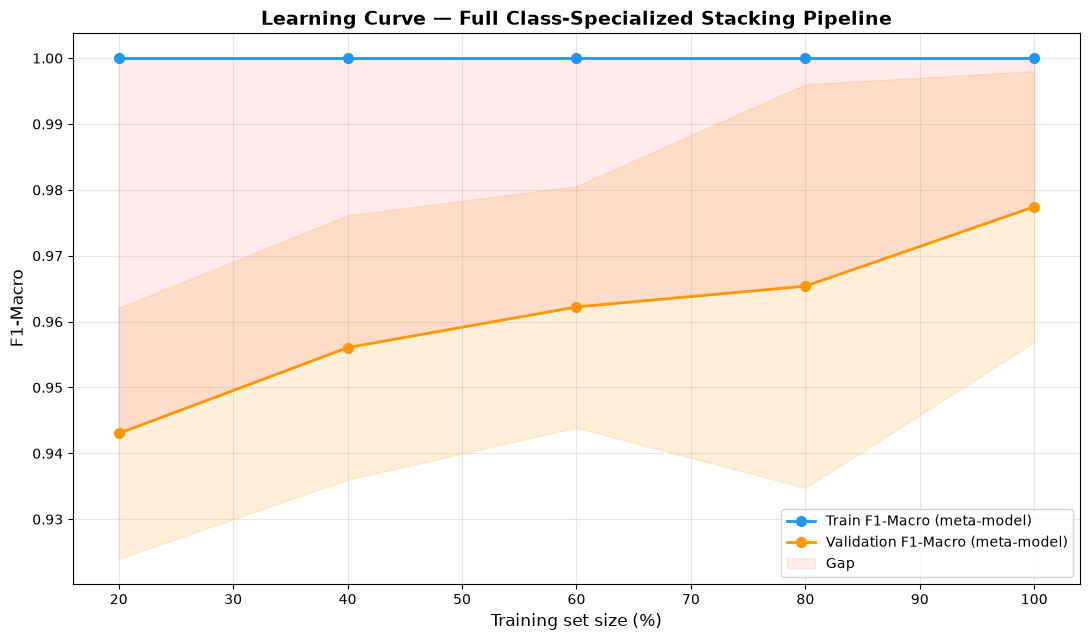

2026/06/30 21:30:04 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_DIAGNOSTICS' does not exist. Creating a new experiment.


  Final Gap at 100% train: 0.0226


In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
eps = 1e-8

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)


def fe_class1(df):
    df = df.copy()
    df['f10_sq']          = df['f10'] ** 2
    df['f10_sqrt']        = np.sqrt(df['f10'].clip(0))
    df['log_f10']         = np.log(df['f10'] + eps)
    df['f10_div_f14']     = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']      = df['f10'] / (df['f9']  + eps)
    df['f10_minus_f14']   = df['f10'] - df['f14']
    df['f10_minus_f9']    = df['f10'] - df['f9']
    df['f10_x_f13']       = df['f10'] * df['f13']
    df['f10_rank']        = df['f10'].rank(pct=True)
    df['f10_dist_median'] = (df['f10'] - df['f10'].median()).abs()
    return df

def fe_class2(df):
    df = df.copy()
    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + df['f9'] + eps)
    df['f10_div_f14_f9']   = df['f10'] / (df['f14'] + df['f9'] + eps)
    df['f9_div_f14']       = df['f9']  / (df['f14'] + eps)
    df['f2_div_f9']        = df['f2']  / (df['f9']  + eps)
    df['f14_rank']         = df['f14'].rank(pct=True)
    df['f9_rank']          = df['f9'].rank(pct=True)
    df['f10_x_f12']        = df['f10'] * df['f12']
    return df

def fe_class3(df):
    df = df.copy()
    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['f14_plus_f9']    = df['f14'] + df['f9']
    df['f14_x_f9']       = df['f14'] * df['f9']
    df['f14_sq']         = df['f14'] ** 2
    df['f9_sq']          = df['f9']  ** 2
    df['f14_x_f12']      = df['f14'] * df['f12']
    df['f9_x_f13']       = df['f9']  * df['f13']
    return df

train_c1 = fe_class1(train)
train_c2 = fe_class2(train)
train_c3 = fe_class3(train)

fc1 = [c for c in train_c1.columns if c not in ['ID', 'target']]
fc2 = [c for c in train_c2.columns if c not in ['ID', 'target']]
fc3 = [c for c in train_c3.columns if c not in ['ID', 'target']]

X_c1_full   = train_c1[fc1].values
X_c2_full   = train_c2[fc2].values
X_c3_full   = train_c3[fc3].values
X_base_full = train[feature_cols].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]

train_f1_means = []
val_f1_means   = []
train_f1_stds  = []
val_f1_stds    = []

print('=' * 65)
print('  Full Pipeline Learning Curve — Class-Specialized Stacking')
print('=' * 65)

for size in train_sizes:
    fold_train_f1 = []
    fold_val_f1   = []

    for fold, (tr_idx_full, val_idx) in enumerate(skf.split(X_base_full, y), 1):


        rng       = np.random.RandomState(42)
        n_samples = int(len(tr_idx_full) * size)
        tr_idx    = rng.choice(tr_idx_full, n_samples, replace=False)

        y_tr, y_val = y[tr_idx], y[val_idx]

        X_tr_c1, X_val_c1 = X_c1_full[tr_idx], X_c1_full[val_idx]
        X_tr_c2, X_val_c2 = X_c2_full[tr_idx], X_c2_full[val_idx]
        X_tr_c3, X_val_c3 = X_c3_full[tr_idx], X_c3_full[val_idx]
        X_tr_b,  X_val_b  = X_base_full[tr_idx], X_base_full[val_idx]


        cat_c1 = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0)
        cat_c1.fit(X_tr_c1, y_tr)
        tr_cat_c1  = cat_c1.predict_proba(X_tr_c1)
        val_cat_c1 = cat_c1.predict_proba(X_val_c1)

        rf_c1 = RandomForestClassifier(
            n_estimators=300, min_samples_split=5,
            min_samples_leaf=2, max_features=0.7,
            random_state=42, n_jobs=-1)
        rf_c1.fit(X_tr_c1, y_tr)
        tr_rf_c1  = rf_c1.predict_proba(X_tr_c1)
        val_rf_c1 = rf_c1.predict_proba(X_val_c1)

        lgb_c2 = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb_c2.fit(X_tr_c2, y_tr)
        tr_lgb_c2  = lgb_c2.predict_proba(X_tr_c2)
        val_lgb_c2 = lgb_c2.predict_proba(X_val_c2)

        scaler2   = StandardScaler()
        X_tr_sc2  = scaler2.fit_transform(X_tr_c2)
        X_val_sc2 = scaler2.transform(X_val_c2)
        svm_c2 = SVC(kernel='poly', C=50.0, gamma='scale',
                     degree=2, random_state=42, probability=True)
        svm_c2.fit(X_tr_sc2, y_tr)
        tr_svm_c2  = svm_c2.predict_proba(X_tr_sc2)
        val_svm_c2 = svm_c2.predict_proba(X_val_sc2)

        xgb_c3 = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb_c3.fit(X_tr_c3, y_tr)
        tr_xgb_c3  = xgb_c3.predict_proba(X_tr_c3)
        val_xgb_c3 = xgb_c3.predict_proba(X_val_c3)

        scaler3   = StandardScaler()
        X_tr_sc3  = scaler3.fit_transform(X_tr_c3)
        X_val_sc3 = scaler3.transform(X_val_c3)
        knn_c3 = KNeighborsClassifier(
            n_neighbors=5, weights='distance',
            metric='manhattan', p=1, n_jobs=-1)
        knn_c3.fit(X_tr_sc3, y_tr)
        tr_knn_c3  = knn_c3.predict_proba(X_tr_sc3)
        val_knn_c3 = knn_c3.predict_proba(X_val_sc3)


        X_tr_L1  = np.hstack([X_tr_b, tr_cat_c1, tr_rf_c1,
                               tr_lgb_c2, tr_svm_c2, tr_xgb_c3, tr_knn_c3])
        X_val_L1 = np.hstack([X_val_b, val_cat_c1, val_rf_c1,
                               val_lgb_c2, val_svm_c2, val_xgb_c3, val_knn_c3])

        cat2 = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0)
        cat2.fit(X_tr_L1, y_tr)
        tr_cat2  = cat2.predict_proba(X_tr_L1)
        val_cat2 = cat2.predict_proba(X_val_L1)

        lgb2 = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb2.fit(X_tr_L1, y_tr)
        tr_lgb2  = lgb2.predict_proba(X_tr_L1)
        val_lgb2 = lgb2.predict_proba(X_val_L1)

        xgb2 = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb2.fit(X_tr_L1, y_tr)
        tr_xgb2  = xgb2.predict_proba(X_tr_L1)
        val_xgb2 = xgb2.predict_proba(X_val_L1)


        meta_tr  = np.hstack([tr_cat2,  tr_lgb2,  tr_xgb2])
        meta_val = np.hstack([val_cat2, val_lgb2, val_xgb2])

        meta = LogisticRegression(C=1.0, max_iter=1000,
                                   random_state=42, n_jobs=-1)
        meta.fit(meta_tr, y_tr)

        train_f1 = f1_score(y_tr,  meta.predict(meta_tr),  average='macro')
        val_f1   = f1_score(y_val, meta.predict(meta_val), average='macro')

        fold_train_f1.append(train_f1)
        fold_val_f1.append(val_f1)

        print(f'  size={size:.0%} fold={fold}/5 | '
              f'train F1={train_f1:.4f} | val F1={val_f1:.4f}')

    train_f1_means.append(np.mean(fold_train_f1))
    val_f1_means.append(np.mean(fold_val_f1))
    train_f1_stds.append(np.std(fold_train_f1))
    val_f1_stds.append(np.std(fold_val_f1))

    print(f'  >>> size={size:.0%} AVG | train={train_f1_means[-1]:.4f} | '
          f'val={val_f1_means[-1]:.4f} | gap={train_f1_means[-1]-val_f1_means[-1]:.4f}\n')

train_f1_means = np.array(train_f1_means)
val_f1_means   = np.array(val_f1_means)
train_f1_stds  = np.array(train_f1_stds)
val_f1_stds    = np.array(val_f1_stds)




fig, ax = plt.subplots(figsize=(11, 6.5))

x_pct = np.array(train_sizes) * 100

ax.plot(x_pct, train_f1_means, 'o-', color='#2196F3',
        linewidth=2, markersize=7, label='Train F1-Macro (meta-model)')
ax.fill_between(x_pct, train_f1_means - train_f1_stds,
                 train_f1_means + train_f1_stds, alpha=0.15, color='#2196F3')

ax.plot(x_pct, val_f1_means, 'o-', color='#FF9800',
        linewidth=2, markersize=7, label='Validation F1-Macro (meta-model)')
ax.fill_between(x_pct, val_f1_means - val_f1_stds,
                 val_f1_means + val_f1_stds, alpha=0.15, color='#FF9800')

ax.fill_between(x_pct, val_f1_means, train_f1_means,
                 where=(train_f1_means >= val_f1_means),
                 interpolate=True, color='red', alpha=0.08, label='Gap')

ax.set_xlabel('Training set size (%)', fontsize=12)
ax.set_ylabel('F1-Macro', fontsize=12)
ax.set_title('Learning Curve — Full Class-Specialized Stacking Pipeline',
              fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curve_full_stacking.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 65)
print(f'  Final Gap at 100% train: {train_f1_means[-1] - val_f1_means[-1]:.4f}')
print('=' * 65)

import mlflow
mlflow.set_experiment("clf_experiments_DIAGNOSTICS")
with mlflow.start_run(run_name="LearningCurve_Full_Stacking"):
    mlflow.log_param("diagnostic_type", "learning_curve")
    mlflow.log_metric("final_train_f1", float(train_f1_means[-1]))
    mlflow.log_metric("final_val_f1", float(val_f1_means[-1]))
    mlflow.log_metric("final_gap", float(train_f1_means[-1] - val_f1_means[-1]))
    log_artifact_and_dvc("learning_curve_full_stacking.png")


## تجربة مقارنة 5-Fold و10-Fold CV

هنا نقارن نفس pipeline بين 5 folds و10 folds. الفرق هو حجم validation داخل كل fold وعدد مرات التدريب. الهدف معرفة هل زيادة folds تقلل تذبذب النتائج وتعطي OOF أكثر استقراراً.



  Running with n_splits=5
    Fold 1/5 | val_size=640 | F1=0.9954
    Fold 2/5 | val_size=640 | F1=0.9868
    Fold 3/5 | val_size=640 | F1=1.0000
    Fold 4/5 | val_size=640 | F1=0.9725
    Fold 5/5 | val_size=640 | F1=1.0000

  n_splits=5 | OOF F1=0.9899 | fold std=0.0104 | fold range=[0.9725, 1.0000]

  Running with n_splits=10
    Fold 1/10 | val_size=320 | F1=0.9728
    Fold 2/10 | val_size=320 | F1=1.0000
    Fold 3/10 | val_size=320 | F1=0.9909
    Fold 4/10 | val_size=320 | F1=1.0000
    Fold 5/10 | val_size=320 | F1=1.0000
    Fold 6/10 | val_size=320 | F1=1.0000
    Fold 7/10 | val_size=320 | F1=1.0000
    Fold 8/10 | val_size=320 | F1=0.9649
    Fold 9/10 | val_size=320 | F1=1.0000
    Fold 10/10 | val_size=320 | F1=1.0000

  n_splits=10 | OOF F1=0.9898 | fold std=0.0124 | fold range=[0.9649, 1.0000]


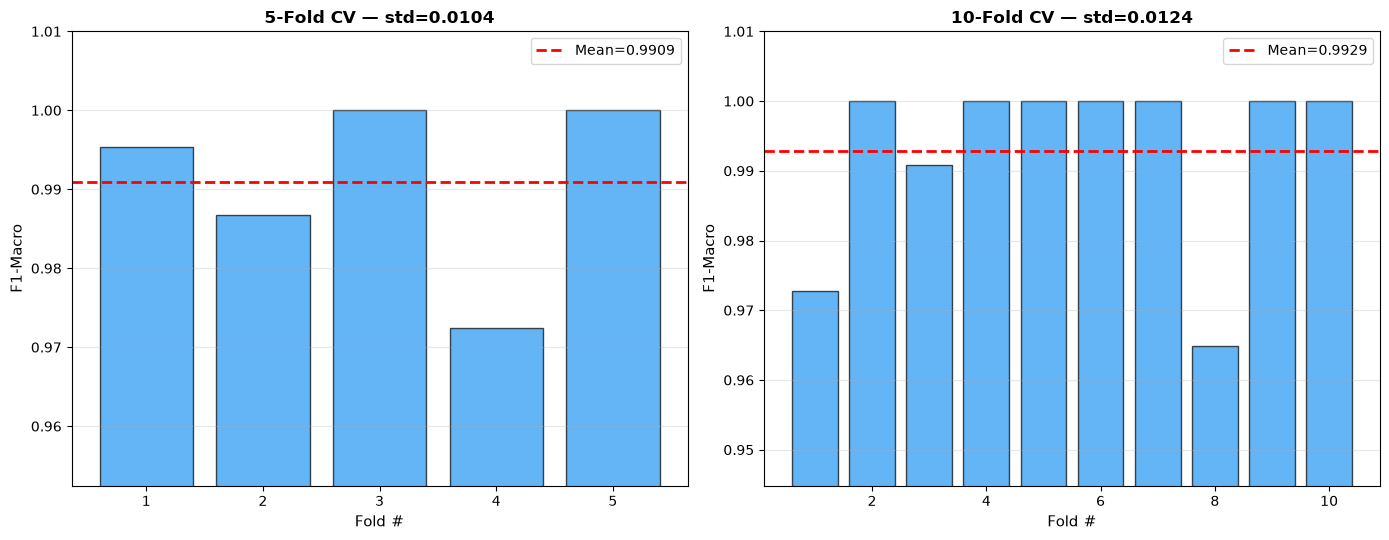


  COMPARISON SUMMARY — 5-fold vs 10-fold
Metric                    5-fold          10-fold        
-------------------------------------------------------
OOF F1-Macro              0.9899          0.9898         
Fold std (تذبذب)          0.0104          0.0124         
Fold min                  0.9725          0.9649         
Fold max                  1.0000          1.0000         
~val size per fold        640             320            
class1 F1                 0.9947          0.9840         
class2 F1                 0.9766          0.9869         
class3 F1                 0.9983          0.9986         

  → 10-fold لم يقلل التذبذب بشكل ملحوظ
    (الـ overfitting أقرب لكونه حفظ حقيقي من الموديل، مش مشكلة بحجم الـ fold)


In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
eps = 1e-8

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)

X_base   = train[feature_cols].values
X_test_b = test[feature_cols].values


def fe_class1(df):
    df = df.copy()
    df['f10_sq']        = df['f10'] ** 2
    df['f10_sqrt']      = np.sqrt(df['f10'].clip(0))
    df['log_f10']       = np.log(df['f10'] + eps)
    df['f10_div_f14']   = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']    = df['f10'] / (df['f9']  + eps)
    df['f10_minus_f14'] = df['f10'] - df['f14']
    df['f10_minus_f9']  = df['f10'] - df['f9']
    df['f10_x_f13']     = df['f10'] * df['f13']
    return df

def fe_class2(df):
    df = df.copy()
    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + df['f9'] + eps)
    df['f10_div_f14_f9']   = df['f10'] / (df['f14'] + df['f9'] + eps)
    df['f9_div_f14']       = df['f9']  / (df['f14'] + eps)
    df['f2_div_f9']        = df['f2']  / (df['f9']  + eps)
    df['f10_x_f12']        = df['f10'] * df['f12']
    return df

def fe_class3(df):
    df = df.copy()
    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['f14_plus_f9']    = df['f14'] + df['f9']
    df['f14_x_f9']       = df['f14'] * df['f9']
    df['f14_sq']         = df['f14'] ** 2
    df['f9_sq']          = df['f9']  ** 2
    df['f14_x_f12']      = df['f14'] * df['f12']
    df['f9_x_f13']       = df['f9']  * df['f13']
    return df

train_c1 = fe_class1(train); train_c2 = fe_class2(train); train_c3 = fe_class3(train)
test_c1  = fe_class1(test);  test_c2  = fe_class2(test);  test_c3  = fe_class3(test)

fc1 = [c for c in train_c1.columns if c not in ['ID', 'target']]
fc2 = [c for c in train_c2.columns if c not in ['ID', 'target']]
fc3 = [c for c in train_c3.columns if c not in ['ID', 'target']]

X_c1, X_c2, X_c3 = train_c1[fc1].values, train_c2[fc2].values, train_c3[fc3].values
X_test_c1, X_test_c2, X_test_c3 = test_c1[fc1].values, test_c2[fc2].values, test_c3[fc3].values





def run_pipeline_cv(n_splits, X_base_, X_c1_, X_c2_, X_c3_, y_,
                     X_test_b_=None, X_test_c1_=None,
                     X_test_c2_=None, X_test_c3_=None,
                     return_test=False):

    skf_ = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    n = len(X_base_)
    oof_cat = np.zeros((n, n_classes))
    oof_lgb = np.zeros((n, n_classes))
    oof_xgb = np.zeros((n, n_classes))

    if return_test:
        nt = len(X_test_b_)
        test_cat = np.zeros((nt, n_classes))
        test_lgb = np.zeros((nt, n_classes))
        test_xgb = np.zeros((nt, n_classes))

    fold_f1s = []

    for fold_i, (tr_idx, val_idx) in enumerate(skf_.split(X_base_, y_), 1):
        y_tr, y_val = y_[tr_idx], y_[val_idx]

        cat = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0)
        cat.fit(X_c1_[tr_idx], y_tr)
        oof_cat[val_idx] = cat.predict_proba(X_c1_[val_idx])
        if return_test: test_cat += cat.predict_proba(X_test_c1_) / n_splits

        lgb_m = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb_m.fit(X_c2_[tr_idx], y_tr)
        oof_lgb[val_idx] = lgb_m.predict_proba(X_c2_[val_idx])
        if return_test: test_lgb += lgb_m.predict_proba(X_test_c2_) / n_splits

        xgb_m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb_m.fit(X_c3_[tr_idx], y_tr)
        oof_xgb[val_idx] = xgb_m.predict_proba(X_c3_[val_idx])
        if return_test: test_xgb += xgb_m.predict_proba(X_test_c3_) / n_splits


        fold_combined = (oof_cat[val_idx] + oof_lgb[val_idx] + oof_xgb[val_idx]) / 3
        fold_f1 = f1_score(y_val, np.argmax(fold_combined, axis=1), average='macro')
        fold_f1s.append(fold_f1)
        print(f'    Fold {fold_i}/{n_splits} | val_size={len(val_idx)} | F1={fold_f1:.4f}')


    X_L1 = np.hstack([X_base_, oof_cat, oof_lgb, oof_xgb])
    if return_test:
        X_test_L1 = np.hstack([X_test_b_, test_cat, test_lgb, test_xgb])

    oof_cat2 = np.zeros((n, n_classes))
    oof_lgb2 = np.zeros((n, n_classes))
    oof_xgb2 = np.zeros((n, n_classes))
    if return_test:
        test_cat2 = np.zeros((nt, n_classes))
        test_lgb2 = np.zeros((nt, n_classes))
        test_xgb2 = np.zeros((nt, n_classes))

    for tr_idx, val_idx in skf_.split(X_L1, y_):
        y_tr = y_[tr_idx]

        cat2 = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0)
        cat2.fit(X_L1[tr_idx], y_tr)
        oof_cat2[val_idx] = cat2.predict_proba(X_L1[val_idx])
        if return_test: test_cat2 += cat2.predict_proba(X_test_L1) / n_splits

        lgb2 = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb2.fit(X_L1[tr_idx], y_tr)
        oof_lgb2[val_idx] = lgb2.predict_proba(X_L1[val_idx])
        if return_test: test_lgb2 += lgb2.predict_proba(X_test_L1) / n_splits

        xgb2 = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb2.fit(X_L1[tr_idx], y_tr)
        oof_xgb2[val_idx] = xgb2.predict_proba(X_L1[val_idx])
        if return_test: test_xgb2 += xgb2.predict_proba(X_test_L1) / n_splits

    meta_train = np.hstack([oof_cat2, oof_lgb2, oof_xgb2])
    meta = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
    meta.fit(meta_train, y_)
    oof_final = meta.predict(meta_train)

    if return_test:
        meta_test = np.hstack([test_cat2, test_lgb2, test_xgb2])
        return oof_final, meta.predict(meta_test), fold_f1s, skf_
    return oof_final, fold_f1s, skf_




results = {}

for n_splits in [5, 10]:
    print('\n' + '=' * 65)
    print(f'  Running with n_splits={n_splits}')
    print('=' * 65)

    oof_preds, fold_f1s, skf_used = run_pipeline_cv(
        n_splits, X_base, X_c1, X_c2, X_c3, y)

    oof_f1 = f1_score(y, oof_preds, average='macro')
    report = classification_report(y, oof_preds, target_names=le.classes_, output_dict=True)

    results[n_splits] = {
        'oof_f1'      : oof_f1,
        'fold_f1s'    : fold_f1s,
        'fold_std'    : np.std(fold_f1s),
        'fold_min'    : np.min(fold_f1s),
        'fold_max'    : np.max(fold_f1s),
        'class1_f1'   : report['class1']['f1-score'],
        'class2_f1'   : report['class2']['f1-score'],
        'class3_f1'   : report['class3']['f1-score'],
        'val_size_approx': len(X_base) // n_splits,
    }

    print(f'\n  n_splits={n_splits} | OOF F1={oof_f1:.4f} | '
          f'fold std={np.std(fold_f1s):.4f} | '
          f'fold range=[{np.min(fold_f1s):.4f}, {np.max(fold_f1s):.4f}]')




fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, n_splits in zip(axes, [5, 10]):
    fold_f1s = results[n_splits]['fold_f1s']
    folds_x  = list(range(1, n_splits + 1))
    mean_f1  = np.mean(fold_f1s)

    ax.bar(folds_x, fold_f1s, color='#2196F3', alpha=0.7, edgecolor='black')
    ax.axhline(mean_f1, color='red', linestyle='--', linewidth=2,
               label=f'Mean={mean_f1:.4f}')
    ax.set_xlabel('Fold #', fontsize=11)
    ax.set_ylabel('F1-Macro', fontsize=11)
    ax.set_title(f'{n_splits}-Fold CV — std={results[n_splits]["fold_std"]:.4f}',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(min(fold_f1s) - 0.02, 1.01)
    ax.legend()
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cv_folds_comparison_5_vs_10.png', dpi=150, bbox_inches='tight')
plt.show()


print('\n' + '=' * 65)
print('  COMPARISON SUMMARY — 5-fold vs 10-fold')
print('=' * 65)
print(f'{"Metric":<25} {"5-fold":<15} {"10-fold":<15}')
print('-' * 55)
print(f'{"OOF F1-Macro":<25} {results[5]["oof_f1"]:<15.4f} {results[10]["oof_f1"]:<15.4f}')
print(f'{"Fold std (تذبذب)":<25} {results[5]["fold_std"]:<15.4f} {results[10]["fold_std"]:<15.4f}')
print(f'{"Fold min":<25} {results[5]["fold_min"]:<15.4f} {results[10]["fold_min"]:<15.4f}')
print(f'{"Fold max":<25} {results[5]["fold_max"]:<15.4f} {results[10]["fold_max"]:<15.4f}')
print(f'{"~val size per fold":<25} {results[5]["val_size_approx"]:<15} {results[10]["val_size_approx"]:<15}')
print(f'{"class1 F1":<25} {results[5]["class1_f1"]:<15.4f} {results[10]["class1_f1"]:<15.4f}')
print(f'{"class2 F1":<25} {results[5]["class2_f1"]:<15.4f} {results[10]["class2_f1"]:<15.4f}')
print(f'{"class3 F1":<25} {results[5]["class3_f1"]:<15.4f} {results[10]["class3_f1"]:<15.4f}')
print('=' * 65)

if results[10]['fold_std'] < results[5]['fold_std']:
    print('\n  → 10-fold قلل التذبذب بين الـ folds')
    print('    (جزء من "overfitting" المُلاحظ كان variance من صغر العينة، مش حفظ حقيقي)')
else:
    print('\n  → 10-fold لم يقلل التذبذب بشكل ملحوظ')
    print('    (الـ overfitting أقرب لكونه حفظ حقيقي من الموديل، مش مشكلة بحجم الـ fold)')

import mlflow
mlflow.set_experiment("clf_experiments_DIAGNOSTICS")
with mlflow.start_run(run_name="CV_5_vs_10_Fold_Comparison"):
    mlflow.log_param("diagnostic_type", "cv_fold_comparison")
    for n_splits in [5, 10]:
        prefix = f"cv_{n_splits}"
        mlflow.log_metric(f"{prefix}_oof_f1", float(results[n_splits]["oof_f1"]))
        mlflow.log_metric(f"{prefix}_fold_std", float(results[n_splits]["fold_std"]))
        mlflow.log_metric(f"{prefix}_fold_min", float(results[n_splits]["fold_min"]))
        mlflow.log_metric(f"{prefix}_fold_max", float(results[n_splits]["fold_max"]))
        mlflow.log_metric(f"{prefix}_class1_f1", float(results[n_splits]["class1_f1"]))
        mlflow.log_metric(f"{prefix}_class2_f1", float(results[n_splits]["class2_f1"]))
        mlflow.log_metric(f"{prefix}_class3_f1", float(results[n_splits]["class3_f1"]))
    log_artifact_and_dvc("cv_folds_comparison_5_vs_10.png")


## تجربة Class Specialized Stacking Fixed

هذه نسخة مصححة أو أكثر ضبطاً من class specialized stacking. الهدف تحسين الثبات وتقليل gap، مع حفظ learning curve وملف submission داخل MLflow وDVC.


FE class1: 29 features (no rank/leak)
FE class2: 28 features (no rank/leak)
FE class3: 30 features
  Learning Curve — Simplified Pipeline (no leak, 3 L0 models)
  size=20% fold=1/5 | train=1.0000 | val=0.9181
  size=20% fold=2/5 | train=1.0000 | val=0.9772
  size=20% fold=3/5 | train=1.0000 | val=0.9520
  size=20% fold=4/5 | train=1.0000 | val=0.9451
  size=20% fold=5/5 | train=1.0000 | val=0.9312
  >>> size=20% AVG | train=1.0000 | val=0.9447 | gap=0.0553

  size=40% fold=1/5 | train=1.0000 | val=0.9447
  size=40% fold=2/5 | train=1.0000 | val=0.9865
  size=40% fold=3/5 | train=1.0000 | val=0.9954
  size=40% fold=4/5 | train=1.0000 | val=0.9769
  size=40% fold=5/5 | train=1.0000 | val=0.9312
  >>> size=40% AVG | train=1.0000 | val=0.9669 | gap=0.0331

  size=60% fold=1/5 | train=1.0000 | val=0.9816
  size=60% fold=2/5 | train=1.0000 | val=0.9734
  size=60% fold=3/5 | train=1.0000 | val=0.9954
  size=60% fold=4/5 | train=1.0000 | val=0.9618
  size=60% fold=5/5 | train=1.0000 | val=0.94

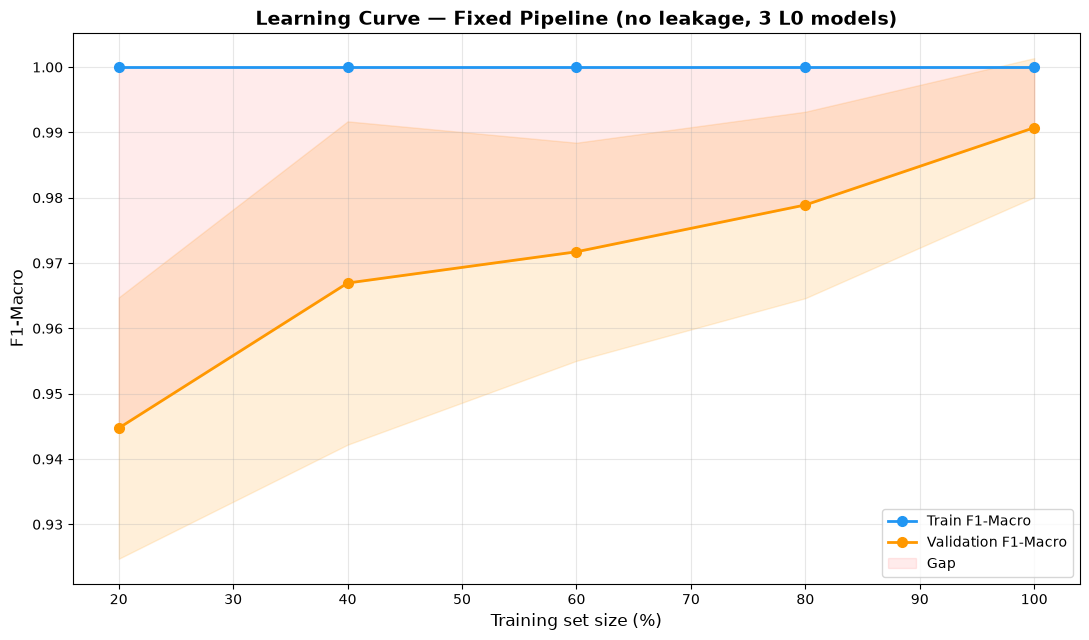

  Final Gap at 100% train: 0.0093

  Final Training — Full Train + Test Predictions

  Final OOF F1-Macro : 0.9899
  class1=0.9947 | class2=0.9766 | class3=0.9983

 submission_class_specialized_fixed.csv جاهز!
target
class3    2936
class2     184
class1      80
Name: count, dtype: int64


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
eps = 1e-8

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)

X_base   = train[feature_cols].values
X_test_b = test[feature_cols].values






def fe_class1(df):
    df = df.copy()
    df['f10_sq']        = df['f10'] ** 2
    df['f10_sqrt']      = np.sqrt(df['f10'].clip(0))
    df['log_f10']       = np.log(df['f10'] + eps)
    df['f10_div_f14']   = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']    = df['f10'] / (df['f9']  + eps)
    df['f10_minus_f14'] = df['f10'] - df['f14']
    df['f10_minus_f9']  = df['f10'] - df['f9']
    df['f10_x_f13']     = df['f10'] * df['f13']
    return df

def fe_class2(df):
    df = df.copy()
    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + df['f9'] + eps)
    df['f10_div_f14_f9']   = df['f10'] / (df['f14'] + df['f9'] + eps)
    df['f9_div_f14']       = df['f9']  / (df['f14'] + eps)
    df['f2_div_f9']        = df['f2']  / (df['f9']  + eps)
    df['f10_x_f12']        = df['f10'] * df['f12']
    return df

def fe_class3(df):
    df = df.copy()
    cont = df[continuous_cols]
    df['row_cont_mean']  = cont.mean(axis=1)
    df['row_cont_std']   = cont.std(axis=1)
    df['row_cont_max']   = cont.max(axis=1)
    df['f14_plus_f9']    = df['f14'] + df['f9']
    df['f14_x_f9']       = df['f14'] * df['f9']
    df['f14_sq']         = df['f14'] ** 2
    df['f9_sq']          = df['f9']  ** 2
    df['f14_x_f12']      = df['f14'] * df['f12']
    df['f9_x_f13']       = df['f9']  * df['f13']
    return df

train_c1 = fe_class1(train)
train_c2 = fe_class2(train)
train_c3 = fe_class3(train)
test_c1  = fe_class1(test)
test_c2  = fe_class2(test)
test_c3  = fe_class3(test)

fc1 = [c for c in train_c1.columns if c not in ['ID', 'target']]
fc2 = [c for c in train_c2.columns if c not in ['ID', 'target']]
fc3 = [c for c in train_c3.columns if c not in ['ID', 'target']]

X_c1, X_c2, X_c3 = train_c1[fc1].values, train_c2[fc2].values, train_c3[fc3].values
X_test_c1, X_test_c2, X_test_c3 = test_c1[fc1].values, test_c2[fc2].values, test_c3[fc3].values

print(f'FE class1: {len(fc1)} features (no rank/leak)')
print(f'FE class2: {len(fc2)} features (no rank/leak)')
print(f'FE class3: {len(fc3)} features')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)





def run_full_pipeline(X_base, X_c1, X_c2, X_c3, y, skf,
                       X_test_b=None, X_test_c1=None,
                       X_test_c2=None, X_test_c3=None,
                       return_test_preds=False):
    """
    يشغّل الـ pipeline كامل (Level0 → Level1 → Level2) ويرجع
    OOF predictions + (اختياري) test predictions
    """
    n = len(X_base)
    oof_cat_c1 = np.zeros((n, n_classes))
    oof_lgb_c2 = np.zeros((n, n_classes))
    oof_xgb_c3 = np.zeros((n, n_classes))

    if return_test_preds:
        nt = len(X_test_b)
        test_cat_c1 = np.zeros((nt, n_classes))
        test_lgb_c2 = np.zeros((nt, n_classes))
        test_xgb_c3 = np.zeros((nt, n_classes))

    for tr_idx, val_idx in skf.split(X_base, y):
        y_tr = y[tr_idx]


        cat = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0)
        cat.fit(X_c1[tr_idx], y_tr)
        oof_cat_c1[val_idx] = cat.predict_proba(X_c1[val_idx])
        if return_test_preds:
            test_cat_c1 += cat.predict_proba(X_test_c1) / skf.n_splits


        lgb_m = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb_m.fit(X_c2[tr_idx], y_tr)
        oof_lgb_c2[val_idx] = lgb_m.predict_proba(X_c2[val_idx])
        if return_test_preds:
            test_lgb_c2 += lgb_m.predict_proba(X_test_c2) / skf.n_splits


        xgb_m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb_m.fit(X_c3[tr_idx], y_tr)
        oof_xgb_c3[val_idx] = xgb_m.predict_proba(X_c3[val_idx])
        if return_test_preds:
            test_xgb_c3 += xgb_m.predict_proba(X_test_c3) / skf.n_splits


    X_L1 = np.hstack([X_base, oof_cat_c1, oof_lgb_c2, oof_xgb_c3])
    if return_test_preds:
        X_test_L1 = np.hstack([X_test_b, test_cat_c1, test_lgb_c2, test_xgb_c3])

    oof_cat2 = np.zeros((n, n_classes))
    oof_lgb2 = np.zeros((n, n_classes))
    oof_xgb2 = np.zeros((n, n_classes))
    if return_test_preds:
        test_cat2 = np.zeros((nt, n_classes))
        test_lgb2 = np.zeros((nt, n_classes))
        test_xgb2 = np.zeros((nt, n_classes))

    for tr_idx, val_idx in skf.split(X_L1, y):
        y_tr = y[tr_idx]

        cat2 = CatBoostClassifier(
            iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0,
            random_strength=5.0, border_count=254,
            min_data_in_leaf=3, random_seed=42, verbose=0)
        cat2.fit(X_L1[tr_idx], y_tr)
        oof_cat2[val_idx] = cat2.predict_proba(X_L1[val_idx])
        if return_test_preds:
            test_cat2 += cat2.predict_proba(X_test_L1) / skf.n_splits

        lgb2 = lgb.LGBMClassifier(
            n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1,
            colsample_bytree=1.0, min_child_samples=5,
            min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb2.fit(X_L1[tr_idx], y_tr)
        oof_lgb2[val_idx] = lgb2.predict_proba(X_L1[val_idx])
        if return_test_preds:
            test_lgb2 += lgb2.predict_proba(X_test_L1) / skf.n_splits

        xgb2 = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7,
            min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0,
            random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb2.fit(X_L1[tr_idx], y_tr)
        oof_xgb2[val_idx] = xgb2.predict_proba(X_L1[val_idx])
        if return_test_preds:
            test_xgb2 += xgb2.predict_proba(X_test_L1) / skf.n_splits


    meta_train = np.hstack([oof_cat2, oof_lgb2, oof_xgb2])
    meta = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
    meta.fit(meta_train, y)

    oof_preds = meta.predict(meta_train)

    if return_test_preds:
        meta_test    = np.hstack([test_cat2, test_lgb2, test_xgb2])
        test_preds   = meta.predict(meta_test)
        return oof_preds, test_preds

    return oof_preds




train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
train_f1_means, val_f1_means = [], []
train_f1_stds,  val_f1_stds  = [], []

print('=' * 65)
print('  Learning Curve — Simplified Pipeline (no leak, 3 L0 models)')
print('=' * 65)

for size in train_sizes:
    fold_tr, fold_val = [], []
    for fold, (tr_full, val_idx) in enumerate(skf.split(X_base, y), 1):
        rng = np.random.RandomState(42)
        n_sub  = int(len(tr_full) * size)
        tr_idx = rng.choice(tr_full, n_sub, replace=False)

        y_tr, y_val = y[tr_idx], y[val_idx]


        cat = CatBoostClassifier(iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0, random_strength=5.0,
            border_count=254, min_data_in_leaf=3, random_seed=42, verbose=0)
        cat.fit(X_c1[tr_idx], y_tr)
        tr_c1, val_c1 = cat.predict_proba(X_c1[tr_idx]), cat.predict_proba(X_c1[val_idx])

        lgb_m = lgb.LGBMClassifier(n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1, colsample_bytree=1.0,
            min_child_samples=5, min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb_m.fit(X_c2[tr_idx], y_tr)
        tr_c2, val_c2 = lgb_m.predict_proba(X_c2[tr_idx]), lgb_m.predict_proba(X_c2[val_idx])

        xgb_m = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7, min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0, random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb_m.fit(X_c3[tr_idx], y_tr)
        tr_c3, val_c3 = xgb_m.predict_proba(X_c3[tr_idx]), xgb_m.predict_proba(X_c3[val_idx])

        X_tr_L1  = np.hstack([X_base[tr_idx],  tr_c1, tr_c2, tr_c3])
        X_val_L1 = np.hstack([X_base[val_idx], val_c1, val_c2, val_c3])

        cat2 = CatBoostClassifier(iterations=700, depth=6, learning_rate=0.1,
            l2_leaf_reg=3, bagging_temperature=2.0, random_strength=5.0,
            border_count=254, min_data_in_leaf=3, random_seed=42, verbose=0)
        cat2.fit(X_tr_L1, y_tr)
        tr2_c, val2_c = cat2.predict_proba(X_tr_L1), cat2.predict_proba(X_val_L1)

        lgb2 = lgb.LGBMClassifier(n_estimators=1000, num_leaves=100, max_depth=3,
            learning_rate=0.05, subsample=0.6, subsample_freq=1, colsample_bytree=1.0,
            min_child_samples=5, min_split_gain=0.1, reg_alpha=0.5, reg_lambda=0.5,
            random_state=42, n_jobs=-1, verbose=-1)
        lgb2.fit(X_tr_L1, y_tr)
        tr2_l, val2_l = lgb2.predict_proba(X_tr_L1), lgb2.predict_proba(X_val_L1)

        xgb2 = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.2,
            subsample=0.9, colsample_bytree=0.7, min_child_weight=1, gamma=0.0,
            reg_alpha=0.5, reg_lambda=5.0, random_state=42, n_jobs=-1,
            verbosity=0, eval_metric='mlogloss')
        xgb2.fit(X_tr_L1, y_tr)
        tr2_x, val2_x = xgb2.predict_proba(X_tr_L1), xgb2.predict_proba(X_val_L1)

        meta_tr  = np.hstack([tr2_c, tr2_l, tr2_x])
        meta_val = np.hstack([val2_c, val2_l, val2_x])
        meta = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
        meta.fit(meta_tr, y_tr)

        train_f1 = f1_score(y_tr,  meta.predict(meta_tr),  average='macro')
        val_f1   = f1_score(y_val, meta.predict(meta_val), average='macro')
        fold_tr.append(train_f1)
        fold_val.append(val_f1)

        print(f'  size={size:.0%} fold={fold}/5 | train={train_f1:.4f} | val={val_f1:.4f}')

    train_f1_means.append(np.mean(fold_tr))
    val_f1_means.append(np.mean(fold_val))
    train_f1_stds.append(np.std(fold_tr))
    val_f1_stds.append(np.std(fold_val))
    print(f'  >>> size={size:.0%} AVG | train={train_f1_means[-1]:.4f} | '
          f'val={val_f1_means[-1]:.4f} | gap={train_f1_means[-1]-val_f1_means[-1]:.4f}\n')

train_f1_means = np.array(train_f1_means)
val_f1_means   = np.array(val_f1_means)
train_f1_stds  = np.array(train_f1_stds)
val_f1_stds    = np.array(val_f1_stds)


fig, ax = plt.subplots(figsize=(11, 6.5))
x_pct = np.array(train_sizes) * 100

ax.plot(x_pct, train_f1_means, 'o-', color='#2196F3', linewidth=2,
        markersize=7, label='Train F1-Macro')
ax.fill_between(x_pct, train_f1_means - train_f1_stds,
                 train_f1_means + train_f1_stds, alpha=0.15, color='#2196F3')

ax.plot(x_pct, val_f1_means, 'o-', color='#FF9800', linewidth=2,
        markersize=7, label='Validation F1-Macro')
ax.fill_between(x_pct, val_f1_means - val_f1_stds,
                 val_f1_means + val_f1_stds, alpha=0.15, color='#FF9800')

ax.fill_between(x_pct, val_f1_means, train_f1_means,
                 where=(train_f1_means >= val_f1_means),
                 interpolate=True, color='red', alpha=0.08, label='Gap')

ax.set_xlabel('Training set size (%)', fontsize=12)
ax.set_ylabel('F1-Macro', fontsize=12)
ax.set_title('Learning Curve — Fixed Pipeline (no leakage, 3 L0 models)',
              fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

final_gap = train_f1_means[-1] - val_f1_means[-1]
print('=' * 65)
print(f'  Final Gap at 100% train: {final_gap:.4f}')
print('=' * 65)




print('\n' + '=' * 65)
print('  Final Training — Full Train + Test Predictions')
print('=' * 65)

oof_preds, test_preds = run_full_pipeline(
    X_base, X_c1, X_c2, X_c3, y, skf,
    X_test_b=X_test_b, X_test_c1=X_test_c1,
    X_test_c2=X_test_c2, X_test_c3=X_test_c3,
    return_test_preds=True
)

final_oof_f1 = f1_score(y, oof_preds, average='macro')
final_report = classification_report(y, oof_preds, target_names=le.classes_,
                                      output_dict=True)
final_labels = le.inverse_transform(test_preds)

print(f'\n  Final OOF F1-Macro : {final_oof_f1:.4f}')
print(f'  class1={final_report["class1"]["f1-score"]:.4f} | '
      f'class2={final_report["class2"]["f1-score"]:.4f} | '
      f'class3={final_report["class3"]["f1-score"]:.4f}')


with mlflow.start_run(run_name='ClassSpecialized_Stacking_FIXED'):
    mlflow.log_params({
        'model'              : 'ClassSpecializedStacking_NoLeak',
        'level0_c1'          : 'CatBoost_only_fe_class1_no_rank',
        'level0_c2'          : 'LGB_only_fe_class2_no_rank',
        'level0_c3'          : 'XGB_only_fe_class3',
        'level1'             : 'CatBoost+LGB+XGB',
        'level2'             : 'LogisticRegression',
        'cv_folds'           : 5,
        'fix_applied'        : 'removed_rank_features_reduced_L0_models',
        'l1_features'        : 9 + len(feature_cols),
        'learning_curve_gap' : round(float(final_gap), 4),
    })
    mlflow.log_metric('final_oof_f1',       round(final_oof_f1, 4))
    mlflow.log_metric('learning_curve_gap', round(float(final_gap), 4))
    mlflow.log_metric('f1_class1', round(final_report['class1']['f1-score'], 4))
    mlflow.log_metric('f1_class2', round(final_report['class2']['f1-score'], 4))
    mlflow.log_metric('f1_class3', round(final_report['class3']['f1-score'], 4))

    submission = pd.DataFrame({'ID': test['ID'], 'target': final_labels})
    submission.to_csv('submission_class_specialized_fixed.csv', index=False)
    log_artifact_and_dvc('submission_class_specialized_fixed.csv')
    log_artifact_and_dvc('learning_curve_fixed.png')

print('\n submission_class_specialized_fixed.csv جاهز!')
print(submission['target'].value_counts())

## تجربة LightGBM Anti-Overfit مع Weak-Class FE

هنا نستخدم LightGBM مع features موجهة للكلاسات الضعيفة وبحث بارامترات محافظ ضد overfitting. الفرق عن LGB العادي أن اختيار البارامترات يركز على الاستقرار وليس أعلى score فقط.


Features: 21 base + 9 weak-class FE = 30 total
New: ['f10_sq', 'log_f10', 'f10_div_f14', 'f10_div_f9', 'f10_minus_f14', 'f10_norm', 'f10_share', 'f10_f14_contrast', 'f9_div_f14']

  Grid Search — Overfitting-Aware (80 iterations)
  score = OOF_F1 - 2.0 × max(gap, 0)
  iter 001/80 | OOF=0.9731 | train=0.9859 | gap=0.0129 | score=0.9473  NEW BEST
  iter 002/80 | OOF=0.9731 | train=0.9949 | gap=0.0219 | score=0.9293
  iter 003/80 | OOF=0.9713 | train=0.9808 | gap=0.0095 | score=0.9524  NEW BEST
  iter 004/80 | OOF=0.9740 | train=0.9791 | gap=0.0051 | score=0.9637  NEW BEST
  iter 005/80 | OOF=0.9739 | train=0.9811 | gap=0.0073 | score=0.9593
  iter 006/80 | OOF=0.9715 | train=0.9854 | gap=0.0139 | score=0.9436
  iter 007/80 | OOF=0.9748 | train=0.9798 | gap=0.0050 | score=0.9648  NEW BEST
  iter 008/80 | OOF=0.9713 | train=0.9948 | gap=0.0235 | score=0.9243
  iter 009/80 | OOF=0.9765 | train=0.9960 | gap=0.0195 | score=0.9375
  iter 010/80 | OOF=0.9731 | train=0.9841 | gap=0.0110 | score=

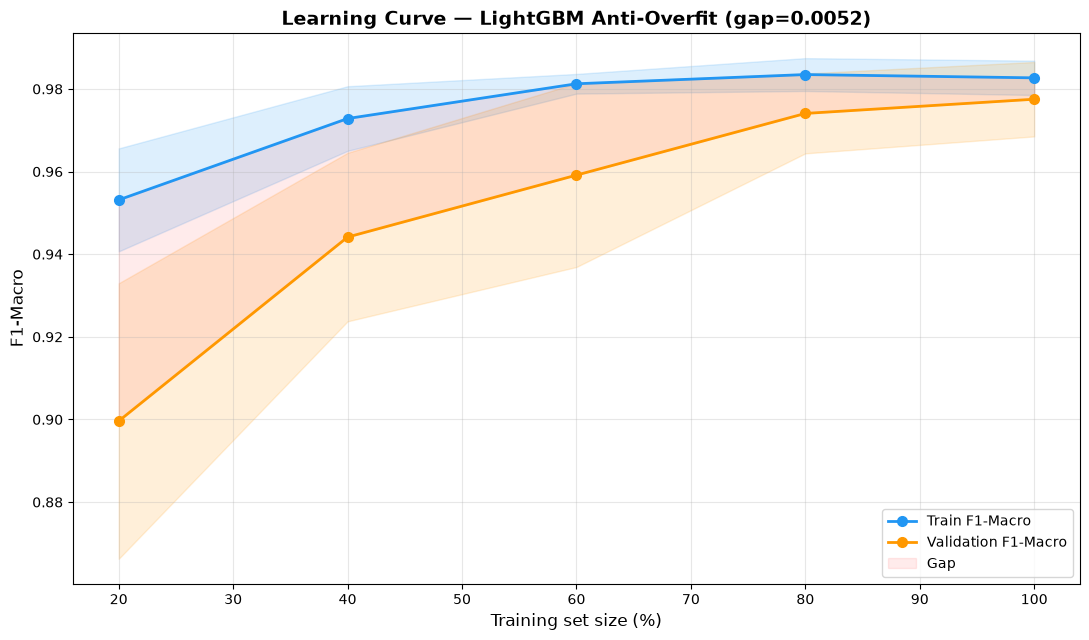

  Final Gap at 100% train: 0.0052

  Final Training — Best Params, Full Data

  Final OOF F1-Macro : 0.9793
  class1=0.9894 | class2=0.9521 | class3=0.9964
  Learning curve gap : 0.0052

 submission_lgb_anti_overfit.csv جاهز!
target
class3    2921
class2     198
class1      81
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import f1_score, classification_report
import lightgbm as lgb
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
eps = 1e-8

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)





def add_weak_class_features(df):
    df = df.copy()

    df['f10_sq']        = df['f10'] ** 2
    df['log_f10']       = np.log(df['f10'] + eps)
    df['f10_div_f14']   = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']    = df['f10'] / (df['f9']  + eps)
    df['f10_minus_f14'] = df['f10'] - df['f14']


    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + df['f9'] + eps)
    df['f9_div_f14']       = df['f9'] / (df['f14'] + eps)
    return df

train_fe = add_weak_class_features(train)
test_fe  = add_weak_class_features(test)

fe_cols = [c for c in train_fe.columns if c not in ['ID', 'target']]
X       = train_fe[fe_cols].values
X_test  = test_fe[fe_cols].values

print(f'Features: {len(feature_cols)} base + {len(fe_cols)-len(feature_cols)} weak-class FE = {len(fe_cols)} total')
print(f'New: {[c for c in fe_cols if c not in feature_cols]}')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)






def evaluate_params(params, lam=2.0):
    """يدرب بـ5-fold CV مع early stopping، يرجع OOF F1 وtrain F1 والـ gap"""
    oof_preds  = np.zeros(len(X))
    train_f1s  = []

    for tr_idx, val_idx in skf.split(X, y):
        y_tr, y_val = y[tr_idx], y[val_idx]


        rng = np.random.RandomState(7)
        n_es = max(int(len(tr_idx) * 0.15), 30)
        es_sub = rng.choice(len(tr_idx), n_es, replace=False)
        fit_mask = np.ones(len(tr_idx), dtype=bool); fit_mask[es_sub] = False
        fit_idx, es_idx = tr_idx[fit_mask], tr_idx[es_sub]

        model = lgb.LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
        model.fit(X[fit_idx], y[fit_idx],
                  eval_set=[(X[es_idx], y[es_idx])],
                  callbacks=[lgb.early_stopping(40, verbose=False)])

        oof_preds[val_idx] = model.predict(X[val_idx])
        train_f1s.append(f1_score(y[fit_idx], model.predict(X[fit_idx]), average='macro'))

    oof_f1   = f1_score(y, oof_preds, average='macro')
    train_f1 = np.mean(train_f1s)
    gap      = train_f1 - oof_f1
    score    = oof_f1 - lam * max(gap, 0)

    return oof_f1, train_f1, gap, score


param_grid = {
    'n_estimators'      : [200, 300, 500, 800, 1200, 2000],
    'num_leaves'        : [7, 10, 15, 20, 31, 40],
    'max_depth'         : [3, 4, 5, 6, -1],
    'learning_rate'     : [0.01, 0.02, 0.03, 0.05, 0.08],
    'min_child_samples' : [10, 20, 30, 50, 80, 120],
    'subsample'         : [0.5, 0.6, 0.7, 0.8],
    'subsample_freq'    : [1, 3, 5],
    'colsample_bytree'  : [0.5, 0.6, 0.7, 0.8],
    'reg_alpha'         : [0.5, 1.0, 2.0, 3.0, 5.0],
    'reg_lambda'        : [0.5, 1.0, 2.0, 3.0, 5.0],
    'min_split_gain'    : [0.0, 0.05, 0.1, 0.2],
}

n_iter = 80
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

print('\n' + '=' * 70)
print(f'  Grid Search — Overfitting-Aware ({n_iter} iterations)')
print(f'  score = OOF_F1 - 2.0 × max(gap, 0)')
print('=' * 70)

mlflow.set_experiment('clf_experiments_GRID_LGB_ANTI_OVERFIT')

best_score  = -np.inf
best_params = None
best_metrics = None
all_results  = []

for i, params in enumerate(param_list, 1):
    oof_f1, train_f1, gap, score = evaluate_params(params)
    all_results.append({'params': params, 'oof_f1': oof_f1,
                        'train_f1': train_f1, 'gap': gap, 'score': score})

    with mlflow.start_run(run_name=f'LGB_AOF_iter_{i:03d}'):
        log_p = {'iteration': i, 'cv_folds': 5, 'penalty_lambda': 2.0}
        for k, v in params.items():
            log_p[k] = str(v)
        mlflow.log_params(log_p)
        mlflow.log_metric('oof_f1',   round(oof_f1, 4))
        mlflow.log_metric('train_f1', round(train_f1, 4))
        mlflow.log_metric('gap',      round(gap, 4))
        mlflow.log_metric('score',    round(score, 4))

    tag = '  NEW BEST' if score > best_score else ''
    print(f'  iter {i:03d}/{n_iter} | OOF={oof_f1:.4f} | train={train_f1:.4f} | '
          f'gap={gap:.4f} | score={score:.4f}{tag}')

    if score > best_score:
        best_score   = score
        best_params  = params
        best_metrics = (oof_f1, train_f1, gap)

print('\n' + '=' * 70)
print(f'   Best Score (overfitting-aware) : {best_score:.4f}')
print(f'   OOF F1={best_metrics[0]:.4f} | train F1={best_metrics[1]:.4f} | gap={best_metrics[2]:.4f}')
print(f'   Best Params:')
for k, v in best_params.items():
    print(f'      {k} = {v}')
print('=' * 70)




print('\n' + '=' * 70)
print('  Learning Curve — Best Anti-Overfit Params')
print('=' * 70)

train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_train_means, lc_val_means = [], []
lc_train_stds,  lc_val_stds  = [], []

for size in train_sizes:
    fold_tr, fold_val = [], []
    for fold, (tr_full, val_idx) in enumerate(skf.split(X, y), 1):
        rng = np.random.RandomState(42)
        n_sub  = int(len(tr_full) * size)
        tr_idx = rng.choice(tr_full, n_sub, replace=False)
        y_tr, y_val = y[tr_idx], y[val_idx]

        rng2 = np.random.RandomState(7)
        n_es = max(int(len(tr_idx) * 0.15), 20)
        es_sub = rng2.choice(len(tr_idx), n_es, replace=False)
        fit_mask = np.ones(len(tr_idx), dtype=bool); fit_mask[es_sub] = False
        fit_idx, es_idx = tr_idx[fit_mask], tr_idx[es_sub]

        model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)
        model.fit(X[fit_idx], y[fit_idx],
                  eval_set=[(X[es_idx], y[es_idx])],
                  callbacks=[lgb.early_stopping(40, verbose=False)])

        train_f1 = f1_score(y[fit_idx], model.predict(X[fit_idx]), average='macro')
        val_f1   = f1_score(y_val, model.predict(X[val_idx]), average='macro')
        fold_tr.append(train_f1); fold_val.append(val_f1)
        print(f'  size={size:.0%} fold={fold}/5 | train={train_f1:.4f} | val={val_f1:.4f}')

    lc_train_means.append(np.mean(fold_tr)); lc_val_means.append(np.mean(fold_val))
    lc_train_stds.append(np.std(fold_tr));   lc_val_stds.append(np.std(fold_val))
    print(f'  >>> size={size:.0%} AVG | train={lc_train_means[-1]:.4f} | '
          f'val={lc_val_means[-1]:.4f} | gap={lc_train_means[-1]-lc_val_means[-1]:.4f}\n')

lc_train_means = np.array(lc_train_means); lc_val_means = np.array(lc_val_means)
lc_train_stds  = np.array(lc_train_stds);  lc_val_stds  = np.array(lc_val_stds)
final_gap = lc_train_means[-1] - lc_val_means[-1]


fig, ax = plt.subplots(figsize=(11, 6.5))
x_pct = np.array(train_sizes) * 100
ax.plot(x_pct, lc_train_means, 'o-', color='#2196F3', linewidth=2, markersize=7, label='Train F1-Macro')
ax.fill_between(x_pct, lc_train_means-lc_train_stds, lc_train_means+lc_train_stds, alpha=0.15, color='#2196F3')
ax.plot(x_pct, lc_val_means, 'o-', color='#FF9800', linewidth=2, markersize=7, label='Validation F1-Macro')
ax.fill_between(x_pct, lc_val_means-lc_val_stds, lc_val_means+lc_val_stds, alpha=0.15, color='#FF9800')
ax.fill_between(x_pct, lc_val_means, lc_train_means, where=(lc_train_means>=lc_val_means),
                 interpolate=True, color='red', alpha=0.08, label='Gap')
ax.set_xlabel('Training set size (%)', fontsize=12)
ax.set_ylabel('F1-Macro', fontsize=12)
ax.set_title(f'Learning Curve — LightGBM Anti-Overfit (gap={final_gap:.4f})',
              fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_lgb_anti_overfit.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 70)
print(f'  Final Gap at 100% train: {final_gap:.4f}')
print('=' * 70)




print('\n' + '=' * 70)
print('  Final Training — Best Params, Full Data')
print('=' * 70)

oof_preds = np.zeros(len(X))
test_proba = np.zeros((len(X_test), n_classes))

for tr_idx, val_idx in skf.split(X, y):
    rng = np.random.RandomState(7)
    n_es = max(int(len(tr_idx) * 0.15), 30)
    es_sub = rng.choice(len(tr_idx), n_es, replace=False)
    fit_mask = np.ones(len(tr_idx), dtype=bool); fit_mask[es_sub] = False
    fit_idx, es_idx = tr_idx[fit_mask], tr_idx[es_sub]

    model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X[fit_idx], y[fit_idx],
              eval_set=[(X[es_idx], y[es_idx])],
              callbacks=[lgb.early_stopping(40, verbose=False)])

    oof_preds[val_idx] = model.predict(X[val_idx])
    test_proba += model.predict_proba(X_test) / skf.n_splits

final_oof_f1 = f1_score(y, oof_preds, average='macro')
final_report = classification_report(y, oof_preds, target_names=le.classes_, output_dict=True)
final_labels = le.inverse_transform(np.argmax(test_proba, axis=1))

print(f'\n  Final OOF F1-Macro : {final_oof_f1:.4f}')
print(f'  class1={final_report["class1"]["f1-score"]:.4f} | '
      f'class2={final_report["class2"]["f1-score"]:.4f} | '
      f'class3={final_report["class3"]["f1-score"]:.4f}')
print(f'  Learning curve gap : {final_gap:.4f}')

mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')
with mlflow.start_run(run_name='LGB_Single_AntiOverfit_WeakClassFE'):
    mlflow.log_params({
        'model'        : 'LGB_Single_AntiOverfit',
        'fe_target'    : 'class1_class2_weak_only',
        'fe_method'    : 'row_wise_no_global_stats',
        'overfit_fix'  : 'early_stopping+heavy_reg+gap_penalized_grid_search',
        'grid_n_iter'  : n_iter,
        'cv_folds'     : 5,
        'learning_curve_gap': round(float(final_gap), 4),
        **{f'best_{k}': str(v) for k, v in best_params.items()}
    })
    mlflow.log_metric('final_oof_f1', round(final_oof_f1, 4))
    mlflow.log_metric('learning_curve_gap', round(float(final_gap), 4))
    mlflow.log_metric('f1_class1', round(final_report['class1']['f1-score'], 4))
    mlflow.log_metric('f1_class2', round(final_report['class2']['f1-score'], 4))
    mlflow.log_metric('f1_class3', round(final_report['class3']['f1-score'], 4))

    submission = pd.DataFrame({'ID': test['ID'], 'target': final_labels})
    submission.to_csv('submission_lgb_anti_overfit.csv', index=False)
    log_artifact_and_dvc('submission_lgb_anti_overfit.csv')
    log_artifact_and_dvc('learning_curve_lgb_anti_overfit.png')

print('\n submission_lgb_anti_overfit.csv جاهز!')
print(submission['target'].value_counts())

## تجربة LightGBM Balanced V2

هذه نسخة أخرى من LightGBM توازن بين الأداء والاستقرار. نقارنها مع anti-overfit لمعرفة هل الإعداد المتوازن يعطي macro F1 أفضل أو submission أكثر استقراراً.


2026/07/01 16:08:26 INFO mlflow.tracking.fluent: Experiment with name 'clf_experiments_GRID_LGB_BALANCED' does not exist. Creating a new experiment.


  Grid Search V2 — Balanced (λ=0.5, ES=100, val_es=25%) — 100 iter
  iter 001/100 | OOF=0.9731 | train=0.9848 | gap=0.0117 | score=0.9673  NEW BEST
  iter 002/100 | OOF=0.9747 | train=0.9842 | gap=0.0095 | score=0.9699  NEW BEST
  iter 003/100 | OOF=0.9731 | train=0.9807 | gap=0.0076 | score=0.9693
  iter 004/100 | OOF=0.9845 | train=1.0000 | gap=0.0155 | score=0.9768  NEW BEST
  iter 005/100 | OOF=0.9801 | train=1.0000 | gap=0.0199 | score=0.9701
  iter 006/100 | OOF=0.9704 | train=0.9972 | gap=0.0268 | score=0.9570
  iter 007/100 | OOF=0.9801 | train=0.9959 | gap=0.0158 | score=0.9722
  iter 008/100 | OOF=0.9748 | train=0.9892 | gap=0.0144 | score=0.9676
  iter 009/100 | OOF=0.9764 | train=1.0000 | gap=0.0236 | score=0.9646
  iter 010/100 | OOF=0.9738 | train=0.9984 | gap=0.0246 | score=0.9615
  iter 011/100 | OOF=0.9731 | train=0.9868 | gap=0.0138 | score=0.9662
  iter 012/100 | OOF=0.9836 | train=1.0000 | gap=0.0164 | score=0.9754
  iter 013/100 | OOF=0.9766 | train=0.9930 | gap=0.

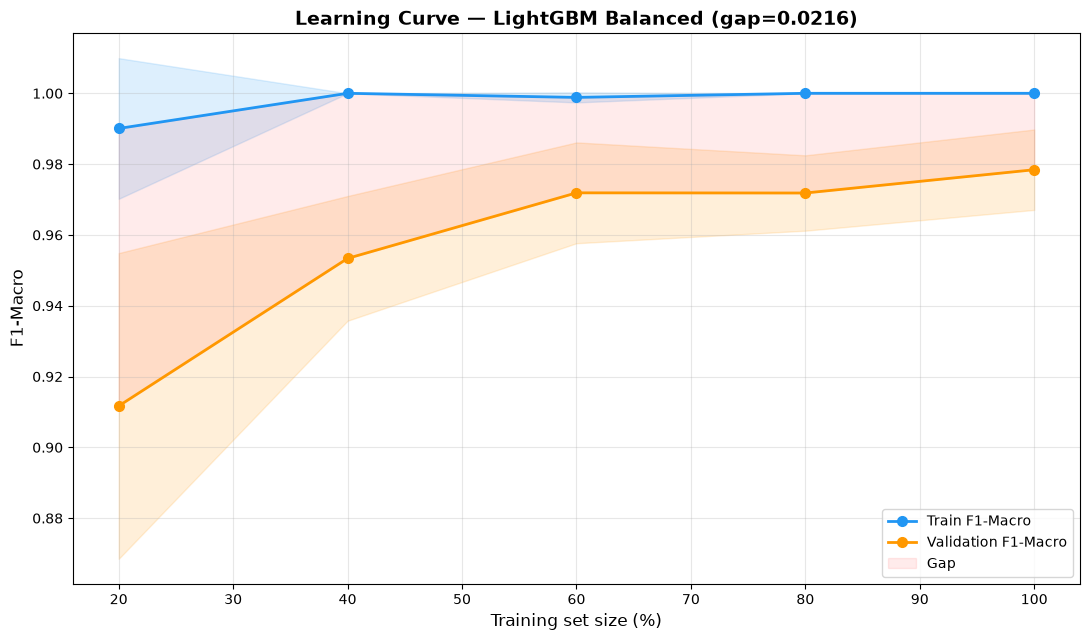

  Final Gap at 100% train: 0.0216

  Final Training — Balanced Params, Full Data

  Final OOF F1-Macro : 0.9881
  class1=0.9894 | class2=0.9765 | class3=0.9985
  Learning curve gap : 0.0216

 submission_lgb_balanced.csv جاهز!
target
class3    2933
class2     186
class1      81
Name: count, dtype: int64


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, ParameterSampler
from sklearn.metrics import f1_score, classification_report
import lightgbm as lgb
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

os.chdir(PROJECT_ROOT)
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

feature_cols    = [c for c in train.columns if c not in ['ID', 'target']]
continuous_cols = ['f1', 'f2', 'f9', 'f10', 'f14', 'f20']
eps = 1e-8

le = LabelEncoder()
y  = le.fit_transform(train['target'])
n_classes = len(le.classes_)


def add_weak_class_features(df):
    df = df.copy()
    df['f10_sq']        = df['f10'] ** 2
    df['log_f10']       = np.log(df['f10'] + eps)
    df['f10_div_f14']   = df['f10'] / (df['f14'] + eps)
    df['f10_div_f9']    = df['f10'] / (df['f9']  + eps)
    df['f10_minus_f14'] = df['f10'] - df['f14']
    df['f10_norm']         = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + eps)
    df['f10_share']        = df['f10'] / (df['f10'] + df['f9'] + df['f14'] + eps)
    df['f10_f14_contrast'] = (df['f10'] - df['f14']) / (df['f10'] + df['f14'] + df['f9'] + eps)
    df['f9_div_f14']       = df['f9'] / (df['f14'] + eps)
    return df

train_fe = add_weak_class_features(train)
test_fe  = add_weak_class_features(test)
fe_cols  = [c for c in train_fe.columns if c not in ['ID', 'target']]
X        = train_fe[fe_cols].values
X_test   = test_fe[fe_cols].values

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)








def evaluate_params(params, lam=0.5):
    oof_preds = np.zeros(len(X))
    train_f1s = []

    for tr_idx, val_idx in skf.split(X, y):
        y_tr, y_val = y[tr_idx], y[val_idx]

        rng = np.random.RandomState(7)
        n_es = max(int(len(tr_idx) * 0.25), 50)
        es_sub = rng.choice(len(tr_idx), n_es, replace=False)
        fit_mask = np.ones(len(tr_idx), dtype=bool); fit_mask[es_sub] = False
        fit_idx, es_idx = tr_idx[fit_mask], tr_idx[es_sub]

        model = lgb.LGBMClassifier(**params, random_state=42, n_jobs=-1, verbose=-1)
        model.fit(X[fit_idx], y[fit_idx],
                  eval_set=[(X[es_idx], y[es_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])

        oof_preds[val_idx] = model.predict(X[val_idx])
        train_f1s.append(f1_score(y[fit_idx], model.predict(X[fit_idx]), average='macro'))

    oof_f1   = f1_score(y, oof_preds, average='macro')
    train_f1 = np.mean(train_f1s)
    gap      = train_f1 - oof_f1
    score    = oof_f1 - lam * max(gap, 0)
    return oof_f1, train_f1, gap, score


param_grid = {
    'n_estimators'      : [300, 500, 800, 1200, 2000, 3000],
    'num_leaves'        : [15, 20, 31, 40, 50, 63],
    'max_depth'         : [4, 5, 6, 7, -1],
    'learning_rate'     : [0.01, 0.02, 0.03, 0.05, 0.08, 0.1],
    'min_child_samples' : [5, 10, 15, 20, 30, 50],
    'subsample'         : [0.6, 0.7, 0.8, 0.9, 1.0],
    'subsample_freq'    : [1, 3, 5],
    'colsample_bytree'  : [0.6, 0.7, 0.8, 0.9, 1.0],
    'reg_alpha'         : [0.0, 0.1, 0.3, 0.5, 1.0, 2.0],
    'reg_lambda'        : [0.0, 0.1, 0.3, 0.5, 1.0, 2.0],
    'min_split_gain'    : [0.0, 0.02, 0.05, 0.1],
}

n_iter = 100
param_list = list(ParameterSampler(param_grid, n_iter=n_iter, random_state=42))

print('=' * 70)
print(f'  Grid Search V2 — Balanced (λ=0.5, ES=100, val_es=25%) — {n_iter} iter')
print('=' * 70)

mlflow.set_experiment('clf_experiments_GRID_LGB_BALANCED')

best_score, best_params, best_metrics = -np.inf, None, None

for i, params in enumerate(param_list, 1):
    oof_f1, train_f1, gap, score = evaluate_params(params)

    with mlflow.start_run(run_name=f'LGB_BAL_iter_{i:03d}'):
        log_p = {'iteration': i, 'cv_folds': 5, 'penalty_lambda': 0.5}
        for k, v in params.items():
            log_p[k] = str(v)
        mlflow.log_params(log_p)
        mlflow.log_metric('oof_f1',   round(oof_f1, 4))
        mlflow.log_metric('train_f1', round(train_f1, 4))
        mlflow.log_metric('gap',      round(gap, 4))
        mlflow.log_metric('score',    round(score, 4))

    tag = '  NEW BEST' if score > best_score else ''
    print(f'  iter {i:03d}/{n_iter} | OOF={oof_f1:.4f} | train={train_f1:.4f} | '
          f'gap={gap:.4f} | score={score:.4f}{tag}')

    if score > best_score:
        best_score, best_params = score, params
        best_metrics = (oof_f1, train_f1, gap)

print('\n' + '=' * 70)
print(f'   Best Score : {best_score:.4f}')
print(f'   OOF F1={best_metrics[0]:.4f} | train F1={best_metrics[1]:.4f} | gap={best_metrics[2]:.4f}')
print(f'   Best Params:')
for k, v in best_params.items():
    print(f'      {k} = {v}')
print('=' * 70)




print('\n' + '=' * 70)
print('  Learning Curve — Balanced Anti-Overfit Params')
print('=' * 70)

train_sizes = [0.2, 0.4, 0.6, 0.8, 1.0]
lc_train_means, lc_val_means = [], []
lc_train_stds,  lc_val_stds  = [], []

for size in train_sizes:
    fold_tr, fold_val = [], []
    for fold, (tr_full, val_idx) in enumerate(skf.split(X, y), 1):
        rng = np.random.RandomState(42)
        n_sub  = int(len(tr_full) * size)
        tr_idx = rng.choice(tr_full, n_sub, replace=False)
        y_tr, y_val = y[tr_idx], y[val_idx]

        rng2 = np.random.RandomState(7)
        n_es = max(int(len(tr_idx) * 0.25), 40)
        es_sub = rng2.choice(len(tr_idx), n_es, replace=False)
        fit_mask = np.ones(len(tr_idx), dtype=bool); fit_mask[es_sub] = False
        fit_idx, es_idx = tr_idx[fit_mask], tr_idx[es_sub]

        model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)
        model.fit(X[fit_idx], y[fit_idx],
                  eval_set=[(X[es_idx], y[es_idx])],
                  callbacks=[lgb.early_stopping(100, verbose=False)])

        train_f1 = f1_score(y[fit_idx], model.predict(X[fit_idx]), average='macro')
        val_f1   = f1_score(y_val, model.predict(X[val_idx]), average='macro')
        fold_tr.append(train_f1); fold_val.append(val_f1)
        print(f'  size={size:.0%} fold={fold}/5 | train={train_f1:.4f} | val={val_f1:.4f}')

    lc_train_means.append(np.mean(fold_tr)); lc_val_means.append(np.mean(fold_val))
    lc_train_stds.append(np.std(fold_tr));   lc_val_stds.append(np.std(fold_val))
    print(f'  >>> size={size:.0%} AVG | train={lc_train_means[-1]:.4f} | '
          f'val={lc_val_means[-1]:.4f} | gap={lc_train_means[-1]-lc_val_means[-1]:.4f}\n')

lc_train_means = np.array(lc_train_means); lc_val_means = np.array(lc_val_means)
lc_train_stds  = np.array(lc_train_stds);  lc_val_stds  = np.array(lc_val_stds)
final_gap = lc_train_means[-1] - lc_val_means[-1]

fig, ax = plt.subplots(figsize=(11, 6.5))
x_pct = np.array(train_sizes) * 100
ax.plot(x_pct, lc_train_means, 'o-', color='#2196F3', linewidth=2, markersize=7, label='Train F1-Macro')
ax.fill_between(x_pct, lc_train_means-lc_train_stds, lc_train_means+lc_train_stds, alpha=0.15, color='#2196F3')
ax.plot(x_pct, lc_val_means, 'o-', color='#FF9800', linewidth=2, markersize=7, label='Validation F1-Macro')
ax.fill_between(x_pct, lc_val_means-lc_val_stds, lc_val_means+lc_val_stds, alpha=0.15, color='#FF9800')
ax.fill_between(x_pct, lc_val_means, lc_train_means, where=(lc_train_means>=lc_val_means),
                 interpolate=True, color='red', alpha=0.08, label='Gap')
ax.set_xlabel('Training set size (%)', fontsize=12)
ax.set_ylabel('F1-Macro', fontsize=12)
ax.set_title(f'Learning Curve — LightGBM Balanced (gap={final_gap:.4f})', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve_lgb_balanced.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 70)
print(f'  Final Gap at 100% train: {final_gap:.4f}')
print('=' * 70)




print('\n' + '=' * 70)
print('  Final Training — Balanced Params, Full Data')
print('=' * 70)

oof_preds  = np.zeros(len(X))
test_proba = np.zeros((len(X_test), n_classes))

for tr_idx, val_idx in skf.split(X, y):
    rng = np.random.RandomState(7)
    n_es = max(int(len(tr_idx) * 0.25), 50)
    es_sub = rng.choice(len(tr_idx), n_es, replace=False)
    fit_mask = np.ones(len(tr_idx), dtype=bool); fit_mask[es_sub] = False
    fit_idx, es_idx = tr_idx[fit_mask], tr_idx[es_sub]

    model = lgb.LGBMClassifier(**best_params, random_state=42, n_jobs=-1, verbose=-1)
    model.fit(X[fit_idx], y[fit_idx],
              eval_set=[(X[es_idx], y[es_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False)])

    oof_preds[val_idx] = model.predict(X[val_idx])
    test_proba += model.predict_proba(X_test) / skf.n_splits

final_oof_f1 = f1_score(y, oof_preds, average='macro')
final_report = classification_report(y, oof_preds, target_names=le.classes_, output_dict=True)
final_labels = le.inverse_transform(np.argmax(test_proba, axis=1))

print(f'\n  Final OOF F1-Macro : {final_oof_f1:.4f}')
print(f'  class1={final_report["class1"]["f1-score"]:.4f} | '
      f'class2={final_report["class2"]["f1-score"]:.4f} | '
      f'class3={final_report["class3"]["f1-score"]:.4f}')
print(f'  Learning curve gap : {final_gap:.4f}')

mlflow.set_experiment('clf_experiments_FINAL_SUBMISSION')
with mlflow.start_run(run_name='LGB_Single_Balanced_V2'):
    mlflow.log_params({
        'model'        : 'LGB_Single_Balanced',
        'fe_target'    : 'class1_class2_weak_only',
        'overfit_fix'  : 'early_stop100_es25pct_lambda0.5_wider_grid',
        'grid_n_iter'  : n_iter,
        'cv_folds'     : 5,
        'learning_curve_gap': round(float(final_gap), 4),
        **{f'best_{k}': str(v) for k, v in best_params.items()}
    })
    mlflow.log_metric('final_oof_f1', round(final_oof_f1, 4))
    mlflow.log_metric('learning_curve_gap', round(float(final_gap), 4))
    mlflow.log_metric('f1_class1', round(final_report['class1']['f1-score'], 4))
    mlflow.log_metric('f1_class2', round(final_report['class2']['f1-score'], 4))
    mlflow.log_metric('f1_class3', round(final_report['class3']['f1-score'], 4))

    submission = pd.DataFrame({'ID': test['ID'], 'target': final_labels})
    submission.to_csv('submission_lgb_balanced.csv', index=False)
    log_artifact_and_dvc('submission_lgb_balanced.csv')
    log_artifact_and_dvc('learning_curve_lgb_balanced.png')

print('\n submission_lgb_balanced.csv جاهز!')
print(submission['target'].value_counts())

## تجربة V3 Stable Top-K LightGBM Ensemble

هذه هي التجربة النهائية المحافظة. يتم اختبار بارامترات كثيرة، ثم اختيار أفضل Top-K وفق score يعاقب gap والتذبذب بين folds. في النهاية يتم حفظ ملف واحد فقط هو أفضل نسخة raw أو calibrated حسب OOF، ويتم تسجيله في MLflow وDVC.


In [5]:
import numpy as np
import pandas as pd
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, ParameterSampler, train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import lightgbm as lgb

warnings.filterwarnings("ignore")





RANDOM_STATE = 42
ID_COL = "ID"
TARGET_COL = "target"
EPS = 1e-8

N_ITER = 120
TOP_K = 5
SEEDS = [42, 137, 2026]





train = pd.read_csv(resolve_path('train_data.csv'))
test  = pd.read_csv(resolve_path('test_data.csv'))

le = LabelEncoder()
y = le.fit_transform(train[TARGET_COL])

classes = list(le.classes_)
n_classes = len(classes)

print("Classes:", classes)
print("\nTrain distribution:")
print(train[TARGET_COL].value_counts())





def add_weak_class_features(df):
    df = df.copy()

    df["f10_sq"]        = df["f10"] ** 2
    df["log_f10"]       = np.log(df["f10"] + EPS)
    df["f10_div_f14"]   = df["f10"] / (df["f14"] + EPS)
    df["f10_div_f9"]    = df["f10"] / (df["f9"]  + EPS)
    df["f10_minus_f14"] = df["f10"] - df["f14"]

    df["f10_norm"] = (
        (df["f10"] - df["f14"]) /
        (df["f10"] + df["f14"] + EPS)
    )

    df["f10_share"] = (
        df["f10"] /
        (df["f10"] + df["f9"] + df["f14"] + EPS)
    )

    df["f10_f14_contrast"] = (
        (df["f10"] - df["f14"]) /
        (df["f10"] + df["f14"] + df["f9"] + EPS)
    )

    df["f9_div_f14"] = df["f9"] / (df["f14"] + EPS)


    df["f10_div_f14_f9"] = df["f10"] / (df["f14"] + df["f9"] + EPS)
    df["f14_plus_f9"]    = df["f14"] + df["f9"]
    df["f14_minus_f9"]   = df["f14"] - df["f9"]

    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)

    return df


train_fe = add_weak_class_features(train)
test_fe  = add_weak_class_features(test)

fe_cols = [
    c for c in train_fe.columns
    if c not in [ID_COL, TARGET_COL]
]

X = train_fe[fe_cols].values
X_test = test_fe[fe_cols].values

print(f"\nFeatures: {len([c for c in train.columns if c not in [ID_COL, TARGET_COL]])} -> {len(fe_cols)}")





def make_fit_es_split(tr_idx, y, es_size=0.25, seed=42):
    local_idx = np.arange(len(tr_idx))

    fit_local, es_local = train_test_split(
        local_idx,
        test_size=es_size,
        random_state=seed,
        stratify=y[tr_idx]
    )

    fit_idx = tr_idx[fit_local]
    es_idx  = tr_idx[es_local]

    return fit_idx, es_idx






def evaluate_params_v3(params, seed=42, lam_gap=0.35, lam_std=0.20):
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=seed
    )

    oof_proba = np.zeros((len(X), n_classes))
    fold_f1s = []
    train_f1s = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        fit_idx, es_idx = make_fit_es_split(
            tr_idx,
            y,
            es_size=0.25,
            seed=seed + fold
        )

        model = lgb.LGBMClassifier(
            **params,
            random_state=seed,
            n_jobs=-1,
            verbose=-1
        )

        model.fit(
            X[fit_idx],
            y[fit_idx],
            eval_set=[(X[es_idx], y[es_idx])],
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        val_proba = model.predict_proba(X[val_idx])
        oof_proba[val_idx] = val_proba

        val_pred = np.argmax(val_proba, axis=1)
        fit_pred = model.predict(X[fit_idx])

        fold_f1 = f1_score(y[val_idx], val_pred, average="macro")
        train_f1 = f1_score(y[fit_idx], fit_pred, average="macro")

        fold_f1s.append(fold_f1)
        train_f1s.append(train_f1)

    oof_pred = np.argmax(oof_proba, axis=1)

    oof_f1 = f1_score(y, oof_pred, average="macro")
    train_f1 = float(np.mean(train_f1s))
    fold_std = float(np.std(fold_f1s))
    gap = train_f1 - oof_f1

    robust_score = (
        oof_f1
        - lam_gap * max(gap, 0)
        - lam_std * fold_std
    )

    return {
        "oof_f1": oof_f1,
        "train_f1": train_f1,
        "gap": gap,
        "fold_std": fold_std,
        "score": robust_score,
        "params": params
    }





param_grid_v3 = {
    "n_estimators":      [400, 500, 700, 900, 1200],
    "num_leaves":        [15, 20, 24, 31, 40],
    "max_depth":         [4, 5, 6, 7],
    "learning_rate":     [0.02, 0.03, 0.04, 0.05, 0.06],
    "min_child_samples": [10, 15, 20, 25, 30],
    "subsample":         [0.65, 0.70, 0.75, 0.80, 0.90],
    "subsample_freq":    [1, 3, 5],
    "colsample_bytree":  [0.75, 0.85, 0.95, 1.0],
    "reg_alpha":         [0.0, 0.1, 0.3, 0.5, 1.0],
    "reg_lambda":        [0.0, 0.1, 0.3, 0.5, 1.0, 2.0],
    "min_split_gain":    [0.0, 0.02, 0.05, 0.08],
}

param_list = list(ParameterSampler(
    param_grid_v3,
    n_iter=N_ITER,
    random_state=RANDOM_STATE
))





print("\n" + "=" * 70)
print(f"Grid Search V3 — robust score — {N_ITER} iterations")
print("=" * 70)

results = []
best_score_so_far = -np.inf

for i, params in enumerate(param_list, 1):
    res = evaluate_params_v3(params, seed=RANDOM_STATE)
    results.append(res)

    if res["score"] > best_score_so_far:
        best_score_so_far = res["score"]
        tag = " "
    else:
        tag = ""

    print(
        f"iter {i:03d}/{N_ITER} | "
        f"OOF={res['oof_f1']:.5f} | "
        f"train={res['train_f1']:.5f} | "
        f"gap={res['gap']:.5f} | "
        f"std={res['fold_std']:.5f} | "
        f"score={res['score']:.5f}{tag}"
    )





res_df = pd.DataFrame([
    {
        "oof_f1": r["oof_f1"],
        "train_f1": r["train_f1"],
        "gap": r["gap"],
        "fold_std": r["fold_std"],
        "score": r["score"],
        **r["params"]
    }
    for r in results
]).sort_values("score", ascending=False).reset_index(drop=True)

print("\n" + "=" * 70)
print("Top 10 params:")
print("=" * 70)
print(res_df.head(10))





stable_df = res_df[
    (res_df["gap"] <= 0.020) &
    (res_df["fold_std"] <= 0.020)
].copy()

if len(stable_df) < TOP_K:
    stable_df = res_df.copy()

top_df = stable_df.head(TOP_K)

param_keys = list(param_grid_v3.keys())
top_params = []

for _, row in top_df.iterrows():
    p = {}

    for k in param_keys:
        v = row[k]

        if k in [
            "n_estimators",
            "num_leaves",
            "max_depth",
            "min_child_samples",
            "subsample_freq"
        ]:
            p[k] = int(v)
        else:
            p[k] = float(v)

    top_params.append(p)

print("\n" + "=" * 70)
print("Selected Top-K params")
print("=" * 70)

for i, p in enumerate(top_params, 1):
    print(f"\nCandidate {i}:")
    for k, v in p.items():
        print(f"  {k}: {v}")






oof_sum = np.zeros((len(X), n_classes))
oof_count = np.zeros(len(X))
test_proba = np.zeros((len(X_test), n_classes))

total_models = 0

print("\n" + "=" * 70)
print("Final Training — Top-K × Repeated CV Ensemble")
print("=" * 70)

for cand_id, params in enumerate(top_params, 1):
    for seed in SEEDS:
        skf = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=seed
        )

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            fit_idx, es_idx = make_fit_es_split(
                tr_idx,
                y,
                es_size=0.25,
                seed=seed + fold + cand_id * 100
            )

            model = lgb.LGBMClassifier(
                **params,
                random_state=seed,
                n_jobs=-1,
                verbose=-1
            )

            model.fit(
                X[fit_idx],
                y[fit_idx],
                eval_set=[(X[es_idx], y[es_idx])],
                callbacks=[lgb.early_stopping(100, verbose=False)]
            )

            val_proba = model.predict_proba(X[val_idx])
            tst_proba = model.predict_proba(X_test)

            oof_sum[val_idx] += val_proba
            oof_count[val_idx] += 1
            test_proba += tst_proba

            total_models += 1

            val_f1 = f1_score(
                y[val_idx],
                np.argmax(val_proba, axis=1),
                average="macro"
            )

            print(
                f"cand={cand_id}/{TOP_K} "
                f"seed={seed} "
                f"fold={fold}/5 | "
                f"val_f1={val_f1:.5f}"
            )

oof_proba = oof_sum / oof_count[:, None]
test_proba = test_proba / total_models

raw_oof_pred = np.argmax(oof_proba, axis=1)
raw_oof_f1 = f1_score(y, raw_oof_pred, average="macro")

print("\n" + "=" * 70)
print(f"RAW TOP-K ENSEMBLE OOF F1 = {raw_oof_f1:.5f}")
print("=" * 70)
print(classification_report(y, raw_oof_pred, target_names=classes))
print(confusion_matrix(y, raw_oof_pred))







class_to_idx = {cls: i for i, cls in enumerate(classes)}

idx_class1 = class_to_idx.get("class1", 0)
idx_class2 = class_to_idx.get("class2", 1)

best_cal = {
    "score": -1,
    "m1": 1.0,
    "m2": 1.0
}

for m1 in np.arange(0.96, 1.121, 0.01):
    for m2 in np.arange(0.96, 1.101, 0.01):
        proba = oof_proba.copy()

        proba[:, idx_class1] *= m1
        proba[:, idx_class2] *= m2

        proba = proba / proba.sum(axis=1, keepdims=True)

        pred = np.argmax(proba, axis=1)
        score = f1_score(y, pred, average="macro")

        if score > best_cal["score"]:
            best_cal = {
                "score": float(score),
                "m1": float(m1),
                "m2": float(m2)
            }

print("\n" + "=" * 70)
print("Best restricted calibration")
print("=" * 70)
print(best_cal)

cal_oof_proba = oof_proba.copy()
cal_oof_proba[:, idx_class1] *= best_cal["m1"]
cal_oof_proba[:, idx_class2] *= best_cal["m2"]
cal_oof_proba = cal_oof_proba / cal_oof_proba.sum(axis=1, keepdims=True)

cal_oof_pred = np.argmax(cal_oof_proba, axis=1)
cal_oof_f1 = f1_score(y, cal_oof_pred, average="macro")

print("\n" + "=" * 70)
print(f"CALIBRATED OOF F1 = {cal_oof_f1:.5f}")
print("=" * 70)
print(classification_report(y, cal_oof_pred, target_names=classes))
print(confusion_matrix(y, cal_oof_pred))

cal_test_proba = test_proba.copy()
cal_test_proba[:, idx_class1] *= best_cal["m1"]
cal_test_proba[:, idx_class2] *= best_cal["m2"]
cal_test_proba = cal_test_proba / cal_test_proba.sum(axis=1, keepdims=True)







print("\n" + "=" * 70)
print("Choose best version and save ONLY ONE submission")
print("=" * 70)

print(f"RAW OOF F1        : {raw_oof_f1:.5f}")
print(f"CALIBRATED OOF F1 : {cal_oof_f1:.5f}")

if cal_oof_f1 > raw_oof_f1:
    best_version = "calibrated"
    best_oof_f1 = cal_oof_f1
    final_test_proba = cal_test_proba
else:
    best_version = "raw"
    best_oof_f1 = raw_oof_f1
    final_test_proba = test_proba

final_labels = le.inverse_transform(np.argmax(final_test_proba, axis=1))

submission = pd.DataFrame({
    ID_COL: test[ID_COL].values,
    TARGET_COL: final_labels
})

output_name = "submission_lgb_v3_best_only.csv"
submission.to_csv(output_name, index=False)

print("\n Saved ONLY ONE file:")
print(output_name)

print("\nBest version:", best_version)
print(f"Best OOF F1 : {best_oof_f1:.5f}")

print("\nFinal submission distribution:")
print(submission[TARGET_COL].value_counts())

print("\nDone.")

import mlflow
mlflow.set_experiment("clf_experiments_FINAL_SUBMISSION")
with mlflow.start_run(run_name="LGB_V3_Stable_TopK_BestOnly"):
    mlflow.log_params({
        "model": "LightGBM",
        "experiment_type": "Stable_TopK_Ensemble",
        "n_iter": N_ITER,
        "top_k": TOP_K,
        "seeds": str(SEEDS),
        "best_version": best_version,
        "n_features": len(fe_cols),
        "calibration_m1": best_cal["m1"],
        "calibration_m2": best_cal["m2"]
    })
    mlflow.log_metric("raw_oof_f1", float(raw_oof_f1))
    mlflow.log_metric("calibrated_oof_f1", float(cal_oof_f1))
    mlflow.log_metric("best_oof_f1", float(best_oof_f1))
    log_artifact_and_dvc(output_name)


Classes: ['class1', 'class2', 'class3']

Train distribution:
target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

Features: 21 -> 33

Grid Search V3 — robust score — 120 iterations
iter 001/120 | OOF=0.98345 | train=1.00000 | gap=0.01655 | std=0.00750 | score=0.97616 
iter 002/120 | OOF=0.98532 | train=1.00000 | gap=0.01468 | std=0.00416 | score=0.97935 
iter 003/120 | OOF=0.97714 | train=0.99786 | gap=0.02073 | std=0.01342 | score=0.96720
iter 004/120 | OOF=0.97907 | train=0.99817 | gap=0.01909 | std=0.00744 | score=0.97090
iter 005/120 | OOF=0.97988 | train=0.99725 | gap=0.01737 | std=0.00620 | score=0.97256
iter 006/120 | OOF=0.98349 | train=0.99847 | gap=0.01498 | std=0.00860 | score=0.97652
iter 007/120 | OOF=0.97714 | train=0.99848 | gap=0.02134 | std=0.01507 | score=0.96666
iter 008/120 | OOF=0.98438 | train=1.00000 | gap=0.01562 | std=0.00788 | score=0.97733
iter 009/120 | OOF=0.98083 | train=1.00000 | gap=0.01917 | std=0.00864 | score=0.97240
iter 010

# فحص سريع بعد انتهاء التشغيل

بعد تشغيل كل الخلايا، استخدم الخلية التالية للتأكد أن التجارب ظهرت داخل MLflow. الجدول يعرض أسماء الـ experiments وعدد الـ runs. إذا ظهر عدد runs أكبر من صفر فهذا يعني أن التسجيل تم بنجاح، ويمكن فتح واجهة MLflow بالأمر الموجود في بداية اللاب.


In [6]:
import pandas as pd
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)
rows = []

for exp in client.search_experiments():
    runs = client.search_runs(experiment_ids=[exp.experiment_id])
    rows.append({
        "experiment_id": exp.experiment_id,
        "experiment_name": exp.name,
        "runs_count": len(runs),
        "lifecycle_stage": exp.lifecycle_stage
    })

mlflow_summary = pd.DataFrame(rows).sort_values(["experiment_name"])
display(mlflow_summary)


,experiment_id,experiment_name,runs_count,lifecycle_stage
19,0,Default,0,active
18,1,clf_experiments_BL,6,active
17,2,clf_experiments_CW,6,active
2,17,clf_experiments_DIAGNOSTICS,2,active
9,10,clf_experiments_FE,6,active
8,11,clf_experiments_FE_V2,6,active
7,12,clf_experiments_FE_V3,6,active
5,14,clf_experiments_FINAL_SUBMISSION,19,active
1,18,clf_experiments_GRID_LGB_ANTI_OVERFIT,159,active
0,19,clf_experiments_GRID_LGB_BALANCED,100,active


In [7]:
PROJECT_ROOT = Path.cwd()

print("1) اعادة تهيئة DVC مربوطة مع git (force reinit)...")
run_command(["git", "init", "--quiet"])
result = run_command(["dvc", "init", "-f", "--quiet"])
if result.returncode != 0:
    raise RuntimeError("فشل dvc init -f - تأكد انو DVC مثبت وانك جوا مجلد المشروع")
run_command(["dvc", "config", "core.analytics", "false"])

print("\n2) لاقيت ملفات .dvc قديمة (متتبعة بدون git) واعيد تتبعها من جديد...")
old_pointers = sorted(
    p for p in PROJECT_ROOT.rglob("*.dvc")
    if p.name != ".dvc"
    and ".dvc" not in p.relative_to(PROJECT_ROOT).parts[:-1]
    and ".git" not in p.relative_to(PROJECT_ROOT).parts[:-1]
)

recovered, missing = [], []
for pointer in old_pointers:
    original = pointer.with_suffix("")
    if original.exists():
        r = run_command(["dvc", "add", str(original)])
        (recovered if r.returncode == 0 else missing).append(str(original.relative_to(PROJECT_ROOT)))
    else:
        missing.append(f"{original.relative_to(PROJECT_ROOT)} (مو موجود ع الديسك)")

print(f"   انعاد تتبعها بنجاح: {len(recovered)}")
for f in recovered:
    print(f"   - {f}")
if missing:
    print(f"   تعذر التعامل معها: {len(missing)}")
    for f in missing:
        print(f"   - {f}")

print("\n3) staging كل شي لـ git (بدون commit تلقائي)...")
run_command(["git", "add", "-A"])
staged = subprocess.run(["git", "diff", "--cached", "--name-only"], capture_output=True, text=True).stdout.strip()
print("جاهز للـ commit:")
print(staged if staged else "  (ولا شي - راجع اذا صار خطأ فوق)")

1) اعادة تهيئة DVC مربوطة مع git (force reinit)...

2) لاقيت ملفات .dvc قديمة (متتبعة بدون git) واعيد تتبعها من جديد...
   انعاد تتبعها بنجاح: 45
   - cv_folds_comparison_5_vs_10.png
   - learning_curve_fixed.png
   - learning_curve_full_stacking.png
   - learning_curve_lgb_anti_overfit.png
   - learning_curve_lgb_balanced.png
   - submission_catboost_best.csv
   - submission_class_specialized.csv
   - submission_class_specialized_fixed.csv
   - submission_CW_01_no_weight.csv
   - submission_CW_02_current.csv
   - submission_CW_03_mild_c1.csv
   - submission_CW_04_strong_c1.csv
   - submission_CW_05_very_strong_c1.csv
   - submission_CW_06_extreme_c1.csv
   - submission_CW_07_mild_c2.csv
   - submission_CW_08_strong_c2.csv
   - submission_CW_09_very_strong_c2.csv
   - submission_CW_10_equal_c1_c2.csv
   - submission_CW_11_equal_strong.csv
   - submission_CW_12_focus_c1_only.csv
   - submission_CW_13_focus_c2_only.csv
   - submission_CW_14_balanced_auto.csv
   - submission_CW_15_double_

In [8]:
print("1) الغاء الـ staging الحالي (ما في ولا شي انعمل commit، فالخطوة آمنة)...")
run_command(["git", "reset"])

print("\n2) استثناء مجلدات MLflow/CatBoost الداخلية من git (بتضل موجودة عالديسك، بس مش متتبعة بـ git)...")
gitignore_path = PROJECT_ROOT / ".gitignore"
existing = gitignore_path.read_text(encoding="utf-8") if gitignore_path.exists() else ""
to_add = ["mlruns/", "mlflow.db", "catboost_info/"]
missing_lines = [line for line in to_add if line not in existing]
if missing_lines:
    with gitignore_path.open("a", encoding="utf-8") as f:
        f.write("\n" + "\n".join(missing_lines) + "\n")

print("\n3) اعادة الـ staging الصح...")
run_command(["git", "add", "-A"])
staged = subprocess.run(["git", "diff", "--cached", "--name-only"], capture_output=True, text=True).stdout.strip().splitlines()
print(f"عدد الملفات الجاهزة للـ commit هلق: {len(staged)}")
noise = [f for f in staged if f.startswith(("mlruns/", "catboost_info/")) or f == "mlflow.db"]
print("فحص أخير:", "لسا في مشكلة!" if noise else "نظيف، ولا ملف mlruns/mlflow.db/catboost_info بالقائمة")
print("\nالقائمة:")
for f in staged:
    print(f"   - {f}")

1) الغاء الـ staging الحالي (ما في ولا شي انعمل commit، فالخطوة آمنة)...

2) استثناء مجلدات MLflow/CatBoost الداخلية من git (بتضل موجودة عالديسك، بس مش متتبعة بـ git)...

3) اعادة الـ staging الصح...
عدد الملفات الجاهزة للـ commit هلق: 66
فحص أخير: نظيف، ولا ملف mlruns/mlflow.db/catboost_info بالقائمة

القائمة:
   - .dvc/.gitignore
   - .dvc/config
   - .dvcignore
   - .gitignore
   - EDA_classification_mlflow_dvc_clean.ipynb
   - binary_distributions.png
   - boxplot_by_class.png
   - class_distribution.png
   - continuous_distributions.png
   - correlation_matrix.png
   - cv_folds_comparison_5_vs_10.png.dvc
   - eda_01_distributions.png
   - eda_02_boxplots.png
   - eda_03_pairplot.png
   - eda_04_correlation.png
   - eda_05_mutual_info.png
   - eda_06_interactions.png
   - eda_07_interaction_mi.png
   - feature_importance.png
   - learning_curve_fixed.png.dvc
   - learning_curve_full_stacking.png.dvc
   - learning_curve_lgb_anti_overfit.png.dvc
   - learning_curve_lgb_balanced.png.d

<style>
.jp-RenderedMarkdown table {
    display: block;
    overflow-x: auto;
    white-space: normal;
    width: 100%;
}

.jp-RenderedMarkdown th,
.jp-RenderedMarkdown td {
    min-width: 220px;
    vertical-align: top;
    text-align: right;
    direction: rtl;
}
</style>

<style>
.submission-section {
    direction: rtl;
    text-align: right;
    font-family: Arial, sans-serif;
    line-height: 1.9;
    color: #0f172a !important;
    background: #f8fafc !important;
    padding: 24px;
    border-radius: 14px;
    border: 2px solid #cbd5e1;
}

.submission-section h2 {
    color: #0f172a !important;
    background: #e0f2fe !important;
    border-bottom: 4px solid #2563eb;
    padding: 16px;
    border-radius: 10px;
    margin-bottom: 20px;
    font-weight: bold;
}

.submission-section .intro-box {
    background: #ffffff !important;
    color: #0f172a !important;
    border: 2px solid #2563eb;
    border-radius: 12px;
    padding: 18px 22px;
    margin: 18px 0;
    line-height: 1.9;
    font-size: 16px;
}

.submission-section details {
    border: 2px solid #64748b;
    border-radius: 12px;
    margin: 18px 0;
    background: #ffffff !important;
    box-shadow: 0 3px 10px rgba(15, 23, 42, 0.16);
}

.submission-section summary {
    cursor: pointer;
    font-weight: bold;
    padding: 16px 20px;
    background: #93c5fd !important;
    border-radius: 10px;
    color: #0f172a !important;
    font-size: 17px;
}

.submission-section details[open] summary {
    background: #2563eb !important;
    border-bottom: 2px solid #1d4ed8;
    border-radius: 10px 10px 0 0;
    color: #ffffff !important;
}

.exp-body {
    padding: 18px 22px;
    max-height: 680px;
    overflow-y: auto;
    background: #f1f5f9 !important;
}

.exp-body table {
    width: 100%;
    border-collapse: collapse;
    table-layout: fixed;
    background: #ffffff !important;
}

.exp-body th,
.exp-body td {
    border: 1.5px solid #64748b;
    padding: 13px;
    vertical-align: top;
    text-align: right;
    white-space: normal;
    word-wrap: break-word;
    color: #0f172a !important;
    font-size: 15px;
}

.exp-body th {
    width: 240px;
    background: #bfdbfe !important;
    font-weight: bold;
    color: #0f172a !important;
}

.exp-body td {
    background: #ffffff !important;
    color: #1e293b !important;
}

.score-high {
    color: #064e3b !important;
    font-weight: bold;
    background: #bbf7d0 !important;
    padding: 4px 9px;
    border-radius: 7px;
}

.score-mid {
    color: #78350f !important;
    font-weight: bold;
    background: #fde68a !important;
    padding: 4px 9px;
    border-radius: 7px;
}

.score-low {
    color: #7f1d1d !important;
    font-weight: bold;
    background: #fecaca !important;
    padding: 4px 9px;
    border-radius: 7px;
}

.submission-section code {
    color: #7f1d1d !important;
    background: #fee2e2 !important;
    padding: 3px 7px;
    border-radius: 6px;
    font-weight: bold;
}
</style>

<div class="submission-section">

<h2>مقارنة تفصيلية بين ملفات الـ Submission</h2>

<div class="intro-box">
تلخيص للنتائج التي تم رفعها على منصة المسابقة
</div>

<details open>
<summary>1. submission_class_specialized.csv — Kaggle Public Score: 0.98435</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_class_specialized.csv` |
| Kaggle Public Score | <span class="score-high">0.98435</span> |
| Experiment Type | Class-Specialized Stacking |
| Core Modeling Strategy | تعتمد هذه التجربة على فكرة أن كل class قد يحتاج طريقة فصل مختلفة. لذلك تم بناء مسارات متخصصة لكل class، ثم دمج نتائج هذه المسارات داخل Stacking نهائي. |
| Models Used | CatBoost, LightGBM, XGBoost, RandomForest, SVM, KNN, Logistic Regression كـ meta model. |
| Training Methodology | تم استخدام Stratified K-Fold Cross Validation للحفاظ على توزيع الكلاسات داخل كل fold. كل موديل ينتج احتمالات OOF، ثم يتم استخدام هذه الاحتمالات كمدخلات لمرحلة الدمج النهائية. |
| Data Processing and Feature Engineering | تم استخدام البيانات بعد preprocessing الأساسي، ثم أضيفت Features موجهة للكلاسات. Class 1 اعتمد أكثر على `f10`. Class 2 اعتمد على العلاقات بين `f10`, `f14`, `f9`. Class 3 اعتمد على خصائص مرتبطة بـ `f14` و`f9`. |
| Important Hyperparameters | CatBoost: `iterations=700`, `depth=6`, `learning_rate=0.1`. LightGBM: `n_estimators=1000`, `num_leaves=100`, `max_depth=3`, `learning_rate=0.05`. XGBoost: `n_estimators=200`, `max_depth=5`, `learning_rate=0.2`. |
| Internal Validation Protocol and Interpretation | التقييم الداخلي هنا يعتمد على OOF F1-Macro الناتج من Cross Validation. هذا المقياس مهم لأنه يقيس أداء النموذج على أجزاء من بيانات التدريب لم يرها أثناء تدريب كل fold. إذا كانت قيمة OOF F1-Macro قريبة من Kaggle Score فهذا يشير إلى تعميم جيد. أما إذا كانت أعلى بكثير من Kaggle فقد يدل ذلك على overfitting أو اختلاف توزيع train/test. |
| Generalization Diagnostic | هذه التجربة أعطت أعلى Kaggle Score، لذلك يبدو أن التخصص حسب الكلاس لم يكن مجرد تحسين داخلي، بل انعكس أيضاً على test الخارجي. مع ذلك، لأنها تجربة معقدة، يجب مراقبة train-validation gap داخل MLflow. |
| Reason for Experiment | الهدف كان تحسين الكلاسات الصعبة عن طريق بناء Features وموديلات خاصة بها بدل الاعتماد على نموذج واحد يعامل جميع الكلاسات بنفس الطريقة. |
| Difference from Previous Simpler Models | تختلف عن Stacking العادي بأنها لا تدمج موديلات عامة فقط، بل تبني مسارات موجهة للكلاسات، وهذا يعطي مرونة أكبر في فصل الحدود بين الكلاسات. |
| Strength | أعلى نتيجة، وتجمع بين Feature Engineering موجه، وموديلات قوية، وStacking متعدد المستويات. |
| Limitation | أكثر تعقيداً، وتحتاج تفسير واضح حتى لا تبدو كتجربة عشوائية أو over-engineered. |
| Overall Experimental Assessment | هذه أقوى تجربة من حيث النتيجة النهائية. يمكن اعتبارها أفضل submission، لكنها تحتاج شرح منهجي جيد لأنها تعتمد على أكثر من مرحلة وأكثر من نوع Feature Engineering. |

</div>
</details>

<details>
<summary>2. submission_lgb_balanced.csv — Kaggle Public Score: 0.98239</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_lgb_balanced.csv` |
| Kaggle Public Score | <span class="score-high">0.98239</span> |
| Experiment Type | Balanced LightGBM |
| Core Modeling Strategy | استخدام LightGBM فقط مع بحث مضبوط للباراميترات وعقوبة متوسطة على overfitting. |
| Models Used | LightGBM فقط. |
| Training Methodology | 5-Fold Stratified Cross Validation مع Early Stopping وRandom Search. تم اختيار الإعداد الأفضل بناءً على OOF performance مع مراقبة gap بين train وvalidation. |
| Data Processing and Feature Engineering | preprocessing الأساسي مع إضافة weak-class features لتحسين فصل الكلاسات الصعبة. |
| Important Hyperparameters | Random Search بعدد تجارب قريب من `n_iter=100`. العقوبة الداخلية تقريباً: `OOF_F1 - 0.5 × gap`. Early stopping = 100. |
| Feature Engineering Details | استخدمت Features مثل `f10_sq`, `log_f10`, `f10_div_f14`, `f10_div_f9`, `f10_minus_f14`, `f10_norm`, `f10_share`, `f10_f14_contrast`, `f9_div_f14`. |
| Internal Validation Protocol and Interpretation | المقياس الداخلي الأساسي هو OOF F1-Macro أو CV F1-Macro. في هذه التجربة يجب تفسيره مع train-validation gap. إذا كان OOF مرتفعاً والـ gap محدوداً فهذا يعني أن LightGBM تعلم نمطاً عاماً وليس فقط حفظ بيانات التدريب. |
| Generalization Diagnostic | ارتفاع Kaggle Score يدل أن التوازن بين قوة النموذج والـ regularization كان مناسباً. هذه التجربة لم تكن صارمة جداً مثل anti-overfit، ولم تكن معقدة مثل stacking. |
| Reason for Experiment | الهدف إيجاد نموذج قوي وبسيط نسبياً يعطي أداء قريب من أعلى التجارب دون الحاجة إلى ensemble كبير. |
| Difference from Anti-Overfit Version | النسخة balanced تسمح للنموذج أن يتعلم أكثر، بينما anti-overfit كانت تعاقب gap بقوة وتقلل قدرة النموذج على التقاط الأنماط. |
| Strength | أداء عال جداً بموديل واحد، وسهل الدفاع عنه في التقرير. |
| Limitation | لا يستفيد من تنوع الموديلات كما في stacking. |
| Overall Experimental Assessment | هذه من أفضل التجارب منهجياً، لأنها تحقق توازناً ممتازاً بين الأداء والبساطة وقابلية الشرح. |

</div>
</details>

<details>
<summary>3. submission_lgb_v3_best_only.csv — Kaggle Public Score: 0.98046</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_lgb_v3_best_only.csv` |
| Kaggle Public Score | <span class="score-high">0.98046</span> |
| Experiment Type | Stable Top-K LightGBM |
| Core Modeling Strategy | البحث عن إعدادات LightGBM مستقرة، وليس فقط إعداد واحد يعطي نتيجة عالية بالصدفة. |
| Models Used | LightGBM فقط. |
| Training Methodology | Random Search ثم اختيار أفضل Top-K configurations بناءً على OOF score والاستقرار بين folds. بعض النسخ تستخدم أكثر من seed لزيادة الثبات. |
| Data Processing and Feature Engineering | preprocessing الأساسي مع weak-class features أوسع من النسخ السابقة. |
| Important Hyperparameters | `N_ITER=120`, `TOP_K=5`, seeds مثل `42`, `137`, `2026`. Grid يشمل `n_estimators`, `num_leaves`, `max_depth`, `learning_rate`, `min_child_samples`, `reg_alpha`, `reg_lambda`, `subsample`, `colsample_bytree`. |
| Feature Engineering Details | Features مثل `f10_sq`, `log_f10`, `f10_div_f14`, `f10_div_f9`, `f10_div_f14_f9`, `f14_plus_f9`, `f14_minus_f9`. |
| Internal Validation Protocol and Interpretation | التقييم الداخلي يعتمد على OOF F1-Macro مع fold mean وfold std. قيمة fold std مهمة هنا لأنها تخبرنا هل الإعداد المختار مستقر عبر التقسيمات أم قوي على fold وضعيف على آخر. |
| Generalization Diagnostic | النتيجة الخارجية قوية جداً وتساوي عدة تجارب Stacking، وهذا يعني أن LightGBM مستقر وقادر على التعميم عند اختيار إعداداته بعناية. |
| Reason for Experiment | تقليل الاعتماد على seed واحد أو parameter set واحد، وزيادة الثقة بأن النتيجة ليست مصادفة. |
| Difference from lgb_balanced | `lgb_balanced` يركز على أفضل توازن عام، أما `lgb_v3_best_only` فيركز أكثر على الاستقرار عبر configurations وseeds. |
| Strength | مستقر ومنطقي من ناحية validation design. |
| Limitation | لم يتجاوز `lgb_balanced` رغم زيادة البحث. |
| Overall Experimental Assessment | تجربة قوية لشرح أهمية stability في اختيار الباراميترات، لكنها ليست الأعلى score. |

</div>
</details>

<details>
<summary>4. submission_hierarchical_grid_best.csv — Kaggle Public Score: 0.98046</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_hierarchical_grid_best.csv` |
| Kaggle Public Score | <span class="score-high">0.98046</span> |
| Experiment Type | Hierarchical Stacking |
| Core Modeling Strategy | بناء ensemble هرمي: موديلات بسيطة في المستوى الأول، ثم موديلات boosting في المستوى الثاني، ثم meta model نهائي. |
| Models Used | Level 0: KNN, SVM, RandomForest. Level 1: CatBoost, LightGBM, XGBoost. Final Meta: Logistic Regression. |
| Training Methodology | إنتاج OOF probabilities من Level 0، ثم استخدامها كـ features إضافية في Level 1، وبعدها تدريب meta model على احتمالات Level 1. |
| Data Processing and Feature Engineering | إضافة احتمالات Level 0 كخصائص جديدة بجانب features الأصلية. |
| Important Hyperparameters | KNN مع distance weighting، SVM غير خطي، RandomForest بعدد أشجار كبير نسبياً، ثم CatBoost/LGB/XGB بإعدادات stacking الأساسية. |
| Internal Validation Protocol and Interpretation | التقييم الداخلي يعتمد على OOF F1-Macro عبر المستويات. في هذا النوع من التجارب يجب التأكد أن كل OOF probability تم توليده فقط من fold لم يدخل في تدريب ذلك الموديل حتى لا يحدث leakage. |
| Generalization Diagnostic | بما أن Kaggle Score لم يتحسن عن stacking الأساسي، فهذا يعني أن المستوى الهرمي أضاف تعقيداً، لكنه لم يقدم معلومات خارجية كافية لتحسين public test. |
| Reason for Experiment | اختبار ما إذا كانت الموديلات البسيطة تلتقط أنماطاً لا تلتقطها موديلات boosting. |
| Difference from Basic Stacking | Basic stacking يدمج CatBoost/LGB/XGB مباشرة. أما hierarchical stacking فيضيف مستوى أول قبلها. |
| Strength | تصميم متقدم ويختبر مصادر مختلفة للقرار. |
| Limitation | أكثر تعقيداً وتكلفة، والنتيجة لم تتحسن. |
| Overall Experimental Assessment | تجربة جيدة تعليمياً ومنهجياً، لكنها لم تعط فائدة عملية واضحة مقارنة بالـ stacking الأبسط. |

</div>
</details>

<details>
<summary>5. submission_stacking_10fold.csv — Kaggle Public Score: 0.98046</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_stacking_10fold.csv` |
| Kaggle Public Score | <span class="score-high">0.98046</span> |
| Experiment Type | 10-Fold Stacking |
| Core Modeling Strategy | نفس stacking الأساسي، لكن باستخدام 10 folds بدل 5 folds لزيادة دقة OOF predictions. |
| Models Used | CatBoost, LightGBM, XGBoost, Logistic Regression كـ meta model. |
| Training Methodology | 10-Fold Stratified CV. كل موديل يتم تدريبه 10 مرات، وينتج احتمالات validation لكل fold. |
| Data Processing and Feature Engineering | preprocessing الأساسي، بدون إضافة كبيرة مقارنة بالنسخ المتخصصة. |
| Important Hyperparameters | CatBoost: `700`, `depth=6`, `lr=0.1`. LightGBM: `1000`, `num_leaves=100`, `max_depth=3`, `lr=0.05`. XGBoost: `200`, `max_depth=5`, `lr=0.2`. |
| Internal Validation Protocol and Interpretation | المقياس الداخلي هو OOF F1-Macro من 10 folds. نظرياً، 10 folds يعطي OOF أكثر نعومة واستقراراً، لكن قد يزيد وقت التدريب. إذا لم تتحسن النتيجة مقارنة بـ 5 folds فهذا يعني أن 5 folds كانت كافية. |
| Generalization Diagnostic | Kaggle Score ساوى stacking الأساسي تقريباً، لذلك زيادة folds لم تغير generalization بشكل واضح. |
| Reason for Experiment | اختبار أثر عدد folds على الاستقرار والأداء. |
| Difference from Basic Stacking | الفرق الأساسي هو عدد folds فقط، وليس نوع الموديلات. |
| Strength | تقييم داخلي أكثر تفصيلاً وثباتاً نظرياً. |
| Limitation | وقت تدريب أعلى بدون تحسن خارجي واضح. |
| Overall Experimental Assessment | تجربة مفيدة لإثبات أن زيادة عدد folds ليست دائماً طريقاً مضموناً لتحسين Kaggle score. |

</div>
</details>

<details>
<summary>6. submission_stacking_v2.csv — Kaggle Public Score: 0.98046</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_stacking_v2.csv` |
| Kaggle Public Score | <span class="score-high">0.98046</span> |
| Experiment Type | Feature-Engineered Weighted Stacking |
| Core Modeling Strategy | تطوير stacking الأساسي بإضافة features جديدة وclass weights، واستخدام CatBoost كـ meta model. |
| Models Used | CatBoost, LightGBM, XGBoost, ثم CatBoost Meta. |
| Training Methodology | 5-Fold Stratified CV مع class weights. يتم إنتاج OOF probabilities من الموديلات الأساسية ثم تدريب meta model. |
| Data Processing and Feature Engineering | إضافة إحصائيات row-wise مثل mean, std, max, min, range، وإضافة ranks وتفاعلات بين features، وإضافة cluster feature من KMeans. |
| Important Hyperparameters | Class weights للكلاسات الضعيفة، وMeta CatBoost بإعدادات مثل `iterations=200`, `depth=3`, `learning_rate=0.05`. |
| Internal Validation Protocol and Interpretation | داخلياً يجب متابعة OOF F1-Macro وper-class F1. هذه التجربة مصممة لتحسين الكلاسات الضعيفة، لذلك لا يكفي النظر إلى macro score فقط، بل يجب النظر هل class weights حسنت F1 للكلاسات الصغيرة أم أضرت الكلاس الأكبر. |
| Generalization Diagnostic | Kaggle Score لم يتحسن عن stacking الأساسي، ما يعني أن feature engineering وclass weights لم تضف generalization واضح على public test. |
| Reason for Experiment | معالجة ضعف بعض الكلاسات عبر وزنها أكثر وإضافة خصائص تساعد على فصلها. |
| Difference from Basic Stacking | إضافة feature engineering، class weights، وCatBoost meta بدلاً من Logistic Regression. |
| Strength | تجربة شاملة تحاول معالجة imbalance وfeature interactions. |
| Limitation | زيادة التعقيد لم ترفع public score. |
| Overall Experimental Assessment | تجربة مهمة للتحليل، لكنها تثبت أن زيادة features والأوزان لا تضمن تحسناً خارجياً. |

</div>
</details>

<details>
<summary>7. submission_stacking.csv — Kaggle Public Score: 0.98046</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_stacking.csv` |
| Kaggle Public Score | <span class="score-high">0.98046</span> |
| Experiment Type | Basic Stacking |
| Core Modeling Strategy | دمج ثلاث موديلات boosting قوية داخل meta model يتعلم كيف يوازن بينها. |
| Models Used | CatBoost, LightGBM, XGBoost, Logistic Regression. |
| Training Methodology | 5-Fold Stratified CV لإنتاج OOF probabilities من كل موديل، ثم تدريب Logistic Regression على هذه الاحتمالات. |
| Data Processing and Feature Engineering | preprocessing الأساسي للداتا بدون هندسة خصائص معقدة. |
| Important Hyperparameters | CatBoost: `iterations=700`, `depth=6`, `learning_rate=0.1`. LGB: `n_estimators=1000`, `num_leaves=100`, `max_depth=3`, `learning_rate=0.05`. XGB: `n_estimators=200`, `max_depth=5`, `learning_rate=0.2`. |
| Internal Validation Protocol and Interpretation | يعتمد على OOF F1-Macro. هذا مناسب للـ stacking لأن meta model يجب أن يتدرب على تنبؤات خارج التدريب، وليس على تنبؤات من نفس البيانات التي تدربت عليها الموديلات الأساسية. |
| Generalization Diagnostic | النتيجة قوية وتساوي تجارب أكثر تعقيداً، وهذا يدل أن stacking الأساسي التقط أغلب الإشارة المهمة في البيانات. |
| Reason for Experiment | إنشاء baseline مركب قوي باستخدام أشهر موديلات tabular boosting. |
| Difference from Soft Voting | Soft Voting يدمج بمتوسط ثابت، بينما stacking يتعلم أوزان الدمج من البيانات. |
| Strength | قوي، واضح، وسهل الدفاع عنه. |
| Limitation | لا يعالج كل class بشكل متخصص. |
| Overall Experimental Assessment | يعتبر baseline أساسي جداً. أي تجربة متقدمة يجب أن تثبت أنها أفضل منه وليس فقط أكثر تعقيداً. |

</div>
</details>

<details>
<summary>8. submission_class_specialized_fixed.csv — Kaggle Public Score: 0.97955</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_class_specialized_fixed.csv` |
| Kaggle Public Score | <span class="score-high">0.97955</span> |
| Experiment Type | Conservative Class-Specialized Stacking |
| Core Modeling Strategy | نسخة أكثر تحفظاً من class-specialized، تهدف إلى تقليل التعقيد أو تقليل احتمالية overfitting. |
| Models Used | CatBoost, LightGBM, XGBoost, Logistic Regression. |
| Training Methodology | Stratified CV مع مسارات class-specific أبسط من النسخة الأصلية. |
| Data Processing and Feature Engineering | استخدام features موجهة للكلاسات، لكن بطريقة أقل عدوانية من النسخة الأصلية. |
| Important Hyperparameters | نفس عائلة باراميترات CatBoost/LGB/XGB المستخدمة في stacking، مع تبسيط بعض المسارات. |
| Internal Validation Protocol and Interpretation | يجب مقارنة OOF F1-Macro لهذه النسخة مع النسخة الأصلية. إذا كانت OOF قريبة لكن Kaggle أقل، فهذا يعني أن بعض التعديلات المحذوفة كانت مفيدة على public test. أما إذا كانت OOF أقل أيضاً، فالنسخة fixed فقدت قدرة تعلم حقيقية. |
| Generalization Diagnostic | انخفاض Kaggle Score عن النسخة الأصلية يعني أن التبسيط زاد الأمان، لكنه خفض القوة التنبؤية. |
| Reason for Experiment | اختبار هل أعلى تجربة كانت قوية فعلاً أم تعتمد على أجزاء قد تكون حساسة أو overfit. |
| Difference from class_specialized.csv | أبسط وأكثر تحفظاً. |
| Strength | أسهل في الدفاع منهجياً من النسخة الأكثر تعقيداً. |
| Limitation | أقل score من النسخة الأصلية. |
| Overall Experimental Assessment | تجربة جيدة لمقارنة القوة مقابل الأمان، لكنها ليست الأفضل كـ final submission. |

</div>
</details>

<details>
<summary>9. submission_threshold_opt.csv — Kaggle Public Score: 0.97854</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_threshold_opt.csv` |
| Kaggle Public Score | <span class="score-mid">0.97854</span> |
| Experiment Type | Post-Processing Threshold Optimization |
| Core Modeling Strategy | تعديل قرار التصنيف النهائي بعد إنتاج probabilities بدلاً من تغيير التدريب نفسه. |
| Models Used | CatBoost, LightGBM, XGBoost, Logistic Regression. |
| Training Methodology | نفس stacking الأساسي، ثم يتم تعديل thresholds لاختيار class النهائي. |
| Data Processing and Feature Engineering | لا يوجد تغيير جوهري في معالجة البيانات، التغيير في post-processing. |
| Important Hyperparameters | Grid Search على thresholds ثم تحسين إضافي مثل Nelder-Mead. |
| Internal Validation Protocol and Interpretation | داخلياً يتم اختيار thresholds بناءً على OOF F1-Macro. يجب الحذر لأن تحسين threshold على OOF قد لا ينتقل دائماً إلى test الخارجي إذا كان توزيع test مختلفاً. |
| Generalization Diagnostic | Kaggle Score أقل من stacking الأساسي، لذلك يبدو أن thresholds حسنت أو غيرت القرار داخلياً لكنها لم تكن أفضل على public test. |
| Reason for Experiment | F1-Macro حساس للكلاسات الضعيفة، وتعديل thresholds قد يحسن recall أو precision لبعض الكلاسات. |
| Difference from Basic Stacking | لا يغير الموديلات، فقط يغير قرار التصنيف النهائي. |
| Strength | سهل التطبيق ولا يحتاج إعادة تدريب مكلفة. |
| Limitation | خطر overfitting على OOF thresholds. |
| Overall Experimental Assessment | تجربة تحليلية جيدة، لكنها لم تكن أفضل من القرار الافتراضي في public score. |

</div>
</details>

<details>
<summary>10. submission_stacking_cw03.csv — Kaggle Public Score: 0.97854</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_stacking_cw03.csv` |
| Kaggle Public Score | <span class="score-mid">0.97854</span> |
| Experiment Type | Class-Weighted Stacking |
| Core Modeling Strategy | تعديل وزن الكلاسات أثناء التدريب لإجبار النموذج على الاهتمام بالكلاسات الضعيفة. |
| Models Used | CatBoost, LightGBM, XGBoost, Logistic Regression. |
| Training Methodology | 5-Fold Stratified CV مع class/sample weights. |
| Data Processing and Feature Engineering | نفس معالجة stacking الأساسي، بدون feature engineering جوهري جديد. |
| Important Hyperparameters | أوزان تقريبية: class1 = 5.0، class2 = 3.0، class3 = 0.5. |
| Internal Validation Protocol and Interpretation | يجب تفسير OOF F1-Macro مع per-class F1. إذا تحسن macro score بسبب تحسين class صغير لكن انخفض أداء class كبير، قد لا يتحسن Kaggle. لذلك per-class validation مهم جداً هنا. |
| Generalization Diagnostic | Kaggle Score أقل من stacking الأساسي، وهذا يدل أن الأوزان غيرت حدود القرار بطريقة لم تساعد public test. |
| Reason for Experiment | معالجة class imbalance أو ضعف بعض الكلاسات في validation. |
| Difference from Basic Stacking | إضافة class weights فقط. |
| Strength | يعالج مشكلة عدم توازن الكلاسات بطريقة مباشرة. |
| Limitation | اختيار الأوزان حساس جداً وقد يضر التعميم. |
| Overall Experimental Assessment | التجربة مفيدة لفهم أثر class weights، لكنها لم تتفوق على stacking الأساسي. |

</div>
</details>

<details>
<summary>11. submission_CW_03_mild_c1.csv — Kaggle Public Score: 0.97854</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_CW_03_mild_c1.csv` |
| Kaggle Public Score | <span class="score-mid">0.97854</span> |
| Experiment Type | Class Weight Grid Candidate |
| Core Modeling Strategy | تجربة ضمن مجموعة أوسع من إعدادات class weights لاختيار أفضل توازن بين الكلاسات. |
| Models Used | CatBoost, LightGBM, XGBoost, Logistic Regression. |
| Training Methodology | Stacking مع تجربة وزن معين من grid الأوزان. |
| Data Processing and Feature Engineering | نفس preprocessing الأساسي، والتركيز هنا على تغيير الأوزان لا تغيير features. |
| Important Hyperparameters | class1 = 5.0، class2 = 3.0، class3 = 0.5. |
| Internal Validation Protocol and Interpretation | التقييم الداخلي يجب أن ينظر إلى OOF F1-Macro وper-class F1. الهدف من هذه التجربة ليس رفع score العام فقط، بل معرفة هل الوزن المعتدل يحسن class معين دون تدمير باقي الكلاسات. |
| Generalization Diagnostic | نفس Kaggle Score تقريباً مثل `stacking_cw03`، ما يعني أن الوزن المعتدل لم يعط فائدة خارجية إضافية. |
| Reason for Experiment | اختبار وزن معتدل للكلاس الأول ضمن grid من الاحتمالات. |
| Difference from stacking_cw03 | نفس الفكرة تقريباً، لكن هذه خرجت من إطار grid منظم لتجارب الأوزان. |
| Strength | يساعد في توثيق أثر class weights بطريقة منظمة. |
| Limitation | لم يتفوق على stacking الأساسي. |
| Overall Experimental Assessment | تجربة مقارنة مهمة، لكنها ليست candidate قوي للـ final submission. |

</div>
</details>

<details>
<summary>12. submission_ensemble_soft.csv — Kaggle Public Score: 0.97854</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_ensemble_soft.csv` |
| Kaggle Public Score | <span class="score-mid">0.97854</span> |
| Experiment Type | Soft Voting Ensemble |
| Core Modeling Strategy | دمج احتمالات أكثر من موديل باستخدام متوسط بسيط. |
| Models Used | LightGBM, CatBoost, XGBoost. |
| Training Methodology | تدريب كل موديل على train كامل، ثم حساب متوسط probabilities على test. |
| Data Processing and Feature Engineering | preprocessing الأساسي، بدون feature engineering خاص بهذه التجربة. |
| Important Hyperparameters | نفس باراميترات LGB/CatBoost/XGB الأساسية. الدمج يكون غالباً بمتوسط متساو. |
| Internal Validation Protocol and Interpretation | التقييم الداخلي يكون من CV score لكل موديل منفرد أو من OOF ensemble إذا تم حسابه. إذا كانت الموديلات متقاربة ومختلفة الأخطاء، يكون soft voting مفيداً. أما إذا كان موديل واحد يهيمن، فقد لا يتحسن المتوسط. |
| Generalization Diagnostic | النتيجة جيدة لكنها أقل من stacking، ما يعني أن المتوسط الثابت أقل ذكاءً من meta model يتعلم الدمج. |
| Reason for Experiment | بناء ensemble سريع وبسيط بدون تدريب meta model. |
| Difference from Stacking | Stacking يتعلم طريقة الدمج، أما Soft Voting يستخدم متوسطاً ثابتاً. |
| Strength | بسيط وسهل الفهم والتنفيذ. |
| Limitation | لا يخصص وزناً مختلفاً حسب حالة العينة. |
| Overall Experimental Assessment | baseline جيد للـ ensemble، لكنه ليس أقوى من stacking. |

</div>
</details>

<details>
<summary>13. submission_ensemble_W1_equal.csv — Kaggle Public Score: 0.97854</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_ensemble_W1_equal.csv` |
| Kaggle Public Score | <span class="score-mid">0.97854</span> |
| Experiment Type | Weighted Soft Voting |
| Core Modeling Strategy | دمج احتمالات الموديلات بأوزان شبه متساوية. |
| Models Used | LightGBM, CatBoost, XGBoost. |
| Training Methodology | تدريب كامل لكل موديل ثم weighted average للـ probabilities. |
| Data Processing and Feature Engineering | نفس preprocessing العام. |
| Important Hyperparameters | الأوزان: LGB = 0.33، CatBoost = 0.34، XGBoost = 0.33. |
| Internal Validation Protocol and Interpretation | يتم تفسير الفاليديشن الداخلي من خلال مقارنة CV لكل موديل منفرد مع نتيجة الدمج. إذا كان الدمج أعلى من أفضل موديل منفرد، فهذا يعني أن أخطاء الموديلات تكمل بعضها. |
| Generalization Diagnostic | score قريب من soft voting، لأن الأوزان قريبة جداً من التساوي. |
| Reason for Experiment | اختبار ما إذا كان رفع CatBoost قليلاً يحسن المتوسط. |
| Difference from Soft Voting | فرق بسيط في الأوزان وليس في التدريب. |
| Strength | يحافظ على التنوع بين الموديلات. |
| Limitation | التغيير صغير وقد لا يؤثر كثيراً على القرار النهائي. |
| Overall Experimental Assessment | تجربة جيدة كبداية للـ weighted ensemble، لكنها لم تتجاوز stacking. |

</div>
</details>

<details>
<summary>14. submission_ensemble_W2_cat_heavy.csv — Kaggle Public Score: 0.97665</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_ensemble_W2_cat_heavy.csv` |
| Kaggle Public Score | <span class="score-mid">0.97665</span> |
| Experiment Type | CatBoost-Heavy Weighted Ensemble |
| Core Modeling Strategy | إعطاء CatBoost وزن أعلى لأنه متوقع أن يكون قوياً على البيانات الجدولية. |
| Models Used | LightGBM, CatBoost, XGBoost. |
| Training Methodology | تدريب كامل ثم دمج probabilities بأوزان يدوية. |
| Data Processing and Feature Engineering | preprocessing الأساسي فقط. |
| Important Hyperparameters | الأوزان: LGB = 0.20، CatBoost = 0.60، XGBoost = 0.20. |
| Internal Validation Protocol and Interpretation | داخلياً يجب مقارنة أداء CatBoost منفرداً مع ensemble. إذا كان CatBoost أقوى داخلياً، لا يعني بالضرورة أن زيادة وزنه ستحسن public score، لأن التنوع بين الموديلات مهم. |
| Generalization Diagnostic | انخفاض Kaggle Score يدل أن تقليل تنوع ensemble لم يكن مناسباً. |
| Reason for Experiment | اختبار فرضية سيطرة CatBoost على الدمج. |
| Difference from W1 | رفع وزن CatBoost بشكل واضح. |
| Strength | يختبر فرضية واضحة وسهلة التفسير. |
| Limitation | يقلل تأثير LGB وXGB، وبالتالي يقلل تنوع الأخطاء. |
| Overall Experimental Assessment | التجربة أظهرت أن أقوى موديل منفرد ليس بالضرورة يجب أن يأخذ أكبر وزن في ensemble. |

</div>
</details>

<details>
<summary>15. submission_ensemble_W3_lgb_cat.csv — Kaggle Public Score: 0.97665</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_ensemble_W3_lgb_cat.csv` |
| Kaggle Public Score | <span class="score-mid">0.97665</span> |
| Experiment Type | LGB-CatBoost Focused Weighted Ensemble |
| Core Modeling Strategy | إعطاء وزن أكبر لـ CatBoost وLightGBM مع إبقاء XGBoost كدعم. |
| Models Used | LightGBM, CatBoost, XGBoost. |
| Training Methodology | تدريب كامل ثم weighted average للـ probabilities. |
| Data Processing and Feature Engineering | preprocessing الأساسي. |
| Important Hyperparameters | الأوزان: LGB = 0.30، CatBoost = 0.50، XGBoost = 0.20. |
| Internal Validation Protocol and Interpretation | يجب تفسير الفاليديشن الداخلي بمقارنة CV لكل موديل وقياس هل تقليل XGBoost أضعف التنوع. إذا بقي score الداخلي جيداً لكن Kaggle لم يتحسن، فالمشكلة في انتقال الوزن إلى test. |
| Generalization Diagnostic | النتيجة لم تتحسن عن W2، ما يعني أن إعادة توزيع الوزن لم تكف لاستعادة الأداء. |
| Reason for Experiment | اختبار توازن بين CatBoost وLightGBM بدلاً من هيمنة CatBoost وحده. |
| Difference from W2 | خفض وزن CatBoost ورفع LightGBM. |
| Strength | أكثر توازناً من W2. |
| Limitation | لا يزال أقل من الوزن المتساوي. |
| Overall Experimental Assessment | التجربة تؤكد أن weighted voting اليدوي حساس، وأن الأوزان البديهية قد لا تكون الأفضل. |

</div>
</details>

<details>
<summary>16. submission_ensemble_W4_cat_lgb.csv — Kaggle Public Score: 0.97665</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_ensemble_W4_cat_lgb.csv` |
| Kaggle Public Score | <span class="score-mid">0.97665</span> |
| Experiment Type | Reduced-XGBoost Weighted Ensemble |
| Core Modeling Strategy | تقليل وزن XGBoost وزيادة الاعتماد على LightGBM وCatBoost. |
| Models Used | LightGBM, CatBoost, XGBoost. |
| Training Methodology | تدريب كامل ثم weighted averaging. |
| Data Processing and Feature Engineering | preprocessing الأساسي. |
| Important Hyperparameters | الأوزان: LGB = 0.40، CatBoost = 0.50، XGBoost = 0.10. |
| Internal Validation Protocol and Interpretation | يجب تفسير validation الداخلي من زاوية diversity. حتى إذا كان XGBoost أقل score، قد تكون أخطاؤه مختلفة ومفيدة للدمج. لذلك تقليل وزنه قد يضر ensemble. |
| Generalization Diagnostic | عدم تحسن Kaggle Score يدل أن تقليل XGBoost لم يكن قراراً مفيداً خارجياً. |
| Reason for Experiment | اختبار فرضية أن XGBoost أضعف ويجب تخفيض وزنه. |
| Difference from W3 | تقليل XGBoost من 0.20 إلى 0.10 وزيادة LightGBM. |
| Strength | يحاول الاعتماد على أقوى موديلين ظاهرياً. |
| Limitation | قد يخسر التنوع الذي يقدمه XGBoost. |
| Overall Experimental Assessment | التجربة توضح أن قوة ensemble لا تعتمد فقط على أقوى موديل، بل على اختلاف أخطاء الموديلات أيضاً. |

</div>
</details>

<details>
<summary>17. submission_ensemble_W5_cat_only_ish.csv — Kaggle Public Score: 0.97665</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_ensemble_W5_cat_only_ish.csv` |
| Kaggle Public Score | <span class="score-mid">0.97665</span> |
| Experiment Type | CatBoost-Dominant Ensemble |
| Core Modeling Strategy | جعل CatBoost هو المسيطر في الدمج مع دعم بسيط من LGB وXGB. |
| Models Used | LightGBM, CatBoost, XGBoost. |
| Training Methodology | تدريب كامل ثم weighted averaging. |
| Data Processing and Feature Engineering | preprocessing الأساسي. |
| Important Hyperparameters | الأوزان: LGB = 0.15، CatBoost = 0.70، XGBoost = 0.15. |
| Internal Validation Protocol and Interpretation | داخلياً يجب مقارنة هذا ensemble مع CatBoost منفرداً. إذا كان الفرق صغيراً، فهذا يعني أن ensemble فقد معظم فائدته وأصبح قريباً من single model. |
| Generalization Diagnostic | النتيجة بقيت أقل من W1، لذلك سيطرة CatBoost لم تحسن التعميم. |
| Reason for Experiment | اختبار هل CatBoost وحده تقريباً كافٍ للحصول على أفضل score. |
| Difference from W2 | رفع وزن CatBoost أكثر. |
| Strength | يختبر فرضية واضحة حول قوة CatBoost. |
| Limitation | يقلل التنوع كثيراً. |
| Overall Experimental Assessment | التجربة أثبتت أن التوازن بين الموديلات كان أفضل من سيطرة موديل واحد. |

</div>
</details>

<details>
<summary>18. submission_catboost_best.csv — Kaggle Public Score: 0.97665</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_catboost_best.csv` |
| Kaggle Public Score | <span class="score-mid">0.97665</span> |
| Experiment Type | Single CatBoost Baseline |
| Core Modeling Strategy | استخدام CatBoost كموديل منفرد قوي للبيانات الجدولية. |
| Models Used | CatBoost فقط. |
| Training Methodology | تدريب على كامل train ثم prediction على test. |
| Data Processing and Feature Engineering | preprocessing الأساسي فقط. |
| Important Hyperparameters | `iterations=700`, `depth=6`, `learning_rate=0.1`, `l2_leaf_reg=3`, `bagging_temperature=2.0`, `random_strength=5.0`, `border_count=254`, `min_data_in_leaf=3`. |
| Internal Validation Protocol and Interpretation | يتم تفسير الفاليديشن الداخلي من خلال CV F1-Macro أو OOF F1-Macro. إذا كان CatBoost يعطي CV عالياً لكن Kaggle أقل من stacking، فهذا يعني أن الموديل قوي لكنه يستفيد من الدمج مع موديلات أخرى. |
| Generalization Diagnostic | score جيد لكنه أقل من LightGBM balanced وstacking، ما يعني أن CatBoost منفرداً لم يلتقط كل الأنماط. |
| Reason for Experiment | بناء baseline قوي وسهل الشرح باستخدام موديل واحد. |
| Difference from Ensemble | لا يوجد دمج ولا meta model. |
| Strength | بسيط وقوي وسريع نسبياً في التفسير. |
| Limitation | لا يستفيد من تنوع الموديلات. |
| Overall Experimental Assessment | CatBoost baseline جيد، لكنه ليس كافياً للوصول لأعلى score في هذه المسابقة. |

</div>
</details>

<details>
<summary>19. submission_lgb_anti_overfit.csv — Kaggle Public Score: 0.96547</summary>
<div class="exp-body">

| البند | الشرح |
|---|---|
| Submission File | `submission_lgb_anti_overfit.csv` |
| Kaggle Public Score | <span class="score-low">0.96547</span> |
| Experiment Type | Strict Anti-Overfit LightGBM |
| Core Modeling Strategy | بناء LightGBM محافظ جداً عبر عقوبة قوية على train-validation gap. |
| Models Used | LightGBM فقط. |
| Training Methodology | 5-Fold Stratified CV مع Early Stopping وRandom Search، مع اختيار الإعدادات بناءً على OOF score بعد خصم عقوبة overfitting. |
| Data Processing and Feature Engineering | preprocessing الأساسي مع weak-class features. |
| Important Hyperparameters | `n_iter=80`. العقوبة الداخلية تقريباً: `OOF_F1 - 2.0 × gap`. Early stopping = 40. استخدام regularization وقيود أقوى من النسخ الأخرى. |
| Feature Engineering Details | Features مثل `f10_sq`, `log_f10`, `f10_div_f14`, `f10_div_f9`, `f10_minus_f14`, `f10_norm`, `f10_share`, `f10_f14_contrast`, `f9_div_f14`. |
| Internal Validation Protocol and Interpretation | هنا التقييم الداخلي لا يكتفي بـ OOF F1-Macro، بل يراقب train-validation gap. إذا كان gap كبيراً فهذا overfitting. إذا كان gap صغيراً جداً مع score منخفض فقد يكون underfitting. هذه التجربة ركزت بقوة على تقليل gap. |
| Generalization Diagnostic | انخفاض Kaggle Score يدل أن النموذج أصبح محافظاً أكثر من اللازم، وربما دخل في underfitting. |
| Reason for Experiment | تشخيص overfitting وبناء نموذج أكثر أماناً. |
| Difference from lgb_balanced | `anti_overfit` يعاقب gap بقوة، بينما `balanced` يعطي النموذج حرية أكبر للتعلم. |
| Strength | ممتازة للتحليل ومراقبة overfitting. |
| Limitation | فقدت قدرة تمييز مهمة بسبب الصرامة الزائدة. |
| Overall Experimental Assessment | تجربة مفيدة لفهم أثر regularization، لكنها ليست مناسبة كأفضل submission لأنها خفضت الأداء بشكل واضح. |

</div>
</details>

<div class="intro-box">
<b>الاستنتاج العام:</b>
أفضل تجربة كانت <code>submission_class_specialized.csv</code> لأنها جمعت بين التخصص حسب class وStacking متعدد الموديلات. تجربة <code>submission_lgb_balanced.csv</code> كانت الأفضل من ناحية التوازن بين البساطة والقوة لأنها حققت score عالياً بموديل واحد فقط. تجارب stacking المختلفة وصلت إلى أداء قوي ومتشابه، وهذا يدل أن الدمج بين CatBoost وLightGBM وXGBoost أعطى أساساً قوياً. أما تجارب class weights وthreshold optimization وweighted voting اليدوي فلم تتفوق على stacking الأساسي، وهذا يوضح أن تحسين CV الداخلي أو تعديل الأوزان لا يضمن دائماً تحسن Kaggle Public Score. تجربة anti-overfit أظهرت أن تقليل overfitting بشكل مبالغ فيه قد يؤدي إلى underfitting وانخفاض الأداء.
</div>

</div>